# 📊 Análisis Unificado — Apache Hive & MongoDB

Sufijo `_H` = Hive · Sufijo `_M` = MongoDB

| Sección | Contenido |
|---|---|
| **1. Setup** | Clona los 4 repositorios de datos |
| **2. Imports** | Librerías y parámetros de ambos sistemas |
| **3. Funciones** | Helpers Hive y Mongo |
| **4. Análisis Hive** | Carga de datos, QA, estadísticas y tablas |
| **5. Análisis Mongo** | Carga de datos, QA, estadísticas y tablas |
| **6. Gráficos Hive** | Todas las visualizaciones de Hive |
| **7. Gráficos Mongo** | Todas las visualizaciones de Mongo |
| **8. Wilcoxon Hive** | Tests estadísticos y ranking |
| **9. Wilcoxon Mongo** | Tests estadísticos y ranking |
| **10. Radar Charts** | Comparación multidimensional (3 gráficos) |

---
## 1. Setup — Repositorios de datos

In [93]:
import os, shutil, subprocess
from pathlib import Path
NOTEBOOK_DIR = Path.cwd().resolve()
if shutil.which("git") is None:
    raise RuntimeError("No encuentro `git`.")
_REPOS = [
    ("https://github.com/Carrillo-Ch12/Hive_metricas_new_5G.git",  NOTEBOOK_DIR/"hive_metricas_5g"),
    ("https://github.com/Carrillo-Ch12/5g_hive_centralizado.git",  NOTEBOOK_DIR/"5g_hive_centralizado"),
    ("https://github.com/Carrillo-Ch12/Metricas_5g.git",           NOTEBOOK_DIR/"Metricas_5g"),
    ("https://github.com/Carrillo-Ch12/Mongo_centralizado_5G.git", NOTEBOOK_DIR/"Mongo_centralizado_5G"),
]
def clone_or_pull(url, d):
    if not d.exists(): subprocess.run(["git","clone","--depth","1",url,str(d)], check=True)
    else: subprocess.run(["git","-C",str(d),"pull","--ff-only"], check=False)
for url, d in _REPOS: clone_or_pull(url, d)
DATA_ROOT_H         = NOTEBOOK_DIR / "hive_metricas_5g"
DATA_ROOT_CENTRAL_H = NOTEBOOK_DIR / "5g_hive_centralizado"
DATA_ROOT_M         = NOTEBOOK_DIR / "Metricas_5g"
DATA_ROOT_CENTRAL_M = NOTEBOOK_DIR / "Mongo_centralizado_5G"
print("✅ Repos listos")
for url, d in _REPOS:
    n = len(list(d.rglob("*.csv"))) if d.exists() else 0
    print(f"  {d.name:<42} ({n:>3} CSVs)")


Already up to date.
Already up to date.
Already up to date.
Already up to date.
✅ Repos listos
  hive_metricas_5g                           ( 88 CSVs)
  5g_hive_centralizado                       ( 88 CSVs)
  Metricas_5g                                (109 CSVs)
  Mongo_centralizado_5G                      ( 88 CSVs)


---
## 2. Imports y configuración global

In [94]:
# =============================
# Celda: IMPORTS + CONFIGURACIÓN GLOBAL
# - Aquí van TODAS las importaciones
# - Aquí van constantes (timeout, escenarios, patrón de CSV, etc.)
# =============================
import glob
import re
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
from typing import Optional, Tuple
import matplotlib.patheffects as pe

# Compatibilidad pandas 3.x: Styler.applymap fue removido; usar Styler.map
try:
    from pandas.io.formats.style import Styler
    if (not hasattr(Styler, "applymap")) and hasattr(Styler, "map"):
        Styler.applymap = Styler.map  # type: ignore[attr-defined]
except Exception:
    pass

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

sns.set_theme(style="whitegrid", palette="muted")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.facecolor"] = "white"

# --- Parámetros del experimento (Hive) ---
TIMEOUT_S_H = 3 * 60 * 60  # 3 horas en segundos (tope estricto del experimento)

# Repo Hive clúster/fragmentado
# Nota: el repo nuevo puede venir con estructura <escenario>/{N}/hive_q{N}_resumen_energia.csv
# (sin prefijo 'q' en la carpeta).
CSV_GLOB_H = "q*/hive_q*_resumen_energia.csv"
SCENARIOS_ALL_H = {
    "sindiseno": "sindiseno",
    "indices": "indices",
    "compresion": "compresion",
    # En el repo nuevo el folder se llama `indices_compresion`
    "indice_compresion": "indices_compresion",
}

# Repo Hive centralizado (estructura típica: <escenario>/{N}/hive_q{N}_resumen_energia.csv)
CSV_GLOB_CENTRAL_H = "*/hive_q*_resumen_energia.csv"
SCENARIOS_ALL_CENTRAL_H = {
    "sindiseno": "sindiseño",
    "indices": "indices",
    "compresion": "compresion",
    "indice_compresion": "indices_compresion",
}
# Orden lógico de escenarios
SCENARIO_ORDER_H = ["sindiseno", "indices", "compresion", "indice_compresion"]

# --- Parámetros de estadística ---
MIN_ITERS_FOR_STATS_H = 10
ALPHA = 0.05
APPLY_HOLM = True

# --- Sanity checks ---
if "DATA_ROOT_H" not in globals():
    raise RuntimeError("Falta `DATA_ROOT_H`. Ejecuta primero la celda de SETUP.")
if "DATA_ROOT_CENTRAL_H" not in globals():
    raise RuntimeError("Falta `DATA_ROOT_CENTRAL_H`. Ejecuta primero la celda de SETUP.")

DATA_ROOT_H = Path(DATA_ROOT_H)
DATA_ROOT_CENTRAL_H = Path(DATA_ROOT_CENTRAL_H)

if not DATA_ROOT_H.exists():
    raise FileNotFoundError(f"DATA_ROOT_H no existe: {DATA_ROOT_H}")
if not DATA_ROOT_CENTRAL_H.exists():
    raise FileNotFoundError(f"DATA_ROOT_CENTRAL_H no existe: {DATA_ROOT_CENTRAL_H}")

print("✅ Imports/config OK")
print("DATA_ROOT_H (Hive clúster/fragmentado):", DATA_ROOT_H)
print("DATA_ROOT_CENTRAL_H (Hive centralizado):", DATA_ROOT_CENTRAL_H)
print("Escenarios (clave interna):", SCENARIO_ORDER_H)
print("Timeout (s):", TIMEOUT_S_H)
print("Versiones:", "numpy", np.__version__, "| pandas", pd.__version__)

✅ Imports/config OK
DATA_ROOT_H (Hive clúster/fragmentado): /Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g
DATA_ROOT_CENTRAL_H (Hive centralizado): /Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado
Escenarios (clave interna): ['sindiseno', 'indices', 'compresion', 'indice_compresion']
Timeout (s): 10800
Versiones: numpy 2.4.4 | pandas 3.0.2


In [95]:
# --- Configuración Mongo ---
# =============================
# Celda: IMPORTS + CONFIGURACIÓN GLOBAL
# - Aquí van TODAS las importaciones
# - Aquí van constantes (timeout, escenarios, patrón de CSV, etc.)
# =============================
import glob
import re
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

sns.set_theme(style="whitegrid", palette="muted")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.facecolor"] = "white"

# --- Parámetros del experimento (MongoDB) ---
TIMEOUT_S_M = 3 * 60 * 60  # 3 horas en segundos (según medición en Mongo)

# Repo Mongo cluster/sharded (estructura típica: <escenario>/q{N}/q{N}_energy_metrics.csv)
CSV_GLOB_M = "q*/q*_energy_metrics.csv"
SCENARIOS_ALL_M = {
    "sindiseno": "sindiseño",
    "indices": "indices",
    "compresion": "compresion",
    "indice_compresion": "compresion_indices",
}

# Repo Mongo centralizado (estructura típica: <escenario>/{N}/mongo_q{N}_resumen_energia.csv)
CSV_GLOB_CENTRAL_M = "*/mongo_q*_resumen_energia.csv"
SCENARIOS_ALL_CENTRAL_M = {
    "sindiseno": "sindiseño",
    "indices": "indices",
    "compresion": "compresion",
    "indice_compresion": "indices_compresion",
}

# Orden lógico de escenarios
SCENARIO_ORDER_M = ["sindiseno", "indices", "compresion", "indice_compresion"]

# --- Parámetros de estadística ---
MIN_ITERS_FOR_STATS_M = 10
ALPHA = 0.05
APPLY_HOLM = True

# --- Sanity checks ---
if "DATA_ROOT_M" not in globals():
    raise RuntimeError("Falta `DATA_ROOT_M`. Ejecuta primero la celda de SETUP.")
if "DATA_ROOT_CENTRAL_M" not in globals():
    raise RuntimeError("Falta `DATA_ROOT_CENTRAL_M`. Ejecuta primero la celda de SETUP.")

DATA_ROOT_M = Path(DATA_ROOT_M)
DATA_ROOT_CENTRAL_M = Path(DATA_ROOT_CENTRAL_M)

if not DATA_ROOT_M.exists():
    raise FileNotFoundError(f"DATA_ROOT_M no existe: {DATA_ROOT_M}")
if not DATA_ROOT_CENTRAL_M.exists():
    raise FileNotFoundError(f"DATA_ROOT_CENTRAL_M no existe: {DATA_ROOT_CENTRAL_M}")

print("✅ Imports/config OK")
print("DATA_ROOT_M (Mongo cluster/sharded):", DATA_ROOT_M)
print("DATA_ROOT_CENTRAL_M (Mongo centralizado):", DATA_ROOT_CENTRAL_M)
print("Escenarios (clave interna):", SCENARIO_ORDER_M)
print("Timeout (s):", TIMEOUT_S_M)
print("Versiones:", "numpy", np.__version__, "| pandas", pd.__version__)

✅ Imports/config OK
DATA_ROOT_M (Mongo cluster/sharded): /Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g
DATA_ROOT_CENTRAL_M (Mongo centralizado): /Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G
Escenarios (clave interna): ['sindiseno', 'indices', 'compresion', 'indice_compresion']
Timeout (s): 10800
Versiones: numpy 2.4.4 | pandas 3.0.2


---
## 3. Funciones auxiliares

### 3.1 Funciones Hive

In [96]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import unicodedata

# Alias de compatibilidad: la celda SETUP define DATA_ROOT_H/DATA_ROOT_CENTRAL_H.
# Esta celda histórica usa DATAROOT/DATAROOTCENTRAL; los mapeamos aquí.
DATAROOT = globals().get('DATAROOT', globals().get('DATA_ROOT_H', None))
DATAROOTCENTRAL = globals().get('DATAROOTCENTRAL', globals().get('DATA_ROOT_CENTRAL_H', None))
if DATAROOT is None or DATAROOTCENTRAL is None:
    raise RuntimeError("Faltan rutas base: ejecuta la celda SETUP (DATA_ROOT_H/DATA_ROOT_CENTRAL_H) antes de esta celda.")

def _rtcol(df):
    return next((c for c in df.columns
                 if 'row' in c.lower() and 'type' in c.lower()), None)

def _itcol(df):
    return next((c for c in df.columns if 'iter' in c.lower()), None)

def _final_last(df):
    rt = _rtcol(df)
    if rt is None:
        return None
    mask = df[rt].astype(str).str.strip().str.lower() == 'final'
    finals = df[mask].copy()
    if finals.empty:
        return finals
    it = _itcol(df)
    if it and it in finals.columns:
        return finals.groupby(it, sort=False).last().reset_index()
    return finals.tail(1)

def _find_col(df, target: str):
    tgt = target.strip().lower()
    cols = list(df.columns)
    exact = next((c for c in cols if str(c).strip().lower() == tgt), None)
    if exact is not None:
        return exact
    return next((c for c in cols if tgt in str(c).strip().lower()), None)

def _strip_accents(s: str) -> str:
    s = unicodedata.normalize('NFKD', str(s))
    return ''.join(ch for ch in s if not unicodedata.combining(ch))

def _norm_config(cfg: str) -> str:
    c = _strip_accents(cfg).lower().strip()
    c = re.sub(r"\s+", "_", c)
    c = c.replace('-', '_')
    c = re.sub(r"_+", "_", c)
    # Normalizaciones comunes (nombres de carpeta vs etiquetas en el notebook)
    if c in {"sindiseno", "sin_diseno", "sin_disenio", "sin_diseño", "sindiseño"}:
        return "sindiseno"
    if c in {"indices_compresion", "indice_compresion", "indice_compresion", "indicescompresion"}:
        return "indices_compresion"
    return c

def qnum_from_path_H(path) -> int | None:
    s = str(path)
    m = re.search(r"(?i)hive[_-]?q(\d+)", s)
    if not m:
        m = re.search(r"(?i)(?:^|[^a-z0-9])q(\d+)(?:[^0-9]|$)", Path(s).name)
    return int(m.group(1)) if m else None

def _dist_from_rootname(root_name: str) -> str:
    # Extrae etiquetas tipo '5g', '10g', etc. (tratando '_' como separador).
    rn = str(root_name)
    rn_norm = re.sub(r"[^A-Za-z0-9]+", " ", rn)
    m = re.search(r"(?i)\b(\d+g)\b", rn_norm)
    if m:
        return m.group(1).lower()
    return rn

def _infer_cfg_dist(scen_key, base: str, dist_default: str):
    # Intento 1: scen_key
    if isinstance(scen_key, (tuple, list)) and len(scen_key) >= 2:
        cfg = str(scen_key[0])
        dist = str(scen_key[1])
        return cfg, dist

    if isinstance(scen_key, str):
        for sep in ("|", "::", "__", "/"):
            if sep in scen_key:
                parts = [p.strip() for p in scen_key.split(sep) if p.strip()]
                if len(parts) >= 2:
                    return parts[0], parts[1]

    # Intento 2: base (ruta relativa dentro del repositorio)
    base_s = str(base).replace("\\", "/").strip("/")
    parts = [p for p in base_s.split("/") if p]
    if len(parts) >= 2:
        # suele ser algo como '<dist>/<config>' o '<algo>/<config>'
        return parts[-1], parts[0]

    if len(parts) == 1:
        return parts[0], dist_default

    return "(desconocido)", dist_default

def parse_clust(path):
    """Parsea resultados de Hive fragmentado.

    Nota sobre paralelismo:
    - Las columnas MAP_*_nodeX_s / REDUCE_*_nodeX_s suelen ser *sumas de tiempos
      de tareas* en ese nodo, que pueden exceder el tiempo total de la query si
      hubo paralelismo.
    - Para graficar sin distorsión, también leemos elapsed_seconds (duración
      real de la query) y lo propagamos a cada fila. El gráfico final normaliza
      por ese elapsed.
    """
    try:
        df = pd.read_csv(path)
    except Exception as e:
        return [], [], str(e)

    finals = _final_last(df)
    if finals is None:
        return [], [], f"sin col row_type: {path}"
    if finals.empty:
        return [], [], f"sin filas final: {path}"

    # detectar cantidad de nodos; preferir 'wall' si está disponible
    def _has_any_map(i: int) -> bool:
        return (f"MAP_wall_node{i}_s" in df.columns) or (f"MAP_cpu_node{i}_s" in df.columns)

    n_nodes = sum(1 for i in range(1, 20) if _has_any_map(i))
    if n_nodes == 0:
        return [], [], f"sin columnas MAP_wall_nodeX_s/MAP_cpu_nodeX_s: {path}"

    shuf_col = next((c for c in df.columns if c.lower() == "shuffle_wall_s"), None)
    elapsed_col = _find_col(df, "elapsed_seconds")

    # métrica: tiempo total del Hive fragmentado (una muestra por iteración/final)
    time_col = _find_col(df, "hive_time_taken_s")
    time_vals = []
    if time_col is not None and time_col in finals.columns:
        time_vals = pd.to_numeric(finals[time_col], errors="coerce").dropna().tolist()

    rows = []
    for _, r in finals.iterrows():
        shuffle_total = pd.to_numeric(r.get(shuf_col), errors="coerce") if shuf_col else np.nan
        shuffle_per_node = (shuffle_total / n_nodes) if (pd.notna(shuffle_total) and n_nodes > 0) else np.nan

        elapsed_s = pd.to_numeric(r.get(elapsed_col), errors="coerce") if elapsed_col else np.nan

        for i in range(1, n_nodes + 1):
            map_col = f"MAP_wall_node{i}_s" if f"MAP_wall_node{i}_s" in df.columns else f"MAP_cpu_node{i}_s"
            red_col = f"REDUCE_wall_node{i}_s" if f"REDUCE_wall_node{i}_s" in df.columns else f"REDUCE_cpu_node{i}_s"

            rows.append({
                "node":      f"node{i}",
                "map_s":     pd.to_numeric(r.get(map_col), errors="coerce"),
                "red_s":     pd.to_numeric(r.get(red_col), errors="coerce"),
                "shuf_s":    shuffle_per_node,
                "elapsed_s": elapsed_s,
                "src":       str(path),
            })
    return rows, time_vals, None

def parse_cent(path):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        return [], [], str(e)

    finals = _final_last(df)
    if finals is None:
        return [], [], f"sin col row_type: {path}"
    if finals.empty:
        return [], [], f"sin filas final: {path}"

    mc = "MAP_wall_node1_s"
    rc = "REDUCE_wall_node1_s"
    if mc not in df.columns:
        return [], [], f"sin {mc}: {path}"

    shuf_col = next((c for c in df.columns if c.lower() == "shuffle_wall_s"), None)
    elapsed_col = _find_col(df, "elapsed_seconds")

    # métrica: overhead Hive para el centralizado (una muestra por iteración/final)
    oh_col = _find_col(df, "OVERHEAD_HIVE_s")
    oh_vals = []
    if oh_col is not None and oh_col in finals.columns:
        oh_vals = pd.to_numeric(finals[oh_col], errors="coerce").dropna().tolist()

    rows = []
    for _, r in finals.iterrows():
        elapsed_s = pd.to_numeric(r.get(elapsed_col), errors="coerce") if elapsed_col else np.nan
        rows.append({
            "node":      "node1",
            "map_s":     pd.to_numeric(r.get(mc),  errors="coerce"),
            "red_s":     pd.to_numeric(r.get(rc),  errors="coerce"),
            "shuf_s":    pd.to_numeric(r.get(shuf_col), errors="coerce") if shuf_col else np.nan,
            "elapsed_s": elapsed_s,
            "src":       str(path),
        })
    return rows, oh_vals, None

def _discover_roots(current_root: Path, patterns: list[str]) -> list[Path]:
    roots = []
    if current_root is not None:
        p = Path(current_root)
        if p.exists() and p.is_dir():
            roots.append(p)
            parent = p.parent
            for pat in patterns:
                for cand in parent.glob(pat):
                    if cand.is_dir():
                        roots.append(cand)
    # unique preserving order
    seen = set()
    out = []
    for r in roots:
        rp = str(r.resolve())
        if rp in seen:
            continue
        seen.add(rp)
        out.append(r)
    return out

def _infer_cfg_from_path(root: Path, csv_path: Path) -> str:
    try:
        rel = csv_path.relative_to(root)
        parts = rel.parts
    except Exception:
        parts = csv_path.parts
    if len(parts) >= 1:
        return _norm_config(parts[0])
    return "(desconocido)"

# ── búsqueda recursiva (robusta): escanea TODAS las configs bajo los roots ──
rows_c, errs_c, paths_c = [], [], []
frag_metric_recs = []
scen_map_recs = []

frag_roots = _discover_roots(Path(DATAROOT), patterns=["hive_metricas_*g", "hive_metricas_*G"])
cent_roots = _discover_roots(Path(DATAROOTCENTRAL), patterns=["*g_hive_centralizado*", "*G_hive_centralizado*"])

for root in frag_roots:
    dist = _dist_from_rootname(root.name)
    hits = sorted(root.rglob("hive_q*_resumen_energia.csv"))
    paths_c.extend(hits)
    for p in hits:
        q = qnum_from_path_H(p)
        cfg = _infer_cfg_from_path(root, p)
        scen_map_recs.append({"modo": "fragmentado", "config": cfg, "dist": dist, "base": str(root)})
        r, tv, e = parse_clust(p)
        if e:
            errs_c.append(e)
            continue
        for row in r:
            row["config"] = cfg
            row["dist"] = dist
            row["q"] = q
        rows_c.extend(r)
        for v in tv:
            frag_metric_recs.append({
                "config": cfg,
                "dist": dist,
                "q": q,
                "hive_time_taken_s": float(v),
                "src": str(p),
            })

rows_n, errs_n, paths_n = [], [], []
cent_metric_recs = []

for root in cent_roots:
    dist = _dist_from_rootname(root.name)
    hits = sorted(root.rglob("hive_q*_resumen_energia.csv"))
    paths_n.extend(hits)
    for p in hits:
        q = qnum_from_path_H(p)
        cfg = _infer_cfg_from_path(root, p)
        scen_map_recs.append({"modo": "centralizado", "config": cfg, "dist": dist, "base": str(root)})
        r, ov, e = parse_cent(p)
        if e:
            errs_n.append(e)
            continue
        for row in r:
            row["config"] = cfg
            row["dist"] = dist
            row["q"] = q
        rows_n.extend(r)
        for v in ov:
            cent_metric_recs.append({
                "config": cfg,
                "dist": dist,
                "q": q,
                "OVERHEAD_HIVE_s": float(v),
                "src": str(p),
            })

# ── construir DataFrames (por nodo) ───────────────────────────────────
cols = ["config", "dist", "q", "node", "map_s", "red_s", "shuf_s", "elapsed_s", "src"]

df_clust_nodo_H = pd.DataFrame(rows_c, columns=cols) if rows_c else pd.DataFrame(columns=cols)
df_cent_nodo_H  = pd.DataFrame(rows_n, columns=cols) if rows_n else pd.DataFrame(columns=cols)

for df_ in [df_clust_nodo_H, df_cent_nodo_H]:
    for c in ["map_s", "red_s", "shuf_s", "elapsed_s"]:
        df_[c] = pd.to_numeric(df_[c], errors="coerce")

df_clust_nodo_H = df_clust_nodo_H.dropna(subset=["map_s"]).reset_index(drop=True)
df_cent_nodo_H  = df_cent_nodo_H.dropna(subset=["map_s"]).reset_index(drop=True)

print(f"Fragmentado  | archivos: {len(paths_c)} | filas: {len(df_clust_nodo_H)} | nodos: {sorted(df_clust_nodo_H.node.unique().tolist()) if not df_clust_nodo_H.empty else []}")
print(f"Centralizado | archivos: {len(paths_n)} | filas: {len(df_cent_nodo_H)} | nodos: {sorted(df_cent_nodo_H.node.unique().tolist()) if not df_cent_nodo_H.empty else []}")

# ── mapa de cómo se está interpretando config/dist ────────────────────
df_scen_map = pd.DataFrame(scen_map_recs).drop_duplicates().sort_values(["modo", "dist", "config", "base"]).reset_index(drop=True)
print("\n" + "-" * 90)
print("🧭 Mapa (modo/dist/config/base) usado para el desglose:")
display(df_scen_map)

# ── resumen de métricas por (dist, config, q) ─────────────────────────
df_frag_m_H = pd.DataFrame(frag_metric_recs)
df_cent_m_H = pd.DataFrame(cent_metric_recs)

# normalizar labels de config para que coincidan entre repos (acentos/variantes)
if not df_frag_m_H.empty and 'config' in df_frag_m_H.columns:
    df_frag_m_H['config'] = df_frag_m_H['config'].astype(str).map(_norm_config)
if not df_cent_m_H.empty and 'config' in df_cent_m_H.columns:
    df_cent_m_H['config'] = df_cent_m_H['config'].astype(str).map(_norm_config)

def _summarize(df, metric_col: str, modo: str):
    if df.empty or metric_col not in df.columns:
        return pd.DataFrame(columns=["modo", "dist", "config", "q", "mean_s", "std_s", "n"])

    d = df.copy()
    d["q"] = pd.to_numeric(d["q"], errors="coerce")
    d[metric_col] = pd.to_numeric(d[metric_col], errors="coerce")
    d = d.dropna(subset=[metric_col])

    out = (
        d.groupby(["dist", "config", "q"], dropna=False)[metric_col]
         .agg(mean_s="mean", std_s="std", n="count")
         .reset_index()
    )
    out.insert(0, "modo", modo)
    return out

summary_frag = _summarize(df_frag_m_H, "hive_time_taken_s", "fragmentado")
summary_cent = _summarize(df_cent_m_H, "OVERHEAD_HIVE_s", "centralizado")
summary_metrics = pd.concat([summary_frag, summary_cent], ignore_index=True)
summary_metrics = summary_metrics.sort_values(["modo", "dist", "config", "q"], na_position="last").reset_index(drop=True)

print("\n" + "-" * 90)
print("📌 Promedios por consulta/config/distribución")
print("(Si alguna 'q' aparece como NaN, es porque no se pudo extraer desde el nombre del archivo)")
display(summary_metrics)

# (Opcional) tabla tipo 'wide' para leer más rápido
if not summary_metrics.empty:
    wide = summary_metrics.pivot_table(
        index=["q"],
        columns=["modo", "dist", "config"],
        values="mean_s",
        aggfunc="mean",
    ).sort_index()
    print("\n📌 Vista wide (mean_s):")
    display(wide)

# ── promedios globales (por si los quieres también) ───────────────────
print("\n" + "-" * 90)
if not df_frag_m_H.empty:
    print(f"⏱️ Promedio GLOBAL hive_time_taken_s (fragmentado): {df_frag_m_H['hive_time_taken_s'].mean():.3f} s (n={df_frag_m_H['hive_time_taken_s'].notna().sum()})")
else:
    print("⏱️ Promedio GLOBAL hive_time_taken_s (fragmentado): n/a")

if not df_cent_m_H.empty:
    print(f"⏱️ Promedio GLOBAL OVERHEAD_HIVE_s (centralizado): {df_cent_m_H['OVERHEAD_HIVE_s'].mean():.3f} s (n={df_cent_m_H['OVERHEAD_HIVE_s'].notna().sum()})")
else:
    print("⏱️ Promedio GLOBAL OVERHEAD_HIVE_s (centralizado): n/a")

display(df_clust_nodo_H.head(4))
display(df_cent_nodo_H.head(4))


Fragmentado  | archivos: 88 | filas: 960 | nodos: ['node1', 'node2', 'node3']
Centralizado | archivos: 88 | filas: 880 | nodos: ['node1']

------------------------------------------------------------------------------------------
🧭 Mapa (modo/dist/config/base) usado para el desglose:


,modo,config,dist,base
0,centralizado,compresion,5g,/Users/chupacarrillo/Documents/Claude/Projects...
1,centralizado,indices,5g,/Users/chupacarrillo/Documents/Claude/Projects...
2,centralizado,indices_compresion,5g,/Users/chupacarrillo/Documents/Claude/Projects...
3,centralizado,sindiseno,5g,/Users/chupacarrillo/Documents/Claude/Projects...
4,fragmentado,compresion,5g,/Users/chupacarrillo/Documents/Claude/Projects...
5,fragmentado,indices,5g,/Users/chupacarrillo/Documents/Claude/Projects...
6,fragmentado,indices_compresion,5g,/Users/chupacarrillo/Documents/Claude/Projects...
7,fragmentado,sindiseno,5g,/Users/chupacarrillo/Documents/Claude/Projects...



------------------------------------------------------------------------------------------
📌 Promedios por consulta/config/distribución
(Si alguna 'q' aparece como NaN, es porque no se pudo extraer desde el nombre del archivo)


,modo,dist,config,q,mean_s,std_s,n
0,centralizado,5g,compresion,1,75.6895,2.328855,10
1,centralizado,5g,compresion,2,232.5343,3.202204,10
2,centralizado,5g,compresion,3,134.8912,2.542328,10
3,centralizado,5g,compresion,4,120.8614,2.676183,10
4,centralizado,5g,compresion,5,190.7069,4.370159,10
...,...,...,...,...,...,...,...
171,fragmentado,5g,sindiseno,18,134.5739,1.874807,10
172,fragmentado,5g,sindiseno,19,86.8006,1.993757,10
173,fragmentado,5g,sindiseno,20,211.2278,2.522084,10
174,fragmentado,5g,sindiseno,21,404.4052,8.230214,10



📌 Vista wide (mean_s):


modo   centralizado                                        fragmentado  \
dist             5g                                                 5g   
config   compresion   indices indices_compresion sindiseno  compresion   
q                                                                        
1           75.6895  102.9891            74.0733  151.6145     57.5833   
2          232.5343  198.6130           233.8264  230.3440    237.5065   
3          134.8912  149.1362           127.5473  208.5707    133.9546   
4          120.8614  153.9566           121.0221  222.9324     93.3425   
5          190.7069  212.5793           187.0727  254.5296    192.1145   
6           27.8544   27.7839            27.4720   30.6205     28.2257   
7          178.5186  191.5283           178.1519  242.6507    201.2797   
8          290.7435  325.0139           289.5867  383.3603    277.7392   
9          294.3626  328.3524           293.0741  384.5512    253.1454   
10         167.6001  208.7420           172.9408  255.0568    150.1071   
11         179.5450  181.5556           178.6147  197.6670    211.2265   
12         120.5338  158.9685           123.4408  211.1449     92.6990   
13         276.9579  240.0677           278.3082  210.4186    188.6958   
14          80.0660  117.1473            83.5510  162.8069     63.0608   
15         173.8120  241.2264           179.0916  341.3888    153.8828   
16         174.7312  177.0659           173.7672  186.0817    182.1659   
17         220.3038  292.7606           223.3417  366.9403    147.3668   
18         134.3783  170.5535           139.9085  213.2216    113.4371   
19          82.8383  120.5129            86.7336  155.7996     64.2348   
20         199.3294  234.0090           229.2516  292.7287    187.5341   
21         435.9512  542.1392           442.0987  701.1133    337.5164   
22         134.6301  134.5540           134.0780  144.2598    136.7575   

modo                                           
dist                                           
config   indices indices_compresion sindiseno  
q                                              
1        67.8421            57.2128   81.5516  
2       235.8572           237.4825  239.2856  
3       140.2169           135.1212  162.6822  
4       103.6247            95.9070  123.9673  
5       199.5936           194.8137  198.7466  
6        32.3068            28.4177   42.6387  
7       205.8044           200.4220  216.4867  
8       288.2555           278.6777  293.2227  
9       257.2513           249.0376  261.3442  
10      162.7300           152.6404  175.5481  
11      209.8530           209.9909  212.9031  
12      106.4159            94.5110  122.1439  
13      177.7876           175.0932  172.4124  
14       75.6585            63.4729   89.7775  
15      172.0575           154.5098  204.3375  
16      141.6197           143.4784  182.0862  
17      163.9995           148.8936  178.4968  
18      151.0318           142.3348  134.5739  
19       75.6336            64.3674   86.8006  
20      196.2256           188.0791  211.2278  
21      356.2250           337.6913  404.4052  
22      135.2366           136.2323  136.4286


------------------------------------------------------------------------------------------
⏱️ Promedio GLOBAL hive_time_taken_s (fragmentado): 165.662 s (n=880)
⏱️ Promedio GLOBAL OVERHEAD_HIVE_s (centralizado): 204.101 s (n=880)


,config,dist,q,node,map_s,red_s,shuf_s,elapsed_s,src
0,compresion,5g,1,node2,2.900,NaN,0.985000,62.420,/Users/chupacarrillo/Documents/Claude/Projects...
1,compresion,5g,1,node1,3.973,2.897,0.963667,63.080,/Users/chupacarrillo/Documents/Claude/Projects...
2,compresion,5g,1,node1,2.925,NaN,0.972000,63.361,/Users/chupacarrillo/Documents/Claude/Projects...
3,compresion,5g,1,node2,3.831,NaN,1.010667,62.239,/Users/chupacarrillo/Documents/Claude/Projects...


,config,dist,q,node,map_s,red_s,shuf_s,elapsed_s,src
0,compresion,5g,1,node1,2.861,2.834,3.004,83.531,/Users/chupacarrillo/Documents/Claude/Projects...
1,compresion,5g,1,node1,2.940,2.875,2.883,83.240,/Users/chupacarrillo/Documents/Claude/Projects...
2,compresion,5g,1,node1,2.981,2.952,2.883,83.463,/Users/chupacarrillo/Documents/Claude/Projects...
3,compresion,5g,1,node1,3.004,2.950,2.867,85.465,/Users/chupacarrillo/Documents/Claude/Projects...


In [97]:
# =============================
# Celda: FUNCIONES AUXILIARES (cálculo / carga)
# - Parsing de Q desde el path (soporta cluster: q{N}/hive_q{N}_resumen_energia.csv y central: {N}/hive_q{N}_resumen_energia.csv)
# - Energía por integración trapezoidal
# - Lectura robusta de CSV y selección de columnas
# =============================

import re
from typing import Optional

def qnum_from_path_H(p: str) -> Optional[int]:
    """
    Extrae el número de query desde rutas tipo (Hive):
      - .../<escenario>/q12/hive_q12_resumen_energia.csv
      - .../<escenario>/12/hive_q12_resumen_energia.csv
      - .../<escenario>/q12/hive_q12_resumen_energia.csv (por si existe)

    Nota: si el nombre del archivo y la carpeta no coinciden, usamos el número
    de la carpeta como fuente de verdad para no perder la query.
    """
    p = str(p).replace("\\", "/")

    # Clúster/fragmentado: .../q12/hive_q12_resumen_energia.csv
    m = re.search(r"/q(\d+)/hive_q(\d+)_resumen_energia\.csv$", p)
    if m:
        q_dir = int(m.group(1))
        q_file = int(m.group(2))
        return q_dir if q_dir != q_file else q_file

    # Centralizado: .../12/hive_q12_resumen_energia.csv (o .../q12/...)
    m = re.search(r"/(?:q)?(\d+)/hive_q(\d+)_resumen_energia\.csv$", p)
    if m:
        q_dir = int(m.group(1))
        q_file = int(m.group(2))
        return q_dir if q_dir != q_file else q_file

    return None


def trapezoid_energy_H(t, p):
    """
    Energía: E = ∫ P dt  (J).
    Robusto a NaN/Inf, desorden temporal y tamaños pequeños.
    """
    t = np.asarray(t, dtype=float)
    p = np.asarray(p, dtype=float)
    mask = np.isfinite(t) & np.isfinite(p)
    t, p = t[mask], p[mask]

    if t.size < 2:
        return np.nan

    idx = np.argsort(t)
    t, p = t[idx], p[idx]

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(p, t))
    return float(np.trapz(p, t))


def _pick_col_H(df: pd.DataFrame, candidates):
    """Devuelve la primera columna existente dentro de `candidates` o None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


def load_csv_H(path):
    """
    Lee un CSV de Hive y devuelve (df, col_row, col_it, col_t, col_p) con columnas normalizadas.

    Columnas observadas en repos:
    - row_type
    - iteration
    - elapsed_seconds  OR  elapsed_time_seconds (s)
    - power_node1_watts  OR  power_total_watts (W)  OR  power_shard{1..3}_watts (W)

    Si no existe potencia total, se construye sumando shards.
    """
    df = pd.read_csv(path)

    col_row = _pick_col_H(df, ["row_type"])
    col_it = _pick_col_H(df, ["iteration"])
    col_t = _pick_col_H(df, ["elapsed_seconds", "elapsed_time_seconds (s)", "elapsed_time_seconds", "elapsed_time_seconds_s", "elapsed_time_seconds (sec)"])
    col_p = _pick_col_H(df, ["power_total_watts", "power_total_watts (W)", "power_total_watts_W", "power_node1_watts"])

    if col_row is None or col_it is None or col_t is None:
        raise KeyError(
            f"CSV inesperado: faltan columnas esenciales (row_type/iteration/elapsed). "
            f"Columnas disponibles: {df.columns.tolist()} | Archivo: {path}"
        )

    # Si no hay columna de potencia "total", intentar construirla desde shards
    if col_p is None:
        shard_cols = [c for c in ["power_shard1_watts (W)", "power_shard2_watts (W)", "power_shard3_watts (W)"] if c in df.columns]
        if len(shard_cols) >= 2:
            df["_power_total_watts"] = df[shard_cols].sum(axis=1, skipna=False)
            col_p = "_power_total_watts"
        else:
            raise KeyError(
                f"No encontré potencia total ni shards suficientes. "
                f"Columnas disponibles: {df.columns.tolist()} | Archivo: {path}"
            )

    df[col_it] = pd.to_numeric(df[col_it], errors="coerce")
    df[col_t] = pd.to_numeric(df[col_t], errors="coerce")
    df[col_p] = pd.to_numeric(df[col_p], errors="coerce")

    return df, col_row, col_it, col_t, col_p


def pick_last_value_H(frame: pd.DataFrame, col: str):
    """Toma el último valor no-nulo de `col` en `frame` (o NaN si no existe)."""
    if frame is None or len(frame) == 0 or col not in frame.columns:
        return np.nan
    s = pd.to_numeric(frame[col], errors="coerce")
    if s.notna().any():
        return float(s.dropna().iloc[-1])
    return np.nan


print("✅ Funciones auxiliares listas")

✅ Funciones auxiliares listas


In [98]:
# =============================
# Celda: HELPERS DE GRÁFICAS
# - Funciones para: barras agrupadas, barras con std, y scatter tiempo-vs-energía
# - Incluye soporte de `ylim` para forzar una sola escala entre BD.
# - Mejora: si df_stats trae conteos (n_iters_obs, n_completed, n_timeouts), se anotan en el gráfico.
# =============================

# Etiquetas SOLO para visualización en gráficos (no cambia claves internas ni datos)
SCENARIO_LABEL_EN = {
    "sindiseno": "No design",
    "indices": "Indexes",
    "compresion": "Compression",
    "indice_compresion": "Indexes + compression",
}

# En algunos dataframes aparece como config (con 's')
CONFIG_LABEL_EN = {
    "sindiseno": "No design",
    "indices": "Indexes",
    "compresion": "Compression",
    "indices_compresion": "Indexes + compression",
    "indice_compresion": "Indexes + compression",
}


def _scenario_label_en_H(s: str) -> str:
    return SCENARIO_LABEL_EN.get(str(s), str(s))


def _config_label_en_H(c: str) -> str:
    return CONFIG_LABEL_EN.get(str(c), str(c))


SCENARIO_ORDER_EN_H = [_scenario_label_en_H(s) for s in SCENARIO_ORDER_H]


def plot_grouped_H(df, value_col, ylabel, title, to_hours=False, log_scale=False, add_timeout_line=False, ylim=None):
    """Barplot agrupado por Q, con hue=scenario."""
    plot_df = df.copy()
    plot_df["_scenario_disp"] = plot_df["scenario"].astype(str).map(_scenario_label_en_H)

    if to_hours:
        plot_df[value_col] = plot_df[value_col] / 3600.0

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.barplot(
        data=plot_df,
        x="Q",
        y=value_col,
        hue="_scenario_disp",
        hue_order=SCENARIO_ORDER_EN_H,
        ax=ax,
        palette="Set2",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        errorbar=None,
    )

    if add_timeout_line and to_hours:
        ax.axhline(
            TIMEOUT_S_H / 3600,
            color="red",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label=f"Timeout ({TIMEOUT_S_H/3600:.0f}h)",
        )
    elif add_timeout_line and (not to_hours):
        ax.axhline(
            TIMEOUT_S_H,
            color="red",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label=f"Timeout ({TIMEOUT_S_H:.0f}s)",
        )

    if log_scale:
        ax.set_yscale("log")

    if ylim is not None and np.isfinite(ylim):
        ax.set_ylim(0, float(ylim))

    ax.set_xlabel("Query (Q)", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.legend(title="Scenario", title_fontsize=11, fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


def bar_mean_std_H(
    df_stats,
    mean_col,
    std_col,
    ylabel,
    title,
    log_scale=False,
    log_base=10,
    ylim=None,
    annotate_counts=True,
    counts_fmt="n={n_obs} | ok={n_ok} | to={n_to}",
    counts_fontsize=7,
    counts_rotation=90,
    counts_y_pad=0.02,
    add_timeout_line=False,
):
    """Barplot de medias con barras de error (std) por escenario, con anotación opcional de conteos."""
    fig, ax = plt.subplots(figsize=(16, 6))
    plot_df = df_stats.copy()
    plot_df["_scenario_disp"] = plot_df["scenario"].astype(str).map(_scenario_label_en_H)

    if log_scale:
        plot_df.loc[plot_df[mean_col] <= 0, mean_col] = np.nan
        plot_df.loc[plot_df[std_col] < 0, std_col] = 0

    sns.barplot(
        data=plot_df,
        x="Q",
        y=mean_col,
        hue="_scenario_disp",
        hue_order=SCENARIO_ORDER_EN_H,
        ax=ax,
        palette="Set2",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        errorbar=None,
    )

    scenarios = SCENARIO_ORDER_H
    queries = sorted(plot_df["Q"].unique())
    x = np.arange(len(queries))
    w = 0.8 / len(scenarios)

    for i, scen in enumerate(scenarios):
        d = plot_df[plot_df["scenario"] == scen].set_index("Q").reindex(queries)
        means = d[mean_col].values
        stds = np.nan_to_num(d[std_col].values, nan=0.0)
        positions = x + (i - (len(scenarios) - 1) / 2) * w
        if log_scale:
            yerr_up = stds.copy()
            yerr_down = np.array([
                min(s, m * 0.9) if (np.isfinite(m) and m > 0) else s
                for m, s in zip(means, stds)
            ])
            yerr_log = np.array([yerr_down, yerr_up])
        else:
            yerr_log = stds

        ax.errorbar(
            positions,
            means,
            yerr=yerr_log,
            fmt="none",
            ecolor="black",
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            alpha=0.6,
        )

        if annotate_counts:
            # Anotación si existen columnas de conteo
            has_counts = any(c in d.columns for c in ["n_iters_obs", "n_iters", "n_completed", "n_timeouts"])
            if has_counts:
                n_obs = d["n_iters_obs"] if "n_iters_obs" in d.columns else d.get("n_iters", np.nan)
                n_ok = d.get("n_completed", np.nan)
                n_to = d.get("n_timeouts", np.nan)
                for j, q in enumerate(queries):
                    m = means[j]
                    if not np.isfinite(m):
                        continue
                    # y para texto (un poco arriba de la barra)
                    y0 = float(m)
                    if log_scale:
                        y_text = y0 * (1.0 + float(counts_y_pad))
                    else:
                        base = float(np.nanmax(means)) if means.size else 1.0
                        if (not np.isfinite(base)) or base <= 0:
                            base = y0 if np.isfinite(y0) and y0 > 0 else 1.0
                        y_text = y0 + float(counts_y_pad) * base
                    try:
                        txt = counts_fmt.format(
                            n_obs=int(n_obs.loc[q]) if hasattr(n_obs, "loc") and pd.notna(n_obs.loc[q]) else (int(n_obs) if pd.notna(n_obs) else 0),
                            n_ok=int(n_ok.loc[q]) if hasattr(n_ok, "loc") and pd.notna(n_ok.loc[q]) else (int(n_ok) if pd.notna(n_ok) else 0),
                            n_to=int(n_to.loc[q]) if hasattr(n_to, "loc") and pd.notna(n_to.loc[q]) else (int(n_to) if pd.notna(n_to) else 0),
                        )
                    except Exception:
                        txt = ""
                    if txt:
                        ax.text(
                            positions[j],
                            y_text,
                            txt,
                            ha="center",
                            va="bottom",
                            fontsize=counts_fontsize,
                            rotation=counts_rotation,
                            alpha=0.75,
                        )

    if log_scale:
        try:
            ax.set_yscale("log", base=log_base)
        except TypeError:
            ax.set_yscale("log")
        ax.grid(axis="y", alpha=0.3, which="both", linestyle="--")
    else:
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    if ylim is not None and np.isfinite(ylim):
        ax.set_ylim(0, float(ylim))

    if add_timeout_line:
        ax.axhline(
            TIMEOUT_S_H,
            color="red",
            linestyle="--",
            linewidth=2,
            alpha=0.8,
            label=f"Timeout ({TIMEOUT_S_H/3600:.0f}h)",
        )

    ax.set_xlabel("Query (Q)", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.legend(title="Scenario", title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), framealpha=0.9)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()


def _base_pairs_all_queries_H():
    """Devuelve pares (scenario, Q) disponibles, preferentemente desde df_single_H."""
    if "df_single_H" in globals() and isinstance(df_single_H, pd.DataFrame) and {"scenario", "Q"}.issubset(df_single_H.columns):
        return df_single_H[["scenario", "Q"]].dropna().drop_duplicates()
    if "df_statsN_H" in globals() and isinstance(df_statsN_H, pd.DataFrame) and {"scenario", "Q"}.issubset(df_statsN_H.columns):
        return df_statsN_H[["scenario", "Q"]].dropna().drop_duplicates()
    raise RuntimeError("No encuentro df_single_H ni df_statsN_H para construir pares base.")


def _make_full_stats_H(df_stats: pd.DataFrame):
    """Alinea df_stats contra todos los pares (scenario, Q) esperados."""
    base_pairs = _base_pairs_all_queries_H()
    df_full = base_pairs.merge(df_stats, on=["scenario", "Q"], how="left")
    df_full["scenario"] = pd.Categorical(df_full["scenario"], categories=SCENARIO_ORDER_H, ordered=True)
    df_full = df_full.sort_values(["scenario", "Q"]).reset_index(drop=True)
    return df_full


def plot_time_vs_energy_all_H(df_stats: pd.DataFrame, log_scale=True, annotate=True):
    """Scatter de tiempo vs energía (por escenario) usando df_stats (mean_time/mean_energy o similar)."""
    df_full = _make_full_stats_H(df_stats)

    if not {"mean_time", "mean_energy"}.issubset(df_full.columns):
        raise KeyError("df_stats debe contener columnas `mean_time` y `mean_energy`.")

    valid_energy = df_full["mean_energy"].to_numpy(dtype=float, copy=False)
    valid_energy = valid_energy[np.isfinite(valid_energy) & (valid_energy > 0)]
    energy_floor = (np.nanmin(valid_energy) / 10.0) if valid_energy.size else 1.0
    energy_floor = float(max(energy_floor, 1e-12))

    valid_time = df_full["mean_time"].to_numpy(dtype=float, copy=False)
    valid_time = valid_time[np.isfinite(valid_time) & (valid_time > 0)]
    time_floor = (np.nanmin(valid_time) / 10.0) if valid_time.size else 1.0
    time_floor = float(max(time_floor, 1e-12))

    df_full["_bad_time"] = (~np.isfinite(df_full["mean_time"])) | (df_full["mean_time"] <= 0)
    df_full["_bad_energy"] = (~np.isfinite(df_full["mean_energy"])) | (df_full["mean_energy"] <= 0)
    df_full["_placeholder"] = df_full["_bad_time"] | df_full["_bad_energy"]

    df_full["time_plot"] = df_full["mean_time"].astype(float)
    df_full.loc[df_full["_bad_time"], "time_plot"] = TIMEOUT_S_H if TIMEOUT_S_H > 0 else time_floor
    df_full.loc[df_full["time_plot"] <= 0, "time_plot"] = time_floor

    df_full["energy_plot"] = df_full["mean_energy"].astype(float)
    df_full.loc[df_full["_bad_energy"], "energy_plot"] = energy_floor
    df_full.loc[df_full["energy_plot"] <= 0, "energy_plot"] = energy_floor

    palette = sns.color_palette("Set2", n_colors=len(SCENARIO_ORDER_H))
    scen2color = {sc: palette[i] for i, sc in enumerate(SCENARIO_ORDER_H)}

    fig, ax = plt.subplots(figsize=(12, 8))
    for scen in SCENARIO_ORDER_H:
        d = df_full[df_full["scenario"] == scen]
        if len(d) == 0:
            continue
        d_ok = d[~d["_placeholder"]]
        d_ph = d[d["_placeholder"]]

        if len(d_ok) > 0:
            ax.scatter(
                d_ok["time_plot"],
                d_ok["energy_plot"],
                s=180,
                alpha=0.85,
                color=scen2color[scen],
                edgecolors="black",
                linewidths=1.2,
                marker="o",
                label=_scenario_label_en_H(scen),
            )
        if len(d_ph) > 0:
            ax.scatter(
                d_ph["time_plot"],
                d_ph["energy_plot"],
                s=220,
                alpha=0.95,
                color=scen2color[scen],
                edgecolors="black",
                linewidths=1.2,
                marker="X",
            )

    if annotate:
        for _, row in df_full.iterrows():
            star = "*" if bool(row["_placeholder"]) else ""
            ax.annotate(
                f"Q{int(row['Q'])}{star}",
                (row["time_plot"], row["energy_plot"]),
                fontsize=9,
                alpha=0.78,
                xytext=(5, 5),
                textcoords="offset points",
            )

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Average time (s) [log]", fontsize=12, fontweight="bold")
        ax.set_ylabel("Average energy (J) [log]", fontsize=12, fontweight="bold")
        ax.grid(True, which="both", alpha=0.3, linestyle="--")
        title_suffix = "(log scale)"
    else:
        ax.set_xlabel("Average time (s)", fontsize=12, fontweight="bold")
        ax.set_ylabel("Average energy (J)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--")
        title_suffix = "(linear scale)"

    ax.set_title(
        f"Time vs Energy relationship — 4 scenarios (up to n={MIN_ITERS_FOR_STATS_H} iterations) {title_suffix}\n"
        f"Note: Q* (asterisk) = placeholder point due to NaN/inf/non-positive values",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab in seen:
            continue
        seen.add(lab)
        new_handles.append(h)
        new_labels.append(lab)
    ax.legend(new_handles, new_labels, title="Scenario", title_fontsize=11, fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), framealpha=0.9)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    cols = [
        c
        for c in [
            "scenario",
            "Q",
            "n_iters",
            "n_iters_obs",
            "n_completed",
            "n_timeouts",
            "mean_time",
            "mean_energy",
        ]
        if c in df_full.columns
    ]
    missing = df_full[df_full["_placeholder"]][cols].copy()
    if len(missing) > 0:
        print("\n⚠️ Queries marcadas con * (placeholder) porque mean_time/mean_energy no era graficable:")
        display(missing)
    else:
        print("\n✅ Todas las queries tuvieron mean_time y mean_energy graficables.")


print("✅ Helpers de gráficas listos")

✅ Helpers de gráficas listos


In [99]:
COLOR_MAP_H  = '#1565C0'
COLOR_RED  = '#E53935'
COLOR_SHUF = '#F57C00'


def sort_nodes(nodes):
    return sorted(nodes, key=lambda n: int(''.join(c for c in str(n) if c.isdigit()) or '99'))


def _safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(s).strip())


def _norm_cfg_label(c: str) -> str:
    if '_norm_config' in globals():
        try:
            return _norm_config(c)
        except Exception:
            pass
    return str(c).strip()


def _prep_node_work(dcfg):
    nodes = sort_nodes(dcfg['node'].unique().tolist())
    agg = (
        dcfg
        .groupby('node', as_index=False)
        .agg(map_mean=('map_s', 'mean'), red_mean=('red_s', 'mean'), shuf_mean=('shuf_s', 'mean'))
        .set_index('node').reindex(nodes)
    )

    map_v = agg['map_mean'].fillna(0).values
    red_v = agg['red_mean'].fillna(0).values
    shuf_v = agg['shuf_mean'].fillna(0).values
    tot_v = map_v + red_v + shuf_v
    return nodes, map_v, red_v, shuf_v, tot_v

In [100]:
# ─────────────────────────────────────────────────────────────────────
# GRÁFICOS (2): FRAGMENTADO y CENTRALIZADO (resto asignado a node1)
#
## Fragmentado
#   - Total (altura) = hive_time_taken_s (promedio por q/config)
#   - Trabajo por nodo (segmentos) = map_s + red_s + shuf_s (promedio)
#   - Resto = total - sum(trabajo por nodos) se suma a node1 (master)
#
## Centralizado
#   - Total (altura) = OVERHEAD_HIVE_s (promedio por q/config)
#   - Trabajo por nodo (segmentos) = map_s + red_s + shuf_s (promedio)
#   - Resto se suma a node1 (master)
#
## Nota
#   - map_s/red_s/shuf_s pueden representar sumas de tareas y ser paralelas. Aquí se usan
#     como “tiempo trabajado por nodo” tal cual vienen. El resto se calcula como la
#     diferencia contra el total (si la suma supera el total, el resto se trunca a 0).
# ─────────────────────────────────────────────────────────────────────


def _norm_cfg_label(c: str) -> str:
    if '_norm_config' in globals():
        try:
            return _norm_config(c)
        except Exception:
            pass
    return str(c).strip()


def _cfg_order(configs_present: list[str]) -> list[str]:
    base = ['compresion', 'indices', 'indices_compresion', 'sindiseno']
    configs_present = list(configs_present)
    if any(c in configs_present for c in base):
        out = [c for c in base if c in configs_present]
        out.extend([c for c in configs_present if c not in out])
        return out
    return configs_present


def _node_key(n: str) -> int:
    digs = ''.join(ch for ch in str(n) if ch.isdigit())
    return int(digs) if digs else 999


def _q_key(q) -> int:
    try:
        return int(q)
    except Exception:
        try:
            s = str(q).lower().strip().lstrip('q')
            return int(s)
        except Exception:
            return 999999


def _get_node_colors(nodes: list[str]) -> dict:
    for k in ('NODE_COLORS', 'NODECOLORS', 'NODE_COLS_MAP'):
        if k in globals() and isinstance(globals()[k], dict) and globals()[k]:
            return globals()[k]
    cmap = plt.get_cmap('tab10')
    return {n: cmap(i % 10) for i, n in enumerate(nodes)}


def _build_total_time_base_fragmentado(dist: str, cfgs: list[str], qs: list[int]) -> Tuple[pd.DataFrame, str]:
    """Devuelve (base_df con cols [q,config,total_s], nombre_metric)."""
    if 'df_frag_m_H' in globals():
        mdf = globals().get('df_frag_m_H')
        if isinstance(mdf, pd.DataFrame) and (not mdf.empty) and ('hive_time_taken_s' in mdf.columns):
            b = mdf.copy()
            b['dist'] = b['dist'].astype(str)
            b['config'] = b['config'].astype(str).map(_norm_cfg_label)
            b['q'] = pd.to_numeric(b['q'], errors='coerce')
            b = b.dropna(subset=['q']).copy()
            b['q'] = b['q'].astype(int)
            b['hive_time_taken_s'] = pd.to_numeric(b['hive_time_taken_s'], errors='coerce')
            b = b[(b['dist'] == str(dist)) & (b['config'].isin(cfgs)) & (b['q'].isin(qs))].copy()
            base = (
                b.groupby(['q', 'config'], as_index=False)
                 .agg(total_s=('hive_time_taken_s', 'mean'))
            )
            base = base.dropna(subset=['total_s']).copy()
            if not base.empty:
                return base, 'hive_time_taken_s'
    return pd.DataFrame(columns=['q', 'config', 'total_s']), 'elapsed_s'


def _build_total_time_base_centralizado(dist: str, cfgs: list[str], qs: list[int]) -> Tuple[pd.DataFrame, str]:
    """Devuelve (base_df con cols [q,config,total_s], nombre_metric)."""
    if 'df_cent_m_H' in globals():
        mdf = globals().get('df_cent_m_H')
        if isinstance(mdf, pd.DataFrame) and (not mdf.empty) and ('OVERHEAD_HIVE_s' in mdf.columns):
            b = mdf.copy()
            b['dist'] = b['dist'].astype(str)
            b['config'] = b['config'].astype(str).map(_norm_cfg_label)
            b['q'] = pd.to_numeric(b['q'], errors='coerce')
            b = b.dropna(subset=['q']).copy()
            b['q'] = b['q'].astype(int)
            b['OVERHEAD_HIVE_s'] = pd.to_numeric(b['OVERHEAD_HIVE_s'], errors='coerce')
            b = b[(b['dist'] == str(dist)) & (b['config'].isin(cfgs)) & (b['q'].isin(qs))].copy()
            base = (
                b.groupby(['q', 'config'], as_index=False)
                 .agg(total_s=('OVERHEAD_HIVE_s', 'mean'))
            )
            base = base.dropna(subset=['total_s']).copy()
            if not base.empty:
                return base, 'OVERHEAD_HIVE_s'
    return pd.DataFrame(columns=['q', 'config', 'total_s']), 'elapsed_s'


def _plot_trabajo_por_nodo(
    df_nodes: pd.DataFrame,
    modo: str,
    total_builder,
    default_total_from: str = 'elapsed_s',
    out_png: Optional[str] = None,
) -> None:
    if df_nodes is None or df_nodes.empty:
        print(f'[{modo}] df vacío.')
        return

    # Helpers SOLO para texto en gráficos (no cambian datos)
    def _cfg_disp(cfg_val: str) -> str:
        if "_config_label_en_H" in globals():
            try:
                return _config_label_en_H(cfg_val)
            except Exception:
                pass
        return str(cfg_val)

    def _modo_disp(m: str) -> str:
        m0 = str(m).strip().lower()
        return {
            'fragmentado': 'Distributed',
            'centralizado': 'Centralized',
            'cluster': 'Cluster',
        }.get(m0, str(m))

    modo_disp = _modo_disp(modo)

    d = df_nodes.copy()
    d['dist'] = d['dist'].astype(str)
    d['config'] = d['config'].astype(str).map(_norm_cfg_label)
    d['node'] = d['node'].astype(str)
    d['q'] = pd.to_numeric(d['q'], errors='coerce')
    d = d.dropna(subset=['q']).copy()
    if d.empty:
        print(f'[{modo}] Sin q válidas.')
        return
    d['q'] = d['q'].astype(int)

    for c in ['map_s', 'red_s', 'shuf_s', default_total_from]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors='coerce')
    for c in ['map_s', 'red_s', 'shuf_s']:
        if c not in d.columns:
            d[c] = 0.0
    d[['map_s', 'red_s', 'shuf_s']] = d[['map_s', 'red_s', 'shuf_s']].fillna(0.0)
    d['work_s'] = d['map_s'] + d['red_s'] + d['shuf_s']

    dists = sorted(d['dist'].unique().tolist())
    dist = dists[0] if dists else None
    if dist is None:
        print(f'[{modo}] Sin dist detectada.')
        return
    if len(dists) > 1:
        print(f"[{modo}] Se detectaron varios dist={dists}; usando dist='{dist}'.")
    d = d[d['dist'] == dist].copy()

    qs = sorted(d['q'].unique().tolist(), key=_q_key)
    cfgs = _cfg_order(sorted(d['config'].unique().tolist()))
    nodes = sorted(d['node'].unique().tolist(), key=_node_key)
    node_colors = _get_node_colors(nodes)

    base, metric_name = total_builder(dist=dist, cfgs=cfgs, qs=qs)
    if (base is None) or base.empty or ('total_s' not in base.columns):
        if default_total_from not in d.columns or d[default_total_from].notna().sum() == 0:
            print(f"[{modo}] No hay total (builder vacío) ni '{default_total_from}' para fallback.")
            return
        base = (
            d.groupby(['q', 'config'], as_index=False)
             .agg(total_s=(default_total_from, 'mean'))
        ).dropna(subset=['total_s']).copy()
        metric_name = default_total_from
    if base.empty:
        print(f'[{modo}] No se pudo construir total_s.')
        return

    g = (
        d.groupby(['q', 'config', 'node'], as_index=False)
         .agg(work_s=('work_s', 'mean'))
    )
    g = g.merge(base, on=['q', 'config'], how='left')
    g = g.dropna(subset=['total_s']).copy()
    if g.empty:
        print(f'[{modo}] Sin datos tras merge con total_s.')
        return

    cfgs_plot = cfgs[:4]
    if not cfgs_plot:
        print(f'[{modo}] Sin configuraciones para graficar.')
        return

    n_cfg = len(cfgs_plot)
    ncols = 2 if n_cfg > 1 else 1
    nrows = int(np.ceil(n_cfg / ncols))
    fig_w = max(22, len(qs) * 0.9)
    fig_h = max(10, nrows * 5.6)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharey=True)
    axes = np.array(axes).reshape(-1)

    master_node = 'node1' if 'node1' in nodes else (nodes[0] if nodes else 'node1')

    for i, cfg in enumerate(cfgs_plot):
        ax = axes[i]
        sub = g[g['config'] == cfg].copy()
        if sub.empty:
            ax.set_title(_cfg_disp(cfg))
            ax.axis('off')
            continue

        total_s = (
            sub.drop_duplicates(subset=['q', 'config'])
               .set_index('q')['total_s']
               .reindex(qs)
               .ffill()
               .bfill()
        ).values.astype(float)

        piv = (
            sub.pivot_table(index='q', columns='node', values='work_s', aggfunc='mean')
               .reindex(index=qs)
               .reindex(columns=nodes)
               .fillna(0.0)
        )
        sum_work = piv.sum(axis=1).values.astype(float)
        extra = np.clip(total_s - sum_work, 0.0, None)

        # Asignar el resto directamente al master (node1)
        if master_node not in piv.columns:
            piv[master_node] = 0.0
        piv[master_node] = piv[master_node].values.astype(float) + extra

        x = np.arange(len(qs))
        bottoms = np.zeros(len(qs), dtype=float)

        nodes_plot = [n for n in piv.columns.tolist() if n != master_node] + [master_node]
        for n in nodes_plot:
            vals = piv[n].values.astype(float)
            ax.bar(x, vals, bottom=bottoms, color=node_colors.get(n), width=0.85, label=(n if i == 0 else None))
            bottoms = bottoms + vals

        ax.set_title(_cfg_disp(cfg), fontsize=12)
        ax.set_xticks(x)
        ax.set_xticklabels([f'q{q}' for q in qs], rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Query (q)')
        ax.grid(axis='y', alpha=0.25)
        if i % ncols == 0:
            ax.set_ylabel('Average total time (s)')

    for k in range(n_cfg, len(axes)):
        axes[k].axis('off')

    fig.suptitle(
        f"Shard participation (Hive cluster/sharded)",
        fontsize=14,
        y=1.00,
    )
    handles, labels = axes[0].get_legend_handles_labels()
    if labels:
        fig.legend(handles, labels, loc='lower center', ncols=min(len(labels), 8), framealpha=0.9, fontsize=10, bbox_to_anchor=(0.5, -0.05))

    fig.tight_layout(rect=[0, 0.05, 1, 0.99])
    if out_png is None:
        out_png = f"graf_tiempo_trabajo_nodos_{modo}_resto_en_{master_node}_dist_{dist}.png"
    plt.savefig(out_png, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"✅ Guardado: {out_png}")

In [101]:
# =============================
# Gráfico (fragmentado/cluster): % apilado 100% por nodo
#
# TOMA LOS MISMOS DATOS QUE LA CELDA 31:
# - Trabajo por nodo = map_s + red_s + shuf_s (promedio) desde df_clust_nodo_H
# - Total = hive_time_taken_s (promedio por q/config) desde df_frag_m_H (si existe)
# - Resto = total - suma(trabajo nodos), truncado a 0, y sumado a node1 (master)
#
# Resultado: 1 subplot por config, barras 100% apiladas y etiquetas >= 7%
# =============================



# En tus datos suele ser 'indices_compresion' (no 'indice_compresion').
CONFIGS_DESIRED = ["indices", "indices_compresion"]


def _norm_key(x: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(x).strip().lower())


def _norm_cfg_label(c: str) -> str:
    # Reusar la normalización ya presente en el notebook si existe
    if "_norm_config" in globals():
            return _norm_config(c)
            pass
    return str(c).strip()


def _node_sort_key(n: str):
    m = re.search(r"(\d+)$", str(n))
    return (0, int(m.group(1))) if m else (1, str(n))


def _get_node_colors(nodes: list[str]) -> dict:
    for k in ("NODE_COLORS", "NODECOLORS", "NODE_COLS_MAP"):
        if k in globals() and isinstance(globals()[k], dict) and globals()[k]:
            return globals()[k]

    if sns is not None:
        pal = sns.color_palette("Set2", n_colors=max(len(nodes), 3))
        return {n: pal[i % len(pal)] for i, n in enumerate(nodes)}

    cmap = plt.get_cmap("tab20")
    return {n: cmap(i % 20) for i, n in enumerate(nodes)}


def _resolve_configs_present(configs_present: list[str]) -> tuple[list[str], dict[str, str]]:
    """Devuelve (orden_display, actual->display) para CONFIGS_DESIRED."""

    # Aceptar alias: indice_compresion -> indices_compresion
    desired_alias = {
        "indice_compresion": "indices_compresion",
        "indicecompresion": "indicescompresion",
    }

    present_norm = {c: _norm_key(c) for c in configs_present}

    display_order: list[str] = []
    mapping: dict[str, str] = {}

    for desired in CONFIGS_DESIRED:
        dn = _norm_key(desired_alias.get(_norm_key(desired), desired))

        exact = [c for c in configs_present if present_norm[c] == dn]
        if exact:
            actual = exact[0]
        else:
            cands = [c for c in configs_present if dn and (dn in present_norm[c] or present_norm[c] in dn)]
            actual = cands[0] if len(cands) == 1 else (sorted(cands, key=lambda c: abs(len(present_norm[c]) - len(dn)))[0] if cands else None)

        if actual is None:
            print(f"⚠️ No encontré config compatible con: {desired!r}")
            continue

        mapping[str(actual)] = str(desired_alias.get(_norm_key(desired), desired))
        display_order.append(str(desired_alias.get(_norm_key(desired), desired)))

    if not mapping:
        raise RuntimeError(f"No pude resolver configs para graficar. Deseadas={CONFIGS_DESIRED}. Presentes={configs_present}")

    return display_order, mapping


def _build_base_total_s(dist: str, cfgs_actual: list[str], qs: list[int]) -> tuple[pd.DataFrame, str]:
    """Replica el criterio de la celda 31 para total_s (hive_time_taken_s)."""

    if "df_frag_m_H" in globals() and isinstance(df_frag_m_H, pd.DataFrame) and (not df_frag_m_H.empty):
        mdf = df_frag_m_H.copy()
        if "hive_time_taken_s" in mdf.columns:
            mdf["dist"] = mdf["dist"].astype(str)
            mdf["config"] = mdf["config"].astype(str).map(_norm_cfg_label)
            mdf["q"] = pd.to_numeric(mdf["q"], errors="coerce")
            mdf = mdf.dropna(subset=["q"]).copy()
            mdf["q"] = mdf["q"].astype(int)
            mdf["hive_time_taken_s"] = pd.to_numeric(mdf["hive_time_taken_s"], errors="coerce")

            mdf = mdf[(mdf["dist"] == str(dist)) & (mdf["config"].isin(cfgs_actual)) & (mdf["q"].isin(qs))].copy()
            base = (
                mdf.groupby(["q", "config"], as_index=False)
                .agg(total_s=("hive_time_taken_s", "mean"))
                .dropna(subset=["total_s"])\
                .copy()
            )
            if not base.empty:
                return base, "hive_time_taken_s"

    return pd.DataFrame(columns=["q", "config", "total_s"]), "elapsed_s"

### 3.2 Funciones Mongo

In [102]:
# =============================
# Celda: FUNCIONES AUXILIARES (cálculo / carga)
# - Parsing de Q desde el path (soporta cluster: q{N}/q{N}_energy_metrics.csv y central: {N}/mongo_q{N}_resumen_energia.csv)
# - Energía por integración trapezoidal
# - Lectura robusta de CSV y selección de columnas
# =============================

def qnum_from_path_M(p: str):
    """
    Extrae el número de query desde rutas tipo:
      - .../<escenario>/q12/q12_energy_metrics.csv
      - .../<escenario>/12/mongo_q12_resumen_energia.csv
      - .../<escenario>/q12/mongo_q12_resumen_energia.csv (por si existe)

    Nota: si el nombre del archivo y la carpeta no coinciden, usamos el número
    de la carpeta como fuente de verdad para no perder la query.
    """
    p = str(p).replace("\\", "/")

    # Cluster/sharded: .../q12/q12_energy_metrics.csv
    m = re.search(r"/(?:q)?(\d+)/(?:q)?(\d+)_energy_metrics\.csv$", p)
    if m:
        q_dir = int(m.group(1))
        q_file = int(m.group(2))
        return q_dir if q_dir != q_file else q_file

    # Centralizado: .../12/mongo_q12_resumen_energia.csv (o .../q12/...)
    m = re.search(r"/(?:q)?(\d+)/mongo_q(\d+)_resumen_energia\.csv$", p)
    if m:
        q_dir = int(m.group(1))
        q_file = int(m.group(2))
        return q_dir if q_dir != q_file else q_file

    return None


def trapezoid_energy_M(t, p):
    """
    Energía: E = ∫ P dt  (J).
    Robusto a NaN/Inf, desorden temporal y tamaños pequeños.
    """
    t = np.asarray(t, dtype=float)
    p = np.asarray(p, dtype=float)
    mask = np.isfinite(t) & np.isfinite(p)
    t, p = t[mask], p[mask]

    if t.size < 2:
        return np.nan

    idx = np.argsort(t)
    t, p = t[idx], p[idx]

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(p, t))
    return float(np.trapz(p, t))


def _pick_col_M(df: pd.DataFrame, candidates):
    """Devuelve la primera columna existente dentro de `candidates` o None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None


def load_csv_M(path):
    """
    Lee un CSV de Mongo y devuelve (df, col_row, col_it, col_t, col_p) con columnas normalizadas.

    Columnas observadas en repos:
    - row_type
    - iteration
    - elapsed_seconds  OR  elapsed_time_seconds (s)
    - power_node1_watts  OR  power_total_watts (W)  OR  power_shard{1..3}_watts (W)

    Si no existe potencia total, se construye sumando shards.
    """
    df = pd.read_csv(path)

    col_row = _pick_col_M(df, ["row_type"])
    col_it = _pick_col_M(df, ["iteration"])
    col_t = _pick_col_M(df, ["elapsed_seconds", "elapsed_time_seconds (s)", "elapsed_time_seconds", "elapsed_time_seconds_s", "elapsed_time_seconds (sec)"])
    col_p = _pick_col_M(df, ["power_total_watts", "power_total_watts (W)", "power_total_watts_W", "power_node1_watts"])

    if col_row is None or col_it is None or col_t is None:
        raise KeyError(
            f"CSV inesperado: faltan columnas esenciales (row_type/iteration/elapsed). "
            f"Columnas disponibles: {df.columns.tolist()} | Archivo: {path}"
        )

    # Si no hay columna de potencia "total", intentar construirla desde shards
    if col_p is None:
        shard_cols = [c for c in ["power_shard1_watts (W)", "power_shard2_watts (W)", "power_shard3_watts (W)"] if c in df.columns]
        if len(shard_cols) >= 2:
            df["_power_total_watts"] = df[shard_cols].sum(axis=1, skipna=False)
            col_p = "_power_total_watts"
        else:
            raise KeyError(
                f"No encontré potencia total ni shards suficientes. "
                f"Columnas disponibles: {df.columns.tolist()} | Archivo: {path}"
            )

    df[col_it] = pd.to_numeric(df[col_it], errors="coerce")
    df[col_t] = pd.to_numeric(df[col_t], errors="coerce")
    df[col_p] = pd.to_numeric(df[col_p], errors="coerce")

    return df, col_row, col_it, col_t, col_p


def pick_last_value_M(frame: pd.DataFrame, col: str):
    """Toma el último valor no-nulo de `col` en `frame` (o NaN si no existe)."""
    if frame is None or len(frame) == 0 or col not in frame.columns:
        return np.nan
    s = pd.to_numeric(frame[col], errors="coerce")
    if s.notna().any():
        return float(s.dropna().iloc[-1])
    return np.nan


print("✅ Funciones auxiliares listas")

✅ Funciones auxiliares listas


In [103]:
# =============================
# Celda: HELPERS DE GRÁFICAS
# - Funciones para: barras agrupadas, barras con std, y scatter tiempo-vs-energía
# - Incluye soporte de `ylim` para forzar una sola escala entre BD.
# - Mejora: si df_stats trae conteos (n_iters_obs, n_completed, n_timeouts), se anotan en el gráfico.
# =============================

# Mapeos SOLO para visualización (no cambian claves internas)
SCENARIO_LABEL_EN = {
    "sindiseno": "No design",
    "sin_diseno": "No design",
    "indices": "Indexes",
    "compresion": "Compression",
    "indice_compresion": "Indexes + compression",
    "indices_compresion": "Indexes + compression",
}

def _scenario_label_en_M(s: str) -> str:
    return SCENARIO_LABEL_EN.get(str(s), str(s))


def plot_grouped_M(df, value_col, ylabel, title, to_hours=False, log_scale=False, add_timeout_line=False, ylim=None):
    """Barplot agrupado por Q, con hue=scenario."""
    plot_df = df.copy()
    if to_hours:
        plot_df[value_col] = plot_df[value_col] / 3600.0

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.barplot(
        data=plot_df,
        x="Q",
        y=value_col,
        hue="scenario",
        hue_order=SCENARIO_ORDER_M,
        ax=ax,
        palette="Set2",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        errorbar=None,
    )

    if add_timeout_line and to_hours:
        ax.axhline(TIMEOUT_S_M / 3600, color="red", linestyle="--", linewidth=2, alpha=0.7, label=f"Timeout ({TIMEOUT_S_M/3600:.0f}h)")
    elif add_timeout_line and (not to_hours):
        ax.axhline(TIMEOUT_S_M, color="red", linestyle="--", linewidth=2, alpha=0.7, label=f"Timeout ({TIMEOUT_S_M:.0f}s)")

    if log_scale:
        ax.set_yscale("log")

    if ylim is not None and np.isfinite(ylim):
        ax.set_ylim(0, float(ylim))

    ax.set_xlabel("Query (Q)", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    handles, labels = ax.get_legend_handles_labels()
    labels = [_scenario_label_en_M(l) for l in labels]
    ax.legend(handles, labels, title="Scenario", title_fontsize=11, fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()



def bar_mean_std_M(
    df_stats,
    mean_col,
    std_col,
    ylabel,
    title,
    log_scale=False,
    log_base=10,
    ylim=None,
    annotate_counts=True,
    counts_fmt="n={n_obs} | ok={n_ok} | to={n_to}",
    counts_fontsize=7,
    counts_rotation=90,
    counts_y_pad=0.02,
    add_timeout_line=False,
 ):
    """Barplot de medias con barras de error (std) por escenario, con anotación opcional de conteos."""
    fig, ax = plt.subplots(figsize=(16, 6))
    plot_df = df_stats.copy()
    if log_scale:
        plot_df.loc[plot_df[mean_col] <= 0, mean_col] = np.nan
        plot_df.loc[plot_df[std_col] < 0, std_col] = 0

    sns.barplot(
        data=plot_df,
        x="Q",
        y=mean_col,
        hue="scenario",
        hue_order=SCENARIO_ORDER_M,
        ax=ax,
        palette="Set2",
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        errorbar=None,
    )

    scenarios = SCENARIO_ORDER_M
    queries = sorted(plot_df["Q"].unique())
    x = np.arange(len(queries))
    w = 0.8 / len(scenarios)

    for i, scen in enumerate(scenarios):
        d = plot_df[plot_df["scenario"] == scen].set_index("Q").reindex(queries)
        means = d[mean_col].values
        stds = np.nan_to_num(d[std_col].values, nan=0.0)
        positions = x + (i - (len(scenarios) - 1) / 2) * w
        if log_scale:
            # En escala log, limitar la barra inferior para que no baje de mean/10
            # (evita que el errorbar cruce el cero o se desbalancee hacia abajo)
            yerr_up = stds.copy()
            yerr_down = np.array([
                min(s, m * 0.9) if (np.isfinite(m) and m > 0) else s
                for m, s in zip(means, stds)
            ])
            yerr_log = np.array([yerr_down, yerr_up])
        else:
            yerr_log = stds

        ax.errorbar(
            positions,
            means,
            yerr=yerr_log,
            fmt="none",
            ecolor="black",
            elinewidth=1.5,
            capsize=4,
            capthick=1.5,
            alpha=0.6,
        )

        if annotate_counts:
            # Anotación si existen columnas de conteo
            has_counts = any(c in d.columns for c in ["n_iters_obs", "n_iters", "n_completed", "n_timeouts"])
            if has_counts:
                n_obs = d["n_iters_obs"] if "n_iters_obs" in d.columns else d.get("n_iters", np.nan)
                n_ok = d.get("n_completed", np.nan)
                n_to = d.get("n_timeouts", np.nan)
                for j, q in enumerate(queries):
                    m = means[j]
                    if not np.isfinite(m):
                        continue
                    # y para texto (un poco arriba de la barra)
                    y0 = float(m)
                    if log_scale:
                        y_text = y0 * (1.0 + float(counts_y_pad))
                    else:
                        base = float(np.nanmax(means)) if means.size else 1.0
                        if (not np.isfinite(base)) or base <= 0:
                            base = y0 if np.isfinite(y0) and y0 > 0 else 1.0
                        y_text = y0 + float(counts_y_pad) * base
                    try:
                        txt = counts_fmt.format(
                            n_obs=int(n_obs.loc[q]) if hasattr(n_obs, "loc") and pd.notna(n_obs.loc[q]) else (int(n_obs) if pd.notna(n_obs) else 0),
                            n_ok=int(n_ok.loc[q]) if hasattr(n_ok, "loc") and pd.notna(n_ok.loc[q]) else (int(n_ok) if pd.notna(n_ok) else 0),
                            n_to=int(n_to.loc[q]) if hasattr(n_to, "loc") and pd.notna(n_to.loc[q]) else (int(n_to) if pd.notna(n_to) else 0),
                        )
                    except Exception:
                        txt = ""
                    if txt:
                        ax.text(
                            positions[j],
                            y_text,
                            txt,
                            ha="center",
                            va="bottom",
                            fontsize=counts_fontsize,
                            rotation=counts_rotation,
                            alpha=0.75,
                        )

    if log_scale:
        try:
            ax.set_yscale("log", base=log_base)
        except TypeError:
            ax.set_yscale("log")
        ax.grid(axis="y", alpha=0.3, which="both", linestyle="--")
    else:
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    if ylim is not None and np.isfinite(ylim):
        ax.set_ylim(0, float(ylim))

    if add_timeout_line:
        ax.axhline(TIMEOUT_S_M, color="red", linestyle="--", linewidth=2, alpha=0.8, label=f"Timeout ({TIMEOUT_S_M/3600:.0f}h)")

    ax.set_xlabel("Query (Q)", fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)

    handles, labels = ax.get_legend_handles_labels()
    labels = [_scenario_label_en_M(l) for l in labels]
    ax.legend(handles, labels, title="Scenario", title_fontsize=11, fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)

    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()



def _base_pairs_all_queries_M():
    """Devuelve pares (scenario, Q) disponibles, preferentemente desde df_single_M."""
    if "df_single_M" in globals() and isinstance(df_single_M, pd.DataFrame) and {"scenario", "Q"}.issubset(df_single_M.columns):
        return df_single_M[["scenario", "Q"]].dropna().drop_duplicates()
    if "df_statsN_M" in globals() and isinstance(df_statsN_M, pd.DataFrame) and {"scenario", "Q"}.issubset(df_statsN_M.columns):
        return df_statsN_M[["scenario", "Q"]].dropna().drop_duplicates()
    raise RuntimeError("No encuentro df_single_M ni df_statsN_M para construir pares base.")



def _make_full_stats_M(df_stats: pd.DataFrame):
    """Alinea df_stats contra todos los pares (scenario, Q) esperados."""
    base_pairs = _base_pairs_all_queries_M()
    df_full = base_pairs.merge(df_stats, on=["scenario", "Q"], how="left")
    df_full["scenario"] = pd.Categorical(df_full["scenario"], categories=SCENARIO_ORDER_M, ordered=True)
    df_full = df_full.sort_values(["scenario", "Q"]).reset_index(drop=True)
    return df_full



def plot_time_vs_energy_all_M(df_stats: pd.DataFrame, log_scale=True, annotate=True):
    """Scatter de tiempo vs energía (por escenario) usando df_stats (mean_time/mean_energy o similar)."""
    df_full = _make_full_stats_M(df_stats)

    if not {"mean_time", "mean_energy"}.issubset(df_full.columns):
        raise KeyError("df_stats debe contener columnas `mean_time` y `mean_energy`.")

    valid_energy = df_full["mean_energy"].to_numpy(dtype=float, copy=False)
    valid_energy = valid_energy[np.isfinite(valid_energy) & (valid_energy > 0)]
    energy_floor = (np.nanmin(valid_energy) / 10.0) if valid_energy.size else 1.0
    energy_floor = float(max(energy_floor, 1e-12))

    valid_time = df_full["mean_time"].to_numpy(dtype=float, copy=False)
    valid_time = valid_time[np.isfinite(valid_time) & (valid_time > 0)]
    time_floor = (np.nanmin(valid_time) / 10.0) if valid_time.size else 1.0
    time_floor = float(max(time_floor, 1e-12))

    df_full["_bad_time"] = (~np.isfinite(df_full["mean_time"])) | (df_full["mean_time"] <= 0)
    df_full["_bad_energy"] = (~np.isfinite(df_full["mean_energy"])) | (df_full["mean_energy"] <= 0)
    df_full["_placeholder"] = df_full["_bad_time"] | df_full["_bad_energy"]

    df_full["time_plot"] = df_full["mean_time"].astype(float)
    df_full.loc[df_full["_bad_time"], "time_plot"] = TIMEOUT_S_M if TIMEOUT_S_M > 0 else time_floor
    df_full.loc[df_full["time_plot"] <= 0, "time_plot"] = time_floor

    df_full["energy_plot"] = df_full["mean_energy"].astype(float)
    df_full.loc[df_full["_bad_energy"], "energy_plot"] = energy_floor
    df_full.loc[df_full["energy_plot"] <= 0, "energy_plot"] = energy_floor

    palette = sns.color_palette("Set2", n_colors=len(SCENARIO_ORDER_M))
    scen2color = {sc: palette[i] for i, sc in enumerate(SCENARIO_ORDER_M)}

    fig, ax = plt.subplots(figsize=(12, 8))
    for scen in SCENARIO_ORDER_M:
        d = df_full[df_full["scenario"] == scen]
        if len(d) == 0:
            continue
        d_ok = d[~d["_placeholder"]]
        d_ph = d[d["_placeholder"]]

        if len(d_ok) > 0:
            ax.scatter(
                d_ok["time_plot"], d_ok["energy_plot"],
                s=180, alpha=0.85, color=scen2color[scen],
                edgecolors="black", linewidths=1.2, marker="o", label=_scenario_label_en_M(scen),
            )
        if len(d_ph) > 0:
            ax.scatter(
                d_ph["time_plot"], d_ph["energy_plot"],
                s=220, alpha=0.95, color=scen2color[scen],
                edgecolors="black", linewidths=1.2, marker="X",
            )

    if annotate:
        for _, row in df_full.iterrows():
            star = "*" if bool(row["_placeholder"]) else ""
            ax.annotate(
                f"Q{int(row['Q'])}{star}",
                (row["time_plot"], row["energy_plot"]),
                fontsize=9, alpha=0.78, xytext=(5, 5), textcoords="offset points",
            )

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Average time (s) [log]", fontsize=12, fontweight="bold")
        ax.set_ylabel("Average energy (J) [log]", fontsize=12, fontweight="bold")
        ax.grid(True, which="both", alpha=0.3, linestyle="--")
        title_suffix = "(log scale)"
    else:
        ax.set_xlabel("Average time (s)", fontsize=12, fontweight="bold")
        ax.set_ylabel("Average energy (J)", fontsize=12, fontweight="bold")
        ax.grid(True, alpha=0.3, linestyle="--")
        title_suffix = "(linear scale)"

    ax.set_title(
        f"Time vs Energy relationship — 4 designs (up to n={MIN_ITERS_FOR_STATS_M} iterations) {title_suffix}\n"
        f"Note: Q* (with asterisk) = placeholder point due to NaN/inf/non-positive values",
        fontsize=13, fontweight="bold", pad=15,
    )

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    new_handles, new_labels = [], []
    for h, lab in zip(handles, labels):
        if lab in seen:
            continue
        seen.add(lab)
        new_handles.append(h)
        new_labels.append(lab)
    ax.legend(new_handles, new_labels, title="Scenario", title_fontsize=11, fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1), framealpha=0.9)
    plt.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    cols = [c for c in ["scenario", "Q", "n_iters", "n_iters_obs", "n_completed", "n_timeouts", "mean_time", "mean_energy"] if c in df_full.columns]
    missing = df_full[df_full["_placeholder"]][cols].copy()
    if len(missing) > 0:
        print("\n⚠️ Queries marcadas con * (placeholder) porque mean_time/mean_energy no era graficable:")
        display(missing)
    else:
        print("\n✅ Todas las queries tuvieron mean_time y mean_energy graficables.")


print("✅ Helpers de gráficas listos")

✅ Helpers de gráficas listos


---
## 4. Análisis Hive — Carga de datos, QA y estadísticas

### 4.1 Carga de datos y QA

In [104]:
# =============================
# Celda: CARGA Y CÁLCULO BASE (df_single_H, df_files) — HIVE CLÚSTER/FRAGMENTADO
# - Recorre los CSV por escenario y por query (Q)
# - Calcula tiempo (elapsed_s), energía (energy_J) y si completó
# - IMPORTANTE (arreglo global):
#   1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_H) para métricas homogéneas.
#   2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_H => is_timeout=True y completed=False (aunque exista `final`).
#   3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Si un (scenario,Q) no tiene archivo, se IMPUTA como timeout para que aparezca en los gráficos.
# =============================
EPS = 1e-9

rows = []
skipped_q_parse = []
files_index = []

# En el repo nuevo de cluster los CSV suelen estar en <escenario>/{N}/hive_q{N}_... (sin 'q' en la carpeta).
# Para compatibilidad, buscamos en ambos patrones: q*/... y */...
ALT_CLUSTER_GLOB = "*/hive_q*_resumen_energia.csv"

total_paths = 0
for scenario_key, base in SCENARIOS_ALL_H.items():
    patterns = [CSV_GLOB_H, ALT_CLUSTER_GLOB]
    paths_all = []
    for g in patterns:
        pat = str(DATA_ROOT_H / base / g)
        paths_all.extend(glob.glob(pat))
    paths = sorted(set(paths_all))
    total_paths += len(paths)
    print(f"cluster::{scenario_key}: {len(paths)} archivos")

    for path in paths:
        q = qnum_from_path_H(path)
        files_index.append({"scenario": scenario_key, "path": path, "q_parsed": q})

        if q is None:
            skipped_q_parse.append({"scenario": scenario_key, "path": path})
            continue

        df, col_row, col_it, col_t, col_p = load_csv_H(path)

        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        # Tomamos la primera iteración disponible (1 iteración por scenario×Q)
        iters = sorted(samples[col_it].dropna().unique())[:1]
        if len(iters) == 0:
            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": np.nan,
                "elapsed_s": float(TIMEOUT_S_H),
                "elapsed_s_raw": float(TIMEOUT_S_H),
                "energy_J": np.nan,
                "energy_J_raw": np.nan,
                "completed": False,
                "is_timeout": True,
                "is_imputed": False,
                "source_csv": path,
                "note": "NO_SAMPLES",
            })
            continue

        it = int(iters[0])
        s = samples[samples[col_it] == it].copy()
        f = finals[finals[col_it] == it].copy()

        completed_raw = len(f) > 0
        elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_H)
        is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_H) - EPS))
        elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_H)))
        # Regla: si llegó al cap, NO lo contamos como completado para reporte
        completed = bool(completed_raw and (not is_timeout))

        # Energía: si hay `final` con datos, integramos samples + final aunque haya 1 solo sample (Q17)
        energy_raw = np.nan
        note = ""
        if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
            combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
            combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
            energy_raw = trapezoid_energy_H(combined_t, combined_p)
            note = "SAMPLES_PLUS_FINAL"
        else:
            energy_raw = trapezoid_energy_H(s[col_t].values, s[col_p].values)
            note = "SAMPLES_ONLY"

        # CAP ENERGÍA (aprox): si la corrida excede el cap, escalamos por razón de tiempo (asume potencia promedio constante)
        energy = energy_raw
        if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
            energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

        if is_timeout:
            note = "HIT_TIMEOUT_CAP"

        rows.append({
            "scenario": scenario_key,
            "Q": int(q),
            "iteration": it,
            "elapsed_s": float(elapsed),
            "elapsed_s_raw": float(elapsed_raw),
            "energy_J": float(energy) if np.isfinite(energy) else np.nan,
            "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
            "completed": bool(completed),
            "is_timeout": bool(is_timeout),
            "is_imputed": False,
            "source_csv": path,
            "note": note,
        })

if total_paths == 0:
    raise FileNotFoundError(
        "No se encontró ningún CSV para cluster. Revisa estructura del repo y patrones. "
        f"DATA_ROOT_H={DATA_ROOT_H} | escenarios={list(SCENARIOS_ALL_H.values())} | globs={[CSV_GLOB_H, ALT_CLUSTER_GLOB]}"
    )

# Construcción robusta aunque `rows` quede vacío por parseos fallidos
_schema_cols = [
    "scenario","Q","iteration","elapsed_s","elapsed_s_raw","energy_J","energy_J_raw",
    "completed","is_timeout","is_imputed","source_csv","note",
]
df_single_H = pd.DataFrame(rows, columns=_schema_cols)
if len(df_single_H) > 0:
    df_single_H = df_single_H.sort_values(["Q", "scenario"]).reset_index(drop=True)

df_single_H["scenario"] = pd.Categorical(df_single_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)
df_single_H["Q"] = pd.to_numeric(df_single_H["Q"], errors="coerce").astype("Int64")

df_files = pd.DataFrame(files_index)
if len(df_files) > 0:
    df_files["scenario"] = pd.Categorical(df_files["scenario"], categories=SCENARIO_ORDER_H, ordered=True)

# --- IMPUTACIÓN de faltantes (scenario×Q sin archivo) ---
q_set_global = (
    pd.Series(df_files.loc[df_files["q_parsed"].notna(), "q_parsed"])
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
) if len(df_files) else []

expected = {(s, q) for s in SCENARIO_ORDER_H for q in q_set_global}
observed = set(
    (str(r.scenario), int(r.Q))
    for r in df_single_H.dropna(subset=["Q"])[["scenario", "Q"]].itertuples(index=False)
)
missing = sorted(list(expected - observed))

if missing:
    imputed_rows = []
    for scen, q in missing:
        imputed_rows.append({
            "scenario": scen,
            "Q": int(q),
            "iteration": np.nan,
            "elapsed_s": float(TIMEOUT_S_H),
            "elapsed_s_raw": float(TIMEOUT_S_H),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "source_csv": None,
            "note": "MISSING_FILE_IMPUTED_TIMEOUT",
        })
    df_single_H = pd.concat([df_single_H, pd.DataFrame(imputed_rows)], ignore_index=True)
    df_single_H["scenario"] = pd.Categorical(df_single_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)
    df_single_H["Q"] = pd.to_numeric(df_single_H["Q"], errors="coerce").astype("Int64")
    df_single_H = df_single_H.sort_values(["Q", "scenario"]).reset_index(drop=True)

print("=" * 90)
print("📊 RESUMEN DE DATOS CARGADOS (df_single_H) — HIVE CLÚSTER/FRAGMENTADO")
print("=" * 90)
print("Total registros:", len(df_single_H))
print("Queries únicas (df_single_H):", int(df_single_H["Q"].nunique(dropna=True)) if len(df_single_H) else 0)
print("Completados (cap=3h aplicado):", int(df_single_H["completed"].sum()) if len(df_single_H) else 0, f"({df_single_H['completed'].mean()*100:.1f}%)" if len(df_single_H) else "")
print("Timeouts (cap=3h):", int(df_single_H.get("is_timeout", False).sum()) if len(df_single_H) else 0)
print("Imputados (faltantes→timeout):", int(df_single_H.get("is_imputed", False).sum()) if len(df_single_H) else 0)
print("Energy NaN:", int(df_single_H["energy_J"].isna().sum()) if len(df_single_H) else 0)

print("\n" + "=" * 90)
print("🧪 DIAGNÓSTICO: parseo de Q desde filenames")
print("=" * 90)
print("Archivos con Q NO parseable (q=None):", len(skipped_q_parse))
if len(skipped_q_parse) > 0:
    display(pd.DataFrame(skipped_q_parse).head(50))

print("\nTotal Q detectadas en filenames:", len(q_set_global))
if q_set_global:
    print("Rango Q:", min(q_set_global), "a", max(q_set_global))

print("\nFaltantes por escenario (comparando contra Q global de filenames):")
for scen in SCENARIO_ORDER_H:
    have = set(
        df_files.loc[
            (df_files["scenario"].astype(str) == scen) & df_files["q_parsed"].notna(),
            "q_parsed",
        ].astype(int).tolist()
    ) if len(df_files) else set()
    miss = [q for q in q_set_global if q not in have]
    print(f" - {scen}: faltan {len(miss)} -> {miss}")

print("\n" + "=" * 90)
print("🧪 QA faltantes scenario×Q en df_single_H (antes de imputación):", len(missing))
print("=" * 90)
if missing:
    print("Faltantes imputados como timeout:", missing)

dups = df_single_H.duplicated(subset=["scenario", "Q"], keep=False)
print("\n🧪 QA duplicados scenario×Q en df_single_H:", int(dups.sum()))
if dups.any():
    display(df_single_H[dups].sort_values(["scenario", "Q"]))

display(
    df_single_H.head(20).style.format({"elapsed_s": "{:.2f}", "energy_J": "{:.2f}"})
    .background_gradient(subset=["elapsed_s", "energy_J"], cmap="YlOrRd")
)

cluster::sindiseno: 22 archivos
cluster::indices: 22 archivos
cluster::compresion: 22 archivos
cluster::indice_compresion: 22 archivos
📊 RESUMEN DE DATOS CARGADOS (df_single_H) — HIVE CLÚSTER/FRAGMENTADO
Total registros: 88
Queries únicas (df_single_H): 22
Completados (cap=3h aplicado): 88 (100.0%)
Timeouts (cap=3h): 0
Imputados (faltantes→timeout): 0
Energy NaN: 0

🧪 DIAGNÓSTICO: parseo de Q desde filenames
Archivos con Q NO parseable (q=None): 0

Total Q detectadas en filenames: 22
Rango Q: 1 a 22

Faltantes por escenario (comparando contra Q global de filenames):
 - sindiseno: faltan 0 -> []
 - indices: faltan 0 -> []
 - compresion: faltan 0 -> []
 - indice_compresion: faltan 0 -> []

🧪 QA faltantes scenario×Q en df_single_H (antes de imputación): 0

🧪 QA duplicados scenario×Q en df_single_H: 0


,scenario,Q,iteration,elapsed_s,elapsed_s_raw,energy_J,energy_J_raw,completed,is_timeout,is_imputed,source_csv,note
0,compresion,1,1,62.42,62.420000,1001.24,1001.235308,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/compresion/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
1,indice_compresion,1,1,62.14,62.139000,871.96,871.962843,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/indices_compresion/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
2,indices,1,1,74.80,74.795000,1783.96,1783.957840,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/indices/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
3,sindiseno,1,1,88.36,88.363000,3483.96,3483.957000,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/sindiseno/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
4,compresion,2,1,242.96,242.961000,2596.50,2596.504624,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/compresion/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
5,indice_compresion,2,1,258.26,258.261000,2455.49,2455.492542,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/indices_compresion/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
6,indices,2,1,241.74,241.743000,2508.60,2508.599272,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/indices/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
7,sindiseno,2,1,245.78,245.781000,2488.46,2488.455117,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/sindiseno/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
8,compresion,3,1,139.35,139.352000,2823.04,2823.039454,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/compresion/3/hive_q3_resumen_energia.csv,SAMPLES_PLUS_FINAL
9,indice_compresion,3,1,142.73,142.731000,3013.18,3013.178749,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/hive_metricas_5g/indices_compresion/3/hive_q3_resumen_energia.csv,SAMPLES_PLUS_FINAL


In [105]:
# =============================
# Celda: CARGA Y CÁLCULO BASE — HIVE CENTRALIZADO (df_single_central_H, df_files_central)
# - Mismo cálculo que df_single_H pero apuntando al repo centralizado
# - IMPORTANTE (arreglo global):
#+ 1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_H) para métricas homogéneas.
#+ 2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_H => is_timeout=True y completed=False (aunque exista `final`).
#+ 3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Si un (scenario,Q) no tiene archivo (porque se descartó), se IMPUTA como timeout
# =============================
EPS = 1e-9

rows = []
skipped_q_parse = []
files_index = []

for scenario_key, base in SCENARIOS_ALL_CENTRAL_H.items():
    pattern = str(DATA_ROOT_CENTRAL_H / base / CSV_GLOB_CENTRAL_H)
    paths = sorted(glob.glob(pattern))
    print(f"central::{scenario_key}: {len(paths)} archivos")

    for path in paths:
        q = qnum_from_path_H(path)
        files_index.append({"scenario": scenario_key, "path": path, "q_parsed": q})

        if q is None:
            skipped_q_parse.append({"scenario": scenario_key, "path": path})
            continue

        df, col_row, col_it, col_t, col_p = load_csv_H(path)
        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        # Tomamos la primera iteración disponible (1 iteración por scenario×Q)
        iters = sorted(samples[col_it].dropna().unique())[:1]
        if len(iters) == 0:
            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": np.nan,
                "elapsed_s": float(TIMEOUT_S_H),
                "elapsed_s_raw": float(TIMEOUT_S_H),
                "energy_J": np.nan,
                "energy_J_raw": np.nan,
                "completed": False,
                "is_timeout": True,
                "is_imputed": False,
                "source_csv": path,
                "note": "NO_SAMPLES",
            })
            continue

        it = int(iters[0])
        s = samples[samples[col_it] == it].copy()
        f = finals[finals[col_it] == it].copy()

        completed_raw = len(f) > 0
        elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_H)
        is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_H) - EPS))
        elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_H)))
        completed = bool(completed_raw and (not is_timeout))

        energy_raw = np.nan
        note = ""
        if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
            combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
            combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
            energy_raw = trapezoid_energy_H(combined_t, combined_p)
            note = "SAMPLES_PLUS_FINAL"
        else:
            energy_raw = trapezoid_energy_H(s[col_t].values, s[col_p].values)
            note = "SAMPLES_ONLY"

        energy = energy_raw
        if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
            energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

        if is_timeout:
            note = "HIT_TIMEOUT_CAP"

        rows.append({
            "scenario": scenario_key,
            "Q": int(q),
            "iteration": it,
            "elapsed_s": float(elapsed),
            "elapsed_s_raw": float(elapsed_raw),
            "energy_J": float(energy) if np.isfinite(energy) else np.nan,
            "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
            "completed": bool(completed),
            "is_timeout": bool(is_timeout),
            "is_imputed": False,
            "source_csv": path,
            "note": note,
        })

df_single_central_H = (
    pd.DataFrame(rows)
    .sort_values(["Q", "scenario"])
    .reset_index(drop=True)
 )

df_single_central_H["scenario"] = pd.Categorical(df_single_central_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)
df_single_central_H["Q"] = pd.to_numeric(df_single_central_H["Q"], errors="coerce").astype("Int64")

df_files_central = pd.DataFrame(files_index)
if len(df_files_central) > 0:
    df_files_central["scenario"] = pd.Categorical(df_files_central["scenario"], categories=SCENARIO_ORDER_H, ordered=True)

# --- IMPUTACIÓN de faltantes (scenario×Q sin archivo) ---
q_set_global = (
    pd.Series(df_files_central.loc[df_files_central["q_parsed"].notna(), "q_parsed"])
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
) if len(df_files_central) else []

expected = {(s, q) for s in SCENARIO_ORDER_H for q in q_set_global}
observed = set(
    (str(r.scenario), int(r.Q))
    for r in df_single_central_H.dropna(subset=["Q"])[["scenario", "Q"]].itertuples(index=False)
 )
missing = sorted(list(expected - observed))

if missing:
    imputed_rows = []
    for scen, q in missing:
        imputed_rows.append({
            "scenario": scen,
            "Q": int(q),
            "iteration": np.nan,
            "elapsed_s": float(TIMEOUT_S_H),
            "elapsed_s_raw": float(TIMEOUT_S_H),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "source_csv": None,
            "note": "MISSING_FILE_IMPUTED_TIMEOUT",
        })
    df_single_central_H = pd.concat([df_single_central_H, pd.DataFrame(imputed_rows)], ignore_index=True)
    df_single_central_H["scenario"] = pd.Categorical(df_single_central_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)
    df_single_central_H["Q"] = pd.to_numeric(df_single_central_H["Q"], errors="coerce").astype("Int64")
    df_single_central_H = df_single_central_H.sort_values(["Q", "scenario"]).reset_index(drop=True)

print("=" * 90)
print("📊 RESUMEN DE DATOS CARGADOS (df_single_central_H) — HIVE CENTRALIZADO")
print("=" * 90)
print("Total registros:", len(df_single_central_H))
print("Queries únicas:", int(df_single_central_H["Q"].nunique(dropna=True)))
print("Completados (cap=3h aplicado):", int(df_single_central_H["completed"].sum()), f"({df_single_central_H['completed'].mean()*100:.1f}%)" if len(df_single_central_H) else "")
print("Timeouts (cap=3h):", int(df_single_central_H.get("is_timeout", False).sum()) if len(df_single_central_H) else 0)
print("Imputados (faltantes→timeout):", int(df_single_central_H.get("is_imputed", False).sum()) if len(df_single_central_H) else 0)

print("\n🧪 Diagnóstico parseo Q (centralizado)")
print("Archivos con Q NO parseable (q=None):", len(skipped_q_parse))
if len(skipped_q_parse) > 0:
    display(pd.DataFrame(skipped_q_parse).head(30))

display(
    df_single_central_H.head(20).style.format({"elapsed_s": "{:.2f}", "energy_J": "{:.2f}"})
    .background_gradient(subset=["elapsed_s", "energy_J"], cmap="YlGnBu")
)

central::sindiseno: 22 archivos
central::indices: 22 archivos
central::compresion: 22 archivos
central::indice_compresion: 22 archivos
📊 RESUMEN DE DATOS CARGADOS (df_single_central_H) — HIVE CENTRALIZADO
Total registros: 88
Queries únicas: 22
Completados (cap=3h aplicado): 88 (100.0%)
Timeouts (cap=3h): 0
Imputados (faltantes→timeout): 0

🧪 Diagnóstico parseo Q (centralizado)
Archivos con Q NO parseable (q=None): 0


,scenario,Q,iteration,elapsed_s,elapsed_s_raw,energy_J,energy_J_raw,completed,is_timeout,is_imputed,source_csv,note
0,compresion,1,1,83.53,83.531000,958.50,958.501006,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/compresion/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
1,indice_compresion,1,1,86.89,86.893000,1071.00,1071.004166,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/indices_compresion/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
2,indices,1,1,111.68,111.678000,1996.47,1996.467565,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/indices/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
3,sindiseno,1,1,159.95,159.946000,3489.60,3489.596854,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/sindiseño/1/hive_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
4,compresion,2,1,244.98,244.984000,1006.03,1006.033833,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/compresion/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
5,indice_compresion,2,1,241.75,241.748000,1069.37,1069.367624,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/indices_compresion/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
6,indices,2,1,205.78,205.779000,1372.09,1372.085646,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/indices/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
7,sindiseno,2,1,243.15,243.147000,1485.66,1485.658764,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/sindiseño/2/hive_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
8,compresion,3,1,140.62,140.616000,1620.52,1620.518132,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/compresion/3/hive_q3_resumen_energia.csv,SAMPLES_PLUS_FINAL
9,indice_compresion,3,1,137.32,137.318000,1655.56,1655.564982,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/5g_hive_centralizado/indices_compresion/3/hive_q3_resumen_energia.csv,SAMPLES_PLUS_FINAL


In [106]:
# =============================
# Celda: QA DE INTEGRIDAD (df_single_H)
# - Revisa nulos, energías/tiempos inválidos
# - Evalúa consistencia completed vs timeout
# - Resume tasa de timeout por escenario
# =============================
print("=" * 90)
print("🔍 QA DE INTEGRIDAD (df_single_H)")
print("=" * 90)

EPS = 1e-9
df_qa_H = df_single_H.copy()

df_qa_H["is_timeout"] = df_qa_H["elapsed_s"].astype(float) >= (TIMEOUT_S_H - EPS)
df_qa_H["is_censored"] = df_qa_H["is_timeout"]

# 1) Nulos
print("\n📌 Nulos por columna:")
display(
    pd.DataFrame({
        "nulls": df_qa_H.isna().sum(),
        "null_%": (df_qa_H.isna().mean() * 100).round(3),
    }).sort_values(["nulls", "null_%"], ascending=False)
 )

invalid_energy = (~np.isfinite(df_qa_H["energy_J"])) | (df_qa_H["energy_J"].isna()) | (df_qa_H["energy_J"] <= 0)
invalid_time = (~np.isfinite(df_qa_H["elapsed_s"])) | (df_qa_H["elapsed_s"].isna()) | (df_qa_H["elapsed_s"] <= 0)

print("\n📌 Conteo de inválidos (energía/tiempo):")
print("energy inválida (NaN/Inf/<=0):", int(invalid_energy.sum()))
print("time inválido (NaN/Inf/<=0):", int(invalid_time.sum()))

print("\n" + "=" * 90)
print("🧪 CONSISTENCIA: completed vs timeout")
print("=" * 90)
ct = pd.crosstab(df_qa_H["completed"], df_qa_H["is_timeout"], rownames=["completed"], colnames=["is_timeout"])
display(ct)

incons_1 = df_qa_H[(df_qa_H["completed"] == True) & (df_qa_H["is_timeout"] == True)].copy()
incons_2 = df_qa_H[(df_qa_H["completed"] == False) & (df_qa_H["is_timeout"] == False)].copy()

print("\n📌 completed=True pero elapsed==timeout:", len(incons_1))
if len(incons_1) > 0:
    display(
        incons_1[["scenario", "Q", "iteration", "elapsed_s", "energy_J", "completed", "source_csv", "note"]]
        .sort_values(["scenario", "Q"]).head(30)
    )

print("\n📌 completed=False pero elapsed < timeout:", len(incons_2))
if len(incons_2) > 0:
    display(
        incons_2[["scenario", "Q", "iteration", "elapsed_s", "energy_J", "completed", "source_csv", "note"]]
        .sort_values(["scenario", "Q"]).head(30)
    )

print("\n" + "=" * 90)
print("📊 CENSURA (timeout) POR ESCENARIO")
print("=" * 90)
timeout_by_scenario = (
    df_qa_H.groupby("scenario", observed=True)
    .agg(n=("Q", "count"), timeouts=("is_timeout", "sum"), timeout_rate=("is_timeout", "mean"))
    .assign(timeout_rate=lambda d: (d["timeout_rate"] * 100).round(2))
    .sort_index()
 )
display(timeout_by_scenario)

print("\n" + "=" * 90)
print("🚩 REGISTROS NO COMPLETADOS")
print("=" * 90)
not_completed = df_qa_H[df_qa_H["completed"] == False].sort_values(["scenario", "Q"])
print("Total no completados:", len(not_completed))
if len(not_completed) > 0:
    display(not_completed[["scenario", "Q", "iteration", "elapsed_s", "energy_J", "is_timeout", "source_csv", "note"]])

print("\n" + "=" * 90)
print("📌 TOP 8 MAYORES TIEMPOS (elapsed_s)")
print("=" * 90)
display(
    df_qa_H.sort_values("elapsed_s", ascending=False).head(8)[
        ["scenario", "Q", "elapsed_s", "energy_J", "completed", "is_timeout", "source_csv"]
    ]
 )

print("\n" + "=" * 90)
print("📌 TOP 8 MAYORES ENERGÍAS (energy_J)")
print("=" * 90)
display(
    df_qa_H.sort_values("energy_J", ascending=False).head(8)[
        ["scenario", "Q", "elapsed_s", "energy_J", "completed", "is_timeout", "source_csv"]
    ]
 )

print("\n✅ QA listo.")

🔍 QA DE INTEGRIDAD (df_single_H)

📌 Nulos por columna:


,nulls,null_%
scenario,0,0.0
Q,0,0.0
iteration,0,0.0
elapsed_s,0,0.0
elapsed_s_raw,0,0.0
energy_J,0,0.0
energy_J_raw,0,0.0
completed,0,0.0
is_timeout,0,0.0
is_imputed,0,0.0



📌 Conteo de inválidos (energía/tiempo):
energy inválida (NaN/Inf/<=0): 0
time inválido (NaN/Inf/<=0): 0

🧪 CONSISTENCIA: completed vs timeout


is_timeout,False
completed,
True,88



📌 completed=True pero elapsed==timeout: 0

📌 completed=False pero elapsed < timeout: 0

📊 CENSURA (timeout) POR ESCENARIO


...


🚩 REGISTROS NO COMPLETADOS
Total no completados: 0

📌 TOP 8 MAYORES TIEMPOS (elapsed_s)


,scenario,Q,elapsed_s,energy_J,completed,is_timeout,source_csv
83,sindiseno,21,421.542,17218.653299,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
82,indices,21,361.290,11384.484188,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
80,compresion,21,336.870,7603.862612,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
81,indice_compresion,21,329.560,7844.706057,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
31,sindiseno,8,297.742,7475.719702,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
30,indices,8,294.637,6166.785699,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
29,indice_compresion,8,291.181,4949.942286,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
28,compresion,8,274.278,4184.512691,True,False,/Users/chupacarrillo/Documents/Claude/Projects...



📌 TOP 8 MAYORES ENERGÍAS (energy_J)


,scenario,Q,elapsed_s,energy_J,completed,is_timeout,source_csv
83,sindiseno,21,421.542,17218.653299,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
82,indices,21,361.290,11384.484188,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
67,sindiseno,17,185.876,10427.700849,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
35,sindiseno,9,266.156,8425.496613,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
81,indice_compresion,21,329.560,7844.706057,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
80,compresion,21,336.870,7603.862612,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
31,sindiseno,8,297.742,7475.719702,True,False,/Users/chupacarrillo/Documents/Claude/Projects...
59,sindiseno,15,210.894,7362.869462,True,False,/Users/chupacarrillo/Documents/Claude/Projects...



✅ QA listo.


### 📐 Nota metodológica: cap proporcional y agregación de dos niveles

Las celdas siguientes implementan tres decisiones de preprocesamiento que afectan los valores reportados:

1. **Cap estricto a 3 horas (`TIMEOUT_S`)**: cualquier iteración con `elapsed_raw > 10 800 s` se trata como *timeout efectivo*. Tanto el tiempo como la energía se recortan proporcionalmente al límite usando el factor `elapsed / elapsed_raw`. Esto evita sobreestimar el consumo de iteraciones que excedieron marginalmente el límite por la latencia de cierre del proceso.

2. **Agregación de dos niveles**:
   - *Tablas detalladas por consulta (Q1…Q22)*: promedio de las hasta 10 iteraciones observadas (`mean_time`, `mean_energy`).
   - *Tablas resumen por configuración*: mediana entre las 22 consultas, calculada sobre los promedios anteriores. La mediana se prefiere por su robustez ante valores extremos.

3. **Imputación de archivos faltantes**: cuando un par (escenario, Q) carece de archivo CSV, se agrega una sola fila imputada con `is_imputed=True`, `iteration=1` y `elapsed_s=TIMEOUT_S` para que la consulta aparezca en las tablas descriptivas sin inflar el conteo de iteraciones.

4. **Jerarquía de fuentes para la energía (`energy_basis`)**: si existen iteraciones completadas se promedia sobre ellas; si todas son *timeouts* se usa la energía parcial con cap proporcional; si no hay observaciones, se reporta `missing`.


### 4.2 Estadísticas y tablas

In [107]:
# =============================
# Celda: ESTADÍSTICAS (hasta N iteraciones por Q) — HIVE CLÚSTER/FRAGMENTADO
# - Lee iteraciones observadas en cada CSV (hasta N)
# - DATOS REALES: NO se imputan iteraciones "no ejecutadas".
#   Si una query se frenó por timeout en la iteración 1, entonces n_iters_obs=1 (no 10).
# - Si un (scenario,Q) no tiene archivo (porque se descartó), se agrega UNA fila imputada (timeout)
#   para que aparezca en tiempo (sin inventar N iteraciones).
# - IMPORTANTE (arreglo global):
#   1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_H) para métricas homogéneas.
#   2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_H => is_timeout=True y completed=False (aunque exista `final`).
#   3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Genera: df_iterN_H (por iteración) y df_statsN_H (agregado)
# =============================
EPS = 1e-9

rows = []
seen_pairs = set()

# En el repo nuevo de cluster los CSV suelen estar en <escenario>/{N}/hive_q{N}_... (sin 'q' en la carpeta).
# Para compatibilidad, buscamos en ambos patrones: q*/... y */...
ALT_CLUSTER_GLOB = "*/hive_q*_resumen_energia.csv"

total_paths = 0
for scenario_key, base in SCENARIOS_ALL_H.items():
    patterns = [CSV_GLOB_H, ALT_CLUSTER_GLOB]
    paths_all = []
    for g in patterns:
        pat = str(DATA_ROOT_H / base / g)
        paths_all.extend(glob.glob(pat))
    paths = sorted(set(paths_all))
    total_paths += len(paths)

    for path in paths:
        q = qnum_from_path_H(path)
        if q is None:
            continue
        seen_pairs.add((scenario_key, int(q)))

        df, col_row, col_it, col_t, col_p = load_csv_H(path)
        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        iters_all = sorted(pd.to_numeric(samples[col_it], errors="coerce").dropna().astype(int).unique().tolist())
        iters = iters_all[:MIN_ITERS_FOR_STATS_H]
        if len(iters) == 0:
            continue

        for it in iters:
            s = samples[samples[col_it] == it].copy()
            f = finals[finals[col_it] == it].copy()

            completed_raw = len(f) > 0
            elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_H)
            is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_H) - EPS))
            elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_H)))
            # Regla: si llegó al cap, NO lo contamos como completado para reporte
            completed = bool(completed_raw and (not is_timeout))

            energy_raw = np.nan
            note = ""
            if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
                combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
                combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
                energy_raw = trapezoid_energy_H(combined_t, combined_p)
                note = "SAMPLES_PLUS_FINAL"
            else:
                energy_raw = trapezoid_energy_H(s[col_t].values, s[col_p].values)
                note = "SAMPLES_ONLY"

            # Cap estricto de energía (aprox. proporcional)
            energy = energy_raw
            if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
                energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

            if is_timeout:
                note = "HIT_TIMEOUT_CAP"

            mean_power_w = np.nan
            if np.isfinite(energy) and np.isfinite(elapsed) and elapsed > 0:
                mean_power_w = float(energy) / float(elapsed)

            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": int(it),
                "elapsed_s": float(elapsed),
                "elapsed_s_raw": float(elapsed_raw),
                "energy_J": float(energy) if np.isfinite(energy) else np.nan,
                "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
                "mean_power_w": float(mean_power_w) if np.isfinite(mean_power_w) else np.nan,
                "completed": bool(completed),
                "is_timeout": bool(is_timeout),
                "is_imputed": False,
                "note": note,
            })

# Imputación de scenario×Q sin archivo (ya identificado en df_single_H como source_csv=None)
# -> 1 sola fila timeout (iteración=1) para mostrar la query sin inventar N iteraciones
if "df_single_H" in globals() and isinstance(df_single_H, pd.DataFrame) and len(df_single_H) > 0:
    missing_pairs = (
        df_single_H.loc[df_single_H["source_csv"].isna(), ["scenario", "Q"]]
        .dropna()
        .drop_duplicates()
        .astype({"Q": int})
        .itertuples(index=False)
    )
    for scen, q in missing_pairs:
        if (str(scen), int(q)) in seen_pairs:
            continue
        rows.append({
            "scenario": str(scen),
            "Q": int(q),
            "iteration": 1,
            "elapsed_s": float(TIMEOUT_S_H),
            "elapsed_s_raw": float(TIMEOUT_S_H),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "mean_power_w": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "note": "IMPUTED_TIMEOUT_MISSING_FILE_ITER1",
        })

if total_paths == 0:
    raise FileNotFoundError(
        "No se encontró ningún CSV para estadísticas por iteración (cluster). Revisa patrones/estructura. "
        f"DATA_ROOT_H={DATA_ROOT_H} | escenarios={list(SCENARIOS_ALL_H.values())} | globs={[CSV_GLOB_H, ALT_CLUSTER_GLOB]}"
    )
if len(rows) == 0:
    raise RuntimeError("No se pudieron construir filas para df_iterN_H (rows vacío).")

df_iterN_H = (
    pd.DataFrame(rows)
    .sort_values(["scenario", "Q", "iteration"])
    .reset_index(drop=True)
 )
df_iterN_H["scenario"] = pd.Categorical(df_iterN_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)

def _std_sample_or0(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    if v.size < 2:
        return 0.0
    return float(np.std(v, ddof=1))

def _mean_safe(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    return float(np.mean(v))

def _agg_group(g: pd.DataFrame) -> pd.Series:
    g = g.copy()
    if "is_imputed" not in g.columns:
        g["is_imputed"] = False
    if "is_timeout" not in g.columns:
        g["is_timeout"] = False
    g["completed"] = g["completed"].astype(bool)
    g["is_timeout"] = g["is_timeout"].astype(bool)
    g["is_imputed"] = g["is_imputed"].astype(bool)

    obs = g[~g["is_imputed"]].copy()
    comp = obs[obs["completed"]].copy()
    tout = obs[obs["is_timeout"]].copy()
    other_incomplete = obs[(~obs["completed"]) & (~obs["is_timeout"])].copy()

    n_total = int(len(g))
    n_imputed = int(g["is_imputed"].sum())
    n_obs = int(len(obs))
    n_completed = int(len(comp))
    n_timeouts = int(len(tout))
    n_other_incomplete = int(len(other_incomplete))

    # Métricas descriptivas (observadas, incluyendo timeouts)
    mean_time_obs = _mean_safe(obs["elapsed_s"])
    std_time_obs = _std_sample_or0(obs["elapsed_s"])
    mean_energy_obs = _mean_safe(obs["energy_J"])
    std_energy_obs = _std_sample_or0(obs["energy_J"])
    mean_power_obs = _mean_safe(obs["mean_power_w"])
    std_power_obs = _std_sample_or0(obs["mean_power_w"])

    # Métricas para gráficas/reportes (prioridad: completadas; si no hay, fallback a timeout)
    if n_completed > 0:
        mean_time = _mean_safe(comp["elapsed_s"])
        std_time = _std_sample_or0(comp["elapsed_s"])
        time_basis = "completed"
    elif n_timeouts > 0:
        mean_time = float(TIMEOUT_S_H)
        std_time = 0.0
        time_basis = "timeout"
    else:
        mean_time = mean_time_obs
        std_time = std_time_obs
        time_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_energy = _mean_safe(comp["energy_J"])
        std_energy = _std_sample_or0(comp["energy_J"])
        energy_basis = "completed"
    elif n_timeouts > 0:
        mean_energy = _mean_safe(tout["energy_J"])
        std_energy = _std_sample_or0(tout["energy_J"])
        energy_basis = "timeout_partial"
    else:
        mean_energy = mean_energy_obs
        std_energy = std_energy_obs
        energy_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_power = _mean_safe(comp["mean_power_w"])
        std_power = _std_sample_or0(comp["mean_power_w"])
        power_basis = "completed"
    elif n_timeouts > 0:
        mean_power = _mean_safe(tout["mean_power_w"])
        std_power = _std_sample_or0(tout["mean_power_w"])
        power_basis = "timeout_partial"
    else:
        mean_power = mean_power_obs
        std_power = std_power_obs
        power_basis = "observed" if n_obs > 0 else "missing"

    timeout_rate = (n_timeouts / n_obs) if n_obs > 0 else np.nan
    completion_rate = (n_completed / n_obs) if n_obs > 0 else np.nan

    return pd.Series({
        "n_iters_total": n_total,
        "n_imputed": n_imputed,
        "n_iters_obs": n_obs,
        "n_completed": n_completed,
        "n_timeouts": n_timeouts,
        "n_other_incomplete": n_other_incomplete,
        "timeout_rate": float(timeout_rate) if np.isfinite(timeout_rate) else np.nan,
        "completion_rate": float(completion_rate) if np.isfinite(completion_rate) else np.nan,
        "mean_time": mean_time,
        "std_time": std_time,
        "mean_energy": mean_energy,
        "std_energy": std_energy,
        "mean_power": mean_power,
        "std_power": std_power,
        "time_basis": time_basis,
        "energy_basis": energy_basis,
        "power_basis": power_basis,
        "mean_time_obs": mean_time_obs,
        "std_time_obs": std_time_obs,
        "mean_energy_obs": mean_energy_obs,
        "std_energy_obs": std_energy_obs,
        "mean_power_obs": mean_power_obs,
        "std_power_obs": std_power_obs,
    })

df_statsN_H = (
    df_iterN_H
    .groupby(["scenario", "Q"], observed=True)
    .apply(_agg_group)
    .reset_index()
    .sort_values(["scenario", "Q"])
 )
df_statsN_H["scenario"] = pd.Categorical(df_statsN_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)

# Compatibilidad: n_iters usado por varias gráficas
df_statsN_H["n_iters"] = df_statsN_H["n_iters_obs"].astype(int)
df_statsN_H["cv_time"] = df_statsN_H["std_time"] / df_statsN_H["mean_time"]
df_statsN_H["cv_energy"] = df_statsN_H["std_energy"] / df_statsN_H["mean_energy"]

show_cols = [
    "scenario", "Q",
    "n_iters", "n_iters_obs", "n_completed", "n_timeouts", "n_other_incomplete", "n_imputed",
    "time_basis", "mean_time", "std_time", "mean_time_obs", "std_time_obs",
    "energy_basis", "mean_energy", "std_energy", "mean_energy_obs", "std_energy_obs",
    "power_basis", "mean_power", "std_power",
 ]

print("=" * 90)
print(f"📌 df_statsN_H listo (hasta N={MIN_ITERS_FOR_STATS_H} iteraciones OBSERVADAS) — HIVE CLÚSTER/FRAGMENTADO")
print("=" * 90)
print("Filas (scenario×Q):", len(df_statsN_H))
print("Q únicas:", int(df_statsN_H["Q"].nunique(dropna=True)) if len(df_statsN_H) else 0)
print("Total filas imputadas (solo faltantes):", int(df_iterN_H.get("is_imputed", False).sum()) if len(df_iterN_H) else 0)
display(df_statsN_H[[c for c in show_cols if c in df_statsN_H.columns]].head(20))

📌 df_statsN_H listo (hasta N=10 iteraciones OBSERVADAS) — HIVE CLÚSTER/FRAGMENTADO
Filas (scenario×Q): 88
Q únicas: 22
Total filas imputadas (solo faltantes): 0


,scenario,Q,n_iters,n_iters_obs,n_completed,n_timeouts,n_other_incomplete,n_imputed,time_basis,mean_time,...,mean_time_obs,std_time_obs,energy_basis,mean_energy,std_energy,mean_energy_obs,std_energy_obs,power_basis,mean_power,std_power
0,sindiseno,1,10,10,10,0,0,0,completed,88.0621,...,88.0621,2.139448,completed,3465.549422,63.236521,3465.549422,63.236521,completed,39.370397,1.048484
1,sindiseno,2,10,10,10,0,0,0,completed,245.7303,...,245.7303,1.290111,completed,2630.235311,113.588658,2630.235311,113.588658,completed,10.704036,0.467874
2,sindiseno,3,10,10,10,0,0,0,completed,169.1079,...,169.1079,3.329866,completed,6042.072955,144.409516,6042.072955,144.409516,completed,35.736379,0.901929
3,sindiseno,4,10,10,10,0,0,0,completed,130.4036,...,130.4036,1.587335,completed,5567.861153,83.898612,5567.861153,83.898612,completed,42.701090,0.718559
4,sindiseno,5,10,10,10,0,0,0,completed,205.1875,...,205.1875,2.748961,completed,4205.787088,126.124214,4205.787088,126.124214,completed,20.502710,0.737983
5,sindiseno,6,10,10,10,0,0,0,completed,49.2037,...,49.2037,1.175508,completed,2073.582302,41.916048,2073.582302,41.916048,completed,42.153802,0.869697
6,sindiseno,7,10,10,10,0,0,0,completed,223.0084,...,223.0084,2.259326,completed,3877.670525,105.710960,3877.670525,105.710960,completed,17.389697,0.508925
7,sindiseno,8,10,10,10,0,0,0,completed,299.7927,...,299.7927,7.494969,completed,7539.232988,139.624707,7539.232988,139.624707,completed,25.156365,0.526403
8,sindiseno,9,10,10,10,0,0,0,completed,267.8627,...,267.8627,4.344795,completed,8294.721922,191.853652,8294.721922,191.853652,completed,30.972963,0.846930
9,sindiseno,10,10,10,10,0,0,0,completed,182.0779,...,182.0779,1.895684,completed,5516.755013,86.559813,5516.755013,86.559813,completed,30.299810,0.433313


In [108]:
# =============================
# Celda: ESTADÍSTICAS — HIVE CENTRALIZADO (hasta N iteraciones por Q)
# - Replica el cálculo de df_iterN_H/df_statsN_H para el repo centralizado
# - DATOS REALES: NO se imputan iteraciones "no ejecutadas".
#   Sólo se agrega 1 fila imputada (timeout) si falta el archivo para que aparezca en tiempo.
# - IMPORTANTE (arreglo global):
#   1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_H) para métricas homogéneas.
#   2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_H => is_timeout=True y completed=False (aunque exista `final`).
#   3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Genera: df_iterN_central_H y df_statsN_central_H
# =============================
EPS = 1e-9

rows = []
seen_pairs = set()

for scenario_key, base in SCENARIOS_ALL_CENTRAL_H.items():
    pattern = str(DATA_ROOT_CENTRAL_H / base / CSV_GLOB_CENTRAL_H)
    paths = sorted(glob.glob(pattern))

    for path in paths:
        q = qnum_from_path_H(path)
        if q is None:
            continue
        seen_pairs.add((scenario_key, int(q)))

        df, col_row, col_it, col_t, col_p = load_csv_H(path)
        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        iters_all = sorted(pd.to_numeric(samples[col_it], errors="coerce").dropna().astype(int).unique().tolist())
        iters = iters_all[:MIN_ITERS_FOR_STATS_H]
        if len(iters) == 0:
            continue

        for it in iters:
            s = samples[samples[col_it] == it].copy()
            f = finals[finals[col_it] == it].copy()

            completed_raw = len(f) > 0
            elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_H)
            is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_H) - EPS))
            elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_H)))
            completed = bool(completed_raw and (not is_timeout))

            energy_raw = np.nan
            note = ""
            if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
                combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
                combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
                energy_raw = trapezoid_energy_H(combined_t, combined_p)
                note = "SAMPLES_PLUS_FINAL"
            else:
                energy_raw = trapezoid_energy_H(s[col_t].values, s[col_p].values)
                note = "SAMPLES_ONLY"

            energy = energy_raw
            if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
                energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

            if is_timeout:
                note = "HIT_TIMEOUT_CAP"

            mean_power_w = np.nan
            if np.isfinite(energy) and np.isfinite(elapsed) and elapsed > 0:
                mean_power_w = float(energy) / float(elapsed)

            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": int(it),
                "elapsed_s": float(elapsed),
                "elapsed_s_raw": float(elapsed_raw),
                "energy_J": float(energy) if np.isfinite(energy) else np.nan,
                "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
                "mean_power_w": float(mean_power_w) if np.isfinite(mean_power_w) else np.nan,
                "completed": bool(completed),
                "is_timeout": bool(is_timeout),
                "is_imputed": False,
                "note": note,
            })

# Imputación de scenario×Q sin archivo (df_single_central_H: source_csv=None)
# -> 1 sola fila timeout (iteración=1) para mostrar la query sin inventar N iteraciones
if "df_single_central_H" in globals() and isinstance(df_single_central_H, pd.DataFrame) and len(df_single_central_H) > 0:
    missing_pairs = (
        df_single_central_H.loc[df_single_central_H["source_csv"].isna(), ["scenario", "Q"]]
        .dropna()
        .drop_duplicates()
        .astype({"Q": int})
        .itertuples(index=False)
    )
    for scen, q in missing_pairs:
        if (str(scen), int(q)) in seen_pairs:
            continue
        rows.append({
            "scenario": str(scen),
            "Q": int(q),
            "iteration": 1,
            "elapsed_s": float(TIMEOUT_S_H),
            "elapsed_s_raw": float(TIMEOUT_S_H),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "mean_power_w": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "note": "IMPUTED_TIMEOUT_MISSING_FILE_ITER1",
        })

df_iterN_central_H = (
    pd.DataFrame(rows)
    .sort_values(["scenario", "Q", "iteration"])
    .reset_index(drop=True)
 )
df_iterN_central_H["scenario"] = pd.Categorical(df_iterN_central_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)

def _std_sample_or0(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    if v.size < 2:
        return 0.0
    return float(np.std(v, ddof=1))

def _mean_safe(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    return float(np.mean(v))

def _agg_group(g: pd.DataFrame) -> pd.Series:
    g = g.copy()
    if "is_imputed" not in g.columns:
        g["is_imputed"] = False
    if "is_timeout" not in g.columns:
        g["is_timeout"] = False
    g["completed"] = g["completed"].astype(bool)
    g["is_timeout"] = g["is_timeout"].astype(bool)
    g["is_imputed"] = g["is_imputed"].astype(bool)

    obs = g[~g["is_imputed"]].copy()
    comp = obs[obs["completed"]].copy()
    tout = obs[obs["is_timeout"]].copy()
    other_incomplete = obs[(~obs["completed"]) & (~obs["is_timeout"])].copy()

    n_total = int(len(g))
    n_imputed = int(g["is_imputed"].sum())
    n_obs = int(len(obs))
    n_completed = int(len(comp))
    n_timeouts = int(len(tout))
    n_other_incomplete = int(len(other_incomplete))

    mean_time_obs = _mean_safe(obs["elapsed_s"])
    std_time_obs = _std_sample_or0(obs["elapsed_s"])
    mean_energy_obs = _mean_safe(obs["energy_J"])
    std_energy_obs = _std_sample_or0(obs["energy_J"])
    mean_power_obs = _mean_safe(obs["mean_power_w"])
    std_power_obs = _std_sample_or0(obs["mean_power_w"])

    if n_completed > 0:
        mean_time = _mean_safe(comp["elapsed_s"])
        std_time = _std_sample_or0(comp["elapsed_s"])
        time_basis = "completed"
    elif n_timeouts > 0:
        mean_time = float(TIMEOUT_S_H)
        std_time = 0.0
        time_basis = "timeout"
    else:
        mean_time = mean_time_obs
        std_time = std_time_obs
        time_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_energy = _mean_safe(comp["energy_J"])
        std_energy = _std_sample_or0(comp["energy_J"])
        energy_basis = "completed"
    elif n_timeouts > 0:
        mean_energy = _mean_safe(tout["energy_J"])
        std_energy = _std_sample_or0(tout["energy_J"])
        energy_basis = "timeout_partial"
    else:
        mean_energy = mean_energy_obs
        std_energy = std_energy_obs
        energy_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_power = _mean_safe(comp["mean_power_w"])
        std_power = _std_sample_or0(comp["mean_power_w"])
        power_basis = "completed"
    elif n_timeouts > 0:
        mean_power = _mean_safe(tout["mean_power_w"])
        std_power = _std_sample_or0(tout["mean_power_w"])
        power_basis = "timeout_partial"
    else:
        mean_power = mean_power_obs
        std_power = std_power_obs
        power_basis = "observed" if n_obs > 0 else "missing"

    timeout_rate = (n_timeouts / n_obs) if n_obs > 0 else np.nan
    completion_rate = (n_completed / n_obs) if n_obs > 0 else np.nan

    return pd.Series({
        "n_iters_total": n_total,
        "n_imputed": n_imputed,
        "n_iters_obs": n_obs,
        "n_completed": n_completed,
        "n_timeouts": n_timeouts,
        "n_other_incomplete": n_other_incomplete,
        "timeout_rate": float(timeout_rate) if np.isfinite(timeout_rate) else np.nan,
        "completion_rate": float(completion_rate) if np.isfinite(completion_rate) else np.nan,
        "mean_time": mean_time,
        "std_time": std_time,
        "mean_energy": mean_energy,
        "std_energy": std_energy,
        "mean_power": mean_power,
        "std_power": std_power,
        "time_basis": time_basis,
        "energy_basis": energy_basis,
        "power_basis": power_basis,
        "mean_time_obs": mean_time_obs,
        "std_time_obs": std_time_obs,
        "mean_energy_obs": mean_energy_obs,
        "std_energy_obs": std_energy_obs,
        "mean_power_obs": mean_power_obs,
        "std_power_obs": std_power_obs,
    })

df_statsN_central_H = (
    df_iterN_central_H
    .groupby(["scenario", "Q"], observed=True)
    .apply(_agg_group)
    .reset_index()
    .sort_values(["scenario", "Q"])
 )
df_statsN_central_H["scenario"] = pd.Categorical(df_statsN_central_H["scenario"], categories=SCENARIO_ORDER_H, ordered=True)
df_statsN_central_H["n_iters"] = df_statsN_central_H["n_iters_obs"].astype(int)
df_statsN_central_H["cv_time"] = df_statsN_central_H["std_time"] / df_statsN_central_H["mean_time"]
df_statsN_central_H["cv_energy"] = df_statsN_central_H["std_energy"] / df_statsN_central_H["mean_energy"]

print("=" * 90)
print(f"📌 df_statsN_central_H listo (hasta N={MIN_ITERS_FOR_STATS_H} iteraciones OBSERVADAS) — HIVE CENTRALIZADO")
print("=" * 90)
print("Filas (scenario×Q):", len(df_statsN_central_H))
print("Q únicas:", int(df_statsN_central_H["Q"].nunique(dropna=True)) if len(df_statsN_central_H) else 0)
print("Total filas imputadas (solo faltantes):", int(df_iterN_central_H.get("is_imputed", False).sum()) if len(df_iterN_central_H) else 0)
display(df_statsN_central_H[["scenario","Q","n_iters","n_iters_obs","n_completed","n_timeouts","n_other_incomplete","n_imputed","time_basis","mean_time","std_time","energy_basis","mean_energy","std_energy","power_basis","mean_power","std_power"]].head(20))

📌 df_statsN_central_H listo (hasta N=10 iteraciones OBSERVADAS) — HIVE CENTRALIZADO
Filas (scenario×Q): 88
Q únicas: 22
Total filas imputadas (solo faltantes): 0


,scenario,Q,n_iters,n_iters_obs,n_completed,n_timeouts,n_other_incomplete,n_imputed,time_basis,mean_time,std_time,energy_basis,mean_energy,std_energy,power_basis,mean_power,std_power
0,sindiseno,1,10,10,10,0,0,0,completed,160.4767,1.147821,completed,3542.852321,73.861394,completed,22.077557,0.462153
1,sindiseno,2,10,10,10,0,0,0,completed,239.4181,2.479094,completed,1576.674191,104.231867,completed,6.584545,0.414282
2,sindiseno,3,10,10,10,0,0,0,completed,217.4859,2.255764,completed,4267.366409,50.391187,completed,19.623322,0.312829
3,sindiseno,4,10,10,10,0,0,0,completed,231.3908,3.200654,completed,5296.149110,74.479831,completed,22.890974,0.373642
4,sindiseno,5,10,10,10,0,0,0,completed,263.1875,3.414658,completed,4304.897014,207.133492,completed,16.353511,0.670500
5,sindiseno,6,10,10,10,0,0,0,completed,95.7698,3.761540,completed,2017.743030,49.979516,completed,21.094011,0.887650
6,sindiseno,7,10,10,10,0,0,0,completed,251.3558,2.902666,completed,3447.633339,63.834683,completed,13.718856,0.348821
7,sindiseno,8,10,10,10,0,0,0,completed,391.9957,4.176662,completed,7021.921819,105.852202,completed,17.915896,0.373990
8,sindiseno,9,10,10,10,0,0,0,completed,393.2742,2.313460,completed,8527.933174,95.636799,completed,21.685727,0.323489
9,sindiseno,10,10,10,10,0,0,0,completed,263.7672,2.178478,completed,5007.283646,64.811653,completed,18.983577,0.172222


In [109]:
# =============================
# Celda: TABLA RESUMEN POR QUERY (BD × OPTIMIZACIÓN)
# - Filas: Q1..Qn
# - Columnas (por cada BD y escenario):
#   Termina (Sí/No), Promedio tiempo (h), Promedio energía (J)
# - Usa `df_iterN_H/df_statsN_H` y `df_iterN_central_H/df_statsN_central_H` (DATOS REALES).
# =============================
if "df_iterN_H" not in globals() or "df_statsN_H" not in globals():
    raise RuntimeError("Falta df_iterN_H/df_statsN_H (cluster). Ejecuta la celda de ESTADÍSTICAS — HIVE CLÚSTER/FRAGMENTADO.")
if "df_iterN_central_H" not in globals() or "df_statsN_central_H" not in globals():
    raise RuntimeError("Falta df_iterN_central_H/df_statsN_central_H (centralizado). Ejecuta la celda de ESTADÍSTICAS — HIVE CENTRALIZADO.")


def _termina_por_par(df_iter: pd.DataFrame) -> pd.DataFrame:
    """Por (scenario,Q): termina_bool=True si TODAS las iteraciones observadas terminaron.
    Las filas imputadas (archivo faltante) no cuentan como observadas."""
    d = df_iter.copy()
    if "is_imputed" not in d.columns:
        d["is_imputed"] = False
    d["completed"] = d["completed"].astype(bool)
    d["scenario"] = d["scenario"].astype(str)
    d["Q"] = pd.to_numeric(d["Q"], errors="coerce").astype("Int64")

    obs = d[~d["is_imputed"]].dropna(subset=["Q", "scenario"]).copy()
    if len(obs) == 0:
        return pd.DataFrame(columns=["scenario", "Q", "termina_bool", "n_iters_obs"])

    g = obs.groupby(["scenario", "Q"], observed=True)
    out = pd.DataFrame({
        "termina_bool": g["completed"].all(),
        "n_iters_obs": g.size(),
    }).reset_index()
    return out


def _resumen_db(df_iter: pd.DataFrame, df_stats: pd.DataFrame, db_label: str) -> pd.DataFrame:
    term = _termina_por_par(df_iter)
    s = df_stats[["scenario", "Q", "mean_time", "mean_energy"]].copy()
    s["scenario"] = s["scenario"].astype(str)
    s["Q"] = pd.to_numeric(s["Q"], errors="coerce").astype("Int64")
    s["mean_time"] = pd.to_numeric(s["mean_time"], errors="coerce")
    s["mean_energy"] = pd.to_numeric(s["mean_energy"], errors="coerce")

    m = s.merge(term, on=["scenario", "Q"], how="left")
    m["termina_bool"] = m["termina_bool"].fillna(False)
    m["termina"] = np.where(m["termina_bool"], "Sí", "No")
    m["mean_time_h"] = m["mean_time"] / 3600.0
    m["mean_energy_J"] = m["mean_energy"]
    m["bd"] = db_label
    return m[["bd", "scenario", "Q", "termina", "mean_time_h", "mean_energy_J"]]


frag = _resumen_db(df_iterN_H, df_statsN_H, db_label="hive_cluster_fragmentado")
cent = _resumen_db(df_iterN_central_H, df_statsN_central_H, db_label="hive_centralizado")
df_summary_long = pd.concat([frag, cent], ignore_index=True)

# Orden estable
df_summary_long["scenario"] = pd.Categorical(df_summary_long["scenario"], categories=list(SCENARIO_ORDER_H), ordered=True)
df_summary_long["bd"] = pd.Categorical(
    df_summary_long["bd"],
    categories=["hive_cluster_fragmentado", "hive_centralizado"],
    ordered=True,
)
df_summary_long = df_summary_long.sort_values(["Q", "bd", "scenario"]).reset_index(drop=True)

# Wide: columnas MultiIndex (métrica, bd, escenario)
wide = df_summary_long.pivot_table(
    index="Q",
    columns=["bd", "scenario"],
    values=["termina", "mean_time_h", "mean_energy_J"],
    aggfunc="first",
    dropna=False,
)

# Reordenar a (bd, scenario, metric) para lectura
wide.columns = wide.columns.reorder_levels([1, 2, 0])
wide = wide.sort_index(axis=1, level=[0, 1, 2]).sort_index(axis=0)

# Formato por métrica (aplica a columnas MultiIndex)
fmt = {}
for col in wide.columns:
    metric = col[2]
    if metric == "mean_time_h":
        fmt[col] = "{:.3f}"
    elif metric == "mean_energy_J":
        fmt[col] = "{:.2f}"
    else:
        fmt[col] = "{}"

print("=" * 90)
print("📋 TABLA RESUMEN POR QUERY (BD × OPTIMIZACIÓN)")
print("=" * 90)
print("Columnas: (BD, Escenario, Métrica) | Métrica∈{termina, mean_time_h, mean_energy_J}")
display(
    wide.style
    .format(fmt, na_rep="—")
    .set_caption("Resumen por Query: Termina (Sí/No), Tiempo promedio (h), Energía promedio (J)")
)


📋 TABLA RESUMEN POR QUERY (BD × OPTIMIZACIÓN)
Columnas: (BD, Escenario, Métrica) | Métrica∈{termina, mean_time_h, mean_energy_J}


In [110]:
# =============================
# Celda FINAL: TABLA RESUMEN (promedios por optimización + ejecuta Sí/No en verde/rojo)
# - Filas: Query (Q)
# - Columnas: por escenario (optimización) -> [Ejecuta, Tiempo_prom(h), Energía_prom(J)]
# - Muestra 2 tablas: Hive clúster/fragmentado y Hive centralizado
# - Regla: si llega al tope de 3h (TIMEOUT_S_H) => "Ejecuta" = No (aunque exista fila final)
# Requiere: df_iterN_H/df_statsN_H y df_iterN_central_H/df_statsN_central_H
# =============================
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

if "df_iterN_H" not in globals() or "df_statsN_H" not in globals():
    raise RuntimeError(
        "Falta df_iterN_H/df_statsN_H (clúster). Ejecuta la celda de ESTADÍSTICAS — HIVE CLÚSTER/FRAGMENTADO."
    )
if "df_iterN_central_H" not in globals() or "df_statsN_central_H" not in globals():
    raise RuntimeError(
        "Falta df_iterN_central_H/df_statsN_central_H (centralizado). Ejecuta la celda de ESTADÍSTICAS — HIVE CENTRALIZADO."
    )
if "SCENARIO_ORDER_H" not in globals():
    raise RuntimeError("Falta SCENARIO_ORDER_H. Ejecuta la celda de IMPORTS/CONFIG.")
if "TIMEOUT_S_H" not in globals():
    raise RuntimeError("Falta TIMEOUT_S_H. Ejecuta la celda de IMPORTS/CONFIG.")
if "DATA_ROOT_H" not in globals() or "DATA_ROOT_CENTRAL_H" not in globals():
    raise RuntimeError("Falta DATA_ROOT_H/DATA_ROOT_CENTRAL_H. Ejecuta la celda de SETUP.")

EPS = 1e-9

print("=" * 90)
print("📋 TABLAS FINALES — diagnóstico")
print("=" * 90)
print("Timeout (h):", float(TIMEOUT_S_H) / 3600.0)
print("df_iterN_H:", getattr(df_iterN_H, "shape", None), "| df_statsN_H:", getattr(df_statsN_H, "shape", None))
print(
    "df_iterN_central_H:",
    getattr(df_iterN_central_H, "shape", None),
    "| df_statsN_central_H:",
    getattr(df_statsN_central_H, "shape", None),
)
print("Escenarios:", list(SCENARIO_ORDER_H))

# Cache para fallback de energía por CSV (evita releer varias veces)
_ENERGY_FALLBACK_CACHE = {}

# Algunos proyectos guardan carpetas con nombres distintos al key del escenario.
_SCENARIO_FOLDER_CANDIDATES = {
    "sindiseno": ["sindiseno", "sindiseño"],
    "indices": ["indices"],
    "compresion": ["compresion"],
    "indice_compresion": [
        "indice_compresion",
        "indices_compresion",
        "compresion_indices",
        "indicecompresion",
    ],
}

HIVE_CLUSTER_REPO_ROOT = Path(DATA_ROOT_H)

def _pick_col_H(df: pd.DataFrame, *, must_contain=None, candidates=None):
    must_contain = [s.lower() for s in (must_contain or [])]
    candidates = candidates or []
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = str(c).lower()
        if all(tok in cl for tok in must_contain):
            return c
    return None


def _find_cluster_csv_path(scenario: str, q: int):
    """Busca el CSV del clúster de forma robusta (Hive: q{N}/hive_q{N}_resumen_energia.csv)."""
    scenario = str(scenario)
    q = int(q)
    candidates = _SCENARIO_FOLDER_CANDIDATES.get(scenario, [scenario])

    for folder in candidates:
        patterns = [
            f"{HIVE_CLUSTER_REPO_ROOT}/{folder}/q{q}/hive_q{q}_resumen_energia.csv",
            f"{HIVE_CLUSTER_REPO_ROOT}/{folder}/q{q}/hive_q{q}*_resumen_energia.csv",
            f"{HIVE_CLUSTER_REPO_ROOT}/{folder}/q{q}*/hive_q{q}_resumen_energia.csv",
            f"{HIVE_CLUSTER_REPO_ROOT}/{folder}/q{q}*/hive_q{q}*_resumen_energia.csv",
        ]
        for pat in patterns:
            hits = sorted(glob.glob(pat))
            if hits:
                return hits[0]

    # Búsqueda recursiva por si hay variaciones de carpeta
    root = HIVE_CLUSTER_REPO_ROOT
    if not root.exists():
        return None
    all_hits = sorted(str(p) for p in root.rglob(f"hive_q{q}_resumen_energia.csv"))
    if not all_hits:
        all_hits = sorted(str(p) for p in root.rglob(f"hive_q{q}*_resumen_energia.csv"))
    if not all_hits:
        return None

    def score(path_str: str) -> int:
        parts = [p.lower() for p in Path(path_str).parts]
        for folder in candidates:
            if folder.lower() in parts:
                return 0
        if scenario.lower() in "/".join(parts):
            return 1
        return 2

    all_hits_sorted = sorted(all_hits, key=score)
    return all_hits_sorted[0] if all_hits_sorted else None


def _energy_mean_from_cluster_csv(scenario: str, q: int):
    """Fallback: recalcula energía por iteración desde CSV Hive, integrando potencia vs tiempo."""
    key = ("cluster", str(scenario), int(q))
    if key in _ENERGY_FALLBACK_CACHE:
        return _ENERGY_FALLBACK_CACHE[key]

    path = _find_cluster_csv_path(str(scenario), int(q))
    if not path:
        _ENERGY_FALLBACK_CACHE[key] = np.nan
        return np.nan

    try:
        raw = pd.read_csv(path)
    except Exception:
        _ENERGY_FALLBACK_CACHE[key] = np.nan
        return np.nan

    row_col = _pick_col_H(raw, candidates=["row_type"], must_contain=["row", "type"])
    it_col = _pick_col_H(raw, candidates=["iteration"], must_contain=["iter"])
    t_col = _pick_col_H(
        raw,
        must_contain=["elapsed"],
        candidates=[
            "elapsed_seconds",
            "elapsed_time_seconds (s)",
            "elapsed_s",
            "elapsed_time_s",
            "elapsed_time_seconds",
        ],
    )
    p_col = _pick_col_H(
        raw,
        must_contain=["power", "total"],
        candidates=["power_total_watts", "power_total_watts (W)", "power_total"],
    )
    if row_col is None or it_col is None or t_col is None or p_col is None:
        _ENERGY_FALLBACK_CACHE[key] = np.nan
        return np.nan

    d = raw.copy()
    d["_row"] = d[row_col].astype(str).str.strip().str.lower()
    d["_it"] = pd.to_numeric(d[it_col], errors="coerce")
    d["_t"] = pd.to_numeric(d[t_col], errors="coerce")
    d["_p"] = pd.to_numeric(d[p_col], errors="coerce")
    d = d.dropna(subset=["_it", "_t", "_p"]).copy()
    d["_it"] = d["_it"].astype(int)

    _trap = getattr(np, "trapezoid", None)
    if _trap is None:
        _trap = np.trapz

    energies = []
    for itv, sub in d.groupby("_it", sort=True):
        s = sub[sub["_row"].eq("sample")].sort_values("_t")
        f = sub[sub["_row"].eq("final")].sort_values("_t")

        # Usar todos los samples; agregar el último final como punto final.
        t = s["_t"].to_numpy(dtype=float)
        p = s["_p"].to_numpy(dtype=float)

        if len(f) > 0:
            t_final = float(f["_t"].iloc[-1])
            p_final = float(f["_p"].iloc[-1])
            t = np.concatenate([t, np.array([t_final], dtype=float)])
            p = np.concatenate([p, np.array([p_final], dtype=float)])
        elif t.size == 0:
            continue

        if t.size < 2:
            # Caso extremo: un solo punto => no integra
            continue

        order = np.argsort(t)
        t = t[order]
        p = p[order]

        if not np.isfinite(t).all() or not np.isfinite(p).all():
            continue

        e = float(_trap(p, t))
        if np.isfinite(e):
            energies.append(e)

    out = float(np.mean(energies)) if len(energies) > 0 else np.nan
    _ENERGY_FALLBACK_CACHE[key] = out
    return out


def _prep_iter(df_iter: pd.DataFrame) -> pd.DataFrame:
    d = df_iter.copy()
    if "is_imputed" not in d.columns:
        d["is_imputed"] = False

    d["scenario"] = d["scenario"].astype(str)
    d["Q"] = pd.to_numeric(d["Q"], errors="coerce").astype("Int64")
    d["iteration"] = pd.to_numeric(d.get("iteration"), errors="coerce").astype("Int64")
    d["elapsed_s"] = pd.to_numeric(d.get("elapsed_s"), errors="coerce")
    d["energy_J"] = pd.to_numeric(d.get("energy_J"), errors="coerce")

    d["completed"] = d["completed"].astype(bool) if "completed" in d.columns else False

    # Regla: timeout efectivo si elapsed >= TIMEOUT_S_H aunque exista final/completed=True
    d["_is_timeout_eff"] = d["elapsed_s"] >= (float(TIMEOUT_S_H) - EPS)
    if "is_timeout" in d.columns:
        d["_is_timeout_eff"] = d["_is_timeout_eff"] | d["is_timeout"].astype(bool)
    d["_is_timeout_eff"] = d["_is_timeout_eff"].fillna(False)

    return d


def _termina_y_medias_por_par(df_iter: pd.DataFrame, *, allow_cluster_energy_fallback: bool) -> pd.DataFrame:
    """Por (scenario,Q): ejecuta/medias. Si energía queda NaN y allow_fallback=True, intenta recalcular desde CSV."""
    d = _prep_iter(df_iter)

    obs = d[~d["is_imputed"]].dropna(subset=["scenario", "Q"]).copy()
    if len(obs) == 0:
        return pd.DataFrame(
            columns=[
                "scenario",
                "Q",
                "termina_bool",
                "Tiempo_prom(h)",
                "Energía_prom(J)",
                "n_iters_obs",
                "n_timeouts_obs",
                "n_completed_obs",
            ]
        )

    g = obs.groupby(["scenario", "Q"], observed=True)
    agg = g.agg(
        n_iters_obs=("iteration", "size"),
        n_timeouts_obs=("_is_timeout_eff", "sum"),
        all_completed=("completed", "all"),
        n_completed_obs=("completed", "sum"),
    ).reset_index()
    agg["termina_bool"] = agg["all_completed"] & (agg["n_timeouts_obs"] == 0)

    comp = obs[obs["completed"]].copy()
    g_comp = comp.groupby(["scenario", "Q"], observed=True).agg(
        mean_time_s=("elapsed_s", "mean"),
        mean_energy_J=("energy_J", "mean"),
    ).reset_index()
    g_obs = obs.groupby(["scenario", "Q"], observed=True).agg(
        mean_time_s_obs=("elapsed_s", "mean"),
        mean_energy_J_obs=("energy_J", "mean"),
    ).reset_index()

    out = agg.merge(g_comp, on=["scenario", "Q"], how="left").merge(g_obs, on=["scenario", "Q"], how="left")
    out["mean_time_s"] = out["mean_time_s"].where(out["mean_time_s"].notna(), out["mean_time_s_obs"])
    out["mean_energy_J"] = out["mean_energy_J"].where(out["mean_energy_J"].notna(), out["mean_energy_J_obs"])

    if allow_cluster_energy_fallback and HIVE_CLUSTER_REPO_ROOT.exists():
        needs = out["mean_energy_J"].isna()
        if needs.any():
            for i in out.index[needs]:
                scen = out.at[i, "scenario"]
                q = out.at[i, "Q"]
                if pd.isna(q) or scen is None:
                    continue
                out.at[i, "mean_energy_J"] = _energy_mean_from_cluster_csv(str(scen), int(q))

    out["Tiempo_prom(h)"] = out["mean_time_s"] / 3600.0
    out["Energía_prom(J)"] = out["mean_energy_J"]

    return out[
        [
            "scenario",
            "Q",
            "termina_bool",
            "Tiempo_prom(h)",
            "Energía_prom(J)",
            "n_iters_obs",
            "n_timeouts_obs",
            "n_completed_obs",
        ]
    ]


def _build_wide_table(df_iter: pd.DataFrame, db_label: str, *, allow_cluster_energy_fallback: bool):
    m = _termina_y_medias_por_par(df_iter, allow_cluster_energy_fallback=allow_cluster_energy_fallback)
    m["Ejecuta"] = np.where(m["termina_bool"], "Sí", "No")
    m = m[["scenario", "Q", "Ejecuta", "Tiempo_prom(h)", "Energía_prom(J)"]].copy()

    m["scenario"] = pd.Categorical(m["scenario"].astype(str), categories=list(SCENARIO_ORDER_H), ordered=True)
    m = m.sort_values(["Q", "scenario"]).reset_index(drop=True)

    wide = m.pivot_table(
        index="Q",
        columns="scenario",
        values=["Ejecuta", "Tiempo_prom(h)", "Energía_prom(J)"],
        aggfunc="first",
        dropna=False,
    )
    wide.columns = wide.columns.reorder_levels([1, 0])
    wide = wide.sort_index(axis=0)

    metric_order = ["Ejecuta", "Tiempo_prom(h)", "Energía_prom(J)"]
    ordered_cols = []
    for scen in list(SCENARIO_ORDER_H):
        for met in metric_order:
            col = (str(scen), met)
            if col in wide.columns:
                ordered_cols.append(col)
    remaining = [c for c in wide.columns if c not in ordered_cols]
    wide = wide.reindex(columns=ordered_cols + remaining)

    idx = pd.IndexSlice
    ejecuta_cols = [c for c in wide.columns if c[1] == "Ejecuta"]

    sty = wide.style

    if ejecuta_cols:
        def _color_ejecuta(v):
            if v == "Sí":
                return "background-color: #C6EFCE; color: #006100; font-weight: bold;"
            if v == "No":
                return "background-color: #FFC7CE; color: #9C0006; font-weight: bold;"
            return ""

        sty = sty.applymap(_color_ejecuta, subset=idx[:, ejecuta_cols])

    def _fmt_time_h(v):
        if v is None or (isinstance(v, float) and np.isnan(v)) or (hasattr(pd, "isna") and pd.isna(v)):
            return "—"
        x = float(v)
        if abs(x) < 0.01:
            return f"{x:.6f}"
        if abs(x) < 0.1:
            return f"{x:.4f}"
        return f"{x:.3f}"

    def _fmt_energy(v):
        if v is None or (isinstance(v, float) and np.isnan(v)) or (hasattr(pd, "isna") and pd.isna(v)):
            return "—"
        x = float(v)
        if abs(x) >= 1e6:
            return f"{x:.3e}"
        return f"{x:.2f}"

    fmt = {}
    for col in wide.columns:
        met = col[1]
        if met == "Tiempo_prom(h)":
            fmt[col] = _fmt_time_h
        elif met == "Energía_prom(J)":
            fmt[col] = _fmt_energy

    sty = sty.format(fmt)
    sty = sty.set_caption(db_label)

    return sty


print("\n" + "=" * 90)
print("📋 TABLA FINAL — Hive clúster/fragmentado")
print("=" * 90)
display(_build_wide_table(df_iterN_H, db_label="Hive clúster/fragmentado", allow_cluster_energy_fallback=True))

print("\n" + "=" * 90)
print("📋 TABLA FINAL — Hive centralizado")
print("=" * 90)
display(_build_wide_table(df_iterN_central_H, db_label="Hive centralizado", allow_cluster_energy_fallback=False))


📋 TABLAS FINALES — diagnóstico
Timeout (h): 3.0
df_iterN_H: (880, 12) | df_statsN_H: (88, 28)
df_iterN_central_H: (880, 12) | df_statsN_central_H: (88, 28)
Escenarios: ['sindiseno', 'indices', 'compresion', 'indice_compresion']

📋 TABLA FINAL — Hive clúster/fragmentado



📋 TABLA FINAL — Hive centralizado


---
## 5. Análisis Mongo — Carga de datos, QA y estadísticas

### 5.1 Carga de datos y QA

In [111]:
# =============================
# Celda: CARGA Y CÁLCULO BASE (df_single_M, df_files) — MONGO CLUSTER/SHARDED
# - Recorre los CSV por escenario y por query (Q)
# - Calcula tiempo (elapsed_s), energía (energy_J) y si completó
# - IMPORTANTE (arreglo global):
#+ 1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_M) para métricas homogéneas.
#+ 2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_M => is_timeout=True y completed=False (aunque exista `final`).
#+ 3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Si un (scenario,Q) no tiene archivo, se IMPUTA como timeout para que aparezca en los gráficos.
# =============================
EPS = 1e-9

rows = []
skipped_q_parse = []
files_index = []

for scenario_key, base in SCENARIOS_ALL_M.items():
    pattern = str(DATA_ROOT_M / base / CSV_GLOB_M)
    paths = sorted(glob.glob(pattern))
    print(f"cluster::{scenario_key}: {len(paths)} archivos")

    for path in paths:
        q = qnum_from_path_M(path)
        files_index.append({"scenario": scenario_key, "path": path, "q_parsed": q})

        if q is None:
            skipped_q_parse.append({"scenario": scenario_key, "path": path})
            continue

        df, col_row, col_it, col_t, col_p = load_csv_M(path)

        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        # Tomamos la primera iteración disponible (1 iteración por scenario×Q)
        iters = sorted(samples[col_it].dropna().unique())[:1]
        if len(iters) == 0:
            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": np.nan,
                "elapsed_s": float(TIMEOUT_S_M),
                "elapsed_s_raw": float(TIMEOUT_S_M),
                "energy_J": np.nan,
                "energy_J_raw": np.nan,
                "completed": False,
                "is_timeout": True,
                "is_imputed": False,
                "source_csv": path,
                "note": "NO_SAMPLES",
            })
            continue

        it = int(iters[0])
        s = samples[samples[col_it] == it].copy()
        f = finals[finals[col_it] == it].copy()

        completed_raw = len(f) > 0
        elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_M)
        is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_M) - EPS))
        elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_M)))
        # Regla: si llegó al cap, NO lo contamos como completado para reporte
        completed = bool(completed_raw and (not is_timeout))

        # Energía: si hay `final` con datos, integramos samples + final aunque haya 1 solo sample (Q17)
        energy_raw = np.nan
        note = ""
        if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
            combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
            combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
            energy_raw = trapezoid_energy_M(combined_t, combined_p)
            note = "SAMPLES_PLUS_FINAL"
        else:
            energy_raw = trapezoid_energy_M(s[col_t].values, s[col_p].values)
            note = "SAMPLES_ONLY"

        # CAP ENERGÍA (aprox): si la corrida excede el cap, escalamos por razón de tiempo (asume potencia promedio constante)
        energy = energy_raw
        if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
            energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

        if is_timeout:
            note = "HIT_TIMEOUT_CAP"

        rows.append({
            "scenario": scenario_key,
            "Q": int(q),
            "iteration": it,
            "elapsed_s": float(elapsed),
            "elapsed_s_raw": float(elapsed_raw),
            "energy_J": float(energy) if np.isfinite(energy) else np.nan,
            "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
            "completed": bool(completed),
            "is_timeout": bool(is_timeout),
            "is_imputed": False,
            "source_csv": path,
            "note": note,
        })

df_single_M = (
    pd.DataFrame(rows)
    .sort_values(["Q", "scenario"])
    .reset_index(drop=True)
 )

df_single_M["scenario"] = pd.Categorical(df_single_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)
df_single_M["Q"] = pd.to_numeric(df_single_M["Q"], errors="coerce").astype("Int64")

df_files = pd.DataFrame(files_index)
if len(df_files) > 0:
    df_files["scenario"] = pd.Categorical(df_files["scenario"], categories=SCENARIO_ORDER_M, ordered=True)

# --- IMPUTACIÓN de faltantes (scenario×Q sin archivo) ---
q_set_global = (
    pd.Series(df_files.loc[df_files["q_parsed"].notna(), "q_parsed"])
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
) if len(df_files) else []

expected = {(s, q) for s in SCENARIO_ORDER_M for q in q_set_global}
observed = set(
    (str(r.scenario), int(r.Q))
    for r in df_single_M.dropna(subset=["Q"])[["scenario", "Q"]].itertuples(index=False)
 )
missing = sorted(list(expected - observed))

if missing:
    imputed_rows = []
    for scen, q in missing:
        imputed_rows.append({
            "scenario": scen,
            "Q": int(q),
            "iteration": np.nan,
            "elapsed_s": float(TIMEOUT_S_M),
            "elapsed_s_raw": float(TIMEOUT_S_M),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "source_csv": None,
            "note": "MISSING_FILE_IMPUTED_TIMEOUT",
        })
    df_single_M = pd.concat([df_single_M, pd.DataFrame(imputed_rows)], ignore_index=True)
    df_single_M["scenario"] = pd.Categorical(df_single_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)
    df_single_M["Q"] = pd.to_numeric(df_single_M["Q"], errors="coerce").astype("Int64")
    df_single_M = df_single_M.sort_values(["Q", "scenario"]).reset_index(drop=True)

print("=" * 90)
print("📊 RESUMEN DE DATOS CARGADOS (df_single_M) — MONGO CLUSTER/SHARDED")
print("=" * 90)
print("Total registros:", len(df_single_M))
print("Queries únicas (df_single_M):", int(df_single_M["Q"].nunique(dropna=True)))
print("Completados (cap=3h aplicado):", int(df_single_M["completed"].sum()), f"({df_single_M['completed'].mean()*100:.1f}%)" if len(df_single_M) else "")
print("Timeouts (cap=3h):", int(df_single_M.get("is_timeout", False).sum()) if len(df_single_M) else 0)
print("Imputados (faltantes→timeout):", int(df_single_M.get("is_imputed", False).sum()) if len(df_single_M) else 0)
print("Energy NaN:", int(df_single_M["energy_J"].isna().sum()) if len(df_single_M) else 0)

print("\n" + "=" * 90)
print("🧪 DIAGNÓSTICO: parseo de Q desde filenames")
print("=" * 90)
print("Archivos con Q NO parseable (q=None):", len(skipped_q_parse))
if len(skipped_q_parse) > 0:
    display(pd.DataFrame(skipped_q_parse).head(50))

print("\nTotal Q detectadas en filenames:", len(q_set_global))
if q_set_global:
    print("Rango Q:", min(q_set_global), "a", max(q_set_global))

print("\nFaltantes por escenario (comparando contra Q global de filenames):")
for scen in SCENARIO_ORDER_M:
    have = set(
        df_files.loc[
            (df_files["scenario"].astype(str) == scen) & df_files["q_parsed"].notna(),
            "q_parsed",
        ].astype(int).tolist()
    ) if len(df_files) else set()
    miss = [q for q in q_set_global if q not in have]
    print(f" - {scen}: faltan {len(miss)} -> {miss}")

print("\n" + "=" * 90)
print("🧪 QA faltantes scenario×Q en df_single_M (antes de imputación):", len(missing))
print("=" * 90)
if missing:
    print("Faltantes imputados como timeout:", missing)

dups = df_single_M.duplicated(subset=["scenario", "Q"], keep=False)
print("\n🧪 QA duplicados scenario×Q en df_single_M:", int(dups.sum()))
if dups.any():
    display(df_single_M[dups].sort_values(["scenario", "Q"]))

display(
    df_single_M.head(20).style.format({"elapsed_s": "{:.2f}", "energy_J": "{:.2f}"})
    .background_gradient(subset=["elapsed_s", "energy_J"], cmap="YlOrRd")
)

cluster::sindiseno: 22 archivos
cluster::indices: 22 archivos
cluster::compresion: 22 archivos
cluster::indice_compresion: 22 archivos
📊 RESUMEN DE DATOS CARGADOS (df_single_M) — MONGO CLUSTER/SHARDED
Total registros: 88
Queries únicas (df_single_M): 22
Completados (cap=3h aplicado): 68 (77.3%)
Timeouts (cap=3h): 20
Imputados (faltantes→timeout): 0
Energy NaN: 0

🧪 DIAGNÓSTICO: parseo de Q desde filenames
Archivos con Q NO parseable (q=None): 0

Total Q detectadas en filenames: 22
Rango Q: 1 a 22

Faltantes por escenario (comparando contra Q global de filenames):
 - sindiseno: faltan 0 -> []
 - indices: faltan 0 -> []
 - compresion: faltan 0 -> []
 - indice_compresion: faltan 0 -> []

🧪 QA faltantes scenario×Q en df_single_M (antes de imputación): 0

🧪 QA duplicados scenario×Q en df_single_M: 0


,scenario,Q,iteration,elapsed_s,elapsed_s_raw,energy_J,energy_J_raw,completed,is_timeout,is_imputed,source_csv,note
0,compresion,1,1,35.16,35.159000,394.37,394.368722,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/compresion/q1/q1_energy_metrics.csv,SAMPLES_PLUS_FINAL
1,indice_compresion,1,1,47.81,47.807000,675.80,675.801389,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/compresion_indices/q1/q1_energy_metrics.csv,SAMPLES_PLUS_FINAL
2,indices,1,1,121.76,121.757000,1149.20,1149.202345,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/indices/q1/q1_energy_metrics.csv,SAMPLES_PLUS_FINAL
3,sindiseno,1,1,24.58,24.582000,366.78,366.783836,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/sindiseño/q1/q1_energy_metrics.csv,SAMPLES_PLUS_FINAL
4,compresion,2,1,26.95,26.951000,102.70,102.702942,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/compresion/q2/q2_energy_metrics.csv,SAMPLES_PLUS_FINAL
5,indice_compresion,2,1,27.02,27.022000,99.73,99.728517,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/compresion_indices/q2/q2_energy_metrics.csv,SAMPLES_PLUS_FINAL
6,indices,2,1,29.31,29.308000,104.17,104.173707,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/indices/q2/q2_energy_metrics.csv,SAMPLES_PLUS_FINAL
7,sindiseno,2,1,2947.69,2947.692000,23128.57,23128.574608,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/sindiseño/q2/q2_energy_metrics.csv,SAMPLES_PLUS_FINAL
8,compresion,3,1,10800.00,14400.000000,795315.17,1060420.228669,False,True,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/compresion/q3/q3_energy_metrics.csv,HIT_TIMEOUT_CAP
9,indice_compresion,3,1,347.02,347.019000,6025.76,6025.757476,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Metricas_5g/compresion_indices/q3/q3_energy_metrics.csv,SAMPLES_PLUS_FINAL


In [112]:
# =============================
# Celda: CARGA Y CÁLCULO BASE — MONGO CENTRALIZADO (df_single_central_M, df_files_central)
# - Mismo cálculo que df_single_M pero apuntando al repo centralizado
# - IMPORTANTE (arreglo global):
#+ 1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_M) para métricas homogéneas.
#+ 2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_M => is_timeout=True y completed=False (aunque exista `final`).
#+ 3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Si un (scenario,Q) no tiene archivo (porque se descartó), se IMPUTA como timeout
# =============================
EPS = 1e-9

rows = []
skipped_q_parse = []
files_index = []

for scenario_key, base in SCENARIOS_ALL_CENTRAL_M.items():
    pattern = str(DATA_ROOT_CENTRAL_M / base / CSV_GLOB_CENTRAL_M)
    paths = sorted(glob.glob(pattern))
    print(f"central::{scenario_key}: {len(paths)} archivos")

    for path in paths:
        q = qnum_from_path_M(path)
        files_index.append({"scenario": scenario_key, "path": path, "q_parsed": q})

        if q is None:
            skipped_q_parse.append({"scenario": scenario_key, "path": path})
            continue

        df, col_row, col_it, col_t, col_p = load_csv_M(path)
        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        # Tomamos la primera iteración disponible (1 iteración por scenario×Q)
        iters = sorted(samples[col_it].dropna().unique())[:1]
        if len(iters) == 0:
            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": np.nan,
                "elapsed_s": float(TIMEOUT_S_M),
                "elapsed_s_raw": float(TIMEOUT_S_M),
                "energy_J": np.nan,
                "energy_J_raw": np.nan,
                "completed": False,
                "is_timeout": True,
                "is_imputed": False,
                "source_csv": path,
                "note": "NO_SAMPLES",
            })
            continue

        it = int(iters[0])
        s = samples[samples[col_it] == it].copy()
        f = finals[finals[col_it] == it].copy()

        completed_raw = len(f) > 0
        elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_M)
        is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_M) - EPS))
        elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_M)))
        completed = bool(completed_raw and (not is_timeout))

        energy_raw = np.nan
        note = ""
        if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
            combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
            combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
            energy_raw = trapezoid_energy_M(combined_t, combined_p)
            note = "SAMPLES_PLUS_FINAL"
        else:
            energy_raw = trapezoid_energy_M(s[col_t].values, s[col_p].values)
            note = "SAMPLES_ONLY"

        energy = energy_raw
        if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
            energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

        if is_timeout:
            note = "HIT_TIMEOUT_CAP"

        rows.append({
            "scenario": scenario_key,
            "Q": int(q),
            "iteration": it,
            "elapsed_s": float(elapsed),
            "elapsed_s_raw": float(elapsed_raw),
            "energy_J": float(energy) if np.isfinite(energy) else np.nan,
            "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
            "completed": bool(completed),
            "is_timeout": bool(is_timeout),
            "is_imputed": False,
            "source_csv": path,
            "note": note,
        })

df_single_central_M = (
    pd.DataFrame(rows)
    .sort_values(["Q", "scenario"])
    .reset_index(drop=True)
 )

df_single_central_M["scenario"] = pd.Categorical(df_single_central_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)
df_single_central_M["Q"] = pd.to_numeric(df_single_central_M["Q"], errors="coerce").astype("Int64")

df_files_central = pd.DataFrame(files_index)
if len(df_files_central) > 0:
    df_files_central["scenario"] = pd.Categorical(df_files_central["scenario"], categories=SCENARIO_ORDER_M, ordered=True)

# --- IMPUTACIÓN de faltantes (scenario×Q sin archivo) ---
q_set_global = (
    pd.Series(df_files_central.loc[df_files_central["q_parsed"].notna(), "q_parsed"])
    .astype(int)
    .drop_duplicates()
    .sort_values()
    .tolist()
) if len(df_files_central) else []

expected = {(s, q) for s in SCENARIO_ORDER_M for q in q_set_global}
observed = set(
    (str(r.scenario), int(r.Q))
    for r in df_single_central_M.dropna(subset=["Q"])[["scenario", "Q"]].itertuples(index=False)
 )
missing = sorted(list(expected - observed))

if missing:
    imputed_rows = []
    for scen, q in missing:
        imputed_rows.append({
            "scenario": scen,
            "Q": int(q),
            "iteration": np.nan,
            "elapsed_s": float(TIMEOUT_S_M),
            "elapsed_s_raw": float(TIMEOUT_S_M),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "source_csv": None,
            "note": "MISSING_FILE_IMPUTED_TIMEOUT",
        })
    df_single_central_M = pd.concat([df_single_central_M, pd.DataFrame(imputed_rows)], ignore_index=True)
    df_single_central_M["scenario"] = pd.Categorical(df_single_central_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)
    df_single_central_M["Q"] = pd.to_numeric(df_single_central_M["Q"], errors="coerce").astype("Int64")
    df_single_central_M = df_single_central_M.sort_values(["Q", "scenario"]).reset_index(drop=True)

print("=" * 90)
print("📊 RESUMEN DE DATOS CARGADOS (df_single_central_M) — MONGO CENTRALIZADO")
print("=" * 90)
print("Total registros:", len(df_single_central_M))
print("Queries únicas:", int(df_single_central_M["Q"].nunique(dropna=True)))
print("Completados (cap=3h aplicado):", int(df_single_central_M["completed"].sum()), f"({df_single_central_M['completed'].mean()*100:.1f}%)" if len(df_single_central_M) else "")
print("Timeouts (cap=3h):", int(df_single_central_M.get("is_timeout", False).sum()) if len(df_single_central_M) else 0)
print("Imputados (faltantes→timeout):", int(df_single_central_M.get("is_imputed", False).sum()) if len(df_single_central_M) else 0)

print("\n🧪 Diagnóstico parseo Q (centralizado)")
print("Archivos con Q NO parseable (q=None):", len(skipped_q_parse))
if len(skipped_q_parse) > 0:
    display(pd.DataFrame(skipped_q_parse).head(30))

display(
    df_single_central_M.head(20).style.format({"elapsed_s": "{:.2f}", "energy_J": "{:.2f}"})
    .background_gradient(subset=["elapsed_s", "energy_J"], cmap="YlGnBu")
)

central::sindiseno: 22 archivos
central::indices: 22 archivos
central::compresion: 22 archivos
central::indice_compresion: 22 archivos
📊 RESUMEN DE DATOS CARGADOS (df_single_central_M) — MONGO CENTRALIZADO
Total registros: 88
Queries únicas: 22
Completados (cap=3h aplicado): 52 (59.1%)
Timeouts (cap=3h): 36
Imputados (faltantes→timeout): 0

🧪 Diagnóstico parseo Q (centralizado)
Archivos con Q NO parseable (q=None): 0


,scenario,Q,iteration,elapsed_s,elapsed_s_raw,energy_J,energy_J_raw,completed,is_timeout,is_imputed,source_csv,note
0,compresion,1,1,81.51,81.507000,295.15,295.152091,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/compresion/1/mongo_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
1,indice_compresion,1,1,1531.28,1531.283000,8318.54,8318.537036,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/indices_compresion/1/mongo_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
2,indices,1,1,6712.05,6712.046000,3935.69,3935.694370,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/indices/1/mongo_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
3,sindiseno,1,1,118.94,118.943000,286.76,286.760767,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/sindiseño/1/mongo_q1_resumen_energia.csv,SAMPLES_PLUS_FINAL
4,compresion,2,1,10800.00,10800.013000,60992.95,60993.021842,False,True,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/compresion/2/mongo_q2_resumen_energia.csv,HIT_TIMEOUT_CAP
5,indice_compresion,2,1,18.83,18.828000,34.95,34.947256,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/indices_compresion/2/mongo_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
6,indices,2,1,19.53,19.530000,31.52,31.521597,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/indices/2/mongo_q2_resumen_energia.csv,SAMPLES_PLUS_FINAL
7,sindiseno,2,1,10800.00,10800.011000,61495.56,61495.620693,False,True,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/sindiseño/2/mongo_q2_resumen_energia.csv,HIT_TIMEOUT_CAP
8,compresion,3,1,10800.00,10800.032000,62273.11,62273.292065,False,True,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/compresion/3/mongo_q3_resumen_energia.csv,HIT_TIMEOUT_CAP
9,indice_compresion,3,1,209.85,209.847000,679.37,679.365381,True,False,False,/Users/chupacarrillo/Documents/Claude/Projects/Tesis/Mongo_centralizado_5G/indices_compresion/3/mongo_q3_resumen_energia.csv,SAMPLES_PLUS_FINAL


In [113]:
# =============================
# Celda: QA DE INTEGRIDAD (df_single_M)
# - Revisa nulos, energías/tiempos inválidos
# - Evalúa consistencia completed vs timeout
# - Resume tasa de timeout por escenario
# =============================
print("=" * 90)
print("🔍 QA DE INTEGRIDAD (df_single_M)")
print("=" * 90)

EPS = 1e-9
df_qa_M = df_single_M.copy()

df_qa_M["is_timeout"] = df_qa_M["elapsed_s"].astype(float) >= (TIMEOUT_S_M - EPS)
df_qa_M["is_censored"] = df_qa_M["is_timeout"]

# 1) Nulos
print("\n📌 Nulos por columna:")
display(
    pd.DataFrame({
        "nulls": df_qa_M.isna().sum(),
        "null_%": (df_qa_M.isna().mean() * 100).round(3),
    }).sort_values(["nulls", "null_%"], ascending=False)
 )

invalid_energy = (~np.isfinite(df_qa_M["energy_J"])) | (df_qa_M["energy_J"].isna()) | (df_qa_M["energy_J"] <= 0)
invalid_time = (~np.isfinite(df_qa_M["elapsed_s"])) | (df_qa_M["elapsed_s"].isna()) | (df_qa_M["elapsed_s"] <= 0)

print("\n📌 Conteo de inválidos (energía/tiempo):")
print("energy inválida (NaN/Inf/<=0):", int(invalid_energy.sum()))
print("time inválido (NaN/Inf/<=0):", int(invalid_time.sum()))

print("\n" + "=" * 90)
print("🧪 CONSISTENCIA: completed vs timeout")
print("=" * 90)
ct = pd.crosstab(df_qa_M["completed"], df_qa_M["is_timeout"], rownames=["completed"], colnames=["is_timeout"])
display(ct)

incons_1 = df_qa_M[(df_qa_M["completed"] == True) & (df_qa_M["is_timeout"] == True)].copy()
incons_2 = df_qa_M[(df_qa_M["completed"] == False) & (df_qa_M["is_timeout"] == False)].copy()

print("\n📌 completed=True pero elapsed==timeout:", len(incons_1))
if len(incons_1) > 0:
    display(
        incons_1[["scenario", "Q", "iteration", "elapsed_s", "energy_J", "completed", "source_csv", "note"]]
        .sort_values(["scenario", "Q"]).head(30)
    )

print("\n📌 completed=False pero elapsed < timeout:", len(incons_2))
if len(incons_2) > 0:
    display(
        incons_2[["scenario", "Q", "iteration", "elapsed_s", "energy_J", "completed", "source_csv", "note"]]
        .sort_values(["scenario", "Q"]).head(30)
    )

print("\n" + "=" * 90)
print("📊 CENSURA (timeout) POR ESCENARIO")
print("=" * 90)
timeout_by_scenario = (
    df_qa_M.groupby("scenario", observed=True)
    .agg(n=("Q", "count"), timeouts=("is_timeout", "sum"), timeout_rate=("is_timeout", "mean"))
    .assign(timeout_rate=lambda d: (d["timeout_rate"] * 100).round(2))
    .sort_index()
 )
display(timeout_by_scenario)

print("\n" + "=" * 90)
print("🚩 REGISTROS NO COMPLETADOS")
print("=" * 90)
not_completed = df_qa_M[df_qa_M["completed"] == False].sort_values(["scenario", "Q"])
print("Total no completados:", len(not_completed))
if len(not_completed) > 0:
    display(not_completed[["scenario", "Q", "iteration", "elapsed_s", "energy_J", "is_timeout", "source_csv", "note"]])

print("\n" + "=" * 90)
print("📌 TOP 8 MAYORES TIEMPOS (elapsed_s)")
print("=" * 90)
display(
    df_qa_M.sort_values("elapsed_s", ascending=False).head(8)[
        ["scenario", "Q", "elapsed_s", "energy_J", "completed", "is_timeout", "source_csv"]
    ]
 )

print("\n" + "=" * 90)
print("📌 TOP 8 MAYORES ENERGÍAS (energy_J)")
print("=" * 90)
display(
    df_qa_M.sort_values("energy_J", ascending=False).head(8)[
        ["scenario", "Q", "elapsed_s", "energy_J", "completed", "is_timeout", "source_csv"]
    ]
 )

print("\n✅ QA listo.")

🔍 QA DE INTEGRIDAD (df_single_M)

📌 Nulos por columna:


,nulls,null_%
scenario,0,0.0
Q,0,0.0
iteration,0,0.0
elapsed_s,0,0.0
elapsed_s_raw,0,0.0
energy_J,0,0.0
energy_J_raw,0,0.0
completed,0,0.0
is_timeout,0,0.0
is_imputed,0,0.0



📌 Conteo de inválidos (energía/tiempo):
energy inválida (NaN/Inf/<=0): 0
time inválido (NaN/Inf/<=0): 0

🧪 CONSISTENCIA: completed vs timeout


is_timeout,False,True
completed,,
False,0,20
True,68,0



📌 completed=True pero elapsed==timeout: 0

📌 completed=False pero elapsed < timeout: 0

📊 CENSURA (timeout) POR ESCENARIO


...


📌 TOP 8 MAYORES TIEMPOS (elapsed_s)


,scenario,Q,elapsed_s,energy_J,completed,is_timeout,source_csv
87,sindiseno,22,10800.0,175232.321651,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
47,sindiseno,12,10800.0,177798.263711,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
79,sindiseno,20,10800.0,803157.791898,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
27,sindiseno,7,10800.0,183003.860821,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
31,sindiseno,8,10800.0,167389.754039,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
15,sindiseno,4,10800.0,212453.559711,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
51,sindiseno,13,10800.0,789954.422759,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
55,sindiseno,14,10800.0,168902.010620,False,True,/Users/chupacarrillo/Documents/Claude/Projects...



📌 TOP 8 MAYORES ENERGÍAS (energy_J)


,scenario,Q,elapsed_s,energy_J,completed,is_timeout,source_csv
76,compresion,20,10800.0,819414.615831,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
79,sindiseno,20,10800.0,803157.791898,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
8,compresion,3,10800.0,795315.171502,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
48,compresion,13,10800.0,790762.340588,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
51,sindiseno,13,10800.0,789954.422759,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
32,compresion,9,10800.0,780251.266560,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
35,sindiseno,9,10800.0,321249.005218,False,True,/Users/chupacarrillo/Documents/Claude/Projects...
11,sindiseno,3,10800.0,258764.343585,False,True,/Users/chupacarrillo/Documents/Claude/Projects...



✅ QA listo.


### 5.2 Estadísticas y tablas

In [114]:
# =============================
# Celda: ESTADÍSTICAS (hasta N iteraciones por Q) — MONGO CLUSTER/SHARDED
# - Lee iteraciones observadas en cada CSV (hasta N)
# - DATOS REALES: NO se imputan iteraciones "no ejecutadas".
#   Si una query se frenó por timeout en la iteración 1, entonces n_iters_obs=1 (no 10).
# - Si un (scenario,Q) no tiene archivo (porque se descartó), se agrega UNA fila imputada (timeout)
#   para que aparezca en tiempo (sin inventar N iteraciones).
# - IMPORTANTE (arreglo global):
#   1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_M) para métricas homogéneas.
#   2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_M => is_timeout=True y completed=False (aunque exista `final`).
#   3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Genera: df_iterN_M (por iteración) y df_statsN_M (agregado)
# =============================
EPS = 1e-9

rows = []
seen_pairs = set()

for scenario_key, base in SCENARIOS_ALL_M.items():
    pattern = str(DATA_ROOT_M / base / CSV_GLOB_M)
    paths = sorted(glob.glob(pattern))

    for path in paths:
        q = qnum_from_path_M(path)
        if q is None:
            continue
        seen_pairs.add((scenario_key, int(q)))

        df, col_row, col_it, col_t, col_p = load_csv_M(path)
        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        iters_all = sorted(pd.to_numeric(samples[col_it], errors="coerce").dropna().astype(int).unique().tolist())
        iters = iters_all[:MIN_ITERS_FOR_STATS_M]
        if len(iters) == 0:
            continue

        for it in iters:
            s = samples[samples[col_it] == it].copy()
            f = finals[finals[col_it] == it].copy()

            completed_raw = len(f) > 0
            elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_M)
            is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_M) - EPS))
            elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_M)))
            # Regla: si llegó al cap, NO lo contamos como completado para reporte
            completed = bool(completed_raw and (not is_timeout))

            energy_raw = np.nan
            note = ""
            if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
                combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
                combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
                energy_raw = trapezoid_energy_M(combined_t, combined_p)
                note = "SAMPLES_PLUS_FINAL"
            else:
                energy_raw = trapezoid_energy_M(s[col_t].values, s[col_p].values)
                note = "SAMPLES_ONLY"

            # Cap estricto de energía (aprox. proporcional)
            energy = energy_raw
            if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
                energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

            if is_timeout:
                note = "HIT_TIMEOUT_CAP"

            mean_power_w = np.nan
            if np.isfinite(energy) and np.isfinite(elapsed) and elapsed > 0:
                mean_power_w = float(energy) / float(elapsed)

            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": int(it),
                "elapsed_s": float(elapsed),
                "elapsed_s_raw": float(elapsed_raw),
                "energy_J": float(energy) if np.isfinite(energy) else np.nan,
                "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
                "mean_power_w": float(mean_power_w) if np.isfinite(mean_power_w) else np.nan,
                "completed": bool(completed),
                "is_timeout": bool(is_timeout),
                "is_imputed": False,
                "note": note,
            })

# Imputación de scenario×Q sin archivo (ya identificado en df_single_M como source_csv=None)
# -> 1 sola fila timeout (iteración=1) para mostrar la query sin inventar N iteraciones
if "df_single_M" in globals() and isinstance(df_single_M, pd.DataFrame) and len(df_single_M) > 0:
    missing_pairs = (
        df_single_M.loc[df_single_M["source_csv"].isna(), ["scenario", "Q"]]
        .dropna()
        .drop_duplicates()
        .astype({"Q": int})
        .itertuples(index=False)
    )
    for scen, q in missing_pairs:
        if (str(scen), int(q)) in seen_pairs:
            continue
        rows.append({
            "scenario": str(scen),
            "Q": int(q),
            "iteration": 1,
            "elapsed_s": float(TIMEOUT_S_M),
            "elapsed_s_raw": float(TIMEOUT_S_M),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "mean_power_w": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "note": "IMPUTED_TIMEOUT_MISSING_FILE_ITER1",
        })

df_iterN_M = (
    pd.DataFrame(rows)
    .sort_values(["scenario", "Q", "iteration"])
    .reset_index(drop=True)
 )
df_iterN_M["scenario"] = pd.Categorical(df_iterN_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)

def _std_sample_or0(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    if v.size < 2:
        return 0.0
    return float(np.std(v, ddof=1))

def _mean_safe(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    return float(np.mean(v))

def _agg_group(g: pd.DataFrame) -> pd.Series:
    g = g.copy()
    if "is_imputed" not in g.columns:
        g["is_imputed"] = False
    if "is_timeout" not in g.columns:
        g["is_timeout"] = False
    g["completed"] = g["completed"].astype(bool)
    g["is_timeout"] = g["is_timeout"].astype(bool)
    g["is_imputed"] = g["is_imputed"].astype(bool)

    obs = g[~g["is_imputed"]].copy()
    comp = obs[obs["completed"]].copy()
    tout = obs[obs["is_timeout"]].copy()
    other_incomplete = obs[(~obs["completed"]) & (~obs["is_timeout"])].copy()

    n_total = int(len(g))
    n_imputed = int(g["is_imputed"].sum())
    n_obs = int(len(obs))
    n_completed = int(len(comp))
    n_timeouts = int(len(tout))
    n_other_incomplete = int(len(other_incomplete))

    # Métricas descriptivas (observadas, incluyendo timeouts)
    mean_time_obs = _mean_safe(obs["elapsed_s"])
    std_time_obs = _std_sample_or0(obs["elapsed_s"])
    mean_energy_obs = _mean_safe(obs["energy_J"])
    std_energy_obs = _std_sample_or0(obs["energy_J"])
    mean_power_obs = _mean_safe(obs["mean_power_w"])
    std_power_obs = _std_sample_or0(obs["mean_power_w"])

    # Métricas para gráficas/reportes (prioridad: completadas; si no hay, fallback a timeout)
    if n_completed > 0:
        mean_time = _mean_safe(comp["elapsed_s"])
        std_time = _std_sample_or0(comp["elapsed_s"])
        time_basis = "completed"
    elif n_timeouts > 0:
        mean_time = float(TIMEOUT_S_M)
        std_time = 0.0
        time_basis = "timeout"
    else:
        mean_time = mean_time_obs
        std_time = std_time_obs
        time_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_energy = _mean_safe(comp["energy_J"])
        std_energy = _std_sample_or0(comp["energy_J"])
        energy_basis = "completed"
    elif n_timeouts > 0:
        mean_energy = _mean_safe(tout["energy_J"])
        std_energy = _std_sample_or0(tout["energy_J"])
        energy_basis = "timeout_partial"
    else:
        mean_energy = mean_energy_obs
        std_energy = std_energy_obs
        energy_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_power = _mean_safe(comp["mean_power_w"])
        std_power = _std_sample_or0(comp["mean_power_w"])
        power_basis = "completed"
    elif n_timeouts > 0:
        mean_power = _mean_safe(tout["mean_power_w"])
        std_power = _std_sample_or0(tout["mean_power_w"])
        power_basis = "timeout_partial"
    else:
        mean_power = mean_power_obs
        std_power = std_power_obs
        power_basis = "observed" if n_obs > 0 else "missing"

    timeout_rate = (n_timeouts / n_obs) if n_obs > 0 else np.nan
    completion_rate = (n_completed / n_obs) if n_obs > 0 else np.nan

    return pd.Series({
        "n_iters_total": n_total,
        "n_imputed": n_imputed,
        "n_iters_obs": n_obs,
        "n_completed": n_completed,
        "n_timeouts": n_timeouts,
        "n_other_incomplete": n_other_incomplete,
        "timeout_rate": float(timeout_rate) if np.isfinite(timeout_rate) else np.nan,
        "completion_rate": float(completion_rate) if np.isfinite(completion_rate) else np.nan,
        "mean_time": mean_time,
        "std_time": std_time,
        "mean_energy": mean_energy,
        "std_energy": std_energy,
        "mean_power": mean_power,
        "std_power": std_power,
        "time_basis": time_basis,
        "energy_basis": energy_basis,
        "power_basis": power_basis,
        "mean_time_obs": mean_time_obs,
        "std_time_obs": std_time_obs,
        "mean_energy_obs": mean_energy_obs,
        "std_energy_obs": std_energy_obs,
        "mean_power_obs": mean_power_obs,
        "std_power_obs": std_power_obs,
    })

df_statsN_M = (
    df_iterN_M
    .groupby(["scenario", "Q"], observed=True)
    .apply(_agg_group)
    .reset_index()
    .sort_values(["scenario", "Q"])
 )
df_statsN_M["scenario"] = pd.Categorical(df_statsN_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)

# Compatibilidad: n_iters usado por varias gráficas
df_statsN_M["n_iters"] = df_statsN_M["n_iters_obs"].astype(int)
df_statsN_M["cv_time"] = df_statsN_M["std_time"] / df_statsN_M["mean_time"]
df_statsN_M["cv_energy"] = df_statsN_M["std_energy"] / df_statsN_M["mean_energy"]

show_cols = [
    "scenario", "Q",
    "n_iters", "n_iters_obs", "n_completed", "n_timeouts", "n_other_incomplete", "n_imputed",
    "time_basis", "mean_time", "std_time", "mean_time_obs", "std_time_obs",
    "energy_basis", "mean_energy", "std_energy", "mean_energy_obs", "std_energy_obs",
    "power_basis", "mean_power", "std_power",
 ]

print("=" * 90)
print(f"📌 df_statsN_M listo (hasta N={MIN_ITERS_FOR_STATS_M} iteraciones OBSERVADAS) — MONGO CLUSTER/SHARDED")
print("=" * 90)
print("Filas (scenario×Q):", len(df_statsN_M))
print("Q únicas:", int(df_statsN_M["Q"].nunique(dropna=True)) if len(df_statsN_M) else 0)
print("Total filas imputadas (solo faltantes):", int(df_iterN_M.get("is_imputed", False).sum()) if len(df_iterN_M) else 0)
display(df_statsN_M[[c for c in show_cols if c in df_statsN_M.columns]].head(20))

📌 df_statsN_M listo (hasta N=10 iteraciones OBSERVADAS) — MONGO CLUSTER/SHARDED
Filas (scenario×Q): 88
Q únicas: 22
Total filas imputadas (solo faltantes): 0


,scenario,Q,n_iters,n_iters_obs,n_completed,n_timeouts,n_other_incomplete,n_imputed,time_basis,mean_time,...,mean_time_obs,std_time_obs,energy_basis,mean_energy,std_energy,mean_energy_obs,std_energy_obs,power_basis,mean_power,std_power
0,sindiseno,1,10,10,10,0,0,0,completed,25.0217,...,25.0217,0.302605,completed,372.663550,3.784752,372.663550,3.784752,completed,14.894172,0.093362
1,sindiseno,2,10,10,10,0,0,0,completed,2947.2816,...,2947.2816,1.812042,completed,23178.320579,51.287683,23178.320579,51.287683,completed,7.864305,0.017028
2,sindiseno,3,3,3,0,3,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,246494.195700,32207.593215,246494.195700,32207.593215,timeout_partial,22.823537,2.982185
3,sindiseno,4,1,1,0,1,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,212453.559711,0.000000,212453.559711,0.000000,timeout_partial,19.671626,0.000000
4,sindiseno,5,2,2,0,2,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,105383.443357,101832.293912,105383.443357,101832.293912,timeout_partial,9.757726,9.428916
5,sindiseno,6,10,10,10,0,0,0,completed,5.1705,...,5.1705,0.106416,completed,62.186647,1.040653,62.186647,1.040653,completed,12.028280,0.089151
6,sindiseno,7,2,2,0,2,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,108878.308890,104829.360860,108878.308890,104829.360860,timeout_partial,10.081325,9.706422
7,sindiseno,8,3,3,0,3,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,146181.788148,36475.237231,146181.788148,36475.237231,timeout_partial,13.535351,3.377337
8,sindiseno,9,2,2,0,2,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,165703.208787,219974.974882,165703.208787,219974.974882,timeout_partial,15.342890,20.368053
9,sindiseno,10,2,2,0,2,0,0,timeout,10800.0000,...,10800.0000,0.000000,timeout_partial,145042.048318,56390.127237,145042.048318,56390.127237,timeout_partial,13.429819,5.221308


In [115]:
# =============================
# Celda: ESTADÍSTICAS — MONGO CENTRALIZADO (hasta N iteraciones por Q)
# - Replica el cálculo de df_iterN_M/df_statsN_M para el repo centralizado
# - DATOS REALES: NO se imputan iteraciones "no ejecutadas".
#   Sólo se agrega 1 fila imputada (timeout) si falta el archivo para que aparezca en tiempo.
# - IMPORTANTE (arreglo global):
#   1) CAP ESTRICTO: recorta TODAS las corridas a 3 horas (TIMEOUT_S_M) para métricas homogéneas.
#   2) TIMEOUT efectivo: si elapsed_raw >= TIMEOUT_S_M => is_timeout=True y completed=False (aunque exista `final`).
#   3) Energía robusta: si hay 1 sample + 1 final, integra igualmente (caso típico Q17).
# - Genera: df_iterN_central_M y df_statsN_central_M
# =============================
EPS = 1e-9

rows = []
seen_pairs = set()

for scenario_key, base in SCENARIOS_ALL_CENTRAL_M.items():
    pattern = str(DATA_ROOT_CENTRAL_M / base / CSV_GLOB_CENTRAL_M)
    paths = sorted(glob.glob(pattern))

    for path in paths:
        q = qnum_from_path_M(path)
        if q is None:
            continue
        seen_pairs.add((scenario_key, int(q)))

        df, col_row, col_it, col_t, col_p = load_csv_M(path)
        rowtype = df[col_row].astype(str).str.strip().str.lower()
        samples = df[rowtype.eq("sample")].copy()
        finals = df[rowtype.eq("final")].copy()

        iters_all = sorted(pd.to_numeric(samples[col_it], errors="coerce").dropna().astype(int).unique().tolist())
        iters = iters_all[:MIN_ITERS_FOR_STATS_M]
        if len(iters) == 0:
            continue

        for it in iters:
            s = samples[samples[col_it] == it].copy()
            f = finals[finals[col_it] == it].copy()

            completed_raw = len(f) > 0
            elapsed_raw = float(f[col_t].dropna().iloc[-1]) if completed_raw and f[col_t].notna().any() else float(TIMEOUT_S_M)
            is_timeout = bool(elapsed_raw >= (float(TIMEOUT_S_M) - EPS))
            elapsed = float(min(float(elapsed_raw), float(TIMEOUT_S_M)))
            completed = bool(completed_raw and (not is_timeout))

            energy_raw = np.nan
            note = ""
            if completed_raw and f[col_t].notna().any() and f[col_p].notna().any():
                combined_t = pd.concat([s[col_t], f[col_t]], ignore_index=True).values
                combined_p = pd.concat([s[col_p], f[col_p]], ignore_index=True).values
                energy_raw = trapezoid_energy_M(combined_t, combined_p)
                note = "SAMPLES_PLUS_FINAL"
            else:
                energy_raw = trapezoid_energy_M(s[col_t].values, s[col_p].values)
                note = "SAMPLES_ONLY"

            energy = energy_raw
            if np.isfinite(energy_raw) and np.isfinite(elapsed_raw) and float(elapsed_raw) > 0 and elapsed < float(elapsed_raw):
                energy = float(energy_raw) * (float(elapsed) / float(elapsed_raw))

            if is_timeout:
                note = "HIT_TIMEOUT_CAP"

            mean_power_w = np.nan
            if np.isfinite(energy) and np.isfinite(elapsed) and elapsed > 0:
                mean_power_w = float(energy) / float(elapsed)

            rows.append({
                "scenario": scenario_key,
                "Q": int(q),
                "iteration": int(it),
                "elapsed_s": float(elapsed),
                "elapsed_s_raw": float(elapsed_raw),
                "energy_J": float(energy) if np.isfinite(energy) else np.nan,
                "energy_J_raw": float(energy_raw) if np.isfinite(energy_raw) else np.nan,
                "mean_power_w": float(mean_power_w) if np.isfinite(mean_power_w) else np.nan,
                "completed": bool(completed),
                "is_timeout": bool(is_timeout),
                "is_imputed": False,
                "note": note,
            })

# Imputación de scenario×Q sin archivo (df_single_central_M: source_csv=None)
# -> 1 sola fila timeout (iteración=1) para mostrar la query sin inventar N iteraciones
if "df_single_central_M" in globals() and isinstance(df_single_central_M, pd.DataFrame) and len(df_single_central_M) > 0:
    missing_pairs = (
        df_single_central_M.loc[df_single_central_M["source_csv"].isna(), ["scenario", "Q"]]
        .dropna()
        .drop_duplicates()
        .astype({"Q": int})
        .itertuples(index=False)
    )
    for scen, q in missing_pairs:
        if (str(scen), int(q)) in seen_pairs:
            continue
        rows.append({
            "scenario": str(scen),
            "Q": int(q),
            "iteration": 1,
            "elapsed_s": float(TIMEOUT_S_M),
            "elapsed_s_raw": float(TIMEOUT_S_M),
            "energy_J": np.nan,
            "energy_J_raw": np.nan,
            "mean_power_w": np.nan,
            "completed": False,
            "is_timeout": True,
            "is_imputed": True,
            "note": "IMPUTED_TIMEOUT_MISSING_FILE_ITER1",
        })

df_iterN_central_M = (
    pd.DataFrame(rows)
    .sort_values(["scenario", "Q", "iteration"])
    .reset_index(drop=True)
 )
df_iterN_central_M["scenario"] = pd.Categorical(df_iterN_central_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)

def _std_sample_or0(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    if v.size < 2:
        return 0.0
    return float(np.std(v, ddof=1))

def _mean_safe(x: pd.Series) -> float:
    v = pd.to_numeric(x, errors="coerce").to_numpy(dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan
    return float(np.mean(v))

def _agg_group(g: pd.DataFrame) -> pd.Series:
    g = g.copy()
    if "is_imputed" not in g.columns:
        g["is_imputed"] = False
    if "is_timeout" not in g.columns:
        g["is_timeout"] = False
    g["completed"] = g["completed"].astype(bool)
    g["is_timeout"] = g["is_timeout"].astype(bool)
    g["is_imputed"] = g["is_imputed"].astype(bool)

    obs = g[~g["is_imputed"]].copy()
    comp = obs[obs["completed"]].copy()
    tout = obs[obs["is_timeout"]].copy()
    other_incomplete = obs[(~obs["completed"]) & (~obs["is_timeout"])].copy()

    n_total = int(len(g))
    n_imputed = int(g["is_imputed"].sum())
    n_obs = int(len(obs))
    n_completed = int(len(comp))
    n_timeouts = int(len(tout))
    n_other_incomplete = int(len(other_incomplete))

    mean_time_obs = _mean_safe(obs["elapsed_s"])
    std_time_obs = _std_sample_or0(obs["elapsed_s"])
    mean_energy_obs = _mean_safe(obs["energy_J"])
    std_energy_obs = _std_sample_or0(obs["energy_J"])
    mean_power_obs = _mean_safe(obs["mean_power_w"])
    std_power_obs = _std_sample_or0(obs["mean_power_w"])

    if n_completed > 0:
        mean_time = _mean_safe(comp["elapsed_s"])
        std_time = _std_sample_or0(comp["elapsed_s"])
        time_basis = "completed"
    elif n_timeouts > 0:
        mean_time = float(TIMEOUT_S_M)
        std_time = 0.0
        time_basis = "timeout"
    else:
        mean_time = mean_time_obs
        std_time = std_time_obs
        time_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_energy = _mean_safe(comp["energy_J"])
        std_energy = _std_sample_or0(comp["energy_J"])
        energy_basis = "completed"
    elif n_timeouts > 0:
        mean_energy = _mean_safe(tout["energy_J"])
        std_energy = _std_sample_or0(tout["energy_J"])
        energy_basis = "timeout_partial"
    else:
        mean_energy = mean_energy_obs
        std_energy = std_energy_obs
        energy_basis = "observed" if n_obs > 0 else "missing"

    if n_completed > 0:
        mean_power = _mean_safe(comp["mean_power_w"])
        std_power = _std_sample_or0(comp["mean_power_w"])
        power_basis = "completed"
    elif n_timeouts > 0:
        mean_power = _mean_safe(tout["mean_power_w"])
        std_power = _std_sample_or0(tout["mean_power_w"])
        power_basis = "timeout_partial"
    else:
        mean_power = mean_power_obs
        std_power = std_power_obs
        power_basis = "observed" if n_obs > 0 else "missing"

    timeout_rate = (n_timeouts / n_obs) if n_obs > 0 else np.nan
    completion_rate = (n_completed / n_obs) if n_obs > 0 else np.nan

    return pd.Series({
        "n_iters_total": n_total,
        "n_imputed": n_imputed,
        "n_iters_obs": n_obs,
        "n_completed": n_completed,
        "n_timeouts": n_timeouts,
        "n_other_incomplete": n_other_incomplete,
        "timeout_rate": float(timeout_rate) if np.isfinite(timeout_rate) else np.nan,
        "completion_rate": float(completion_rate) if np.isfinite(completion_rate) else np.nan,
        "mean_time": mean_time,
        "std_time": std_time,
        "mean_energy": mean_energy,
        "std_energy": std_energy,
        "mean_power": mean_power,
        "std_power": std_power,
        "time_basis": time_basis,
        "energy_basis": energy_basis,
        "power_basis": power_basis,
        "mean_time_obs": mean_time_obs,
        "std_time_obs": std_time_obs,
        "mean_energy_obs": mean_energy_obs,
        "std_energy_obs": std_energy_obs,
        "mean_power_obs": mean_power_obs,
        "std_power_obs": std_power_obs,
    })

df_statsN_central_M = (
    df_iterN_central_M
    .groupby(["scenario", "Q"], observed=True)
    .apply(_agg_group)
    .reset_index()
    .sort_values(["scenario", "Q"])
 )
df_statsN_central_M["scenario"] = pd.Categorical(df_statsN_central_M["scenario"], categories=SCENARIO_ORDER_M, ordered=True)
df_statsN_central_M["n_iters"] = df_statsN_central_M["n_iters_obs"].astype(int)
df_statsN_central_M["cv_time"] = df_statsN_central_M["std_time"] / df_statsN_central_M["mean_time"]
df_statsN_central_M["cv_energy"] = df_statsN_central_M["std_energy"] / df_statsN_central_M["mean_energy"]

print("=" * 90)
print(f"📌 df_statsN_central_M listo (hasta N={MIN_ITERS_FOR_STATS_M} iteraciones OBSERVADAS) — MONGO CENTRALIZADO")
print("=" * 90)
print("Filas (scenario×Q):", len(df_statsN_central_M))
print("Q únicas:", int(df_statsN_central_M["Q"].nunique(dropna=True)) if len(df_statsN_central_M) else 0)
print("Total filas imputadas (solo faltantes):", int(df_iterN_central_M.get("is_imputed", False).sum()) if len(df_iterN_central_M) else 0)
display(df_statsN_central_M[["scenario","Q","n_iters","n_iters_obs","n_completed","n_timeouts","n_other_incomplete","n_imputed","time_basis","mean_time","std_time","energy_basis","mean_energy","std_energy","power_basis","mean_power","std_power"]].head(20))

📌 df_statsN_central_M listo (hasta N=10 iteraciones OBSERVADAS) — MONGO CENTRALIZADO
Filas (scenario×Q): 88
Q únicas: 22
Total filas imputadas (solo faltantes): 0


,scenario,Q,n_iters,n_iters_obs,n_completed,n_timeouts,n_other_incomplete,n_imputed,time_basis,mean_time,std_time,energy_basis,mean_energy,std_energy,power_basis,mean_power,std_power
0,sindiseno,1,10,10,10,0,0,0,completed,122.3179,12.806308,completed,295.816879,5.572107,completed,2.444148,0.281367
1,sindiseno,2,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,61495.558058,0.000000,timeout_partial,5.694033,0.000000
2,sindiseno,3,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,18701.392336,0.000000,timeout_partial,1.731610,0.000000
3,sindiseno,4,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,17494.889564,0.000000,timeout_partial,1.619897,0.000000
4,sindiseno,5,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,13696.558715,0.000000,timeout_partial,1.268200,0.000000
5,sindiseno,6,10,10,10,0,0,0,completed,88.5605,9.577222,completed,110.643963,1.540427,completed,1.265000,0.161485
6,sindiseno,7,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,62870.111648,0.000000,timeout_partial,5.821307,0.000000
7,sindiseno,8,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,14463.717429,0.000000,timeout_partial,1.339233,0.000000
8,sindiseno,9,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,34232.097590,0.000000,timeout_partial,3.169639,0.000000
9,sindiseno,10,1,1,0,1,0,0,timeout,10800.0000,0.000000,timeout_partial,16352.683795,0.000000,timeout_partial,1.514137,0.000000


In [116]:
# =============================
# Celda: TABLA RESUMEN POR QUERY (BD × OPTIMIZACIÓN)
# - Filas: Q1..Qn
# - Columnas (por cada BD y escenario):
#   Termina (Sí/No), Promedio tiempo (h), Promedio energía (J)
# - Usa `df_iterN_M/df_statsN_M` y `df_iterN_central_M/df_statsN_central_M` (DATOS REALES).
# =============================
if "df_iterN_M" not in globals() or "df_statsN_M" not in globals():
    raise RuntimeError("Falta df_iterN_M/df_statsN_M (cluster). Ejecuta la celda de ESTADÍSTICAS — MONGO CLUSTER/SHARDED.")
if "df_iterN_central_M" not in globals() or "df_statsN_central_M" not in globals():
    raise RuntimeError("Falta df_iterN_central_M/df_statsN_central_M (centralizado). Ejecuta la celda de ESTADÍSTICAS — MONGO CENTRALIZADO.")

def _termina_por_par(df_iter: pd.DataFrame) -> pd.DataFrame:
    """Por (scenario,Q): termina_bool=True si TODAS las iteraciones observadas terminaron.
    Las filas imputadas (archivo faltante) no cuentan como observadas."""
    d = df_iter.copy()
    if "is_imputed" not in d.columns:
        d["is_imputed"] = False
    d["completed"] = d["completed"].astype(bool)
    d["scenario"] = d["scenario"].astype(str)
    d["Q"] = pd.to_numeric(d["Q"], errors="coerce").astype("Int64")

    obs = d[~d["is_imputed"]].dropna(subset=["Q", "scenario"]).copy()
    if len(obs) == 0:
        return pd.DataFrame(columns=["scenario", "Q", "termina_bool", "n_iters_obs"])

    g = obs.groupby(["scenario", "Q"], observed=True)
    out = pd.DataFrame({
        "termina_bool": g["completed"].all(),
        "n_iters_obs": g.size(),
    }).reset_index()
    return out

def _resumen_db(df_iter: pd.DataFrame, df_stats: pd.DataFrame, db_label: str) -> pd.DataFrame:
    term = _termina_por_par(df_iter)
    s = df_stats[["scenario", "Q", "mean_time", "mean_energy"]].copy()
    s["scenario"] = s["scenario"].astype(str)
    s["Q"] = pd.to_numeric(s["Q"], errors="coerce").astype("Int64")
    s["mean_time"] = pd.to_numeric(s["mean_time"], errors="coerce")
    s["mean_energy"] = pd.to_numeric(s["mean_energy"], errors="coerce")

    m = s.merge(term, on=["scenario", "Q"], how="left")
    m["termina_bool"] = m["termina_bool"].fillna(False)
    m["termina"] = np.where(m["termina_bool"], "Sí", "No")
    m["mean_time_h"] = m["mean_time"] / 3600.0
    m["mean_energy_J"] = m["mean_energy"]
    m["bd"] = db_label
    return m[["bd", "scenario", "Q", "termina", "mean_time_h", "mean_energy_J"]]

frag = _resumen_db(df_iterN_M, df_statsN_M, db_label="mongo_cluster_sharded")
cent = _resumen_db(df_iterN_central_M, df_statsN_central_M, db_label="mongo_centralizado")
df_summary_long = pd.concat([frag, cent], ignore_index=True)

# Orden estable
df_summary_long["scenario"] = pd.Categorical(df_summary_long["scenario"], categories=list(SCENARIO_ORDER_M), ordered=True)
df_summary_long["bd"] = pd.Categorical(df_summary_long["bd"], categories=["mongo_cluster_sharded", "mongo_centralizado"], ordered=True)
df_summary_long = df_summary_long.sort_values(["Q", "bd", "scenario"]).reset_index(drop=True)

# Wide: columnas MultiIndex (métrica, bd, escenario)
wide = df_summary_long.pivot_table(
    index="Q",
    columns=["bd", "scenario"],
    values=["termina", "mean_time_h", "mean_energy_J"],
    aggfunc="first",
    dropna=False,
)

# Reordenar a (bd, scenario, metric) para lectura
wide.columns = wide.columns.reorder_levels([1, 2, 0])
wide = wide.sort_index(axis=1, level=[0, 1, 2]).sort_index(axis=0)

# Formato por métrica (aplica a columnas MultiIndex)
fmt = {}
for col in wide.columns:
    metric = col[2]
    if metric == "mean_time_h":
        fmt[col] = "{:.3f}"
    elif metric == "mean_energy_J":
        fmt[col] = "{:.2f}"
    else:
        fmt[col] = "{}"

print("=" * 90)
print("📋 TABLA RESUMEN POR QUERY (BD × OPTIMIZACIÓN)")
print("=" * 90)
print("Columnas: (BD, Escenario, Métrica) | Métrica∈{termina, mean_time_h, mean_energy_J}")
display(
    wide.style
    .format(fmt, na_rep="—")
    .set_caption("Resumen por Query: Termina (Sí/No), Tiempo promedio (h), Energía promedio (J)")
)

📋 TABLA RESUMEN POR QUERY (BD × OPTIMIZACIÓN)
Columnas: (BD, Escenario, Métrica) | Métrica∈{termina, mean_time_h, mean_energy_J}


In [117]:
# =============================
# Celda FINAL: TABLA RESUMEN (promedios por optimización + ejecuta Sí/No en verde/rojo)
# - Filas: Query (Q)
# - Columnas: por escenario (optimización) -> [Ejecuta, Tiempo_prom(h), Energía_prom(J)]
# - Muestra 2 tablas: cluster/sharded y centralizado
# - Regla solicitada: si llega al tope de 3h (TIMEOUT), entonces "Ejecuta" = No
# Requiere: df_iterN_M/df_statsN_M y df_iterN_central_M/df_statsN_central_M
# =============================
import pandas as pd
import numpy as np
import glob
from pathlib import Path
from IPython.display import display

if "df_iterN_M" not in globals() or "df_statsN_M" not in globals():
    raise RuntimeError("Falta df_iterN_M/df_statsN_M (cluster). Ejecuta la celda de ESTADÍSTICAS — MONGO CLUSTER/SHARDED.")
if "df_iterN_central_M" not in globals() or "df_statsN_central_M" not in globals():
    raise RuntimeError("Falta df_iterN_central_M/df_statsN_central_M (centralizado). Ejecuta la celda de ESTADÍSTICAS — MONGO CENTRALIZADO.")
if "SCENARIO_ORDER_M" not in globals():
    raise RuntimeError("Falta SCENARIO_ORDER_M. Ejecuta la celda de IMPORTS/CONFIG.")
if "TIMEOUT_S_M" not in globals():
    raise RuntimeError("Falta TIMEOUT_S_M. Ejecuta la celda de IMPORTS/CONFIG.")

EPS = 1e-9

print("=" * 90)
print("📋 TABLAS FINALES — diagnóstico")
print("=" * 90)
print("Timeout (h):", float(TIMEOUT_S_M) / 3600.0)
print("df_iterN_M:", getattr(df_iterN_M, "shape", None), "| df_statsN_M:", getattr(df_statsN_M, "shape", None))
print("df_iterN_central_M:", getattr(df_iterN_central_M, "shape", None), "| df_statsN_central_M:", getattr(df_statsN_central_M, "shape", None))
print("Escenarios:", list(SCENARIO_ORDER_M))

# Cache para fallback de energía por CSV (evita releer varias veces)
_ENERGY_FALLBACK_CACHE = {}

# Algunos proyectos guardan carpetas con nombres distintos al key del escenario.
# Esto lo manejamos acá, sin tocar nada "para arriba".
_SCENARIO_FOLDER_CANDIDATES = {
    "sindiseno": ["sindiseno", "sindiseño"],
    "indices": ["indices"],
    "compresion": ["compresion"],
    # Combinaciones típicas observadas
    "indice_compresion": ["indice_compresion", "compresion_indices", "indices_compresion", "compresion_indice", "indicecompresion"],
}

def _pick_col_M(df: pd.DataFrame, *, must_contain=None, candidates=None):
    must_contain = [s.lower() for s in (must_contain or [])]
    candidates = candidates or []
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        cl = str(c).lower()
        if all(tok in cl for tok in must_contain):
            return c
    return None

def _find_cluster_csv_path(scenario: str, q: int):
    """Busca el CSV del cluster de forma robusta, incluso si el nombre de carpeta difiere."""
    scenario = str(scenario)
    q = int(q)
    candidates = _SCENARIO_FOLDER_CANDIDATES.get(scenario, [scenario])

    # 1) Búsqueda directa por patrones esperados
    for folder in candidates:
        patterns = [
            f"Metricas_5g/{folder}/q{q}/q{q}_energy_metrics.csv",
            f"Metricas_5g/{folder}/q{q}/q{q}*_energy_metrics.csv",
            f"Metricas_5g/{folder}/q{q}*/q{q}_energy_metrics.csv",
            f"Metricas_5g/{folder}/q{q}*/q{q}*_energy_metrics.csv",
        ]
        for pat in patterns:
            hits = sorted(glob.glob(pat))
            if hits:
                return hits[0]

    # 2) Búsqueda recursiva: cualquier q{q}_energy_metrics.csv debajo de Metricas_5g
    root = Path("Metricas_5g")
    if not root.exists():
        return None
    all_hits = sorted(str(p) for p in root.rglob(f"q{q}_energy_metrics.csv"))
    if not all_hits:
        # fallback: por si el nombre tiene sufijo/prefijo
        all_hits = sorted(str(p) for p in root.rglob(f"q{q}*_energy_metrics.csv"))
    if not all_hits:
        return None

    # Preferir hits cuyo path contenga una carpeta candidata
    def score(path_str: str) -> int:
        parts = [p.lower() for p in Path(path_str).parts]
        for folder in candidates:
            if folder.lower() in parts:
                return 0
        # segundo mejor: que contenga el key del scenario aunque no sea parte exacta
        if scenario.lower() in "/".join(parts):
            return 1
        return 2

    all_hits_sorted = sorted(all_hits, key=score)
    return all_hits_sorted[0] if all_hits_sorted else None

def _energy_mean_from_cluster_csv(scenario: str, q: int):
    """
    Fallback: si `energy_J` viene NaN (p.ej. cuando hay 1 solo sample + 1 final),
    recalcula energía por iteración usando trapecio entre (t_sample,p_sample) y (t_final,p_final).
    """
    key = ("cluster", str(scenario), int(q))
    if key in _ENERGY_FALLBACK_CACHE:
        return _ENERGY_FALLBACK_CACHE[key]

    path = _find_cluster_csv_path(str(scenario), int(q))
    if not path:
        _ENERGY_FALLBACK_CACHE[key] = np.nan
        return np.nan

    try:
        raw = pd.read_csv(path)
    except Exception:
        _ENERGY_FALLBACK_CACHE[key] = np.nan
        return np.nan

    row_col = _pick_col_M(raw, candidates=["row_type"], must_contain=["row", "type"])
    it_col = _pick_col_M(raw, candidates=["iteration"], must_contain=["iter"])
    t_col = _pick_col_M(raw, must_contain=["elapsed"], candidates=["elapsed_time_seconds (s)", "elapsed_s", "elapsed_time_s", "elapsed_time_seconds"])
    p_col = _pick_col_M(raw, must_contain=["power", "total"], candidates=["power_total_watts (W)", "power_total_watts", "power_total"])
    if row_col is None or it_col is None or t_col is None or p_col is None:
        _ENERGY_FALLBACK_CACHE[key] = np.nan
        return np.nan

    rowtype = raw[row_col].astype(str).str.strip().str.lower()
    it = pd.to_numeric(raw[it_col], errors="coerce").dropna().astype(int)
    raw = raw.loc[it.index].copy()
    raw["_it"] = it.values
    raw["_row"] = rowtype.loc[it.index].values
    raw["_t"] = pd.to_numeric(raw[t_col], errors="coerce")
    raw["_p"] = pd.to_numeric(raw[p_col], errors="coerce")

    # Compatibilidad: numpy reciente recomienda trapezoid
    _trap = getattr(np, "trapezoid", None)
    if _trap is None:
        _trap = np.trapz

    energies = []
    for itv, sub in raw.groupby("_it", sort=True):
        s = sub[sub["_row"].eq("sample")].sort_values("_t")
        f = sub[sub["_row"].eq("final")].sort_values("_t")
        if len(f) == 0 or f["_t"].dropna().empty or f["_p"].dropna().empty:
            continue
        t_final = float(f["_t"].dropna().iloc[-1])
        p_final = float(f["_p"].dropna().iloc[-1])

        if len(s) > 0 and (not s["_t"].dropna().empty) and (not s["_p"].dropna().empty):
            t0 = float(s["_t"].dropna().iloc[0])
            p0 = float(s["_p"].dropna().iloc[0])
        else:
            t0 = 0.0
            p0 = p_final

        t = np.array([t0, t_final], dtype=float)
        p = np.array([p0, p_final], dtype=float)
        order = np.argsort(t)
        t = t[order]
        p = p[order]
        if t.size < 2 or not np.isfinite(t).all() or not np.isfinite(p).all():
            continue
        e = float(_trap(p, t))
        if np.isfinite(e):
            energies.append(e)

    out = float(np.mean(energies)) if len(energies) > 0 else np.nan
    _ENERGY_FALLBACK_CACHE[key] = out
    return out

def _prep_iter(df_iter: pd.DataFrame) -> pd.DataFrame:
    d = df_iter.copy()
    if "is_imputed" not in d.columns:
        d["is_imputed"] = False
    d["scenario"] = d["scenario"].astype(str)
    d["Q"] = pd.to_numeric(d["Q"], errors="coerce").astype("Int64")
    d["iteration"] = pd.to_numeric(d.get("iteration"), errors="coerce").astype("Int64")
    d["elapsed_s"] = pd.to_numeric(d.get("elapsed_s"), errors="coerce")
    d["energy_J"] = pd.to_numeric(d.get("energy_J"), errors="coerce")
    d["completed"] = d["completed"].astype(bool) if "completed" in d.columns else False
    # Regla de negocio: timeout si elapsed >= TIMEOUT_S_M aunque exista final/completed=True
    d["_is_timeout_eff"] = d["elapsed_s"] >= (float(TIMEOUT_S_M) - EPS)
    if "is_timeout" in d.columns:
        d["_is_timeout_eff"] = d["_is_timeout_eff"] | d["is_timeout"].astype(bool)
    d["_is_timeout_eff"] = d["_is_timeout_eff"].fillna(False)
    return d

def _termina_y_medias_por_par(df_iter: pd.DataFrame, *, allow_cluster_energy_fallback: bool) -> pd.DataFrame:
    """
    Devuelve por (scenario,Q):
    - Ejecuta (termina_bool): True si todas las iteraciones OBSERVADAS completaron y no hubo timeout efectivo.
    - Tiempo_prom(h): promedio de elapsed_s (prioridad: completadas; si no hay, observadas).
    - Energía_prom(J): promedio de energy_J (prioridad: completadas; si no hay, observadas).
      Si sale NaN y allow_cluster_energy_fallback=True, intenta recalcular desde el CSV original.
    """
    d = _prep_iter(df_iter)
    obs = d[~d["is_imputed"]].dropna(subset=["scenario", "Q"]).copy()
    if len(obs) == 0:
        return pd.DataFrame(columns=["scenario", "Q", "termina_bool", "Tiempo_prom(h)", "Energía_prom(J)", "n_iters_obs", "n_timeouts_obs", "n_completed_obs"])

    g = obs.groupby(["scenario", "Q"], observed=True)
    agg = g.agg(
        n_iters_obs=("iteration", "size"),
        n_timeouts_obs=("_is_timeout_eff", "sum"),
        all_completed=("completed", "all"),
        n_completed_obs=("completed", "sum"),
    ).reset_index()
    agg["termina_bool"] = agg["all_completed"] & (agg["n_timeouts_obs"] == 0)

    comp = obs[obs["completed"]].copy()
    g_comp = comp.groupby(["scenario", "Q"], observed=True).agg(
        mean_time_s=("elapsed_s", "mean"),
        mean_energy_J=("energy_J", "mean"),
    ).reset_index()
    g_obs = obs.groupby(["scenario", "Q"], observed=True).agg(
        mean_time_s_obs=("elapsed_s", "mean"),
        mean_energy_J_obs=("energy_J", "mean"),
    ).reset_index()

    out = agg.merge(g_comp, on=["scenario", "Q"], how="left").merge(g_obs, on=["scenario", "Q"], how="left")
    out["mean_time_s"] = out["mean_time_s"].where(out["mean_time_s"].notna(), out["mean_time_s_obs"])
    out["mean_energy_J"] = out["mean_energy_J"].where(out["mean_energy_J"].notna(), out["mean_energy_J_obs"])

    # Fallback energía (cluster): si sigue NaN, intentar desde CSV (típico cuando hay 1 sample + 1 final)
    if allow_cluster_energy_fallback:
        if Path("Metricas_5g").exists():
            needs = out["mean_energy_J"].isna()
            if needs.any():
                for i in out.index[needs]:
                    scen = out.at[i, "scenario"]
                    q = out.at[i, "Q"]
                    if pd.isna(q) or scen is None:
                        continue
                    out.at[i, "mean_energy_J"] = _energy_mean_from_cluster_csv(str(scen), int(q))

    out["Tiempo_prom(h)"] = out["mean_time_s"] / 3600.0
    out["Energía_prom(J)"] = out["mean_energy_J"]
    return out[["scenario", "Q", "termina_bool", "Tiempo_prom(h)", "Energía_prom(J)", "n_iters_obs", "n_timeouts_obs", "n_completed_obs"]]

def _build_wide_table(df_iter: pd.DataFrame, df_stats: pd.DataFrame, db_label: str, *, allow_cluster_energy_fallback: bool):
    m = _termina_y_medias_por_par(df_iter, allow_cluster_energy_fallback=allow_cluster_energy_fallback)
    m["Ejecuta"] = np.where(m["termina_bool"], "Sí", "No")
    m = m[["scenario", "Q", "Ejecuta", "Tiempo_prom(h)", "Energía_prom(J)"]].copy()

    # Orden por Q y escenarios
    m["scenario"] = pd.Categorical(m["scenario"].astype(str), categories=list(SCENARIO_ORDER_M), ordered=True)
    m = m.sort_values(["Q", "scenario"]).reset_index(drop=True)

    wide = m.pivot_table(
        index="Q",
        columns="scenario",
        values=["Ejecuta", "Tiempo_prom(h)", "Energía_prom(J)"],
        aggfunc="first",
        dropna=False,
    )
    wide.columns = wide.columns.reorder_levels([1, 0])
    wide = wide.sort_index(axis=0)

    # Orden de columnas dentro de cada escenario
    metric_order = ["Ejecuta", "Tiempo_prom(h)", "Energía_prom(J)"]
    ordered_cols = []
    for scen in list(SCENARIO_ORDER_M):
        for met in metric_order:
            col = (str(scen), met)
            if col in wide.columns:
                ordered_cols.append(col)
    remaining = [c for c in wide.columns if c not in ordered_cols]
    wide = wide.reindex(columns=ordered_cols + remaining)

    # Styler: verde/rojo para Ejecuta
    idx = pd.IndexSlice
    ejecuta_cols = [c for c in wide.columns if c[1] == "Ejecuta"]
    sty = wide.style
    if ejecuta_cols:
        def _color_ejecuta(v):
            if v == "Sí":
                return "background-color: #C6EFCE; color: #006100; font-weight: bold;"
            if v == "No":
                return "background-color: #FFC7CE; color: #9C0006; font-weight: bold;"
            return ""
        if hasattr(sty, 'map'):
            sty = sty.map(_color_ejecuta, subset=idx[:, ejecuta_cols])
        else:
            sty = sty.applymap(_color_ejecuta, subset=idx[:, ejecuta_cols])

    # Formatos: tiempos muy pequeños en horas requieren más decimales
    def _fmt_time_h(v):
        if v is None or (isinstance(v, float) and np.isnan(v)) or (hasattr(pd, "isna") and pd.isna(v)):
            return "—"
        x = float(v)
        return f"{x:.6f}" if abs(x) < 0.01 else f"{x:.3f}"

    fmt = {}
    for col in wide.columns:
        if col[1] == "Tiempo_prom(h)":
            fmt[col] = _fmt_time_h
        elif col[1] == "Energía_prom(J)":
            fmt[col] = "{:.2f}"
        else:
            fmt[col] = "{}"
    sty = sty.format(fmt, na_rep="—")
    sty = sty.set_caption(f"{db_label} — Promedios por optimización + ejecuta Sí/No (timeout => No)")
    return sty

display(_build_wide_table(df_iterN_M, df_statsN_M, db_label="Mongo cluster/sharded", allow_cluster_energy_fallback=True))
display(_build_wide_table(df_iterN_central_M, df_statsN_central_M, db_label="Mongo centralizado", allow_cluster_energy_fallback=False))

📋 TABLAS FINALES — diagnóstico
Timeout (h): 3.0
df_iterN_M: (707, 12) | df_statsN_M: (88, 28)
df_iterN_central_M: (556, 12) | df_statsN_central_M: (88, 28)
Escenarios: ['sindiseno', 'indices', 'compresion', 'indice_compresion']


---
## 6. Gráficos Hive

📌 Correlación Spearman — Energía vs Tiempo
Total puntos: 176
Válidos: 176 | Excluidos: 0


,tipo_bd,scenario,n,rho,p_value
0,hive_cluster_fragmentado,sindiseno,22,0.363072,0.096757
1,hive_cluster_fragmentado,indices,22,0.513269,0.014565
2,hive_cluster_fragmentado,compresion,22,0.709768,0.000216
3,hive_cluster_fragmentado,indice_compresion,22,0.617165,0.002215
4,hive_centralizado,sindiseno,22,0.803501,0.000007
5,hive_centralizado,indices,22,0.752682,0.000053
6,hive_centralizado,compresion,22,0.637493,0.001416
7,hive_centralizado,indice_compresion,22,0.651045,0.001032


,tipo_bd,n,rho,p_value
0,hive_cluster_fragmentado,88,0.539995,5.647859e-08
1,hive_centralizado,88,0.738403,2.217110e-16


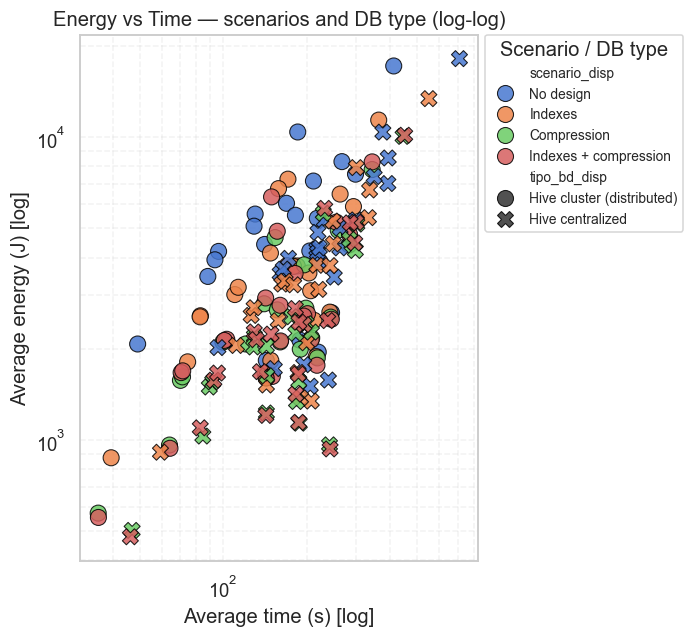

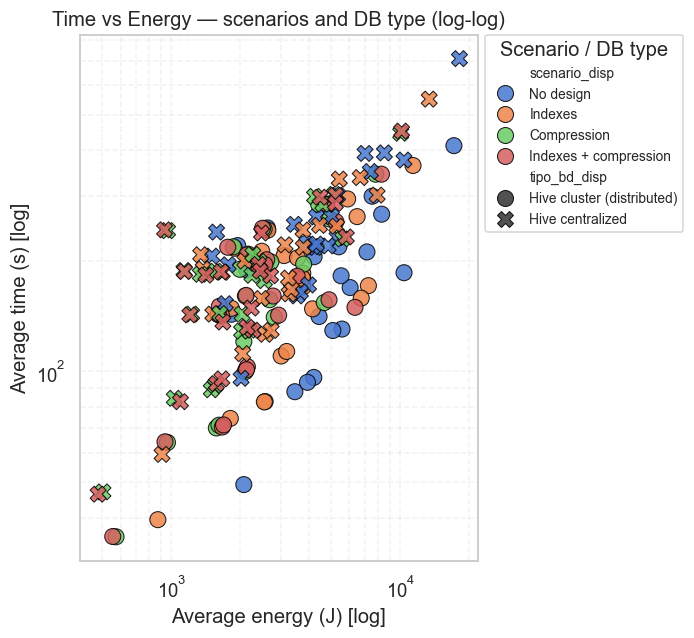

In [118]:
# =============================
# Celda: CORRELACIÓN (Spearman) + Scatter — ENERGÍA vs TIEMPO
# - Compara por (configuración=scenario) y por tipo de BD (clúster/fragmentado vs centralizado)
# - Mantiene una MISMA escala en ambos subplots para comparar visualmente.
# =============================
if "df_statsN_H" not in globals() or not isinstance(df_statsN_H, pd.DataFrame) or len(df_statsN_H) == 0:
    raise RuntimeError("No encuentro df_statsN_H (clúster/fragmentado). Ejecuta primero la celda de ESTADÍSTICAS.")
if "df_statsN_central_H" not in globals() or not isinstance(df_statsN_central_H, pd.DataFrame) or len(df_statsN_central_H) == 0:
    raise RuntimeError("No encuentro df_statsN_central_H (centralizado). Ejecuta primero la celda de ESTADÍSTICAS — CENTRALIZADO.")

TIPO_BD_LABEL = {
    "hive_cluster_fragmentado": "Hive cluster (distributed)",
    "hive_centralizado": "Hive centralized",
}
TIPO_BD_ORDER = ["hive_cluster_fragmentado", "hive_centralizado"]

# Helper local: display label sólo para gráficos
def _scen_disp(s: str) -> str:
    if "_scenario_label_en_H" in globals():
        try:
            return _scenario_label_en_H(s)
        except Exception:
            pass
    return str(s)

scenario_order_disp = [_scen_disp(s) for s in SCENARIO_ORDER_H]

cluster = (
    df_statsN_H[["scenario", "Q", "mean_time", "mean_energy"]]
    .copy()
    .assign(tipo_bd="hive_cluster_fragmentado")
)
central = (
    df_statsN_central_H[["scenario", "Q", "mean_time", "mean_energy"]]
    .copy()
    .assign(tipo_bd="hive_centralizado")
)

df_corr = pd.concat([cluster, central], ignore_index=True)

df_corr["scenario"] = pd.Categorical(df_corr["scenario"].astype(str), categories=list(SCENARIO_ORDER_H), ordered=True)
df_corr["tipo_bd"] = pd.Categorical(df_corr["tipo_bd"], categories=TIPO_BD_ORDER, ordered=True)

# Validación
for c in ["mean_time", "mean_energy"]:
    df_corr[c] = pd.to_numeric(df_corr[c], errors="coerce")

mask_valid = (
    df_corr["mean_time"].notna()
    & df_corr["mean_energy"].notna()
    & np.isfinite(df_corr["mean_time"])
    & np.isfinite(df_corr["mean_energy"])
    & (df_corr["mean_time"] > 0)
    & (df_corr["mean_energy"] > 0)
)

print("=" * 90)
print("📌 Correlación Spearman — Energía vs Tiempo")
print("=" * 90)
print("Total puntos:", len(df_corr))
print("Válidos:", int(mask_valid.sum()), "| Excluidos:", int((~mask_valid).sum()))

# Spearman por (tipo_bd × scenario)
rows = []
for tipo_bd in df_corr["tipo_bd"].cat.categories:
    for scen in list(SCENARIO_ORDER_H):
        d = df_corr[(df_corr["tipo_bd"] == tipo_bd) & (df_corr["scenario"] == scen) & mask_valid].copy()
        n = int(len(d))
        if n >= 3:
            rho, p = stats.spearmanr(d["mean_time"].astype(float), d["mean_energy"].astype(float))
        else:
            rho, p = (np.nan, np.nan)
        rows.append({
            "tipo_bd": str(tipo_bd),
            "scenario": scen,
            "n": n,
            "rho": float(rho) if np.isfinite(rho) else np.nan,
            "p_value": float(p) if np.isfinite(p) else np.nan,
        })

df_spearman_by = pd.DataFrame(rows)
df_spearman_by["scenario"] = pd.Categorical(df_spearman_by["scenario"], categories=list(SCENARIO_ORDER_H), ordered=True)
df_spearman_by["tipo_bd"] = pd.Categorical(df_spearman_by["tipo_bd"], categories=TIPO_BD_ORDER, ordered=True)

display(df_spearman_by.sort_values(["tipo_bd", "scenario"]))

# Spearman global por tipo_bd
rows = []
for tipo_bd in df_corr["tipo_bd"].cat.categories:
    d = df_corr[(df_corr["tipo_bd"] == tipo_bd) & mask_valid].copy()
    n = int(len(d))
    if n >= 3:
        rho, p = stats.spearmanr(d["mean_time"].astype(float), d["mean_energy"].astype(float))
    else:
        rho, p = (np.nan, np.nan)
    rows.append({"tipo_bd": str(tipo_bd), "n": n, "rho": rho, "p_value": p})

df_spearman_global = pd.DataFrame(rows)
display(df_spearman_global)

# Scatter: energía vs tiempo, diferenciando configuración y tipo de BD (misma escala)
plot_df = df_corr.loc[mask_valid].copy()
plot_df["scenario_disp"] = plot_df["scenario"].astype(str).map(_scen_disp)
plot_df["tipo_bd_disp"] = plot_df["tipo_bd"].astype(str).map(lambda t: TIPO_BD_LABEL.get(str(t), str(t)))

# Variante log-log (útil si hay órdenes de magnitud)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="mean_time",
    y="mean_energy",
    hue="scenario_disp",
    style="tipo_bd_disp",
    hue_order=scenario_order_disp,
    style_order=[TIPO_BD_LABEL.get(t, t) for t in TIPO_BD_ORDER],
    s=110,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Energy vs Time — scenarios and DB type (log-log)")
ax.set_xlabel("Average time (s) [log]")
ax.set_ylabel("Average energy (J) [log]")
ax.grid(True, which="both", alpha=0.25, linestyle="--")
ax.legend(title="Scenario / DB type", fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# Variante invertida: Time vs Energy (log-log) — como en el informe
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="mean_energy",
    y="mean_time",
    hue="scenario_disp",
    style="tipo_bd_disp",
    hue_order=scenario_order_disp,
    style_order=[TIPO_BD_LABEL.get(t, t) for t in TIPO_BD_ORDER],
    s=110,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Time vs Energy — scenarios and DB type (log-log)")
ax.set_xlabel("Average energy (J) [log]")
ax.set_ylabel("Average time (s) [log]")
ax.grid(True, which="both", alpha=0.25, linestyle="--")
ax.legend(title="Scenario / DB type", fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


In [119]:
# =============================
# Celda: COMPARATIVO — Clúster/fragmentado vs Centralizado (tiempo/energía)
# =============================
if "df_statsN_H" not in globals() or not isinstance(df_statsN_H, pd.DataFrame) or len(df_statsN_H) == 0:
    raise RuntimeError("No encuentro df_statsN_H (clúster/fragmentado). Ejecuta primero ESTADÍSTICAS.")
if "df_statsN_central_H" not in globals() or not isinstance(df_statsN_central_H, pd.DataFrame) or len(df_statsN_central_H) == 0:
    raise RuntimeError("No encuentro df_statsN_central_H. Ejecuta primero ESTADÍSTICAS — CENTRALIZADO.")


TIPO_BD_ORDER = ["hive_cluster_fragmentado", "hive_centralizado"]
TIPO_BD_LABEL = {
    "hive_cluster_fragmentado": "Hive cluster (distributed)",
    "hive_centralizado": "Hive centralized",
}


def _scen_disp(s: str) -> str:
    if "_scenario_label_en_H" in globals():
        try:
            return _scenario_label_en_H(s)
        except Exception:
            pass
    return str(s)


scenario_order_disp = [_scen_disp(s) for s in SCENARIO_ORDER_H]


def _tipo_disp(t: str) -> str:
    return TIPO_BD_LABEL.get(str(t), str(t))


tipo_order_disp = [_tipo_disp(t) for t in TIPO_BD_ORDER]


cluster = df_statsN_H.copy().assign(tipo_bd="hive_cluster_fragmentado")
central = df_statsN_central_H.copy().assign(tipo_bd="hive_centralizado")


df_both = pd.concat([cluster, central], ignore_index=True)
df_both["scenario"] = pd.Categorical(df_both["scenario"].astype(str), categories=SCENARIO_ORDER_H, ordered=True)
df_both["tipo_bd"]  = pd.Categorical(df_both["tipo_bd"], categories=TIPO_BD_ORDER, ordered=True)


print("=" * 90)
print("📊 Resumen por (tipo_bd × scenario)")
print("=" * 90)
display(
    df_both.groupby(["tipo_bd", "scenario"], observed=True)
    .agg(
        n_Q=("Q", "nunique"),
        med_time_s=("mean_time", "median"),
        med_energy_J=("mean_energy", "median"),
    )
    .reset_index()
    .sort_values(["tipo_bd", "scenario"])
)


pivot = df_both.pivot_table(
    index=["scenario", "Q"],
    columns="tipo_bd",
    values=["mean_time", "mean_energy"],
    aggfunc="mean",
)

out = pd.DataFrame(index=pivot.index)
out["time_ratio_central_vs_cluster"]   = pivot[("mean_time",   "hive_centralizado")] / pivot[("mean_time",   "hive_cluster_fragmentado")]
out["energy_ratio_central_vs_cluster"] = pivot[("mean_energy", "hive_centralizado")] / pivot[("mean_energy", "hive_cluster_fragmentado")]
out = out.reset_index()


print("=" * 90)
print("📌 Mejores mejoras (centralizado << clúster) — TIEMPO")
print("=" * 90)
display(out.sort_values("time_ratio_central_vs_cluster", ascending=True).head(15))

print("=" * 90)
print("📌 Mejores mejoras (centralizado << clúster) — ENERGÍA")
print("=" * 90)
display(out.sort_values("energy_ratio_central_vs_cluster", ascending=True).head(15))

print("=" * 90)
print("📌 Peores casos (centralizado >> clúster) — TIEMPO")
print("=" * 90)
display(out.sort_values("time_ratio_central_vs_cluster", ascending=False).head(15))




📊 Resumen por (tipo_bd × scenario)


,tipo_bd,scenario,n_Q,med_time_s,med_energy_J
0,hive_cluster_fragmentado,sindiseno,22,183.85375,4312.718333
1,hive_cluster_fragmentado,indices,22,170.52465,3149.725842
2,hive_cluster_fragmentado,compresion,22,158.55210,2145.431822
3,hive_cluster_fragmentado,indice_compresion,22,158.50605,2325.886237
4,hive_centralizado,sindiseno,22,226.73365,4285.842011
5,hive_centralizado,indices,22,194.90215,3196.361063
6,hive_centralizado,compresion,22,183.19495,2032.563432
7,hive_centralizado,indice_compresion,22,184.78480,2189.558144


📌 Mejores mejoras (centralizado << clúster) — TIEMPO


,scenario,Q,time_ratio_central_vs_cluster,energy_ratio_central_vs_cluster
23,indices,2,0.857268,0.508649
76,indice_compresion,11,0.858747,0.648075
54,compresion,11,0.861406,0.608693
32,indices,11,0.878158,0.731183
50,compresion,7,0.898389,0.719581
72,indice_compresion,7,0.899544,0.770709
10,sindiseno,11,0.935939,0.771711
28,indices,7,0.940764,0.842533
68,indice_compresion,3,0.958043,0.571091
59,compresion,16,0.969122,0.672267


📌 Mejores mejoras (centralizado << clúster) — ENERGÍA


,scenario,Q,time_ratio_central_vs_cluster,energy_ratio_central_vs_cluster
83,indice_compresion,18,0.995563,0.352466
67,indice_compresion,2,0.990147,0.373202
45,compresion,2,0.990025,0.378810
39,indices,18,1.134081,0.481432
23,indices,2,0.857268,0.508649
68,indice_compresion,3,0.958043,0.571091
46,compresion,3,1.022111,0.578494
24,indices,3,1.066758,0.597805
1,sindiseno,2,0.974312,0.599442
54,compresion,11,0.861406,0.608693


📌 Peores casos (centralizado >> clúster) — TIEMPO


,scenario,Q,time_ratio_central_vs_cluster,energy_ratio_central_vs_cluster
16,sindiseno,17,2.026035,0.999079
5,sindiseno,6,1.946394,0.973071
0,sindiseno,1,1.822313,1.022306
13,sindiseno,14,1.785671,0.948737
3,sindiseno,4,1.774420,0.951200
38,indices,17,1.763651,1.092037
18,sindiseno,19,1.762069,0.931483
20,sindiseno,21,1.725112,1.057297
11,sindiseno,12,1.698899,0.954154
14,sindiseno,15,1.655307,1.034785


📊 BARRAS (log) — TIEMPO | FRAGMENTADO vs CENTRALIZADO


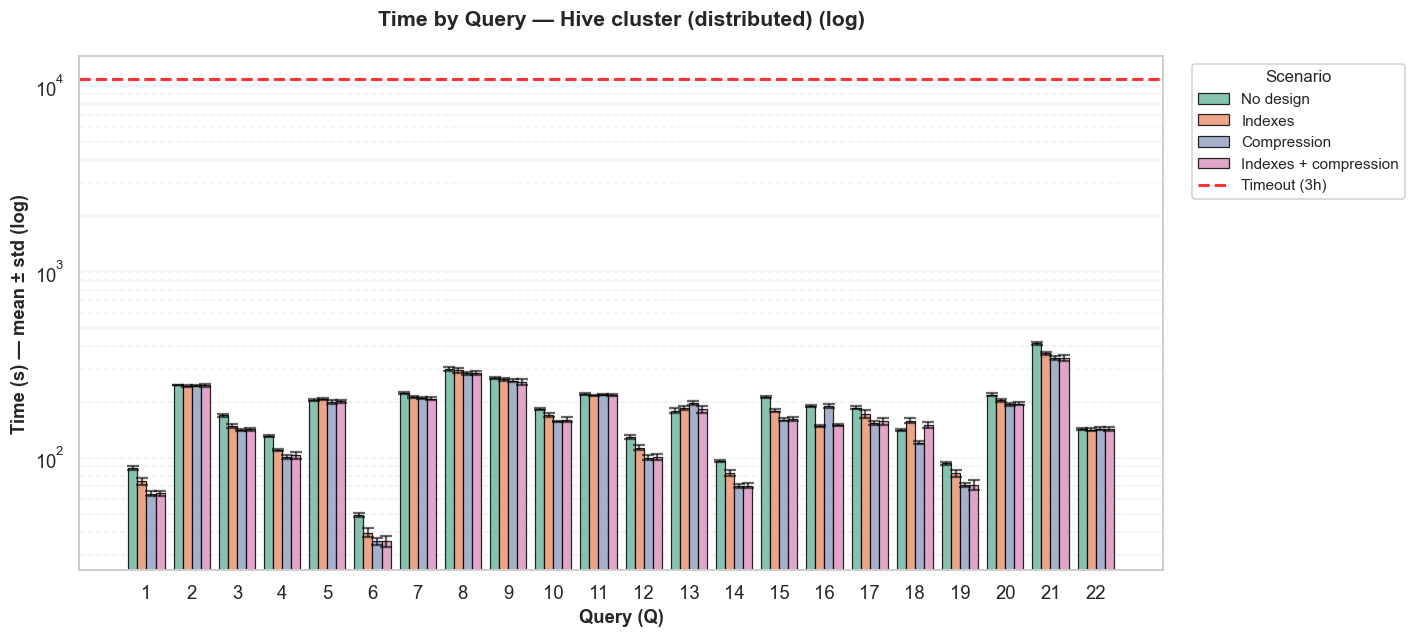

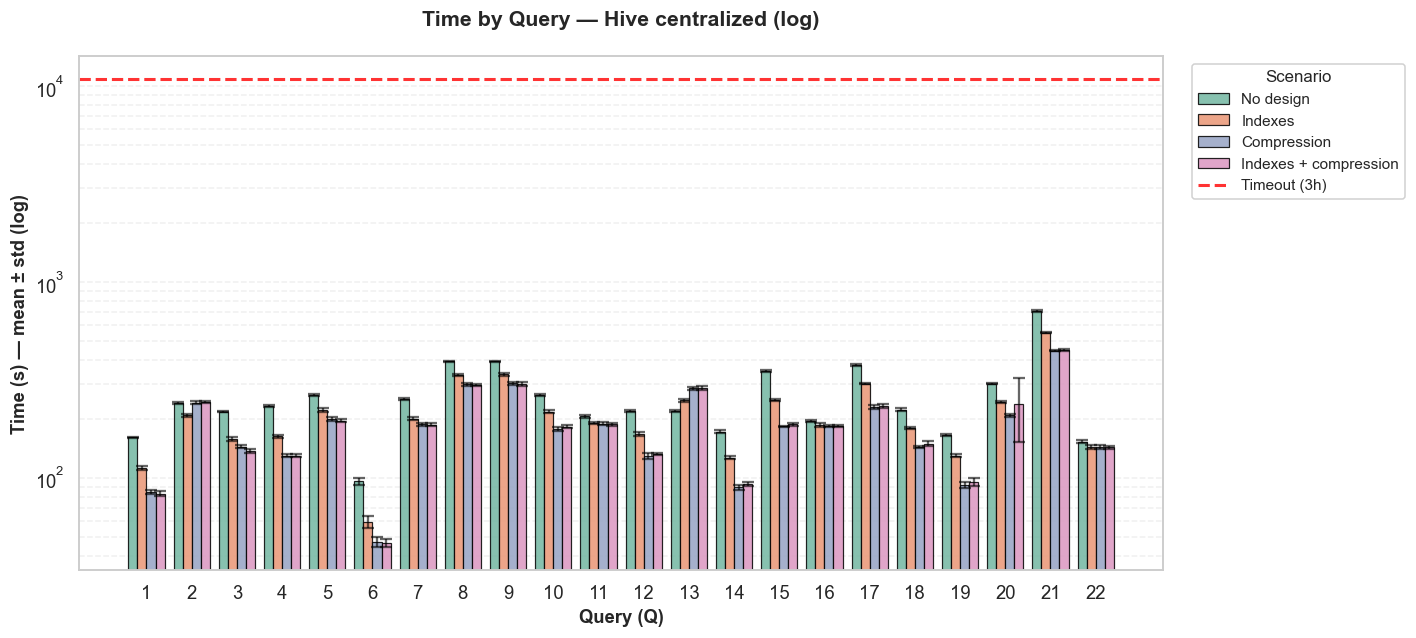

📊 BARRAS (log) — ENERGÍA | FRAGMENTADO vs CENTRALIZADO


/var/folders/yz/vw71cvqj02b6wn0nvpt_z4kc0000gn/T/ipykernel_54791/2071933724.py:215: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, float(ylim))


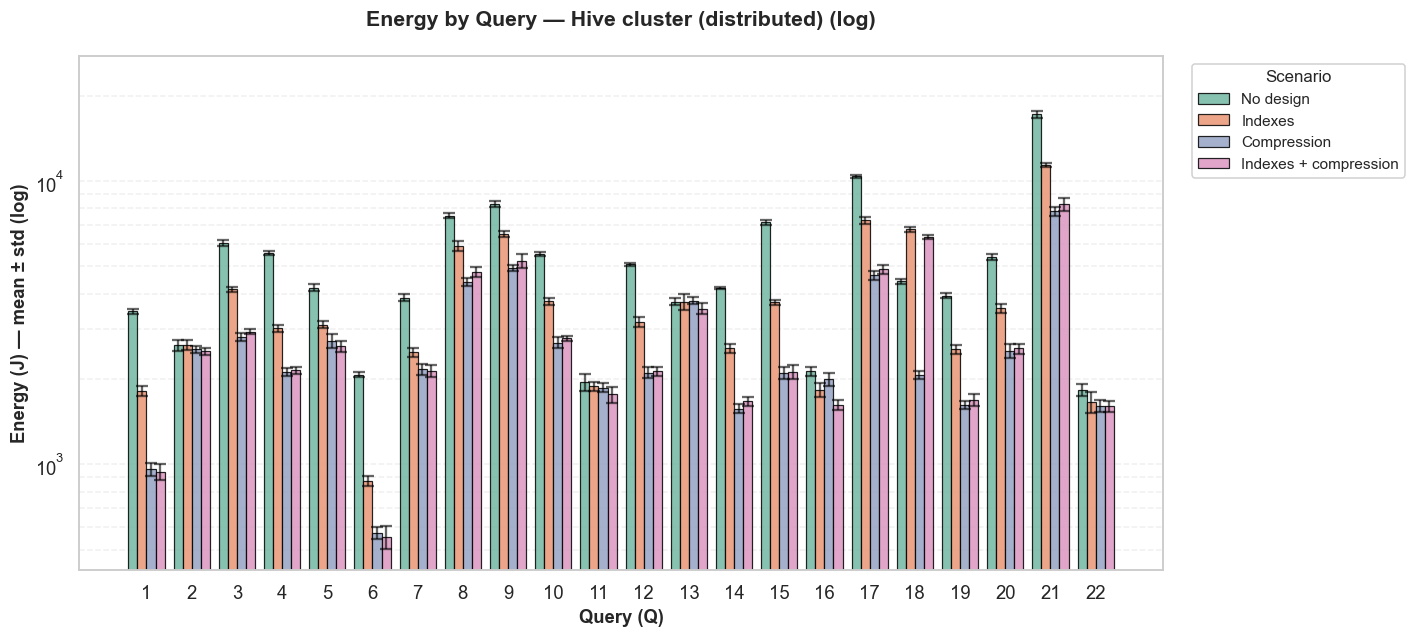

/var/folders/yz/vw71cvqj02b6wn0nvpt_z4kc0000gn/T/ipykernel_54791/2071933724.py:215: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, float(ylim))


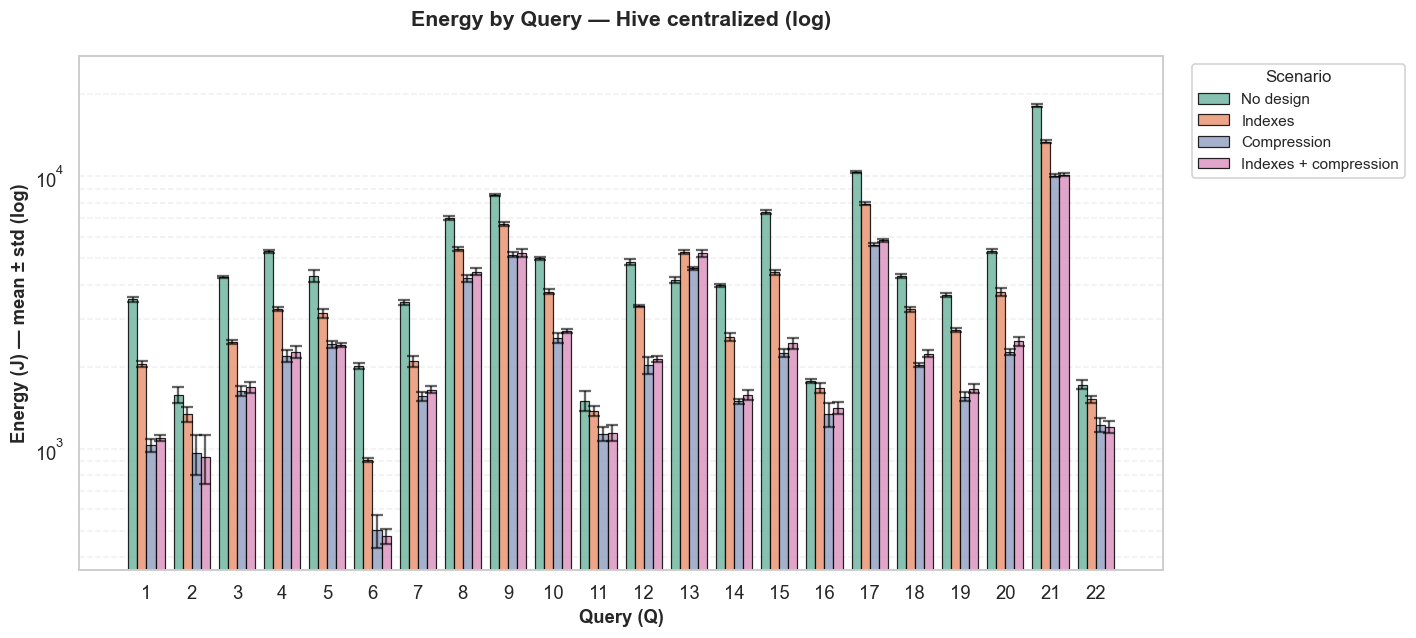

In [120]:
# =============================
# Celda: GRÁFICAS — ESCALA LOG (PROMEDIOS ± STD, hasta N iteraciones)
# Orden para comparar fácil:
# 1) TIEMPO (log): FRAGMENTADO vs CENTRALIZADO
# 2) ENERGÍA (log): FRAGMENTADO vs CENTRALIZADO
# =============================
if "df_statsN_H" not in globals() or not isinstance(df_statsN_H, pd.DataFrame) or len(df_statsN_H) == 0:
    raise RuntimeError("No encuentro `df_statsN_H`. Ejecuta primero la celda de ESTADÍSTICAS (cluster/fragmentado).")
if "df_statsN_central_H" not in globals() or not isinstance(df_statsN_central_H, pd.DataFrame) or len(df_statsN_central_H) == 0:
    raise RuntimeError("No encuentro `df_statsN_central_H`. Ejecuta primero la celda de ESTADÍSTICAS — CENTRALIZADO.")

print("=" * 80)
print("📊 BARRAS (log) — TIEMPO | FRAGMENTADO vs CENTRALIZADO")
print("=" * 80)
bar_mean_std_H(
    df_statsN_H,
    mean_col="mean_time",
    std_col="std_time",
    ylabel="Time (s) — mean ± std (log)",
    title="Time by Query — Hive cluster (distributed) (log)",
    log_scale=True,
    annotate_counts=False,
    add_timeout_line=True,
)
bar_mean_std_H(
    df_statsN_central_H,
    mean_col="mean_time",
    std_col="std_time",
    ylabel="Time (s) — mean ± std (log)",
    title="Time by Query — Hive centralized (log)",
    log_scale=True,
    annotate_counts=False,
    add_timeout_line=True,
)

print("=" * 80)
print("📊 BARRAS (log) — ENERGÍA | FRAGMENTADO vs CENTRALIZADO")
print("=" * 80)
# Escala común para ambas gráficas de energía
_ymax_energy = float(np.nanmax([
    (df_statsN_H["mean_energy"] + df_statsN_H["std_energy"].fillna(0)).max(),
    (df_statsN_central_H["mean_energy"] + df_statsN_central_H["std_energy"].fillna(0)).max(),
])) * 1.5

bar_mean_std_H(
    df_statsN_H,
    mean_col="mean_energy",
    std_col="std_energy",
    ylabel="Energy (J) — mean ± std (log)",
    title="Energy by Query — Hive cluster (distributed) (log)",
    log_scale=True,
    ylim=_ymax_energy,
    annotate_counts=False,
)
bar_mean_std_H(
    df_statsN_central_H,
    mean_col="mean_energy",
    std_col="std_energy",
    ylabel="Energy (J) — mean ± std (log)",
    title="Energy by Query — Hive centralized (log)",
    log_scale=True,
    ylim=_ymax_energy,
    annotate_counts=False,
)

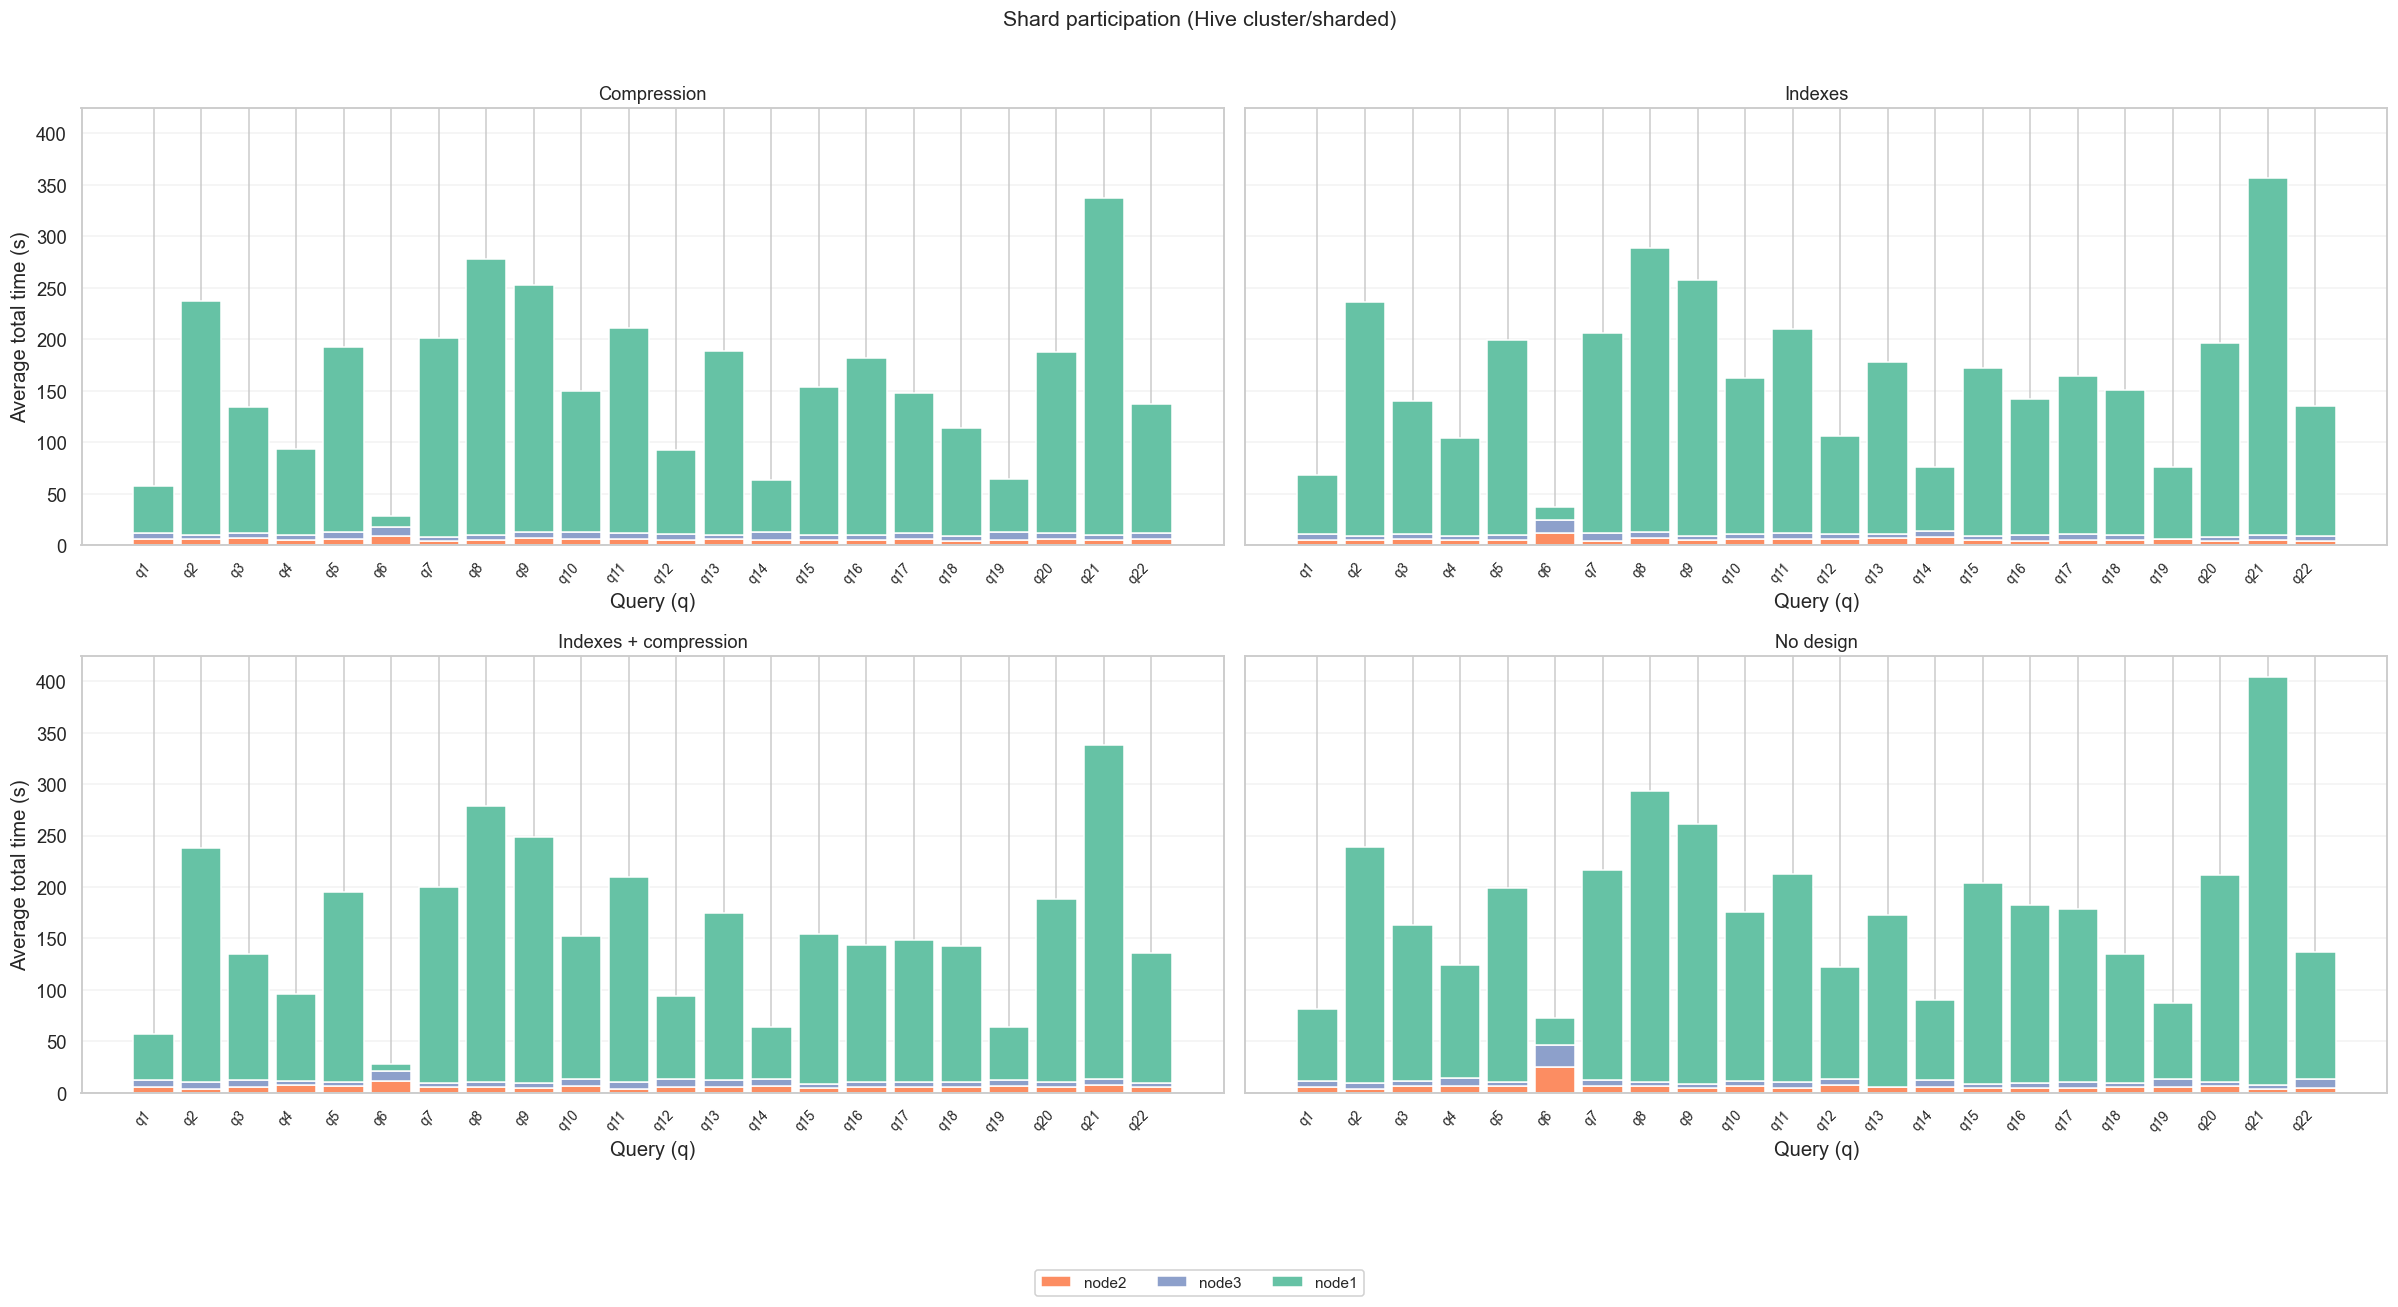

✅ Guardado: graf_tiempo_trabajo_nodos_fragmentado_resto_en_node1_dist_5g.png


In [121]:
_plot_trabajo_por_nodo(
    df_clust_nodo_H,
    modo='fragmentado',
    total_builder=_build_total_time_base_fragmentado,
    default_total_from='elapsed_s',
    out_png=None,
 )

---
## 7. Gráficos Mongo

📌 Correlación Spearman — Energía vs Tiempo
Total puntos: 176
Válidos: 176 | Excluidos: 0


,tipo_bd,scenario,n,rho,p_value
0,mongo_cluster_sharded,sindiseno,22,0.631627,1.616309e-03
1,mongo_cluster_sharded,indices,22,0.974026,2.266149e-14
2,mongo_cluster_sharded,compresion,22,0.984116,1.728355e-16
3,mongo_cluster_sharded,indice_compresion,22,0.979673,1.999247e-15
4,mongo_centralizado,sindiseno,22,0.672942,5.993145e-04
5,mongo_centralizado,indices,22,0.885940,4.168076e-08
6,mongo_centralizado,compresion,22,0.672942,5.993145e-04
7,mongo_centralizado,indice_compresion,22,0.967250,2.237691e-13


,tipo_bd,n,rho,p_value
0,mongo_cluster_sharded,88,0.973586,6.019124e-57
1,mongo_centralizado,88,0.944456,2.484975e-43


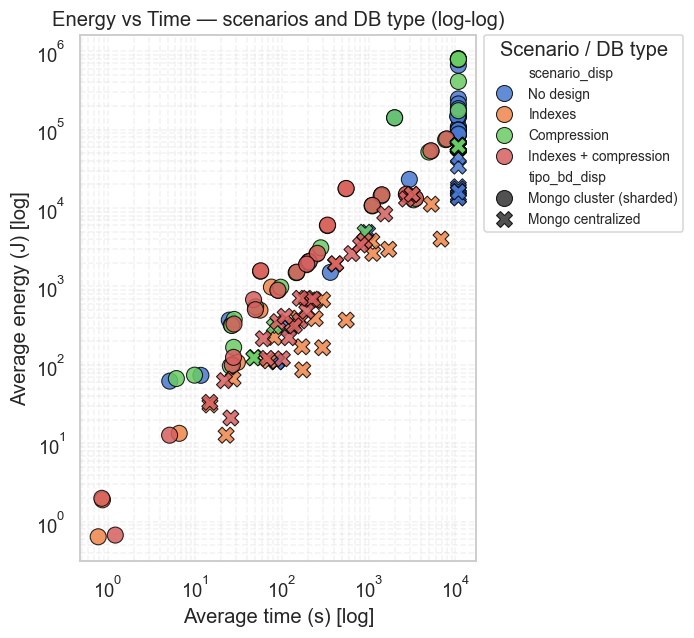

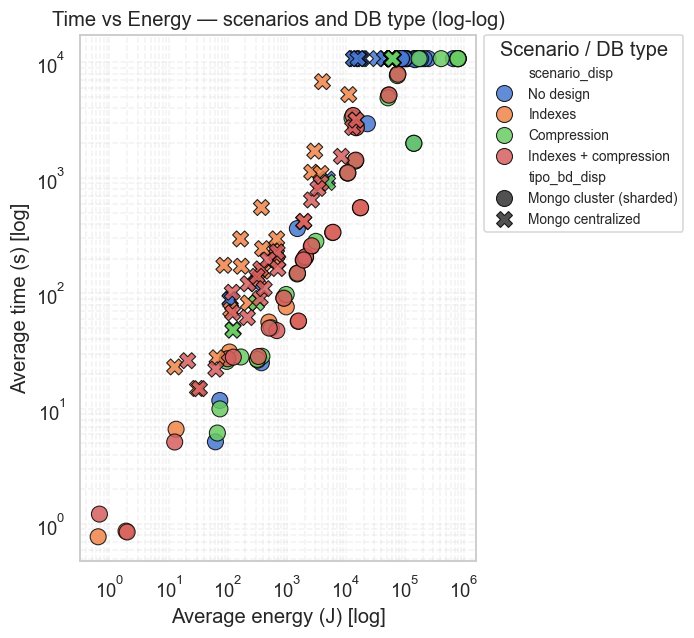

In [122]:
# =============================
# Celda: CORRELACIÓN (Spearman) + Scatter — ENERGÍA vs TIEMPO
# - Compara por (configuración=scenario) y por tipo de BD (cluster/sharded vs centralizado)
# - Mantiene una MISMA escala en ambos subplots para comparar visualmente.
# =============================
if "df_statsN_M" not in globals() or not isinstance(df_statsN_M, pd.DataFrame) or len(df_statsN_M) == 0:
    raise RuntimeError("No encuentro df_statsN_M (cluster/sharded). Ejecuta primero la celda de ESTADÍSTICAS.")
if "df_statsN_central_M" not in globals() or not isinstance(df_statsN_central_M, pd.DataFrame) or len(df_statsN_central_M) == 0:
    raise RuntimeError("No encuentro df_statsN_central_M (centralizado). Ejecuta primero la celda de ESTADÍSTICAS — CENTRALIZADO.")

# Labels SOLO para visualización (no cambian claves internas)
SCENARIO_LABEL_EN = {
    "sindiseno": "No design",
    "sin_diseno": "No design",
    "indices": "Indexes",
    "compresion": "Compression",
    "indice_compresion": "Indexes + compression",
    "indices_compresion": "Indexes + compression",
}
TIPO_BD_LABEL_EN = {
    "mongo_cluster_sharded": "Mongo cluster (sharded)",
    "mongo_centralizado": "Mongo centralized",
}

def _scenario_label_en_M(s: str) -> str:
    return SCENARIO_LABEL_EN.get(str(s), str(s))

def _tipo_bd_label_en(s: str) -> str:
    return TIPO_BD_LABEL_EN.get(str(s), str(s))

scenario_order_disp = [_scenario_label_en_M(s) for s in list(SCENARIO_ORDER_M)]
tipo_bd_order = ["mongo_cluster_sharded", "mongo_centralizado"]
tipo_bd_order_disp = [_tipo_bd_label_en(t) for t in tipo_bd_order]

cluster = (
    df_statsN_M[["scenario", "Q", "mean_time", "mean_energy"]]
    .copy()
    .assign(tipo_bd="mongo_cluster_sharded")
)
central = (
    df_statsN_central_M[["scenario", "Q", "mean_time", "mean_energy"]]
    .copy()
    .assign(tipo_bd="mongo_centralizado")
)

df_corr = pd.concat([cluster, central], ignore_index=True)

df_corr["scenario"] = pd.Categorical(df_corr["scenario"].astype(str), categories=list(SCENARIO_ORDER_M), ordered=True)
df_corr["tipo_bd"] = pd.Categorical(df_corr["tipo_bd"], categories=tipo_bd_order, ordered=True)

# Validación
for c in ["mean_time", "mean_energy"]:
    df_corr[c] = pd.to_numeric(df_corr[c], errors="coerce")

mask_valid = (
    df_corr["mean_time"].notna()
    & df_corr["mean_energy"].notna()
    & np.isfinite(df_corr["mean_time"])
    & np.isfinite(df_corr["mean_energy"])
    & (df_corr["mean_time"] > 0)
    & (df_corr["mean_energy"] > 0)
)

print("=" * 90)
print("📌 Correlación Spearman — Energía vs Tiempo")
print("=" * 90)
print("Total puntos:", len(df_corr))
print("Válidos:", int(mask_valid.sum()), "| Excluidos:", int((~mask_valid).sum()))

# Spearman por (tipo_bd × scenario)
rows = []
for tipo_bd in df_corr["tipo_bd"].cat.categories:
    for scen in list(SCENARIO_ORDER_M):
        d = df_corr[(df_corr["tipo_bd"] == tipo_bd) & (df_corr["scenario"] == scen) & mask_valid].copy()
        n = int(len(d))
        if n >= 3:
            rho, p = stats.spearmanr(d["mean_time"].astype(float), d["mean_energy"].astype(float))
        else:
            rho, p = (np.nan, np.nan)
        rows.append({
            "tipo_bd": str(tipo_bd),
            "scenario": scen,
            "n": n,
            "rho": float(rho) if np.isfinite(rho) else np.nan,
            "p_value": float(p) if np.isfinite(p) else np.nan,
        })

df_spearman_by = pd.DataFrame(rows)
df_spearman_by["scenario"] = pd.Categorical(df_spearman_by["scenario"], categories=list(SCENARIO_ORDER_M), ordered=True)
df_spearman_by["tipo_bd"] = pd.Categorical(df_spearman_by["tipo_bd"], categories=tipo_bd_order, ordered=True)

display(df_spearman_by.sort_values(["tipo_bd", "scenario"]))

# Spearman global por tipo_bd
rows = []
for tipo_bd in df_corr["tipo_bd"].cat.categories:
    d = df_corr[(df_corr["tipo_bd"] == tipo_bd) & mask_valid].copy()
    n = int(len(d))
    if n >= 3:
        rho, p = stats.spearmanr(d["mean_time"].astype(float), d["mean_energy"].astype(float))
    else:
        rho, p = (np.nan, np.nan)
    rows.append({"tipo_bd": str(tipo_bd), "n": n, "rho": rho, "p_value": p})

df_spearman_global = pd.DataFrame(rows)
display(df_spearman_global)

# Scatter: energía vs tiempo, diferenciando configuración y tipo de BD (misma escala)
plot_df = df_corr.loc[mask_valid].copy()
plot_df["scenario_disp"] = plot_df["scenario"].astype(str).map(_scenario_label_en_M)
plot_df["tipo_bd_disp"] = plot_df["tipo_bd"].astype(str).map(_tipo_bd_label_en)
plot_df["scenario_disp"] = pd.Categorical(plot_df["scenario_disp"], categories=scenario_order_disp, ordered=True)
plot_df["tipo_bd_disp"] = pd.Categorical(plot_df["tipo_bd_disp"], categories=tipo_bd_order_disp, ordered=True)

# Variante log-log (útil si hay órdenes de magnitud)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="mean_time",
    y="mean_energy",
    hue="scenario_disp",
    style="tipo_bd_disp",
    hue_order=scenario_order_disp,
    style_order=tipo_bd_order_disp,
    s=110,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Energy vs Time — scenarios and DB type (log-log)")
ax.set_xlabel("Average time (s) [log]")
ax.set_ylabel("Average energy (J) [log]")
ax.grid(True, which="both", alpha=0.25, linestyle="--")
ax.legend(title="Scenario / DB type", fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


# Variante invertida: Time vs Energy (log-log) — como en el informe
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="mean_energy",
    y="mean_time",
    hue="scenario_disp",
    style="tipo_bd_disp",
    hue_order=scenario_order_disp,
    style_order=tipo_bd_order_disp,
    s=110,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Time vs Energy — scenarios and DB type (log-log)")
ax.set_xlabel("Average energy (J) [log]")
ax.set_ylabel("Average time (s) [log]")
ax.grid(True, which="both", alpha=0.25, linestyle="--")
ax.legend(title="Scenario / DB type", fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


In [123]:
# =============================
# Celda: COMPARATIVO — Cluster/Sharded vs Centralizado (tiempo/energía)
# - Construye un dataframe combinado con etiqueta `tipo_bd`
# - Muestra ratios centralizado/cluster por (scenario, Q)
# - Incluye gráficas de BARRAS comparativas por escenario
# =============================
if "df_statsN_M" not in globals() or not isinstance(df_statsN_M, pd.DataFrame) or len(df_statsN_M) == 0:
    raise RuntimeError("No encuentro df_statsN_M (cluster/sharded). Ejecuta primero ESTADÍSTICAS.")
if "df_statsN_central_M" not in globals() or not isinstance(df_statsN_central_M, pd.DataFrame) or len(df_statsN_central_M) == 0:
    raise RuntimeError("No encuentro df_statsN_central_M. Ejecuta primero ESTADÍSTICAS — CENTRALIZADO.")


cluster = df_statsN_M.copy().assign(tipo_bd="mongo_cluster_sharded")
central = df_statsN_central_M.copy().assign(tipo_bd="mongo_centralizado")


df_both = pd.concat([cluster, central], ignore_index=True)
df_both["scenario"] = pd.Categorical(df_both["scenario"].astype(str), categories=SCENARIO_ORDER_M, ordered=True)
df_both["tipo_bd"] = pd.Categorical(df_both["tipo_bd"], categories=["mongo_cluster_sharded", "mongo_centralizado"], ordered=True)


print("=" * 90)
print("📊 Resumen por (tipo_bd × scenario)")
print("=" * 90)
display(
    df_both.groupby(["tipo_bd", "scenario"], observed=True)
    .agg(
        n_Q=("Q", "nunique"),
        med_time_s=("mean_time", "median"),
        med_energy_J=("mean_energy", "median"),
    )
    .reset_index()
    .sort_values(["tipo_bd", "scenario"])
)


pivot = (
    df_both.pivot_table(
        index=["scenario", "Q"],
        columns="tipo_bd",
        values=["mean_time", "mean_energy"],
        aggfunc="mean",
    )
)


out = pd.DataFrame(index=pivot.index)
out["time_ratio_central_vs_cluster"] = pivot[("mean_time", "mongo_centralizado")] / pivot[("mean_time", "mongo_cluster_sharded")]
out["energy_ratio_central_vs_cluster"] = pivot[("mean_energy", "mongo_centralizado")] / pivot[("mean_energy", "mongo_cluster_sharded")]
out = out.reset_index()


print("=" * 90)
print("📌 Mejores mejoras (centralizado << cluster) — TIEMPO")
print("=" * 90)
display(out.sort_values("time_ratio_central_vs_cluster", ascending=True).head(15))


print("=" * 90)
print("📌 Mejores mejoras (centralizado << cluster) — ENERGÍA")
print("=" * 90)
display(out.sort_values("energy_ratio_central_vs_cluster", ascending=True).head(15))


print("=" * 90)
print("📌 Peores casos (centralizado >> cluster) — TIEMPO")
print("=" * 90)
display(out.sort_values("time_ratio_central_vs_cluster", ascending=False).head(15))




📊 Resumen por (tipo_bd × scenario)


,tipo_bd,scenario,n_Q,med_time_s,med_energy_J
0,mongo_cluster_sharded,sindiseno,22,10800.00000,107130.876124
1,mongo_cluster_sharded,indices,22,171.68315,1730.791025
2,mongo_cluster_sharded,compresion,22,693.10295,6879.077821
3,mongo_cluster_sharded,indice_compresion,22,171.93620,1755.940769
4,mongo_centralizado,sindiseno,22,10800.00000,26466.744963
5,mongo_centralizado,indices,22,242.28890,392.168875
6,mongo_centralizado,compresion,22,10800.00000,60970.682915
7,mongo_centralizado,indice_compresion,22,163.36605,450.655212


📌 Mejores mejoras (centralizado << cluster) — TIEMPO


,scenario,Q,time_ratio_central_vs_cluster,energy_ratio_central_vs_cluster
87,indice_compresion,22,0.113316,0.032718
43,indices,22,0.142595,0.034876
73,indice_compresion,8,0.259439,0.286422
78,indice_compresion,13,0.297015,0.039802
74,indice_compresion,9,0.297781,0.225201
29,indices,8,0.317854,0.287843
72,indice_compresion,7,0.345351,0.171388
34,indices,13,0.345515,0.040057
32,indices,11,0.378431,0.178559
76,indice_compresion,11,0.379640,0.180725


📌 Mejores mejoras (centralizado << cluster) — ENERGÍA


,scenario,Q,time_ratio_central_vs_cluster,energy_ratio_central_vs_cluster
19,sindiseno,20,1.000000,0.019984
87,indice_compresion,22,0.113316,0.032718
43,indices,22,0.142595,0.034876
78,indice_compresion,13,0.297015,0.039802
34,indices,13,0.345515,0.040057
41,indices,20,1.254868,0.072118
56,compresion,13,1.000000,0.074702
2,sindiseno,3,1.000000,0.075870
85,indice_compresion,20,1.178828,0.076478
52,compresion,9,1.000000,0.078114


📌 Peores casos (centralizado >> cluster) — TIEMPO


,scenario,Q,time_ratio_central_vs_cluster,energy_ratio_central_vs_cluster
45,compresion,2,419.878935,631.194677
47,compresion,4,402.947486,196.491245
55,compresion,12,384.556496,350.218173
27,indices,6,224.956773,134.196463
57,compresion,14,110.492829,60.433110
22,indices,1,89.361200,4.091742
71,indice_compresion,6,83.554737,176.878951
59,compresion,16,73.411957,39.538885
53,compresion,10,52.809618,30.255129
36,indices,15,44.542109,12.352037


📊 BARRAS (log) — TIEMPO | FRAGMENTADO vs CENTRALIZADO


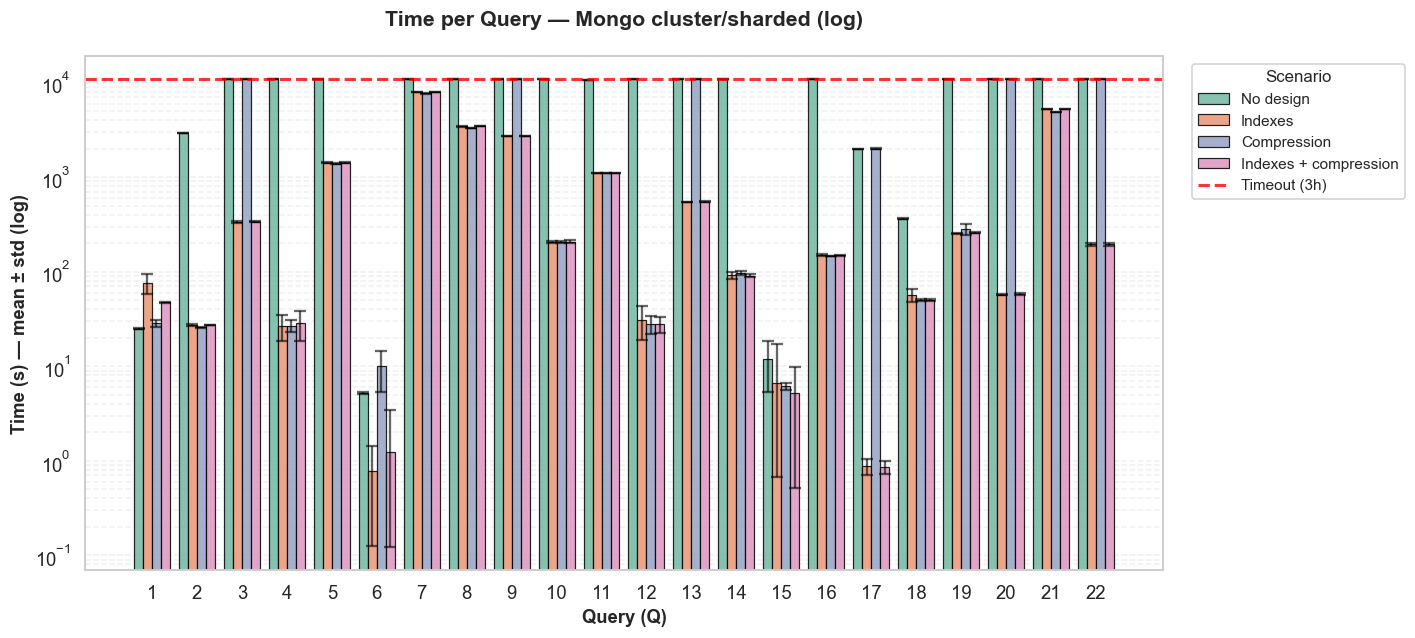

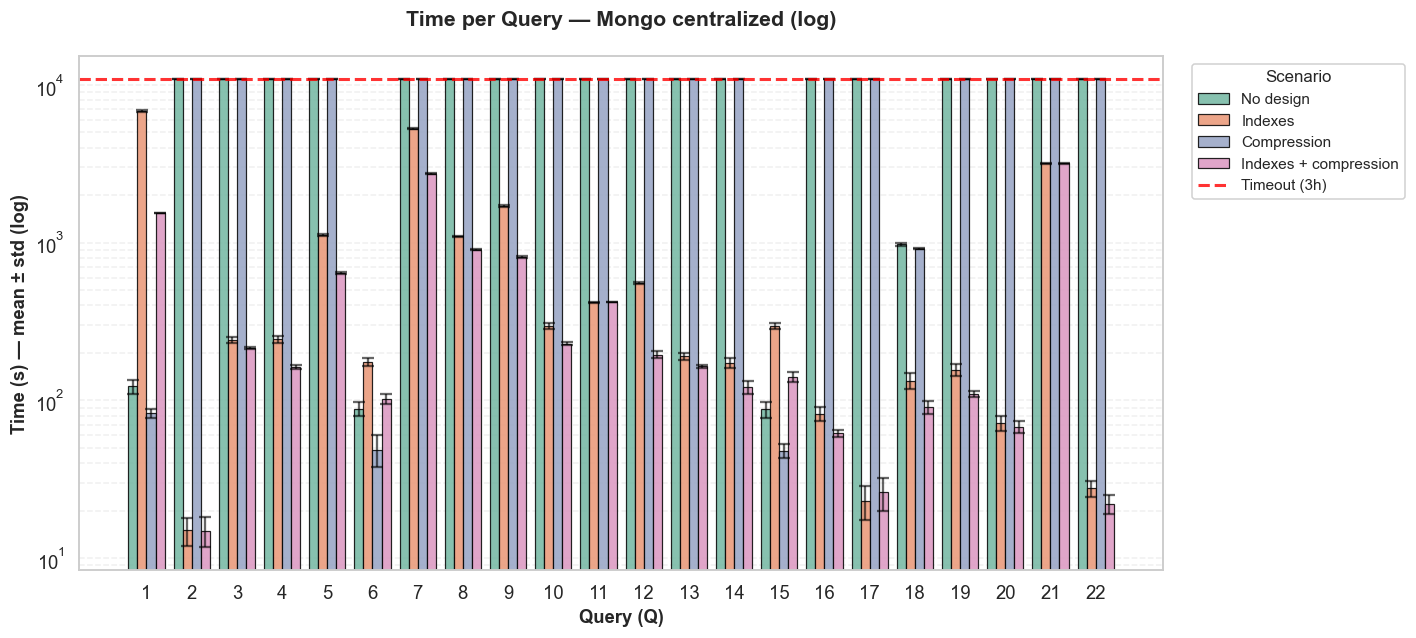

📊 BARRAS (log) — ENERGÍA | FRAGMENTADO vs CENTRALIZADO


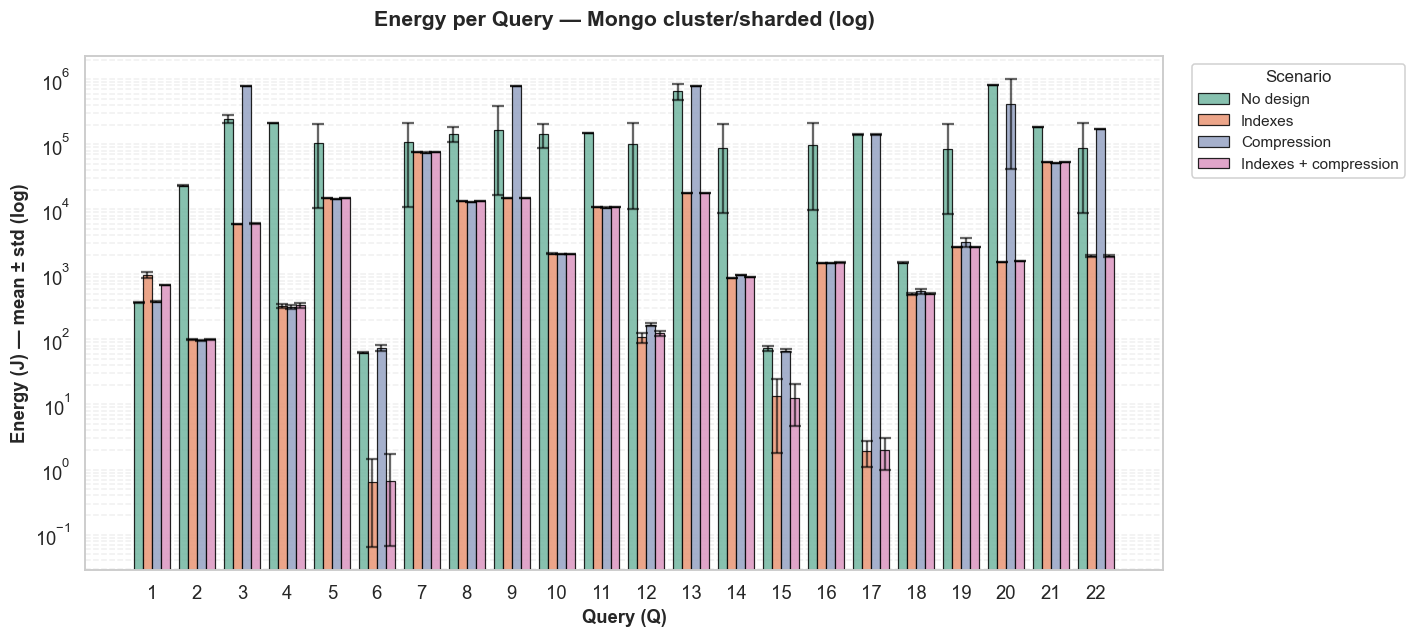

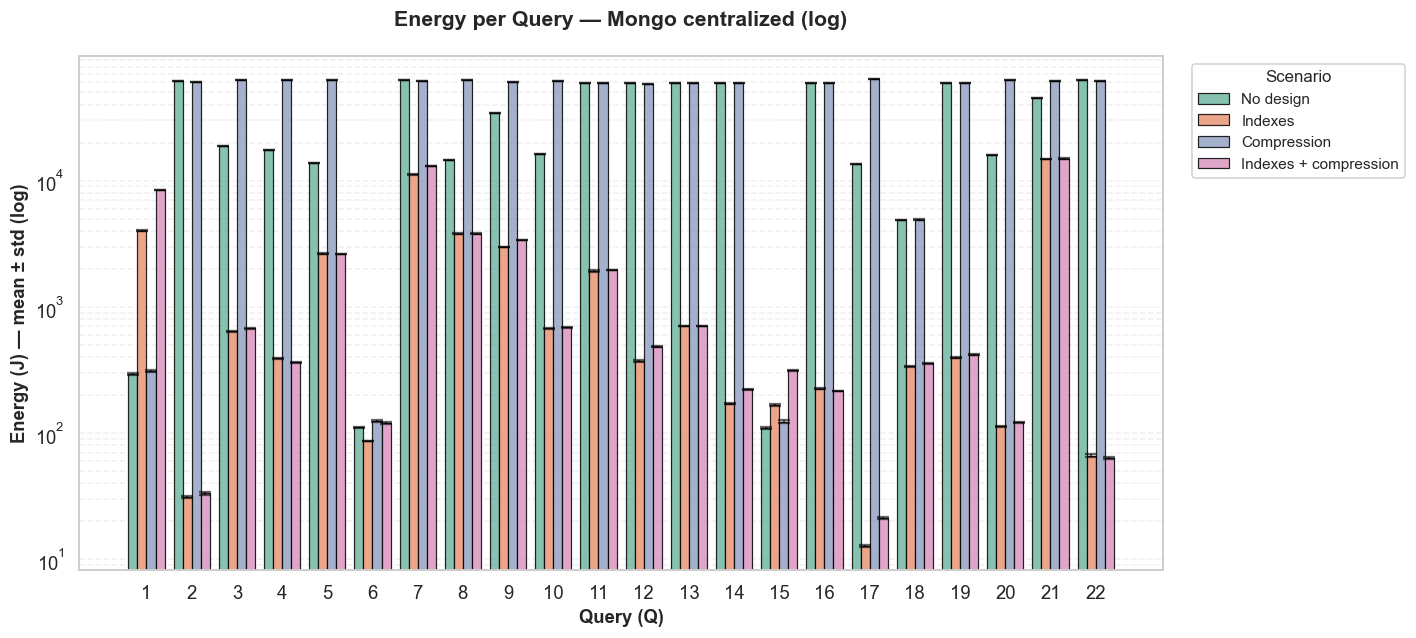

In [124]:
# =============================
# Celda: GRÁFICAS — ESCALA LOG (PROMEDIOS ± STD, hasta N iteraciones)
# Orden para comparar fácil:
# 1) TIEMPO (log): FRAGMENTADO vs CENTRALIZADO
# 2) ENERGÍA (log): FRAGMENTADO vs CENTRALIZADO
# =============================
if "df_statsN_M" not in globals() or not isinstance(df_statsN_M, pd.DataFrame) or len(df_statsN_M) == 0:
    raise RuntimeError("No encuentro `df_statsN_M`. Ejecuta primero la celda de ESTADÍSTICAS (cluster/fragmentado).")
if "df_statsN_central_M" not in globals() or not isinstance(df_statsN_central_M, pd.DataFrame) or len(df_statsN_central_M) == 0:
    raise RuntimeError("No encuentro `df_statsN_central_M`. Ejecuta primero la celda de ESTADÍSTICAS — CENTRALIZADO.")

print("=" * 80)
print("📊 BARRAS (log) — TIEMPO | FRAGMENTADO vs CENTRALIZADO")
print("=" * 80)
bar_mean_std_M(
    df_statsN_M,
    mean_col="mean_time",
    std_col="std_time",
    ylabel="Time (s) — mean ± std (log)",
    title="Time per Query — Mongo cluster/sharded (log)",
    log_scale=True,
    annotate_counts=False,
    add_timeout_line=True,
)
bar_mean_std_M(
    df_statsN_central_M,
    mean_col="mean_time",
    std_col="std_time",
    ylabel="Time (s) — mean ± std (log)",
    title="Time per Query — Mongo centralized (log)",
    log_scale=True,
    annotate_counts=False,
    add_timeout_line=True,
)

print("=" * 80)
print("📊 BARRAS (log) — ENERGÍA | FRAGMENTADO vs CENTRALIZADO")
print("=" * 80)
bar_mean_std_M(
    df_statsN_M,
    mean_col="mean_energy",
    std_col="std_energy",
    ylabel="Energy (J) — mean ± std (log)",
    title="Energy per Query — Mongo cluster/sharded (log)",
    log_scale=True,
    annotate_counts=False,
    add_timeout_line=False,
)
bar_mean_std_M(
    df_statsN_central_M,
    mean_col="mean_energy",
    std_col="std_energy",
    ylabel="Energy (J) — mean ± std (log)",
    title="Energy per Query — Mongo centralized (log)",
    log_scale=True,
    annotate_counts=False,
    add_timeout_line=False,
)

In [125]:
# =============================
# Celda: RANKING — Mejor diseño por Wilcoxon (tiempo y energía por separado)
# Lógica por cada par de escenarios, por cada query:
#   - Ambos timeout            → empate negativo (0 pts a nadie)
#   - Solo A completó          → A gana automáticamente (+2 pts)
#   - Solo B completó          → B gana automáticamente (+2 pts)
#   - Ambos completaron        → Wilcoxon unilateral (menor = mejor)
#                                  p < ALPHA → ganador +2 pts
#                                  p >= ALPHA → empate estadístico (+1 a cada uno)
# Ranking: por tipo de BD (cluster/sharded y centralizado) + global combinado
# Métricas: tiempo (elapsed_s) y energía (energy_J) por separado
# =============================
from itertools import combinations
from scipy.stats import wilcoxon
import pandas as pd
import numpy as np
from IPython.display import display

EPS = 1e-9

if "df_iterN_M" not in globals() or not isinstance(df_iterN_M, pd.DataFrame) or len(df_iterN_M) == 0:
    raise RuntimeError("Falta df_iterN_M (cluster). Ejecuta la celda de ESTADÍSTICAS — MONGO CLUSTER/SHARDED.")
if "df_iterN_central_M" not in globals() or not isinstance(df_iterN_central_M, pd.DataFrame) or len(df_iterN_central_M) == 0:
    raise RuntimeError("Falta df_iterN_central_M. Ejecuta la celda de ESTADÍSTICAS — MONGO CENTRALIZADO.")
if "SCENARIO_ORDER_M" not in globals():
    raise RuntimeError("Falta SCENARIO_ORDER_M.")
if "TIMEOUT_S_M" not in globals():
    raise RuntimeError("Falta TIMEOUT_S_M.")
if "ALPHA" not in globals():
    ALPHA = 0.05

# --------------------------------------------------------------------------
# Helper: comparar dos escenarios en una métrica, para un tipo de BD
# --------------------------------------------------------------------------
def _compare_pair(df_iter, scen_a, scen_b, metric_col, tipo_bd_label):
    """
    Compara escen_a vs escen_b query a query.
    Retorna lista de dicts con resultado por query.
    """
    queries = sorted(df_iter["Q"].dropna().unique())
    results = []

    for q in queries:
        da = df_iter[(df_iter["scenario"] == scen_a) & (df_iter["Q"] == q)].copy()
        db = df_iter[(df_iter["scenario"] == scen_b) & (df_iter["Q"] == q)].copy()

        # Filtrar solo iteraciones completadas (no timeout, no imputed)
        da_ok = da[(da["is_timeout"] == False) & (da.get("is_imputed", False) == False)][metric_col].dropna()
        db_ok = db[(db["is_timeout"] == False) & (db.get("is_imputed", False) == False)][metric_col].dropna()

        a_completed = len(da_ok) > 0
        b_completed = len(db_ok) > 0

        if not a_completed and not b_completed:
            outcome = "empate_negativo"
            winner = None
            p_value = np.nan

        elif a_completed and not b_completed:
            outcome = "auto_win_a"
            winner = scen_a
            p_value = np.nan

        elif not a_completed and b_completed:
            outcome = "auto_win_b"
            winner = scen_b
            p_value = np.nan

        else:
            # Ambos completaron → Wilcoxon unilateral
            # Necesitamos pares alineados por iteración si es posible,
            # o muestras independientes si no hay alineación
            iters_a = set(da_ok.index) if hasattr(da_ok, 'index') else set()
            # Usar valores directamente (pueden ser distinto n)
            vals_a = da_ok.values
            vals_b = db_ok.values

            # Si mismo largo → paired Wilcoxon; si no → comparar medias con Mann-Whitney
            if len(vals_a) == len(vals_b) and len(vals_a) >= 2:
                diff = vals_a - vals_b
                if np.all(diff == 0):
                    outcome = "empate_estadistico"
                    winner = None
                    p_value = 1.0
                else:
                    try:
                        stat, p_value = wilcoxon(vals_a, vals_b, alternative="less")
                        if p_value < ALPHA:
                            outcome = "win_a"
                            winner = scen_a
                        else:
                            stat2, p_value2 = wilcoxon(vals_a, vals_b, alternative="greater")
                            if p_value2 < ALPHA:
                                outcome = "win_b"
                                winner = scen_b
                                p_value = p_value2
                            else:
                                outcome = "empate_estadistico"
                                winner = None
                    except Exception:
                        outcome = "empate_estadistico"
                        winner = None
                        p_value = np.nan
            else:
                # Distinto n o solo 1 obs → comparar por mediana
                med_a = float(np.median(vals_a))
                med_b = float(np.median(vals_b))
                p_value = np.nan
                if abs(med_a - med_b) < EPS:
                    outcome = "empate_estadistico"
                    winner = None
                elif med_a < med_b:
                    outcome = "win_a_mediana"
                    winner = scen_a
                else:
                    outcome = "win_b_mediana"
                    winner = scen_b

        results.append({
            "tipo_bd": tipo_bd_label,
            "metric": metric_col,
            "Q": int(q),
            "scen_a": scen_a,
            "scen_b": scen_b,
            "n_a": len(da_ok),
            "n_b": len(db_ok),
            "outcome": outcome,
            "winner": winner,
            "p_value": round(float(p_value), 4) if np.isfinite(p_value) else np.nan,
        })
    return results


# --------------------------------------------------------------------------
# Helper: construir ranking desde lista de resultados de comparaciones
# --------------------------------------------------------------------------
def _build_ranking(all_results, scenarios):
    records = []
    for scen in scenarios:
        pts = 0
        wins = 0
        auto_wins = 0
        losses = 0
        neg_ties = 0
        stat_ties = 0
        for r in all_results:
            if r["scen_a"] != scen and r["scen_b"] != scen:
                continue
            out = r["outcome"]
            if out == "empate_negativo":
                neg_ties += 1
            elif out == "empate_estadistico":
                pts += 1
                stat_ties += 1
            elif r["winner"] == scen:
                pts += 2
                if "auto" in out:
                    auto_wins += 1
                else:
                    wins += 1
            elif r["winner"] is not None and r["winner"] != scen:
                losses += 1
        records.append({
            "escenario": scen,
            "puntos": pts,
            "victorias_wilcoxon": wins,
            "victorias_automaticas": auto_wins,
            "empates_estadisticos": stat_ties,
            "empates_negativos (ambos TO)": neg_ties,
            "derrotas": losses,
        })
    return (
        pd.DataFrame(records)
        .sort_values("puntos", ascending=False)
        .reset_index(drop=True)
    )


# --------------------------------------------------------------------------
# Ejecutar comparaciones para cada tipo de BD y métrica
# --------------------------------------------------------------------------
datasets = {
    "cluster_sharded": df_iterN_M,
    "centralizado": df_iterN_central_M,
}

METRICS = {
    "elapsed_s": "⏱️  TIEMPO",
    "energy_J":  "⚡ ENERGÍA",
}

all_comparisons = []  # acumula todo para ranking global

print("=" * 90)
print("🏆 RANKING — Mejor diseño por Wilcoxon (solo iteraciones completadas)")
print(f"   Alpha = {ALPHA} | Métrica: TIEMPO y ENERGÍA por separado")
print(f"   Reglas: timeout en ambos → empate negativo | solo uno completó → gana automático")
print("=" * 90)

ranking_by_bd = {}  # para ranking global

for tipo_bd, df_iter in datasets.items():
    df_iter = df_iter.copy()
    # Asegurar columna is_imputed
    if "is_imputed" not in df_iter.columns:
        df_iter["is_imputed"] = False

    print(f"\n{'━'*90}")
    print(f"  BASE DE DATOS: {tipo_bd.upper()}")
    print(f"{'━'*90}")

    for metric_col, metric_label in METRICS.items():
        if metric_col not in df_iter.columns:
            print(f"  ⚠️  Columna '{metric_col}' no encontrada en {tipo_bd}, se omite.")
            continue

        print(f"\n  {metric_label}")
        print(f"  {'─'*80}")

        pair_results = []
        for scen_a, scen_b in combinations(SCENARIO_ORDER_M, 2):
            res = _compare_pair(df_iter, scen_a, scen_b, metric_col, tipo_bd)
            pair_results.extend(res)
            all_comparisons.extend([{**r, "tipo_bd_global": tipo_bd} for r in res])

        # Tabla detalle de comparaciones
        df_detail = pd.DataFrame(pair_results)
        print(f"\n  Detalle por query (par de escenarios):")
        display(
            df_detail[["Q","scen_a","scen_b","n_a","n_b","outcome","winner","p_value"]]
            .sort_values(["scen_a","scen_b","Q"])
            .reset_index(drop=True)
        )

        # Ranking para este tipo_bd + métrica
        ranking = _build_ranking(pair_results, SCENARIO_ORDER_M)
        ranking_key = (tipo_bd, metric_col)
        ranking_by_bd[ranking_key] = ranking

        print(f"\n  🏅 Ranking — {tipo_bd} | {metric_label}:")
        display(ranking)


# --------------------------------------------------------------------------
# Ranking global combinado (suma de puntos en ambas BDs)
# --------------------------------------------------------------------------
print(f"\n{'═'*90}")
print("🌐 RANKING GLOBAL COMBINADO (cluster/sharded + centralizado)")
print(f"{'═'*90}")

for metric_col, metric_label in METRICS.items():
    print(f"\n  {metric_label} — ranking global:")
    res_metric = [r for r in all_comparisons if r["metric"] == metric_col]
    ranking_global = _build_ranking(res_metric, SCENARIO_ORDER_M)
    display(ranking_global)

print("\n✅ Análisis Wilcoxon completado.")


🏆 RANKING — Mejor diseño por Wilcoxon (solo iteraciones completadas)
   Alpha = 0.05 | Métrica: TIEMPO y ENERGÍA por separado
   Reglas: timeout en ambos → empate negativo | solo uno completó → gana automático

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  BASE DE DATOS: CLUSTER_SHARDED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ⏱️  TIEMPO
  ────────────────────────────────────────────────────────────────────────────────

  Detalle por query (par de escenarios):


,Q,scen_a,scen_b,n_a,n_b,outcome,winner,p_value
0,1,compresion,indice_compresion,10,10,win_a,compresion,0.0010
1,2,compresion,indice_compresion,10,10,win_a,compresion,0.0010
2,3,compresion,indice_compresion,0,10,auto_win_b,indice_compresion,NaN
3,4,compresion,indice_compresion,10,10,empate_estadistico,NaN,0.8125
4,5,compresion,indice_compresion,10,10,win_a,compresion,0.0010
...,...,...,...,...,...,...,...,...
127,18,sindiseno,indices,10,10,win_b,indices,0.0010
128,19,sindiseno,indices,0,10,auto_win_b,indices,NaN
129,20,sindiseno,indices,0,10,auto_win_b,indices,NaN
130,21,sindiseno,indices,0,10,auto_win_b,indices,NaN



  🏅 Ranking — cluster_sharded | ⏱️  TIEMPO:


,escenario,puntos,victorias_wilcoxon,victorias_automaticas,empates_estadisticos,empates_negativos (ambos TO),derrotas
0,indices,94,22,20,10,0,14
1,indice_compresion,80,15,20,10,0,21
2,compresion,71,21,10,9,5,21
3,sindiseno,9,4,0,1,5,56



  ⚡ ENERGÍA
  ────────────────────────────────────────────────────────────────────────────────

  Detalle por query (par de escenarios):


...


══════════════════════════════════════════════════════════════════════════════════════════
🌐 RANKING GLOBAL COMBINADO (cluster/sharded + centralizado)
══════════════════════════════════════════════════════════════════════════════════════════

  ⏱️  TIEMPO — ranking global:


,escenario,puntos,victorias_wilcoxon,victorias_automaticas,empates_estadisticos,empates_negativos (ambos TO),derrotas
0,indice_compresion,193,34,56,13,0,29
1,indices,177,26,56,13,0,37
2,compresion,91,31,10,9,23,59
3,sindiseno,21,10,0,1,23,98



  ⚡ ENERGÍA — ranking global:


,escenario,puntos,victorias_wilcoxon,victorias_automaticas,empates_estadisticos,empates_negativos (ambos TO),derrotas
0,indices,215,46,56,11,0,19
1,indice_compresion,164,21,56,10,0,45
2,compresion,76,27,10,2,23,70
3,sindiseno,27,13,0,1,23,95



✅ Análisis Wilcoxon completado.


## Gráfico (fragmentado): % de trabajo por shard (mismo contenido, nuevo layout)
- Un subplot por escenario (`indices`, `indice_compresion`)
- Eje X: Query (Q)
- Barra apilada a 100%: porcentaje por shard
- El % se escribe dentro de cada segmento (si el segmento es suficientemente grande)

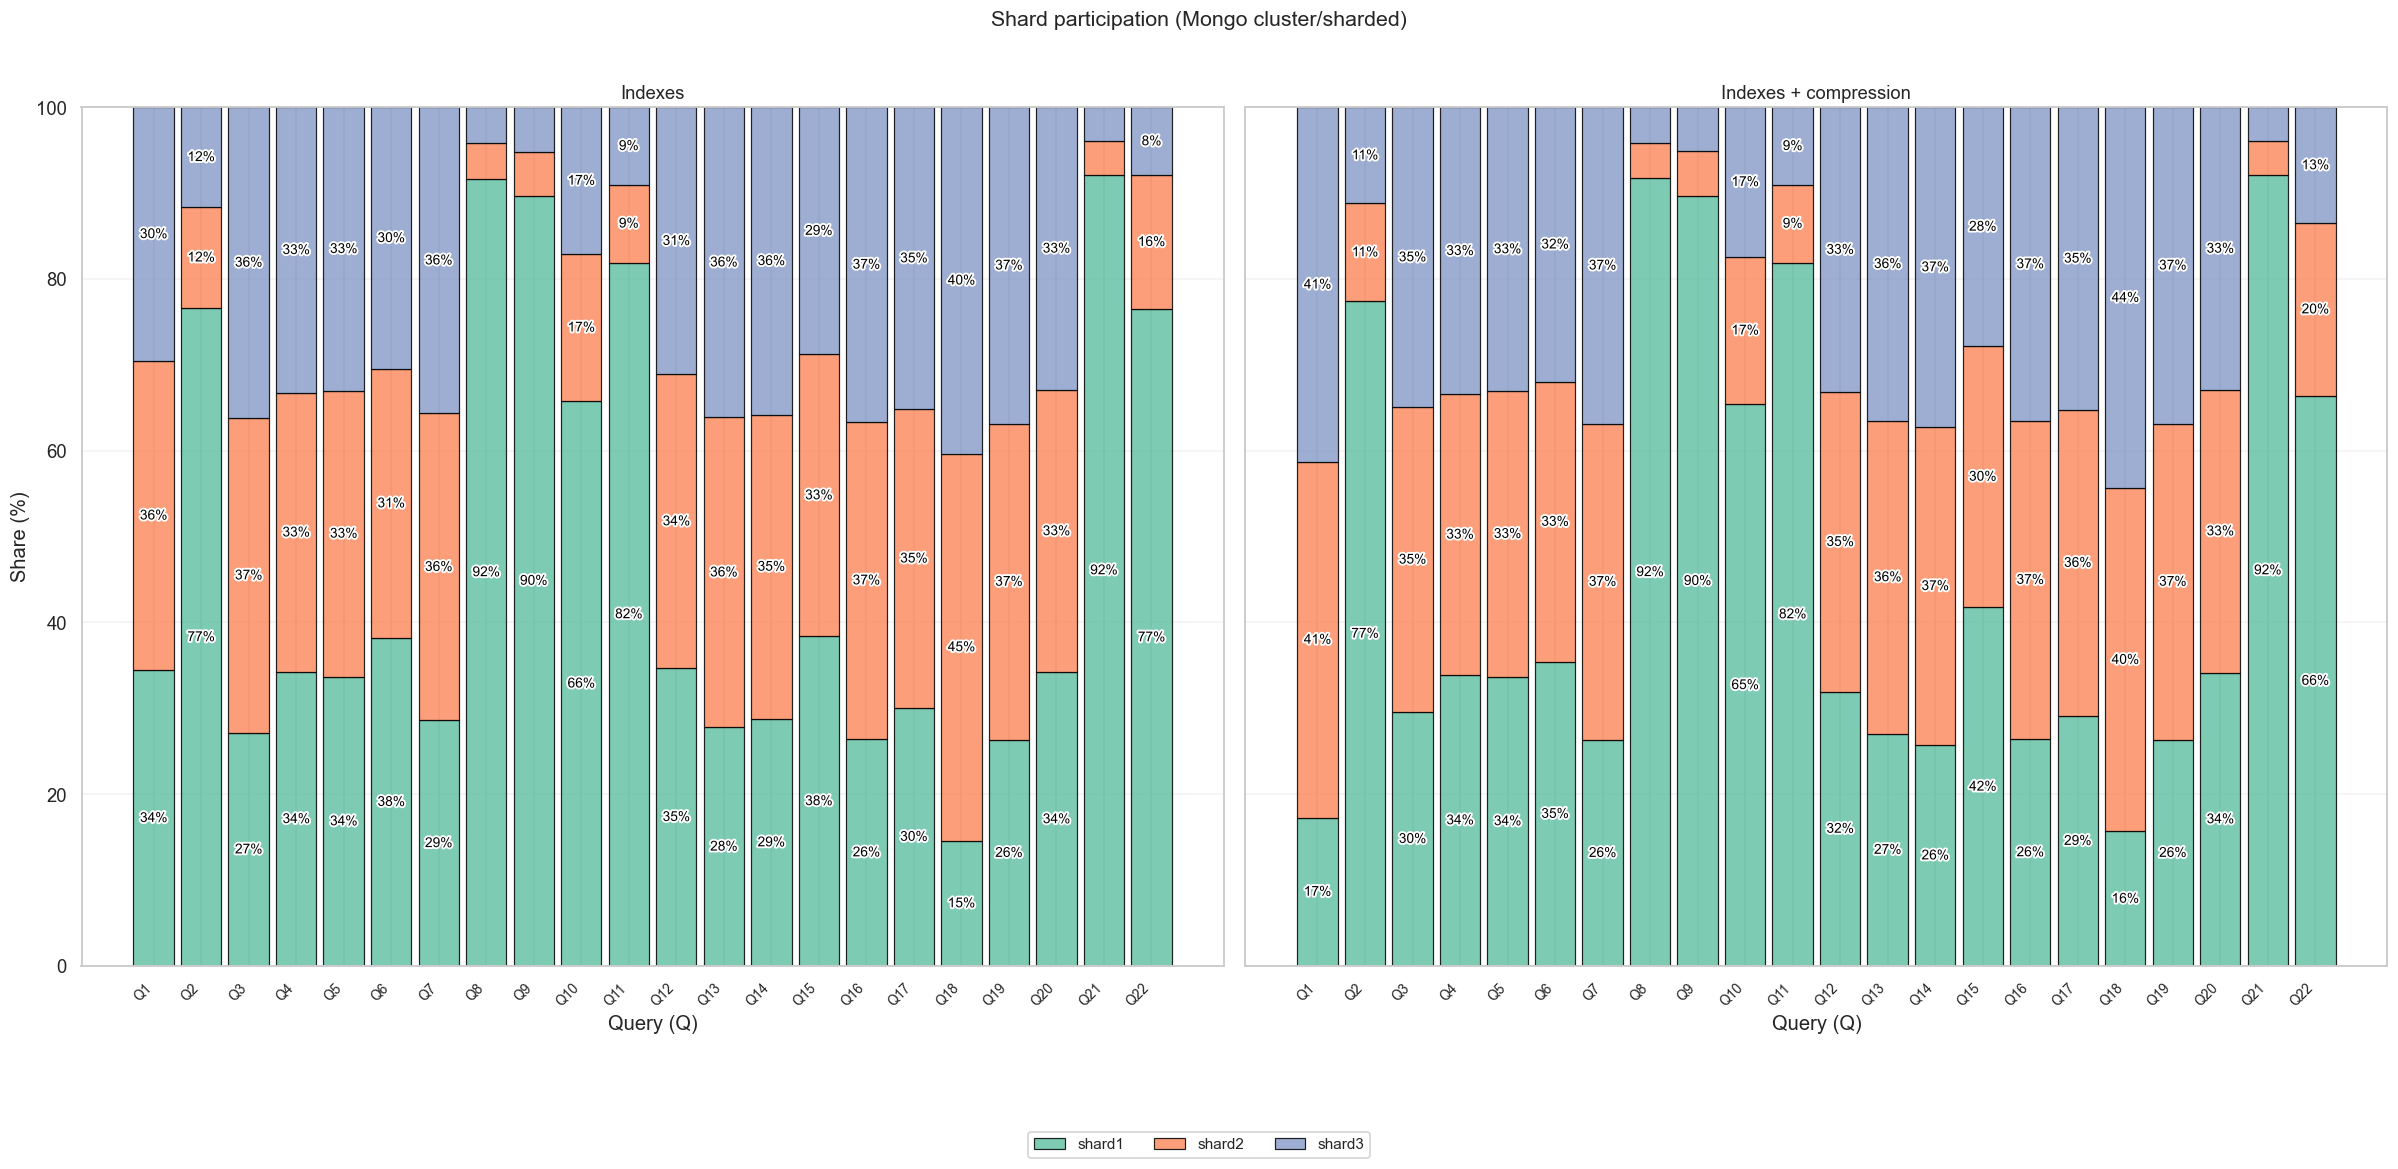

In [126]:
# =============================
# Gráfico (fragmentado/cluster): "real" para paralelismo (solo cambia la visualización)
# - Contenido: % por shard (promedio) por Query y por escenario (indices vs indice_compresion)
# - Layout: 1 subplot por escenario, como el ejemplo compartido
# =============================

import re
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns

SCENARIOS_TO_PLOT = ["indices", "indice_compresion"]

def _qnum_from_path_local(p: str):
    p = str(p).replace("\\", "/")
    m = re.search(r"/(?:q)?(\d+)/(?:q)?(\d+)_energy_metrics\.csv$", p)
    if m:
        q_dir = int(m.group(1))
        q_file = int(m.group(2))
        return q_dir if q_dir != q_file else q_file
    m = re.search(r"/(?:^|/)(?:q)?(\d+)(?:/|$)", p)
    return int(m.group(1)) if m else None

def _pick(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _detect_exec_cols(df: pd.DataFrame) -> list[str]:
    preferred = [
        "exec_ms_shard1 (ms)", "exec_ms_shard2 (ms)", "exec_ms_shard3 (ms)",
        "exec_ms_shard1", "exec_ms_shard2", "exec_ms_shard3",
    ]
    cols = [c for c in preferred if c in df.columns]
    if cols:
        return cols
    all_cols = [c for c in df.columns if "exec_ms" in str(c).lower()]
    def _key(x):
        s = str(x).lower()
        m = re.search(r"shard(\d+)", s)
        return (0, int(m.group(1))) if m else (1, s)
    return sorted(all_cols, key=_key)

def _shard_label(col: str) -> str:
    s = str(col)
    s = re.sub(r"^exec_ms_", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s*\(.*\)\s*$", "", s)
    return s.strip()

def _build_df_files_cluster_filtered() -> pd.DataFrame:
    if "DATA_ROOT_M" not in globals() or "SCENARIOS_ALL_M" not in globals() or "CSV_GLOB_M" not in globals():
        raise RuntimeError("Faltan DATA_ROOT_M/SCENARIOS_ALL_M/CSV_GLOB_M. Ejecuta las celdas 3 y 4 primero.")
    root = Path(DATA_ROOT_M)
    recs = []
    for scenario_key, base in SCENARIOS_ALL_M.items():
        if str(scenario_key) not in SCENARIOS_TO_PLOT:
            continue
        pattern = str(root / base / CSV_GLOB_M)
        for path in sorted(glob.glob(pattern)):
            recs.append({"scenario": str(scenario_key), "path": path, "Q": _qnum_from_path_local(path)})
    return pd.DataFrame(recs) if recs else pd.DataFrame(columns=["scenario", "path", "Q"])

def _extract_iter_data(df_files_like: pd.DataFrame):
    # pct_recs: participación por shard en % (por iteración)
    pct_recs = []
    total_recs = []

    for r in df_files_like.dropna(subset=["path"]).itertuples(index=False):
        scen = str(getattr(r, "scenario"))
        path = getattr(r, "path")
        Q = getattr(r, "Q", None)
        Q = int(Q) if (Q is not None and pd.notna(Q)) else _qnum_from_path_local(path)
        if Q is None:
            continue

        df = pd.read_csv(path)
        col_elapsed = _pick(df, ["elapsed_time_seconds (s)", "elapsed_time_seconds", "elapsed_seconds"])
        if col_elapsed is None:
            continue

        exec_cols = _detect_exec_cols(df)
        if not exec_cols:
            continue

        if "row_type" in df.columns:
            rt = df["row_type"].astype(str).str.strip().str.lower()
            finals = df[rt.eq("final")].copy()
            if finals.empty:
                finals = df.tail(1).copy()
        else:
            finals = df.tail(1).copy()

        it_col = "iteration" if "iteration" in finals.columns else None

        for idx, row in finals.iterrows():
            it = int(row[it_col]) if (it_col and pd.notna(row[it_col])) else int(idx)
            elapsed_s = pd.to_numeric(row.get(col_elapsed, np.nan), errors="coerce")
            if not np.isfinite(elapsed_s):
                continue
            elapsed_s = float(elapsed_s)

            shard_vals = []
            exec_vals = []
            for c in exec_cols:
                v = pd.to_numeric(row.get(c, np.nan), errors="coerce")
                if np.isfinite(v) and v > 0:
                    shard_vals.append((_shard_label(c), float(v)))
                    exec_vals.append(float(v))

            sum_exec = float(np.nansum(exec_vals))
            if not np.isfinite(sum_exec) or sum_exec <= 0:
                continue

            total_recs.append({"Q": Q, "scenario": scen, "iteration": it, "elapsed_s": elapsed_s})
            for shard, v in shard_vals:
                pct_recs.append({"Q": Q, "scenario": scen, "iteration": it, "shard": shard, "pct": 100.0 * (v / sum_exec)})

    pct_long = pd.DataFrame(pct_recs)
    total_long = pd.DataFrame(total_recs)

    if not pct_long.empty:
        pct_long["scenario"] = pd.Categorical(pct_long["scenario"].astype(str), categories=SCENARIOS_TO_PLOT, ordered=True)
    if not total_long.empty:
        total_long["scenario"] = pd.Categorical(total_long["scenario"].astype(str), categories=SCENARIOS_TO_PLOT, ordered=True)

    return pct_long, total_long

df_files_like = _build_df_files_cluster_filtered()
if df_files_like.empty:
    raise RuntimeError("No encontré CSVs para `indices`/`indice_compresion` en el repo fragmentado.")

pct_long, total_long = _extract_iter_data(df_files_like)
if pct_long.empty or total_long.empty:
    raise RuntimeError("No pude extraer iteraciones (`row_type == final`), `elapsed_time_seconds` y `exec_ms_shard*` de los CSV filtrados.")

# Promedio de % por shard
pct_mean = (
    pct_long.groupby(["Q", "scenario", "shard"], observed=True)["pct"]
    .mean()
    .rename("pct_mean")
    .reset_index()
 )

qs = sorted(total_long["Q"].dropna().astype(int).unique().tolist())
cfgs_plot = [s for s in SCENARIOS_TO_PLOT if s in pct_mean["scenario"].astype(str).unique().tolist()]
shards = sorted(
    pct_mean["shard"].dropna().astype(str).unique().tolist(),
    key=lambda s: (0, int(re.search(r"(\d+)$", s).group(1))) if re.search(r"(\d+)$", s) else (1, s),
 )

mat = (
    pct_mean.pivot_table(index=["Q", "scenario"], columns="shard", values="pct_mean", aggfunc="first", dropna=False)
    .reindex(pd.MultiIndex.from_product([qs, cfgs_plot], names=["Q", "scenario"]))
    .fillna(0.0)
 )
mat = mat.reindex(columns=shards)

# Re-normalizar a 100% por barra (por si faltan shards en algún caso)
row_sum = mat.sum(axis=1)
mat_pct = mat.div(row_sum.replace(0, np.nan), axis=0).fillna(0.0) * 100.0

# Layout tipo ejemplo: 1 subplot por configuración
n_cfg = len(cfgs_plot)
ncols = 2 if n_cfg > 1 else 1
nrows = int(np.ceil(n_cfg / ncols))
fig_w = max(22, len(qs) * 0.9)
fig_h = max(10, nrows * 5.6)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h), sharey=True)
axes = np.array(axes).reshape(-1)

shard_colors = {s: c for s, c in zip(shards, sns.color_palette("Set2", n_colors=max(len(shards), 3)))}

LABEL_MIN_PCT = 7.0  # no etiquetar segmentos muy pequeños
label_effects = [pe.withStroke(linewidth=2.5, foreground="white")]

for i, cfg in enumerate(cfgs_plot):
    ax = axes[i]
    sub = mat_pct.xs(cfg, level="scenario").reindex(qs)
    if sub.empty:
        ax.set_title(_scenario_label_en_M(cfg))
        ax.axis("off")
        continue

    x = np.arange(len(qs))
    bottoms = np.zeros(len(qs), dtype=float)

    for shard in shards:
        vals = sub[shard].to_numpy(dtype=float)
        y_center = bottoms + (vals / 2.0)
        ax.bar(
            x,
            vals,
            bottom=bottoms,
            color=shard_colors.get(shard),
            width=0.85,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.85,
            label=(shard if i == 0 else None),
        )
        for j, v in enumerate(vals):
            if np.isfinite(v) and v >= LABEL_MIN_PCT:
                ax.text(
                    float(x[j]),
                    float(y_center[j]),
                    f"{v:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black",
                    path_effects=label_effects,
                )
        bottoms = bottoms + vals

    ax.set_title(_scenario_label_en_M(cfg), fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{q}" for q in qs], rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Query (Q)")
    ax.grid(axis="y", alpha=0.25)
    if i % ncols == 0:
        ax.set_ylabel("Share (%)")
    ax.set_ylim(0, 100)

for k in range(n_cfg, len(axes)):
    axes[k].axis("off")

fig.suptitle("Shard participation (Mongo cluster/sharded)", fontsize=14, y=1.00)
handles, labels = axes[0].get_legend_handles_labels()
if labels:
    fig.legend(handles, labels, loc="lower center", ncols=min(len(labels), 8), framealpha=0.9, fontsize=10, bbox_to_anchor=(0.5, -0.05))

fig.tight_layout(rect=[0, 0.05, 1, 0.99])
plt.show()

---
## 8. Test de Wilcoxon — Hive

In [127]:
# =============================
# Celda: TESTS PAREADOS (Wilcoxon) + ranking de diseños (CENTRAL vs CLÚSTER/FRAGMENTADO)
# - Trata cada alternativa como una configuración: (tipo_bd × escenario)
#   => 8 alternativas (4 escenarios × 2 BDs) si existen datos para ambas BDs.
# - Compara configuraciones por pares usando Wilcoxon pareado (por Q).
# - Ajusta p-values con Holm-Bonferroni (opcional).
# - Devuelve ranking por 'victorias' significativas y también el 'mejor' descriptivo (mediana menor).
# =============================

TIPOS_BD_ORDER = ["hive_cluster_fragmentado", "hive_centralizado"]


def _pick_source(name_stats: str, name_single: str):
    """Devuelve (df, time_col, energy_col, src_name) prefiriendo stats, si no single."""
    if name_stats in globals() and isinstance(globals()[name_stats], pd.DataFrame) and len(globals()[name_stats]) > 0:
        return globals()[name_stats].copy(), "mean_time", "mean_energy", name_stats
    if name_single in globals() and isinstance(globals()[name_single], pd.DataFrame) and len(globals()[name_single]) > 0:
        return globals()[name_single].copy(), "elapsed_s", "energy_J", name_single
    return None, None, None, None


# --- 1) Tomar fuentes para ambas BDs ---
df_frag, tcol_frag, ecol_frag, src_frag = _pick_source("df_statsN_H", "df_single_H")
df_cent, tcol_cent, ecol_cent, src_cent = _pick_source("df_statsN_central_H", "df_single_central_H")

if df_frag is None or df_cent is None:
    raise RuntimeError(
        "Faltan datos para una de las BDs. Necesito df_statsN_H/df_single_H (clúster/fragmentado) y df_statsN_central_H/df_single_central_H (central)."
    )


def _normalize(df: pd.DataFrame, tipo_bd: str, time_col: str, energy_col: str) -> pd.DataFrame:
    d = df.copy()
    if "scenario" not in d.columns or "Q" not in d.columns:
        raise ValueError(f"Fuente no tiene columnas esperadas: scenario/Q ({tipo_bd})")
    d["scenario"] = d["scenario"].astype(str)
    d = d[d["scenario"].isin(list(SCENARIO_ORDER_H))].copy()
    d["scenario"] = pd.Categorical(d["scenario"], categories=list(SCENARIO_ORDER_H), ordered=True)
    d["Q"] = pd.to_numeric(d["Q"], errors="coerce").astype("Int64")
    d["tipo_bd"] = tipo_bd
    d["time_s"] = pd.to_numeric(d[time_col], errors="coerce")
    d["energy_J"] = pd.to_numeric(d[energy_col], errors="coerce")
    return d[["tipo_bd", "scenario", "Q", "time_s", "energy_J"]].dropna(subset=["Q"])


df_frag_n = _normalize(df_frag, "hive_cluster_fragmentado", tcol_frag, ecol_frag)
df_cent_n = _normalize(df_cent, "hive_centralizado", tcol_cent, ecol_cent)

df_all = pd.concat([df_frag_n, df_cent_n], ignore_index=True)
df_all["tipo_bd"] = pd.Categorical(df_all["tipo_bd"], categories=TIPOS_BD_ORDER, ordered=True)

df_all["config"] = df_all["tipo_bd"].astype(str) + "|" + df_all["scenario"].astype(str)
CONFIG_ORDER = [f"{bd}|{sc}" for bd in TIPOS_BD_ORDER for sc in SCENARIO_ORDER_H]


# --- 2) Helpers estadísticos ---
def holm_adjust(p_values):
    """Ajuste Holm-Bonferroni. Devuelve p ajustadas (mismo orden)."""
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    if m == 0:
        return p_values
    order = np.argsort(p_values)
    ranked = p_values[order]
    adj = np.empty(m, dtype=float)
    for i, p in enumerate(ranked):
        adj[i] = (m - i) * p
    adj = np.maximum.accumulate(adj)
    adj = np.clip(adj, 0.0, 1.0)
    out = np.empty(m, dtype=float)
    out[order] = adj
    return out


def wilcoxon_pairwise(pivot: pd.DataFrame, labels, metric_name: str):
    """Pairwise Wilcoxon (pareado) para una métrica. Retorna df resultados."""
    rows = []
    labels = list(labels)
    for a, b in combinations(labels, 2):
        xa = pivot[a]
        xb = pivot[b]

        mask = np.isfinite(xa) & np.isfinite(xb) & xa.notna() & xb.notna()
        xa2 = xa[mask].astype(float)
        xb2 = xb[mask].astype(float)

        n = int(len(xa2))
        if n == 0:
            rows.append({
                "metric": metric_name,
                "A": a, "B": b, "n": 0,
                "median_A": np.nan, "median_B": np.nan,
                "median_diff(A-B)": np.nan,
                "better": "NA",
                "p_raw(one-sided)": np.nan,
            })
            continue

        diffs = (xa2.values - xb2.values)
        med_a = float(np.median(xa2.values))
        med_b = float(np.median(xb2.values))
        med_diff = float(np.median(diffs))

        if np.allclose(diffs, 0):
            rows.append({
                "metric": metric_name,
                "A": a, "B": b, "n": n,
                "median_A": med_a, "median_B": med_b,
                "median_diff(A-B)": 0.0,
                "better": "tie",
                "p_raw(one-sided)": 1.0,
            })
            continue

        # Alternativa: test one-sided hacia el ganador observado por mediana (menor = mejor)
        alternative = "less" if med_diff < 0 else "greater"
        better = a if med_diff < 0 else b

        try:
            _, p = stats.wilcoxon(
                xa2.values, xb2.values,
                alternative=alternative,
                zero_method="pratt",
                method="auto",
            )
            p = float(p)
        except ValueError:
            p = np.nan

        rows.append({
            "metric": metric_name,
            "A": a, "B": b, "n": n,
            "median_A": med_a, "median_B": med_b,
            "median_diff(A-B)": med_diff,
            "better": better,
            "p_raw(one-sided)": p,
        })

    df_res = pd.DataFrame(rows)
    if APPLY_HOLM:
        pvals = df_res["p_raw(one-sided)"].to_numpy(dtype=float)
        maskp = np.isfinite(pvals)
        adj = np.full_like(pvals, np.nan, dtype=float)
        adj[maskp] = holm_adjust(pvals[maskp])
        df_res["p_holm"] = adj
    else:
        df_res["p_holm"] = np.nan
    return df_res


def config_ranking(df_pairs: pd.DataFrame, labels, p_col: str):
    """Ranking por 'victorias' significativas (p<alpha) basadas en df de pares."""
    labels = list(labels)
    wins = {c: 0 for c in labels}
    losses = {c: 0 for c in labels}

    for _, r in df_pairs.iterrows():
        p = r[p_col] if np.isfinite(r[p_col]) else r["p_raw(one-sided)"]
        if not np.isfinite(p):
            continue
        if r["better"] in ("tie", "NA"):
            continue
        if p < ALPHA:
            winner = r["better"]
            loser = r["B"] if winner == r["A"] else r["A"]
            wins[winner] += 1
            losses[loser] += 1

    df_rank = pd.DataFrame({
        "config": labels,
        "wins_sig": [wins[c] for c in labels],
        "losses_sig": [losses[c] for c in labels],
    })
    df_rank["score"] = df_rank["wins_sig"] - df_rank["losses_sig"]
    return df_rank.sort_values(["score", "wins_sig"], ascending=[False, False]).reset_index(drop=True)


# --- 3) Pivots por Q ---
pivot_time = (
    df_all.pivot_table(index="Q", columns="config", values="time_s", aggfunc="mean")
    .reindex(columns=CONFIG_ORDER)
)
pivot_energy = (
    df_all.pivot_table(index="Q", columns="config", values="energy_J", aggfunc="mean")
    .reindex(columns=CONFIG_ORDER)
)

print("=" * 90)
print("✅ WILCOXON PAREADO — Mejor configuración GLOBAL (Hive centralizado vs clúster/fragmentado)")
print("=" * 90)
print(f"Fuentes: cluster={src_frag} | central={src_cent}")
print(f"Configs (tipo_bd|escenario): {CONFIG_ORDER}")
print(f"ALPHA={ALPHA} | APPLY_HOLM={APPLY_HOLM}")

summary_desc = pd.DataFrame({
    "config": CONFIG_ORDER,
    "median_time_s": [pivot_time[c].median(skipna=True) for c in CONFIG_ORDER],
    "median_energy_J": [pivot_energy[c].median(skipna=True) for c in CONFIG_ORDER],
    "n_Q_time": [int(pivot_time[c].notna().sum()) for c in CONFIG_ORDER],
    "n_Q_energy": [int(pivot_energy[c].notna().sum()) for c in CONFIG_ORDER],
})
summary_desc[["tipo_bd", "scenario"]] = summary_desc["config"].str.split("|", expand=True)

print("\n" + "=" * 90)
print("📊 Medianas por configuración (descriptivo; menor = mejor)")
print("=" * 90)
display(summary_desc.sort_values(["median_time_s", "median_energy_J"], ascending=True).reset_index(drop=True))

df_pairs_time = wilcoxon_pairwise(pivot_time, CONFIG_ORDER, metric_name="time")
df_pairs_energy = wilcoxon_pairwise(pivot_energy, CONFIG_ORDER, metric_name="energy")

print("\n" + "=" * 90)
print("⏱️ Wilcoxon por pares — TIEMPO (one-sided hacia el ganador observado)")
print("=" * 90)
display(df_pairs_time.sort_values(["p_holm", "p_raw(one-sided)"], ascending=True))

print("\n" + "=" * 90)
print("⚡ Wilcoxon por pares — ENERGÍA (one-sided hacia el ganador observado)")
print("=" * 90)
display(df_pairs_energy.sort_values(["p_holm", "p_raw(one-sided)"], ascending=True))

pcol = "p_holm" if APPLY_HOLM else "p_raw(one-sided)"
rank_time = config_ranking(df_pairs_time, CONFIG_ORDER, p_col=pcol)
rank_energy = config_ranking(df_pairs_energy, CONFIG_ORDER, p_col=pcol)

print("\n" + "=" * 90)
print("🏁 Ranking por TIEMPO (victorias significativas)")
print("=" * 90)
display(rank_time)

print("\n" + "=" * 90)
print("🏁 Ranking por ENERGÍA (victorias significativas)")
print("=" * 90)
display(rank_energy)

rank_global = (
    rank_time[["config", "score"]].rename(columns={"score": "score_time"})
    .merge(rank_energy[["config", "score"]].rename(columns={"score": "score_energy"}), on="config", how="outer")
)
rank_global["score_time"] = rank_global["score_time"].fillna(0).astype(int)
rank_global["score_energy"] = rank_global["score_energy"].fillna(0).astype(int)
rank_global["score_total"] = rank_global["score_time"] + rank_global["score_energy"]
rank_global = rank_global.sort_values(["score_total", "score_time", "score_energy"], ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("🥇 Ranking global (score_total = score_time + score_energy)")
print("=" * 90)
display(rank_global)

# --- 4) Mejor de todas (resumen compacto) ---
best_desc_time = summary_desc.sort_values(["median_time_s", "median_energy_J"], ascending=True).head(1)
best_desc_energy = summary_desc.sort_values(["median_energy_J", "median_time_s"], ascending=True).head(1)
best_sig_global = rank_global.head(1)

print("\n" + "=" * 90)
print("⭐ Mejor de todas (resumen)")
print("=" * 90)
display(
    pd.DataFrame(
        {
            "criterio": [
                "Descriptivo: menor mediana TIEMPO",
                "Descriptivo: menor mediana ENERGÍA",
                "Significancia: mayor score_total",
            ],
            "config": [
                best_desc_time["config"].iloc[0],
                best_desc_energy["config"].iloc[0],
                best_sig_global["config"].iloc[0],
            ],
            "detalle": [
                f"med_time_s={best_desc_time['median_time_s'].iloc[0]:.3f} | med_energy_J={best_desc_time['median_energy_J'].iloc[0]:.3f}",
                f"med_energy_J={best_desc_energy['median_energy_J'].iloc[0]:.3f} | med_time_s={best_desc_energy['median_time_s'].iloc[0]:.3f}",
                f"score_total={best_sig_global['score_total'].iloc[0]} (time={best_sig_global['score_time'].iloc[0]}, energy={best_sig_global['score_energy'].iloc[0]})",
            ],
        }
    )
)


✅ WILCOXON PAREADO — Mejor configuración GLOBAL (Hive centralizado vs clúster/fragmentado)
Fuentes: cluster=df_statsN_H | central=df_statsN_central_H
Configs (tipo_bd|escenario): ['hive_cluster_fragmentado|sindiseno', 'hive_cluster_fragmentado|indices', 'hive_cluster_fragmentado|compresion', 'hive_cluster_fragmentado|indice_compresion', 'hive_centralizado|sindiseno', 'hive_centralizado|indices', 'hive_centralizado|compresion', 'hive_centralizado|indice_compresion']
ALPHA=0.05 | APPLY_HOLM=True

📊 Medianas por configuración (descriptivo; menor = mejor)


,config,median_time_s,median_energy_J,n_Q_time,n_Q_energy,tipo_bd,scenario
0,hive_cluster_fragmentado|indice_compresion,158.50605,2325.886237,22,22,hive_cluster_fragmentado,indice_compresion
1,hive_cluster_fragmentado|compresion,158.55210,2145.431822,22,22,hive_cluster_fragmentado,compresion
2,hive_cluster_fragmentado|indices,170.52465,3149.725842,22,22,hive_cluster_fragmentado,indices
3,hive_centralizado|compresion,183.19495,2032.563432,22,22,hive_centralizado,compresion
4,hive_cluster_fragmentado|sindiseno,183.85375,4312.718333,22,22,hive_cluster_fragmentado,sindiseno
5,hive_centralizado|indice_compresion,184.78480,2189.558144,22,22,hive_centralizado,indice_compresion
6,hive_centralizado|indices,194.90215,3196.361063,22,22,hive_centralizado,indices
7,hive_centralizado|sindiseno,226.73365,4285.842011,22,22,hive_centralizado,sindiseno



⏱️ Wilcoxon por pares — TIEMPO (one-sided hacia el ganador observado)


,metric,A,B,n,median_A,median_B,median_diff(A-B),better,p_raw(one-sided),p_holm
9,time,hive_cluster_fragmentado|indices,hive_centralizado|sindiseno,22,170.52465,226.73365,-83.98405,hive_cluster_fragmentado|indices,0.000001,0.000033
18,time,hive_cluster_fragmentado|indice_compresion,hive_centralizado|sindiseno,22,158.50605,226.73365,-94.60505,hive_cluster_fragmentado|indice_compresion,0.000002,0.000045
22,time,hive_centralizado|sindiseno,hive_centralizado|indices,22,226.73365,194.90215,47.49090,hive_centralizado|indices,0.000002,0.000045
14,time,hive_cluster_fragmentado|compresion,hive_centralizado|sindiseno,22,158.55210,226.73365,-98.93790,hive_cluster_fragmentado|compresion,0.000002,0.000060
3,time,hive_cluster_fragmentado|sindiseno,hive_centralizado|sindiseno,22,183.85375,226.73365,-74.03325,hive_cluster_fragmentado|sindiseno,0.000003,0.000080
23,time,hive_centralizado|sindiseno,hive_centralizado|compresion,22,226.73365,183.19495,77.46420,hive_centralizado|compresion,0.000008,0.000181
2,time,hive_cluster_fragmentado|sindiseno,hive_cluster_fragmentado|indice_compresion,22,183.85375,158.50605,21.79585,hive_cluster_fragmentado|indice_compresion,0.000010,0.000226
8,time,hive_cluster_fragmentado|indices,hive_cluster_fragmentado|indice_compresion,22,170.52465,158.50605,8.31920,hive_cluster_fragmentado|indice_compresion,0.000010,0.000226
24,time,hive_centralizado|sindiseno,hive_centralizado|indice_compresion,22,226.73365,184.78480,75.54710,hive_centralizado|indice_compresion,0.000010,0.000226
1,time,hive_cluster_fragmentado|sindiseno,hive_cluster_fragmentado|compresion,22,183.85375,158.55210,21.23850,hive_cluster_fragmentado|compresion,0.000021,0.000399



⚡ Wilcoxon por pares — ENERGÍA (one-sided hacia el ganador observado)


...

,config,wins_sig,losses_sig,score
0,hive_centralizado|compresion,5,0,5
1,hive_cluster_fragmentado|compresion,4,0,4
2,hive_cluster_fragmentado|indice_compresion,4,0,4
3,hive_centralizado|indice_compresion,4,1,3
4,hive_cluster_fragmentado|indices,2,4,-2
5,hive_centralizado|indices,2,4,-2
6,hive_cluster_fragmentado|sindiseno,0,6,-6
7,hive_centralizado|sindiseno,0,6,-6



🥇 Ranking global (score_total = score_time + score_energy)


,config,score_time,score_energy,score_total
0,hive_cluster_fragmentado|compresion,6,4,10
1,hive_cluster_fragmentado|indice_compresion,6,4,10
2,hive_centralizado|compresion,0,5,5
3,hive_centralizado|indice_compresion,0,3,3
4,hive_cluster_fragmentado|indices,1,-2,-1
5,hive_cluster_fragmentado|sindiseno,-1,-6,-7
6,hive_centralizado|indices,-5,-2,-7
7,hive_centralizado|sindiseno,-7,-6,-13



⭐ Mejor de todas (resumen)


,criterio,config,detalle
0,Descriptivo: menor mediana TIEMPO,hive_cluster_fragmentado|indice_compresion,med_time_s=158.506 | med_energy_J=2325.886
1,Descriptivo: menor mediana ENERGÍA,hive_centralizado|compresion,med_energy_J=2032.563 | med_time_s=183.195
2,Significancia: mayor score_total,hive_cluster_fragmentado|compresion,"score_total=10 (time=6, energy=4)"


---
## 9. Test de Wilcoxon — Mongo

In [128]:
# =============================
# Celda: TESTS PAREADOS (Wilcoxon) + ranking de diseños (CENTRAL vs SHARDED)
# - Trata cada alternativa como una configuración: (tipo_bd × escenario)
#   => 8 alternativas (4 escenarios × 2 BDs) si existen datos para ambas BDs.
# - Compara configuraciones por pares usando Wilcoxon pareado (por Q).
# - Ajusta p-values con Holm-Bonferroni (opcional).
# - Devuelve ranking por 'victorias' significativas y también el 'mejor' descriptivo (mediana menor).
# =============================

TIPOS_BD_ORDER = ["mongo_cluster_sharded", "mongo_centralizado"]

def _pick_source(name_stats: str, name_single: str):
    """Devuelve (df, time_col, energy_col, src_name) prefiriendo stats, si no single."""
    if name_stats in globals() and isinstance(globals()[name_stats], pd.DataFrame) and len(globals()[name_stats]) > 0:
        return globals()[name_stats].copy(), "mean_time", "mean_energy", name_stats
    if name_single in globals() and isinstance(globals()[name_single], pd.DataFrame) and len(globals()[name_single]) > 0:
        return globals()[name_single].copy(), "elapsed_s", "energy_J", name_single
    return None, None, None, None

# --- 1) Tomar fuentes para ambas BDs ---
df_sh, tcol_sh, ecol_sh, src_sh = _pick_source("df_statsN_M", "df_single_M")
df_ce, tcol_ce, ecol_ce, src_ce = _pick_source("df_statsN_central_M", "df_single_central_M")

if df_sh is None or df_ce is None:
    raise RuntimeError(
        "Faltan datos para una de las BDs. Necesito df_statsN_M/df_single_M (sharded) y df_statsN_central_M/df_single_central_M (central)."
    )

def _normalize(df: pd.DataFrame, tipo_bd: str, time_col: str, energy_col: str) -> pd.DataFrame:
    d = df.copy()
    if "scenario" not in d.columns or "Q" not in d.columns:
        raise ValueError(f"Fuente no tiene columnas esperadas: scenario/Q ({tipo_bd})")
    d["scenario"] = d["scenario"].astype(str)
    d = d[d["scenario"].isin(list(SCENARIO_ORDER_M))].copy()
    d["scenario"] = pd.Categorical(d["scenario"], categories=list(SCENARIO_ORDER_M), ordered=True)
    d["Q"] = pd.to_numeric(d["Q"], errors="coerce").astype("Int64")
    d["tipo_bd"] = tipo_bd
    d["time_s"] = pd.to_numeric(d[time_col], errors="coerce")
    d["energy_J"] = pd.to_numeric(d[energy_col], errors="coerce")
    return d[["tipo_bd", "scenario", "Q", "time_s", "energy_J"]].dropna(subset=["Q"])

df_sh_n = _normalize(df_sh, "mongo_cluster_sharded", tcol_sh, ecol_sh)
df_ce_n = _normalize(df_ce, "mongo_centralizado", tcol_ce, ecol_ce)

df_all = pd.concat([df_sh_n, df_ce_n], ignore_index=True)
df_all["tipo_bd"] = pd.Categorical(df_all["tipo_bd"], categories=TIPOS_BD_ORDER, ordered=True)

df_all["config"] = df_all["tipo_bd"].astype(str) + "|" + df_all["scenario"].astype(str)
CONFIG_ORDER = [f"{bd}|{sc}" for bd in TIPOS_BD_ORDER for sc in SCENARIO_ORDER_M]

# --- 2) Helpers estadísticos ---
def holm_adjust(p_values):
    """Ajuste Holm-Bonferroni. Devuelve p ajustadas (mismo orden)."""
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    if m == 0:
        return p_values
    order = np.argsort(p_values)
    ranked = p_values[order]
    adj = np.empty(m, dtype=float)
    for i, p in enumerate(ranked):
        adj[i] = (m - i) * p
    adj = np.maximum.accumulate(adj)
    adj = np.clip(adj, 0.0, 1.0)
    out = np.empty(m, dtype=float)
    out[order] = adj
    return out

def wilcoxon_pairwise(pivot: pd.DataFrame, labels, metric_name: str):
    """Pairwise Wilcoxon (pareado) para una métrica. Retorna df resultados."""
    rows = []
    labels = list(labels)
    for a, b in combinations(labels, 2):
        xa = pivot[a]
        xb = pivot[b]

        mask = np.isfinite(xa) & np.isfinite(xb) & xa.notna() & xb.notna()
        xa2 = xa[mask].astype(float)
        xb2 = xb[mask].astype(float)

        n = int(len(xa2))
        if n == 0:
            rows.append({
                "metric": metric_name,
                "A": a, "B": b, "n": 0,
                "median_A": np.nan, "median_B": np.nan,
                "median_diff(A-B)": np.nan,
                "better": "NA",
                "p_raw(one-sided)": np.nan,
            })
            continue

        diffs = (xa2.values - xb2.values)
        med_a = float(np.median(xa2.values))
        med_b = float(np.median(xb2.values))
        med_diff = float(np.median(diffs))

        if np.allclose(diffs, 0):
            rows.append({
                "metric": metric_name,
                "A": a, "B": b, "n": n,
                "median_A": med_a, "median_B": med_b,
                "median_diff(A-B)": 0.0,
                "better": "tie",
                "p_raw(one-sided)": 1.0,
            })
            continue

        # Alternativa: test one-sided hacia el ganador observado por mediana (menor = mejor)
        alternative = "less" if med_diff < 0 else "greater"
        better = a if med_diff < 0 else b

        try:
            _, p = stats.wilcoxon(
                xa2.values, xb2.values,
                alternative=alternative,
                zero_method="pratt",
                method="auto",
            )
            p = float(p)
        except ValueError:
            p = np.nan

        rows.append({
            "metric": metric_name,
            "A": a, "B": b, "n": n,
            "median_A": med_a, "median_B": med_b,
            "median_diff(A-B)": med_diff,
            "better": better,
            "p_raw(one-sided)": p,
        })

    df_res = pd.DataFrame(rows)
    if APPLY_HOLM:
        pvals = df_res["p_raw(one-sided)"].to_numpy(dtype=float)
        maskp = np.isfinite(pvals)
        adj = np.full_like(pvals, np.nan, dtype=float)
        adj[maskp] = holm_adjust(pvals[maskp])
        df_res["p_holm"] = adj
    else:
        df_res["p_holm"] = np.nan
    return df_res

def config_ranking(df_pairs: pd.DataFrame, labels, p_col: str):
    """Ranking por 'victorias' significativas (p<alpha) basadas en df de pares."""
    labels = list(labels)
    wins = {c: 0 for c in labels}
    losses = {c: 0 for c in labels}

    for _, r in df_pairs.iterrows():
        p = r[p_col] if np.isfinite(r[p_col]) else r["p_raw(one-sided)"]
        if not np.isfinite(p):
            continue
        if r["better"] in ("tie", "NA"):
            continue
        if p < ALPHA:
            winner = r["better"]
            loser = r["B"] if winner == r["A"] else r["A"]
            wins[winner] += 1
            losses[loser] += 1

    df_rank = pd.DataFrame({
        "config": labels,
        "wins_sig": [wins[c] for c in labels],
        "losses_sig": [losses[c] for c in labels],
    })
    df_rank["score"] = df_rank["wins_sig"] - df_rank["losses_sig"]
    return df_rank.sort_values(["score", "wins_sig"], ascending=[False, False]).reset_index(drop=True)

# --- 3) Pivots por Q ---
pivot_time = (
    df_all.pivot_table(index="Q", columns="config", values="time_s", aggfunc="mean")
    .reindex(columns=CONFIG_ORDER)
 )
pivot_energy = (
    df_all.pivot_table(index="Q", columns="config", values="energy_J", aggfunc="mean")
    .reindex(columns=CONFIG_ORDER)
 )

print("=" * 90)
print("✅ WILCOXON PAREADO — Mejor configuración GLOBAL (centralizada vs sharded)")
print("=" * 90)
print(f"Fuentes: sharded={src_sh} | central={src_ce}")
print(f"Configs (tipo_bd|escenario): {CONFIG_ORDER}")
print(f"ALPHA={ALPHA} | APPLY_HOLM={APPLY_HOLM}")

summary_desc = pd.DataFrame({
    "config": CONFIG_ORDER,
    "median_time_s": [pivot_time[c].median(skipna=True) for c in CONFIG_ORDER],
    "median_energy_J": [pivot_energy[c].median(skipna=True) for c in CONFIG_ORDER],
    "n_Q_time": [int(pivot_time[c].notna().sum()) for c in CONFIG_ORDER],
    "n_Q_energy": [int(pivot_energy[c].notna().sum()) for c in CONFIG_ORDER],
})
summary_desc[["tipo_bd", "scenario"]] = summary_desc["config"].str.split("|", expand=True)

print("\n" + "=" * 90)
print("📊 Medianas por configuración (descriptivo; menor = mejor)")
print("=" * 90)
display(summary_desc.sort_values(["median_time_s", "median_energy_J"], ascending=True).reset_index(drop=True))

df_pairs_time = wilcoxon_pairwise(pivot_time, CONFIG_ORDER, metric_name="time")
df_pairs_energy = wilcoxon_pairwise(pivot_energy, CONFIG_ORDER, metric_name="energy")

print("\n" + "=" * 90)
print("⏱️ Wilcoxon por pares — TIEMPO (one-sided hacia el ganador observado)")
print("=" * 90)
display(df_pairs_time.sort_values(["p_holm", "p_raw(one-sided)"], ascending=True))

print("\n" + "=" * 90)
print("⚡ Wilcoxon por pares — ENERGÍA (one-sided hacia el ganador observado)")
print("=" * 90)
display(df_pairs_energy.sort_values(["p_holm", "p_raw(one-sided)"], ascending=True))

pcol = "p_holm" if APPLY_HOLM else "p_raw(one-sided)"
rank_time = config_ranking(df_pairs_time, CONFIG_ORDER, p_col=pcol)
rank_energy = config_ranking(df_pairs_energy, CONFIG_ORDER, p_col=pcol)

print("\n" + "=" * 90)
print("🏁 Ranking por TIEMPO (victorias significativas)")
print("=" * 90)
display(rank_time)

print("\n" + "=" * 90)
print("🏁 Ranking por ENERGÍA (victorias significativas)")
print("=" * 90)
display(rank_energy)

rank_global = (
    rank_time[["config", "score"]].rename(columns={"score": "score_time"})
    .merge(rank_energy[["config", "score"]].rename(columns={"score": "score_energy"}), on="config", how="outer")
 )
rank_global["score_time"] = rank_global["score_time"].fillna(0).astype(int)
rank_global["score_energy"] = rank_global["score_energy"].fillna(0).astype(int)
rank_global["score_total"] = rank_global["score_time"] + rank_global["score_energy"]
rank_global = rank_global.sort_values(["score_total", "score_time", "score_energy"], ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("🥇 Ranking global (score_total = score_time + score_energy)")
print("=" * 90)
display(rank_global)

# --- 4) Mejor de todas (resumen compacto) ---
best_desc_time = summary_desc.sort_values(["median_time_s", "median_energy_J"], ascending=True).head(1)
best_desc_energy = summary_desc.sort_values(["median_energy_J", "median_time_s"], ascending=True).head(1)
best_sig_global = rank_global.head(1)

print("\n" + "=" * 90)
print("⭐ Mejor de todas (resumen)")
print("=" * 90)
display(pd.DataFrame({
    "criterio": ["Descriptivo: menor mediana TIEMPO", "Descriptivo: menor mediana ENERGÍA", "Significancia: mayor score_total"],
    "config": [best_desc_time["config"].iloc[0], best_desc_energy["config"].iloc[0], best_sig_global["config"].iloc[0]],
    "detalle": [
        f"med_time_s={best_desc_time['median_time_s'].iloc[0]:.3f} | med_energy_J={best_desc_time['median_energy_J'].iloc[0]:.3f}",
        f"med_energy_J={best_desc_energy['median_energy_J'].iloc[0]:.3f} | med_time_s={best_desc_energy['median_time_s'].iloc[0]:.3f}",
        f"score_total={best_sig_global['score_total'].iloc[0]} (time={best_sig_global['score_time'].iloc[0]}, energy={best_sig_global['score_energy'].iloc[0]})",
    ],
}))

✅ WILCOXON PAREADO — Mejor configuración GLOBAL (centralizada vs sharded)
Fuentes: sharded=df_statsN_M | central=df_statsN_central_M
Configs (tipo_bd|escenario): ['mongo_cluster_sharded|sindiseno', 'mongo_cluster_sharded|indices', 'mongo_cluster_sharded|compresion', 'mongo_cluster_sharded|indice_compresion', 'mongo_centralizado|sindiseno', 'mongo_centralizado|indices', 'mongo_centralizado|compresion', 'mongo_centralizado|indice_compresion']
ALPHA=0.05 | APPLY_HOLM=True

📊 Medianas por configuración (descriptivo; menor = mejor)


,config,median_time_s,median_energy_J,n_Q_time,n_Q_energy,tipo_bd,scenario
0,mongo_centralizado|indice_compresion,163.36605,450.655212,22,22,mongo_centralizado,indice_compresion
1,mongo_cluster_sharded|indices,171.68315,1730.791025,22,22,mongo_cluster_sharded,indices
2,mongo_cluster_sharded|indice_compresion,171.93620,1755.940769,22,22,mongo_cluster_sharded,indice_compresion
3,mongo_centralizado|indices,242.28890,392.168875,22,22,mongo_centralizado,indices
4,mongo_cluster_sharded|compresion,693.10295,6879.077821,22,22,mongo_cluster_sharded,compresion
5,mongo_centralizado|sindiseno,10800.00000,26466.744963,22,22,mongo_centralizado,sindiseno
6,mongo_centralizado|compresion,10800.00000,60970.682915,22,22,mongo_centralizado,compresion
7,mongo_cluster_sharded|sindiseno,10800.00000,107130.876124,22,22,mongo_cluster_sharded,sindiseno



⏱️ Wilcoxon por pares — TIEMPO (one-sided hacia el ganador observado)


,metric,A,B,n,median_A,median_B,median_diff(A-B),better,p_raw(one-sided),p_holm
9,time,mongo_cluster_sharded|indices,mongo_centralizado|sindiseno,22,171.68315,10800.00000,-10356.34875,mongo_cluster_sharded|indices,2.384186e-07,0.000007
11,time,mongo_cluster_sharded|indices,mongo_centralizado|compresion,22,171.68315,10800.00000,-10356.34875,mongo_cluster_sharded|indices,2.384186e-07,0.000007
18,time,mongo_cluster_sharded|indice_compresion,mongo_centralizado|sindiseno,22,171.93620,10800.00000,-10354.90000,mongo_cluster_sharded|indice_compresion,2.384186e-07,0.000007
20,time,mongo_cluster_sharded|indice_compresion,mongo_centralizado|compresion,22,171.93620,10800.00000,-10354.90000,mongo_cluster_sharded|indice_compresion,2.384186e-07,0.000007
0,time,mongo_cluster_sharded|sindiseno,mongo_cluster_sharded|indices,22,10800.00000,171.68315,9433.95135,mongo_cluster_sharded|indices,1.192093e-06,0.000029
2,time,mongo_cluster_sharded|sindiseno,mongo_cluster_sharded|indice_compresion,22,10800.00000,171.93620,9425.25595,mongo_cluster_sharded|indice_compresion,1.192093e-06,0.000029
6,time,mongo_cluster_sharded|sindiseno,mongo_centralizado|indice_compresion,22,10800.00000,163.36605,10159.68310,mongo_centralizado|indice_compresion,4.529953e-06,0.000100
24,time,mongo_centralizado|sindiseno,mongo_centralizado|indice_compresion,22,10800.00000,163.36605,10578.44425,mongo_centralizado|indice_compresion,4.529953e-06,0.000100
27,time,mongo_centralizado|compresion,mongo_centralizado|indice_compresion,22,10800.00000,163.36605,10578.44425,mongo_centralizado|indice_compresion,4.529953e-06,0.000100
22,time,mongo_centralizado|sindiseno,mongo_centralizado|indices,22,10800.00000,242.28890,10443.40505,mongo_centralizado|indices,5.960464e-06,0.000113



⚡ Wilcoxon por pares — ENERGÍA (one-sided hacia el ganador observado)


...

,config,wins_sig,losses_sig,score
0,mongo_centralizado|indices,7,0,7
1,mongo_centralizado|indice_compresion,6,1,5
2,mongo_cluster_sharded|indices,4,2,2
3,mongo_cluster_sharded|indice_compresion,3,3,0
4,mongo_cluster_sharded|compresion,0,2,-2
5,mongo_centralizado|sindiseno,1,4,-3
6,mongo_centralizado|compresion,1,4,-3
7,mongo_cluster_sharded|sindiseno,0,6,-6



🥇 Ranking global (score_total = score_time + score_energy)


,config,score_time,score_energy,score_total
0,mongo_centralizado|indice_compresion,4,5,9
1,mongo_centralizado|indices,2,7,9
2,mongo_cluster_sharded|indices,3,2,5
3,mongo_cluster_sharded|indice_compresion,3,0,3
4,mongo_cluster_sharded|compresion,3,-2,1
5,mongo_centralizado|compresion,-5,-3,-8
6,mongo_centralizado|sindiseno,-5,-3,-8
7,mongo_cluster_sharded|sindiseno,-5,-6,-11



⭐ Mejor de todas (resumen)


,criterio,config,detalle
0,Descriptivo: menor mediana TIEMPO,mongo_centralizado|indice_compresion,med_time_s=163.366 | med_energy_J=450.655
1,Descriptivo: menor mediana ENERGÍA,mongo_centralizado|indices,med_energy_J=392.169 | med_time_s=242.289
2,Significancia: mayor score_total,mongo_centralizado|indice_compresion,"score_total=9 (time=4, energy=5)"


---
## 10. Radar Charts — Comparación multidimensional

Cada radar compara los **escenarios de diseño** sobre 5 ejes normalizados (0–100, mayor = mejor):

| Eje | Descripción | Fuente |
|---|---|---|
| **Completion Rate** | % de queries que completaron | `completion_rate` |
| **Speed Score** | Eficiencia temporal (inverso de `mean_time`) | `mean_time` |
| **Energy Efficiency** | Eficiencia energética (inverso de `mean_energy`) | `mean_energy` |
| **Time Stability** | Consistencia temporal (inverso de `cv_time`) | `std_time / mean_time` |
| **Energy Stability** | Consistencia energética (inverso de `cv_energy`) | `std_energy / mean_energy` |

Se generan **3 imágenes**:
1. Hive Cluster / Fragmentado  
2. Hive Centralizado  
3. Mongo Cluster / Sharded


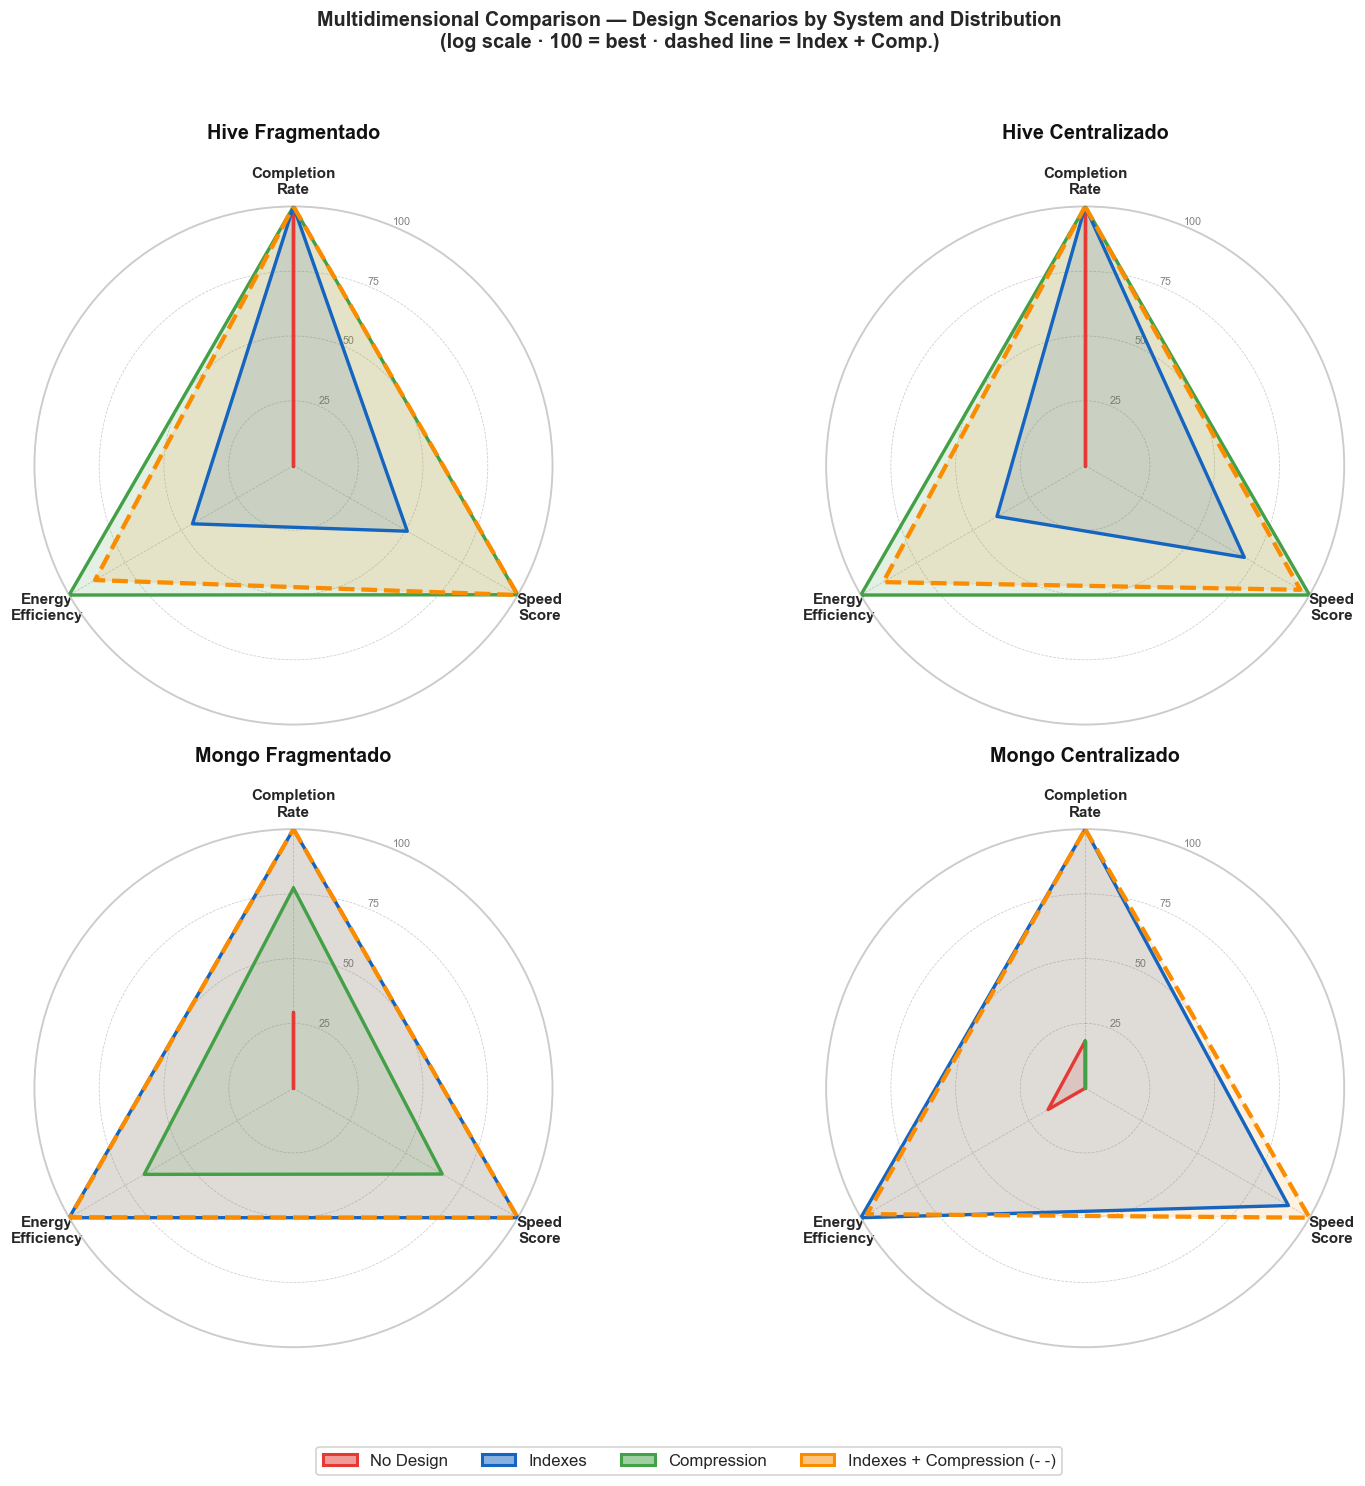

✅ Guardado: radar_all_configs.png
✅ Guardado: radar_hive_fragmentado.png
✅ Guardado: radar_hive_centralizado.png
✅ Guardado: radar_mongo_fragmentado.png
✅ Guardado: radar_mongo_centralizado.png


In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba

TIMEOUT_S = 10_800.0
AXES_LABELS = ["Completion\nRate", "Speed\nScore", "Energy\nEfficiency"]

SCEN_COLORS = {
    "sindiseno":         "#E53935",
    "indices":           "#1565C0",
    "compresion":        "#43A047",
    "indice_compresion": "#FB8C00",
}
SCEN_LABELS = {
    "sindiseno":         "No Design",
    "indices":           "Indexes",
    "compresion":        "Compression",
    "indice_compresion": "Indexes + Compression",
}
# Escenarios que usan línea discontinua para diferenciarse cuando se solapan
SCEN_DASH = {"indice_compresion"}

PANELS = [
    ("Hive Fragmentado",   "df_statsN_H",          "SCENARIO_ORDER_H"),
    ("Hive Centralizado",  "df_statsN_central_H",   "SCENARIO_ORDER_H"),
    ("Mongo Fragmentado",  "df_statsN_M",            "SCENARIO_ORDER_M"),
    ("Mongo Centralizado", "df_statsN_central_M",    "SCENARIO_ORDER_M"),
]


def _get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _metrics_per_scenario(df, scenario_order):
    d = df.copy()
    cr_col = _get_col(d, ["completion_rate", "completionrate"])
    if cr_col is None and {"n_completed", "n_iters_obs"}.issubset(d.columns):
        d["_cr"] = d["n_completed"] / d["n_iters_obs"].replace(0, np.nan)
        cr_col = "_cr"
    mt_col = _get_col(d, ["mean_time", "meantime"])
    me_col = _get_col(d, ["mean_energy", "meanenergy"])

    out = {}
    for scen in scenario_order:
        key = str(scen)
        sub = d[d["scenario"].astype(str) == key]
        if sub.empty:
            continue

        cr_vals = pd.to_numeric(sub[cr_col], errors="coerce").dropna() if cr_col else pd.Series(dtype=float)
        cr = float(cr_vals.mean()) if len(cr_vals) > 0 else 0.0

        mt_vals = pd.to_numeric(sub[mt_col], errors="coerce").dropna() if mt_col else pd.Series(dtype=float)
        mt_vals = mt_vals[mt_vals > 0]
        mt = float(mt_vals.median()) if len(mt_vals) > 0 else TIMEOUT_S

        me_vals = pd.to_numeric(sub[me_col], errors="coerce").dropna() if me_col else pd.Series(dtype=float)
        me_vals = me_vals[me_vals > 0]
        me = float(me_vals.median()) if len(me_vals) > 0 else 1.0

        out[key] = {
            "completion_rate": float(np.clip(cr, 0.0, 1.0)),
            "mean_time":       mt,
            "mean_energy":     me,
        }
    return out


def _build_scores(raw_dict):
    scens = list(raw_dict.keys())
    scores = {s: {} for s in scens}
    keys = ["completion_rate", "mean_time", "mean_energy"]
    for ax_key, ax_label in zip(keys, AXES_LABELS):
        vals = np.array([raw_dict[s][ax_key] for s in scens], dtype=float)
        if ax_key == "completion_rate":
            for i, s in enumerate(scens):
                scores[s][ax_label] = float(np.clip(vals[i] * 100.0, 0.0, 100.0))
            continue
        vals_log = np.log10(np.clip(vals, 1e-6, None))
        vmin, vmax = vals_log.min(), vals_log.max()
        for i, s in enumerate(scens):
            if vmax == vmin:
                scores[s][ax_label] = 100.0
            else:
                scores[s][ax_label] = float(100.0 * (vmax - vals_log[i]) / (vmax - vmin))
    return scores


def _draw_one_radar(ax, panel_name, scenario_order, scores, angles):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(["25", "50", "75", "100"], fontsize=7, color="grey")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(AXES_LABELS, fontsize=10, fontweight="bold")
    ax.grid(color="grey", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.set_title(panel_name, size=13, fontweight="bold", pad=18, color="#111")

    # Orden: los discontinuos se dibujan AL FINAL para quedar siempre visibles
    solid_order = [s for s in ["sindiseno", "compresion", "indices"]
                   if s in scores and s not in SCEN_DASH]
    dash_order  = [s for s in scenario_order if str(s) in scores and str(s) in SCEN_DASH]
    # añadir cualquiera que no esté en ninguno de los dos
    extra = [str(s) for s in scenario_order
             if str(s) in scores and str(s) not in solid_order and str(s) not in dash_order]
    draw_order = solid_order + extra + dash_order

    for scen in draw_order:
        key   = str(scen)
        if key not in scores:
            continue
        sc    = scores[key]
        color = SCEN_COLORS.get(key, "#999999")
        vals  = [sc[lb] for lb in AXES_LABELS] + [sc[AXES_LABELS[0]]]
        is_dash = key in SCEN_DASH

        ax.plot(
            angles, vals,
            linewidth=2.2 if not is_dash else 2.8,
            color=color,
            linestyle="--" if is_dash else "-",
            zorder=4 if is_dash else 3,
        )
        ax.fill(angles, vals, alpha=0.12 if is_dash else 0.15, color=color)


def plot_radar_all_configs():
    for _v in ["df_statsN_H", "df_statsN_central_H",
               "df_statsN_M", "df_statsN_central_M"]:
        if _v not in globals():
            raise RuntimeError(f"No encuentro '{_v}'.")

    N      = len(AXES_LABELS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

    fig, axes = plt.subplots(2, 2, figsize=(15, 13),
                             subplot_kw=dict(polar=True))
    axes = axes.flatten()

    for idx, (panel_name, df_var, order_var) in enumerate(PANELS):
        if df_var not in globals() or order_var not in globals():
            axes[idx].set_visible(False)
            continue
        df    = globals()[df_var]
        order = [str(s) for s in globals()[order_var]]
        raw    = _metrics_per_scenario(df, order)
        scored = _build_scores(raw)
        _draw_one_radar(axes[idx], panel_name, order, scored, angles)

    # Leyenda — línea sólida vs discontinua reflejada
    handles = []
    for s in ["sindiseno", "indices", "compresion", "indice_compresion"]:
        is_dash = s in SCEN_DASH
        patch = mpatches.Patch(
            facecolor=to_rgba(SCEN_COLORS[s], 0.5),
            edgecolor=SCEN_COLORS[s], linewidth=2,
            label=SCEN_LABELS[s] + (" (- -)" if is_dash else ""),
        )
        handles.append(patch)

    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=11,
               framealpha=0.9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle(
        "Multidimensional Comparison — Design Scenarios by System and Distribution\n"
        "(log scale · 100 = best · dashed line = Index + Comp.)",
        size=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    plt.savefig("radar_all_configs.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Guardado: radar_all_configs.png")

    # ── Individuales ─────────────────────────────────────────────────
    for panel_name, df_var, order_var in PANELS:
        if df_var not in globals() or order_var not in globals():
            continue
        df    = globals()[df_var]
        order = [str(s) for s in globals()[order_var]]
        raw    = _metrics_per_scenario(df, order)
        scored = _build_scores(raw)

        fig2, ax2 = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
        _draw_one_radar(ax2, panel_name, order, scored, angles)
        handles2 = []
        for s in order:
            if s not in SCEN_COLORS:
                continue
            is_dash = s in SCEN_DASH
            handles2.append(mpatches.Patch(
                facecolor=to_rgba(SCEN_COLORS[s], 0.5),
                edgecolor=SCEN_COLORS[s], linewidth=2,
                label=SCEN_LABELS.get(s, s) + (" (- -)" if is_dash else ""),
            ))
        ax2.legend(handles=handles2, loc="upper left",
                   bbox_to_anchor=(1.12, 1.12), fontsize=10, framealpha=0.9)
        plt.tight_layout(rect=[0, 0, 0.82, 1])
        fname_ind = f"radar_{panel_name.lower().replace(' ', '_')}.png"
        plt.savefig(fname_ind, dpi=150, bbox_inches="tight")
        plt.close()
        print(f"✅ Guardado: {fname_ind}")


plot_radar_all_configs()


In [130]:
# ══════════════════════════════════════════════════════════════════════
# Helper para radares por consulta (tiempo MEDIANO por Q) — restaurado
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

ALL_QUERIES = list(range(1, 23))

def _get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _time_per_query(df, scenario, all_queries):
    tcol = _get_col(df, ["mean_time", "meantime"])
    if tcol is None or "Q" not in df.columns or "scenario" not in df.columns:
        return np.full(len(all_queries), np.nan)
    sub = df[df["scenario"].astype(str) == str(scenario)]
    if sub.empty:
        return np.full(len(all_queries), np.nan)
    g = (sub.assign(_t=pd.to_numeric(sub[tcol], errors="coerce"))
            .groupby("Q")["_t"].median())
    return np.array([g.get(q, np.nan) for q in all_queries], dtype=float)


In [131]:
# ══════════════════════════════════════════════════════════════════════
# RADAR POR CONSULTA — UN SOLO grafico por motor: Distribuido vs Centralizado
# color = diseno fisico ; linestyle = despliegue (solida=distribuido, --=central)
# Funcion generica: 'designs' permite limitar los disenos (p.ej. sin diseno + mejor)
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

_DEPL_STYLE = [("Distributed", "-", 0.08), ("Centralized", "--", 0.00)]


def plot_single_radar(df_dist, df_cent, engine, scale="linear",
                      designs=None, subtitle=None, outfile=None):
    """Radar de 22 ejes: disenos (color) x despliegues (linestyle) en un solo grafico.
    designs=None usa las 4 configuraciones; o pasa una lista, p.ej.
    ['sindiseno','compresion'] para 'sin diseno + mejor diseno'."""
    log = (scale == "log")
    order = [str(s) for s in (designs if designs is not None
                              else globals()["SCENARIO_ORDER_H"])]
    N = len(ALL_QUERIES)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

    allv = np.concatenate([_time_per_query(df, s, ALL_QUERIES)
                           for df in (df_dist, df_cent) for s in order])
    finite = allv[np.isfinite(allv)]
    if log:
        rmin = 1.0
        rmax = float(min(TIMEOUT_S, np.ceil(np.nanmax(finite)/100.0)*100.0)) if finite.size else TIMEOUT_S
    else:
        rmax = float(np.ceil(np.nanmax(finite)/50.0)*50.0) if finite.size else 750.0
        rmin = 0.0

    fig = plt.figure(figsize=(11, 11.8))
    ax = fig.add_subplot(111, polar=True)
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    if log:
        ax.set_rscale("symlog", linthresh=rmin)
    ax.set_ylim(rmin, rmax)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f"Q{q}" for q in ALL_QUERIES], fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", pad=8)
    ax.grid(color="grey", linestyle=":", linewidth=0.6, alpha=0.5)

    for df, (_lbl, ls, fa) in [(df_dist, _DEPL_STYLE[0]), (df_cent, _DEPL_STYLE[1])]:
        for scen in order:
            v = _time_per_query(df, scen, ALL_QUERIES)
            v = np.where(np.isfinite(v), np.clip(v, rmin if log else 0, rmax), rmax)
            closed = v.tolist() + [v[0]]
            c = SCEN_COLORS.get(scen, "#999999")
            ax.plot(angles, closed, lw=2.2, color=c, linestyle=ls, zorder=3)
            if fa > 0:
                ax.fill(angles, closed, alpha=fa, color=c)

    color_h = [mpatches.Patch(color=SCEN_COLORS[s], label=SCEN_LABELS[s]) for s in order]
    style_h = [Line2D([0],[0],color="#333",lw=2,ls="-",label="Sharded (distributed)"),
               Line2D([0],[0],color="#333",lw=2,ls="--",label="Centralized")]

    fig.subplots_adjust(top=0.88, bottom=0.16, left=0.06, right=0.94)
    fig.legend(handles=color_h, title="Physical design", loc="lower left",
               bbox_to_anchor=(0.07, 0.02), ncol=(1 if len(order) <= 2 else 2),
               fontsize=11, framealpha=0.9)
    fig.legend(handles=style_h, title="Deployment", loc="lower right",
               bbox_to_anchor=(0.93, 0.02), fontsize=11, framealpha=0.9)

    scl = "logarithmic scale" if log else "linear scale"
    sub = subtitle if subtitle else "Four physical designs"
    fig.suptitle(f"{engine} - Execution time per TPC-H query (s)\n"
                 f"{sub} - Distributed vs Centralized ({scl})",
                 size=14, fontweight="bold", y=0.96)
    if outfile is None:
        outfile = f"radar_single_{engine.split()[0].lower()}.png"
    fig.savefig(outfile, dpi=150, facecolor="white")
    plt.show()
    print(f"Guardado: {outfile}")


## Radares baseline vs mejor configuración (Figura 8 del informe)

Radar por consulta (Q1–Q22) del tiempo de ejecución: *baseline* frente a la mejor configuración de cada motor. (a) MongoDB — Sin diseño vs Índices; (b) Apache Hive — Sin diseño vs Compresión.

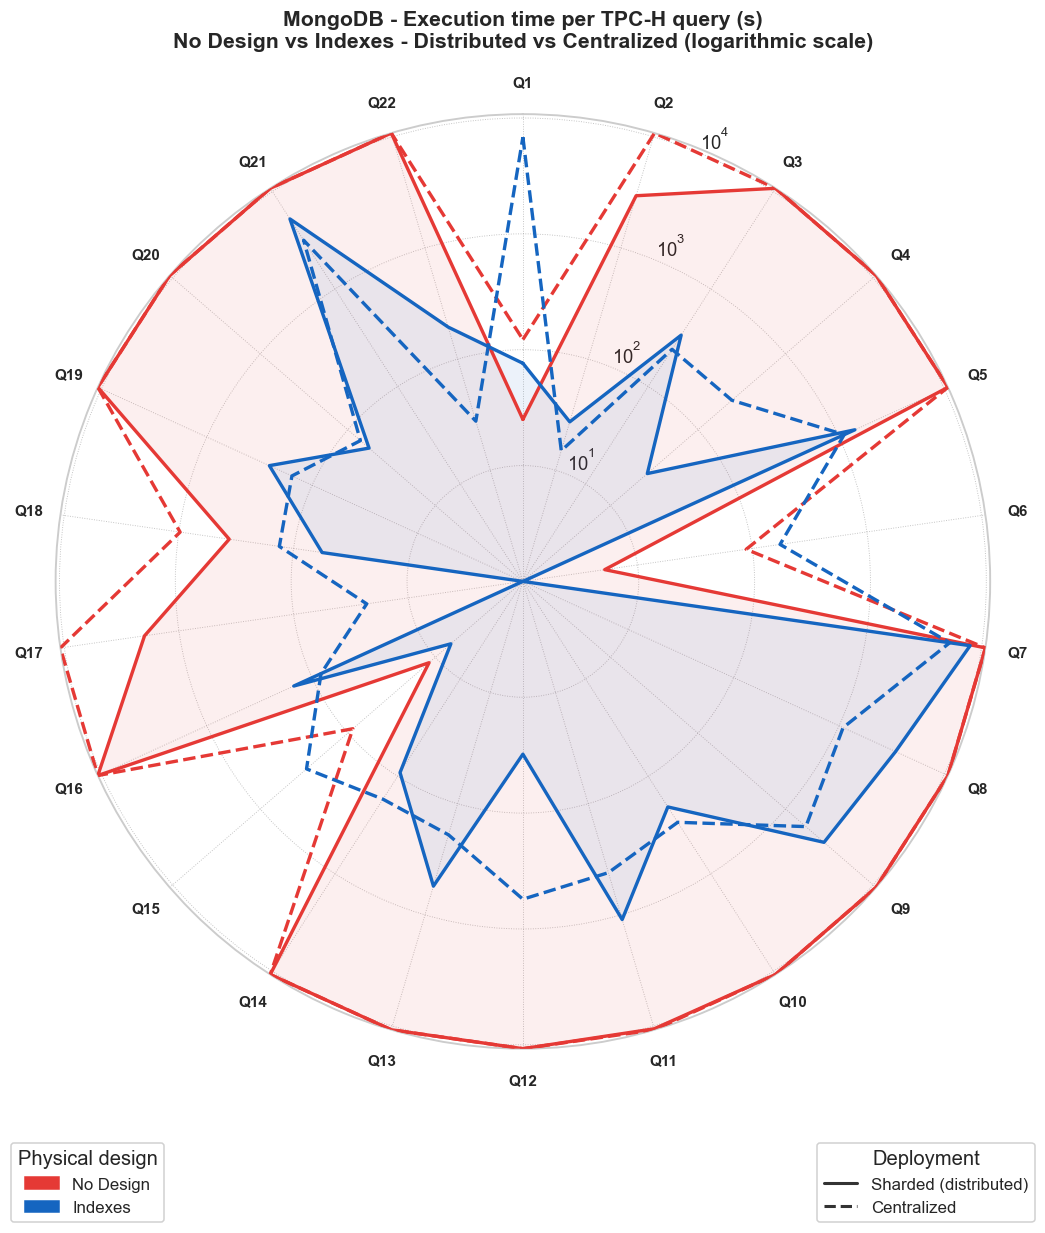

Guardado: radar_mongo_best.png


In [132]:
# MongoDB: Baseline vs Indices (mejor diseno), ambos despliegues, escala log
# (Baseline alcanza el timeout de 10.800 s -> vertice al borde)
plot_single_radar(df_statsN_M, df_statsN_central_M, "MongoDB", scale="log",
                  designs=["sindiseno", "indices"],
                  subtitle="No Design vs Indexes",
                  outfile="radar_mongo_best.png")


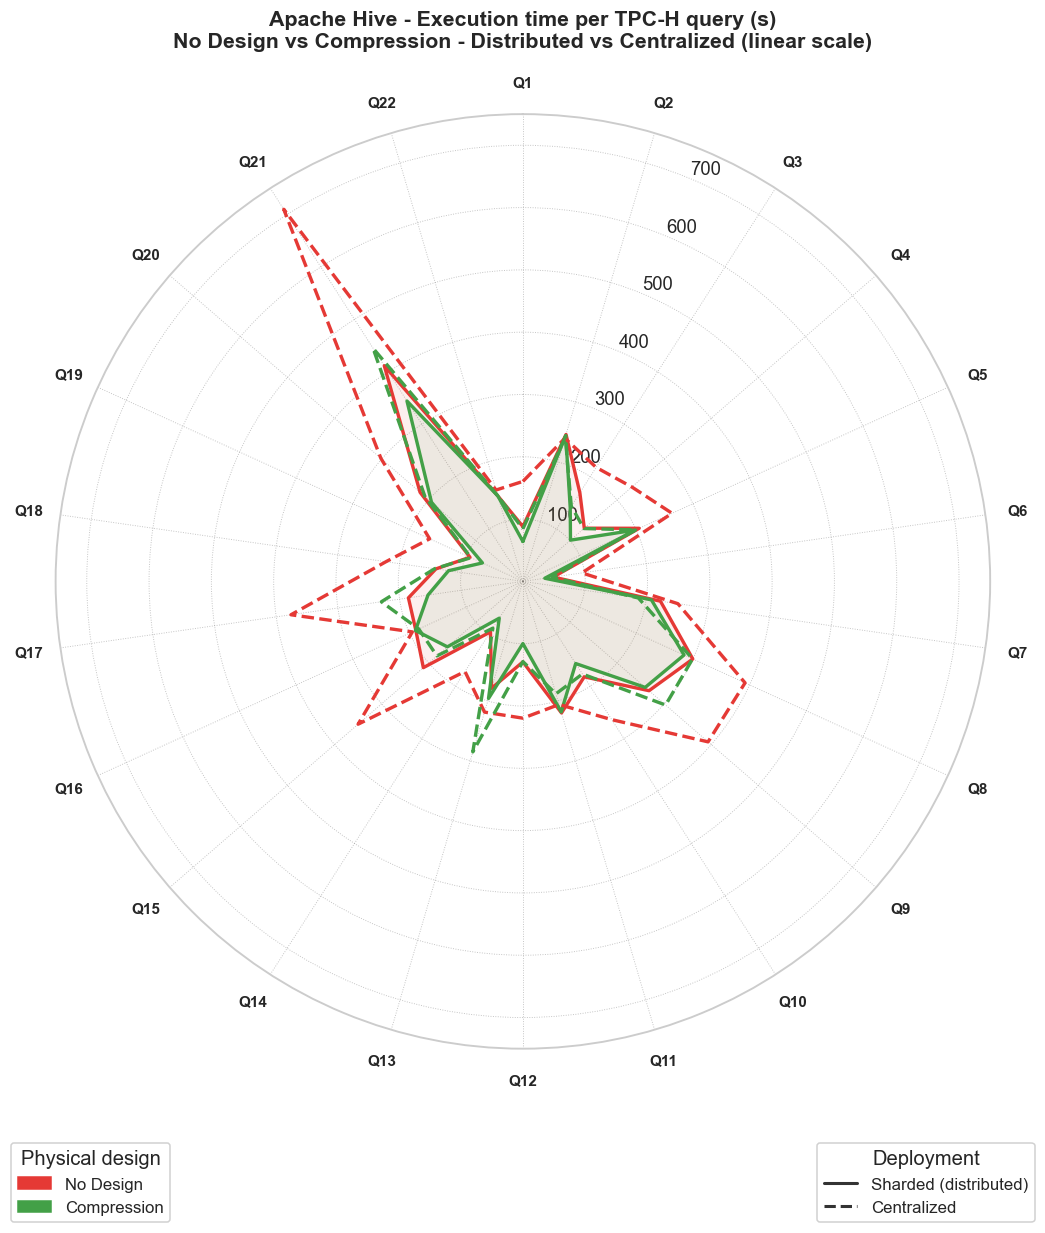

Guardado: radar_hive_best.png


In [133]:
# Hive: Baseline vs Compresion (mejor diseno), ambos despliegues, escala lineal
plot_single_radar(df_statsN_H, df_statsN_central_H, "Apache Hive", scale="linear",
                  designs=["sindiseno", "compresion"],
                  subtitle="No Design vs Compression",
                  outfile="radar_hive_best.png")


---
## 11. Radar por consulta — Tiempo de ejecución (22 ejes)

Un radar por motor y modalidad de despliegue (Hive Fragmentado, Hive Centralizado, Mongo Fragmentado, Mongo Centralizado), con una punta por consulta TPC-H (Q1–Q22) y el tiempo de ejecución (segundos) como valor radial. Los cuatro escenarios de diseño físico se superponen como polígonos. La celda genera dos versiones: `radar_per_query_log.png` (escala logarítmica) y `radar_per_query_linear.png` (escala lineal).


/var/folders/yz/vw71cvqj02b6wn0nvpt_z4kc0000gn/T/ipykernel_54791/2345659879.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 0.91, 1.0])


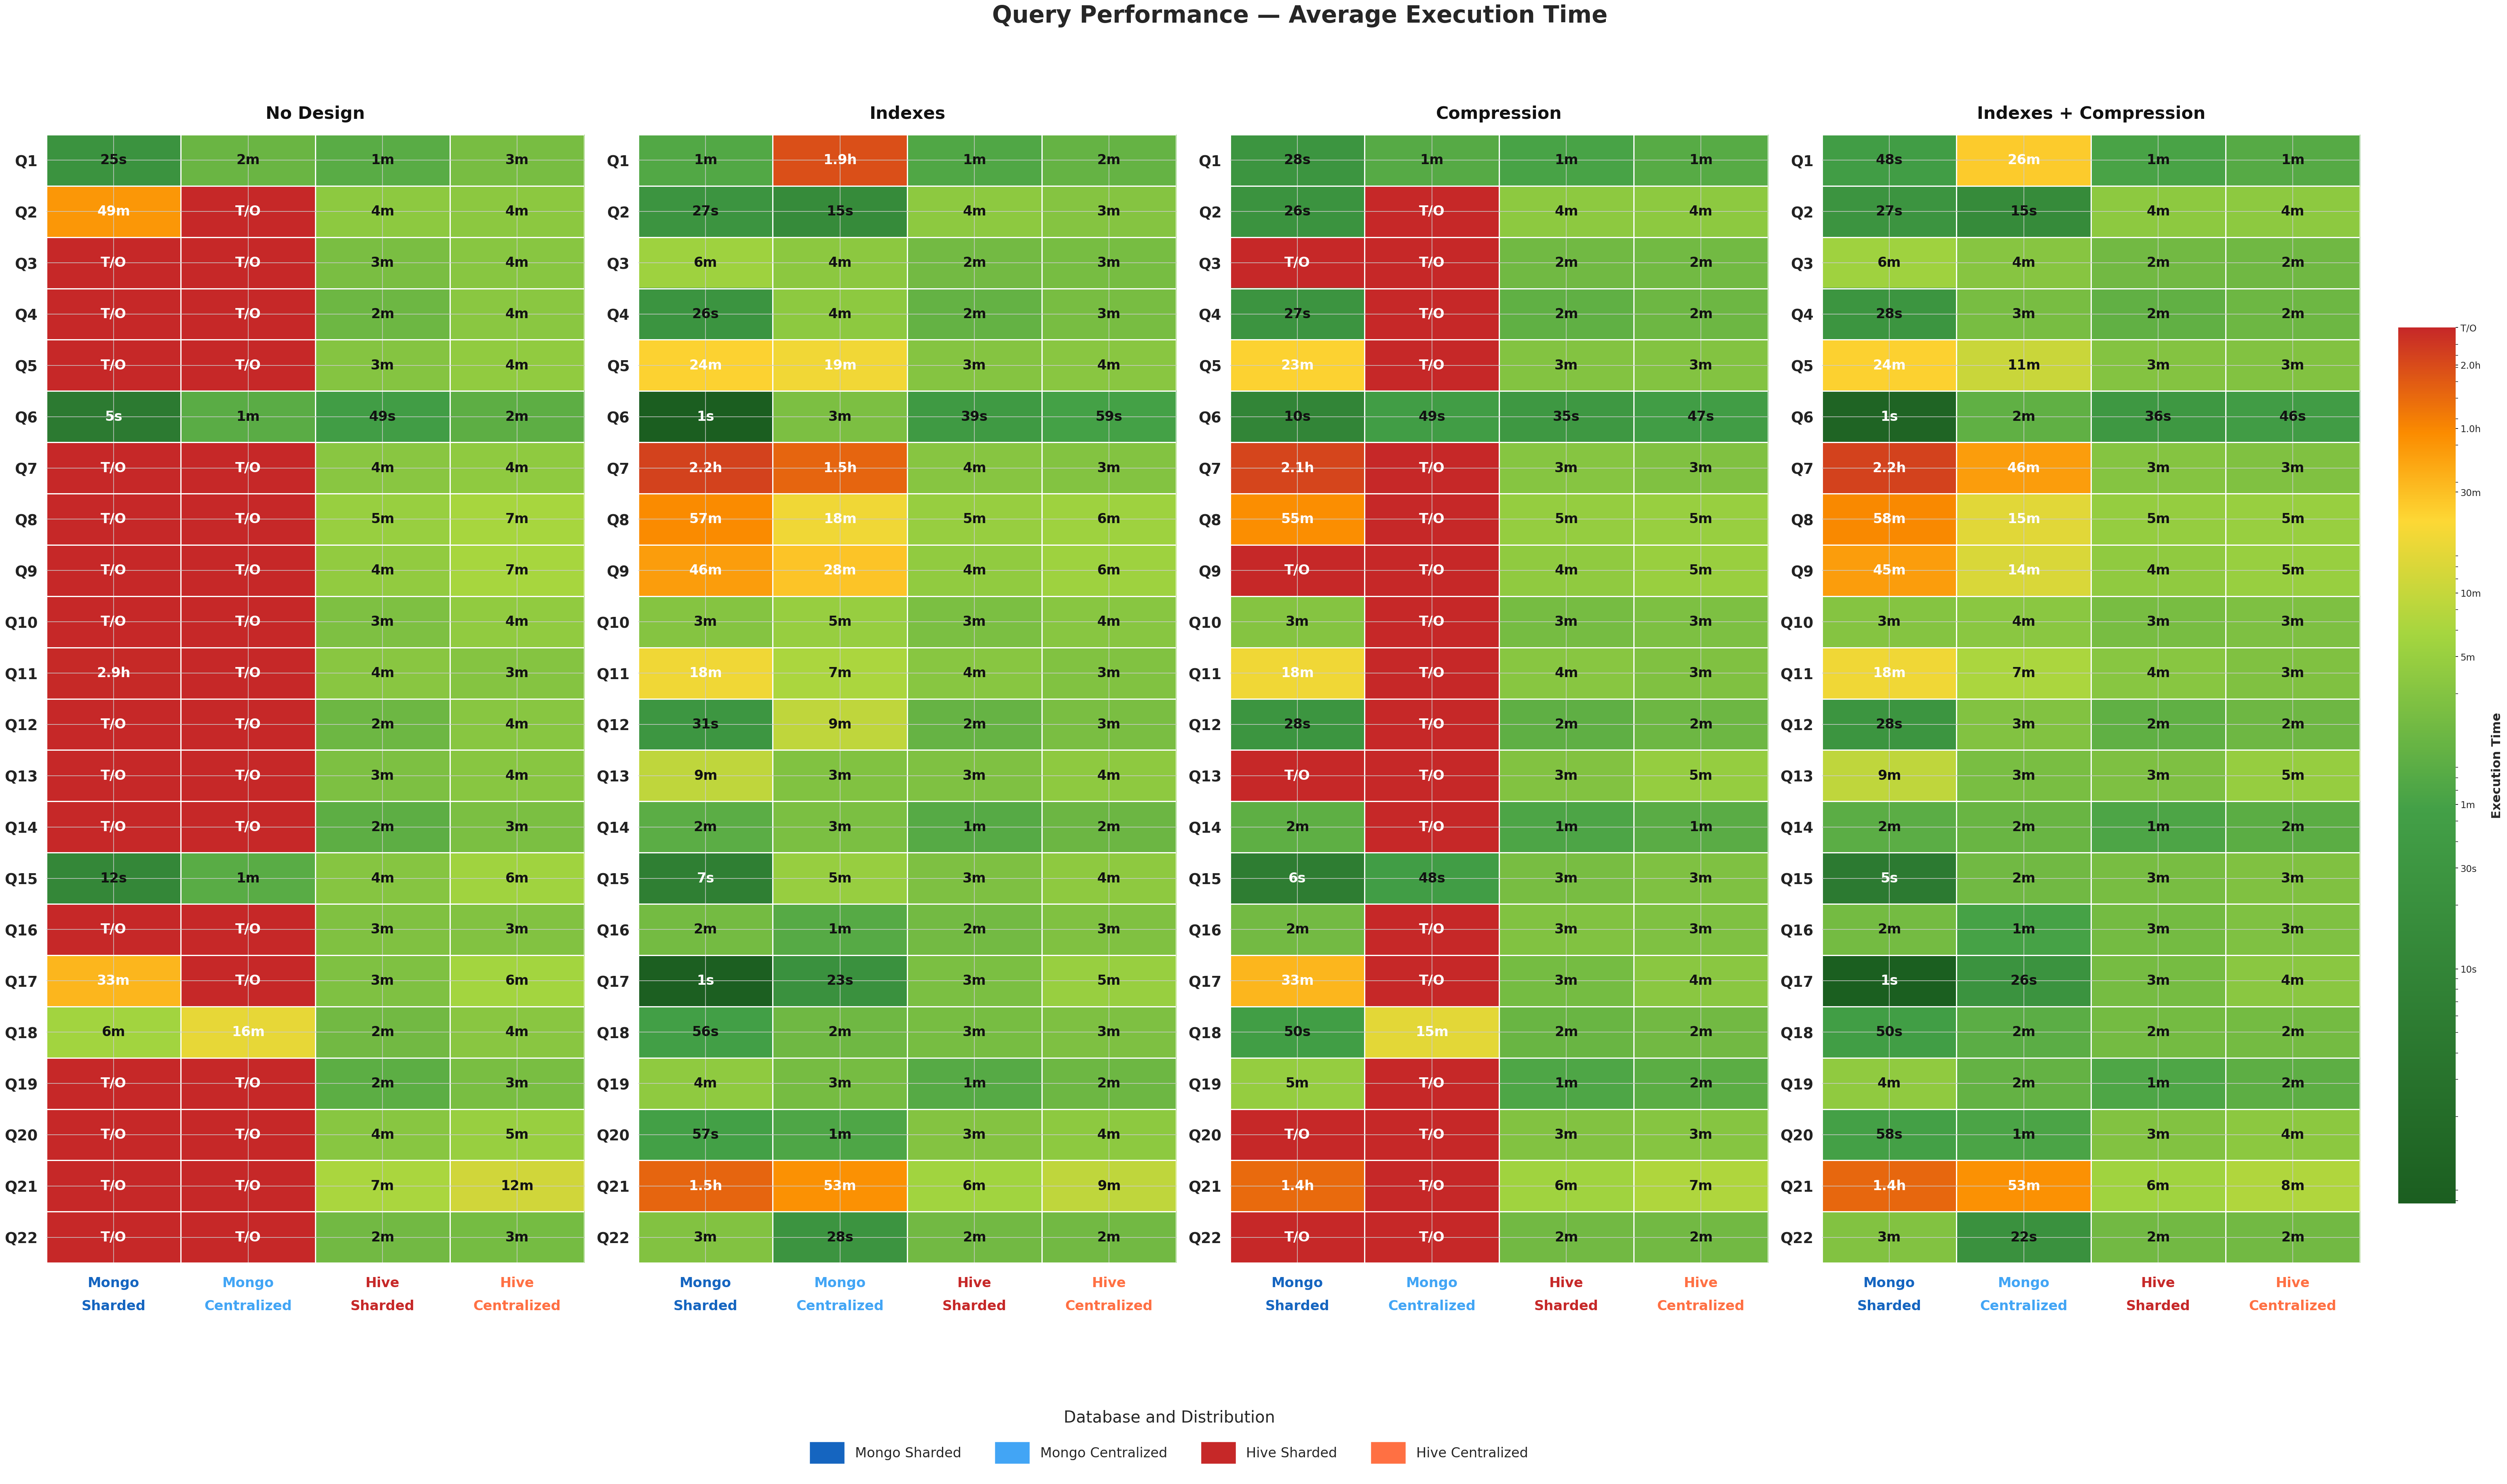

✅ Guardado: heatmap_tiempo.png


In [134]:
# ══════════════════════════════════════════════════════════════════════
# CELDA 1: HEATMAP — TIEMPO PROMEDIO
# ══════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

TIMEOUT_S = 10_800.0

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 18,
    "axes.titlesize": 28,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
})

SCEN_LABELS = {
    "sindiseno":         "No Design",
    "indices":           "Indexes",
    "compresion":        "Compression",
    "indice_compresion": "Indexes + Compression",
}

BD_LABELS = {
    "Mongo Frag": "Mongo\nSharded",
    "Mongo Cent": "Mongo\nCentralized",
    "Hive Frag":  "Hive\nSharded",
    "Hive Cent":  "Hive\nCentralized",
}
BD_COLORS = {
    "Mongo Frag": "#1565C0",
    "Mongo Cent": "#42A5F5",
    "Hive Frag":  "#C62828",
    "Hive Cent":  "#FF7043",
}
SCENARIO_ORDER = ["sindiseno", "indices", "compresion", "indice_compresion"]
BD_ORDER       = ["Mongo Frag", "Mongo Cent", "Hive Frag", "Hive Cent"]

CMAP_TIEMPO = LinearSegmentedColormap.from_list(
    "cmap_tiempo",
    [
        (0.00, "#1B5E20"),
        (0.45, "#43A047"),
        (0.65, "#A5D63F"),
        (0.78, "#FDD835"),
        (0.88, "#FB8C00"),
        (1.00, "#C62828"),
    ],
    N=512
)

def _build_combined(df_frag_M, df_cent_M, df_frag_H, df_cent_H):
    dfs = []
    for df, lbl in [
        (df_frag_M, "Mongo Frag"),
        (df_cent_M, "Mongo Cent"),
        (df_frag_H, "Hive Frag"),
        (df_cent_H, "Hive Cent"),
    ]:
        d = df.copy()
        d["bd"] = lbl
        dfs.append(d)
    return pd.concat(dfs, ignore_index=True)

def _fmt_time(v):
    if not np.isfinite(v) or v <= 0:
        return "—"
    if v >= TIMEOUT_S * 0.99:
        return "T/O"
    if v >= 3600:
        return f"{v/3600:.1f}h"
    elif v >= 60:
        return f"{v/60:.0f}m"
    else:
        return f"{v:.0f}s"

def _text_color(norm_val):
    if norm_val < 0.25 or norm_val > 0.72:
        return "white"
    return "#111111"

def _draw_heatmap_tiempo(ax, pivot, color_vals, norm, all_queries):
    n_q = len(pivot.index)
    n_b = len(pivot.columns)
    ax.set_facecolor("#FAFAFA")

    im = ax.imshow(color_vals.values, aspect="auto",
                   cmap=CMAP_TIEMPO, norm=norm, interpolation="nearest")

    ax.set_xticks(np.arange(-0.5, n_b, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_q, 1), minor=True)
    ax.grid(which="minor", color=(1,1,1,0.6), linewidth=2.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(n_q):
        for j in range(n_b):
            raw = pivot.values[i, j]
            cv  = color_vals.values[i, j]
            txt = _fmt_time(raw)
            fc  = _text_color(norm(cv))
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=22, color=fc, fontweight="bold")

    ax.set_yticks(range(n_q))
    ax.set_yticklabels([f"Q{int(q)}" for q in all_queries],
                       fontsize=24, fontweight="bold", color="#222")
    ax.tick_params(axis="y", length=0, pad=14)
    ax.set_xticks(range(n_b))
    ax.set_xticklabels([BD_LABELS.get(c, c) for c in pivot.columns],
                       fontsize=22, linespacing=1.9)
    ax.tick_params(axis="x", length=0, pad=22)
    for j, bd in enumerate(pivot.columns):
        lbl = ax.get_xticklabels()[j]
        lbl.set_color(BD_COLORS.get(bd, "#333"))
        lbl.set_fontweight("bold")
    return im

# ── DATOS ─────────────────────────────────────────────────────────────

combined = _build_combined(
    df_statsN_M, df_statsN_central_M,
    df_statsN_H, df_statsN_central_H
)

time_col = next(
    (c for c in ["mean_time", "meantime"] if c in combined.columns), None
)

agg = (
    combined
    .groupby(["Q", "scenario", "bd"])[time_col]
    .median()
    .reset_index()
    .rename(columns={time_col: "val"})
)
agg["is_timeout"] = agg["val"] >= TIMEOUT_S * 0.99

scens_present = [s for s in SCENARIO_ORDER if s in agg["scenario"].unique()]
bds_present   = [b for b in BD_ORDER       if b in agg["bd"].unique()]
all_queries   = list(range(1, 23))
n_scen        = len(scens_present)

# Escala global solo de tiempo
valid_vals = agg.loc[~agg["is_timeout"], "val"]
valid_vals = valid_vals[valid_vals > 0].dropna()
global_min = valid_vals.min()
global_max = TIMEOUT_S
norm_t = mcolors.LogNorm(vmin=global_min, vmax=global_max)

# ── FIGURA ────────────────────────────────────────────────────────────

cell_w = 2.8
cell_h = 1.15
fig_w  = n_scen * (len(bds_present) * cell_w + 2.5) + 4
fig_h  = len(all_queries) * cell_h + 5

fig, axes = plt.subplots(1, n_scen, figsize=(fig_w, fig_h), sharey=False)
fig.patch.set_facecolor("white")
if n_scen == 1:
    axes = [axes]

last_im = None

for ax, scen in zip(axes, scens_present):
    sub = agg[agg["scenario"] == scen]

    pivot = (
        sub.pivot_table(index="Q", columns="bd", values="val", aggfunc="median")
        .reindex(index=all_queries)
        .reindex(columns=bds_present)
    )
    timeout_pivot = (
        sub.pivot_table(index="Q", columns="bd", values="is_timeout", aggfunc="max")
        .reindex(index=all_queries)
        .reindex(columns=bds_present)
        .fillna(False).astype(bool)
    )

    color_vals = pivot.copy()
    color_vals[timeout_pivot] = global_max
    color_vals = color_vals.fillna(global_max).clip(lower=global_min)

    ax.set_title(SCEN_LABELS.get(scen, scen),
                 fontsize=28, fontweight="bold", color="#111", pad=26)
    last_im = _draw_heatmap_tiempo(ax, pivot, color_vals, norm_t, all_queries)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.022, 0.65])
cbar    = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label("Execution Time", fontsize=20, labelpad=16, fontweight="bold")

tick_vals   = [t for t in [10, 30, 60, 300, 600, 1800, 3600, 7200, TIMEOUT_S]
               if global_min <= t <= global_max]
tick_labels = [_fmt_time(t) for t in tick_vals]
tick_labels[-1] = "T/O"
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_labels)
cbar.ax.tick_params(labelsize=15, length=4)
cbar.outline.set_visible(False)

# Leyenda
handles = [
    mpatches.Patch(color=BD_COLORS[bd], label=BD_LABELS.get(bd, bd).replace("\n", " "))
    for bd in bds_present
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.45, -0.06),
           ncol=4, fontsize=22, frameon=False,
           title="Database and Distribution", title_fontsize=26,
           handlelength=2.5, handleheight=2.0,
           labelspacing=1.2, borderpad=1.2, columnspacing=2.5)

fig.suptitle("Query Performance — Average Execution Time",
             fontsize=38, fontweight="bold", y=1.04)

plt.tight_layout(rect=[0, 0.06, 0.91, 1.0])
plt.savefig("heatmap_tiempo.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Guardado: heatmap_tiempo.png")

/var/folders/yz/vw71cvqj02b6wn0nvpt_z4kc0000gn/T/ipykernel_54791/2403106676.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 0.91, 1.0])


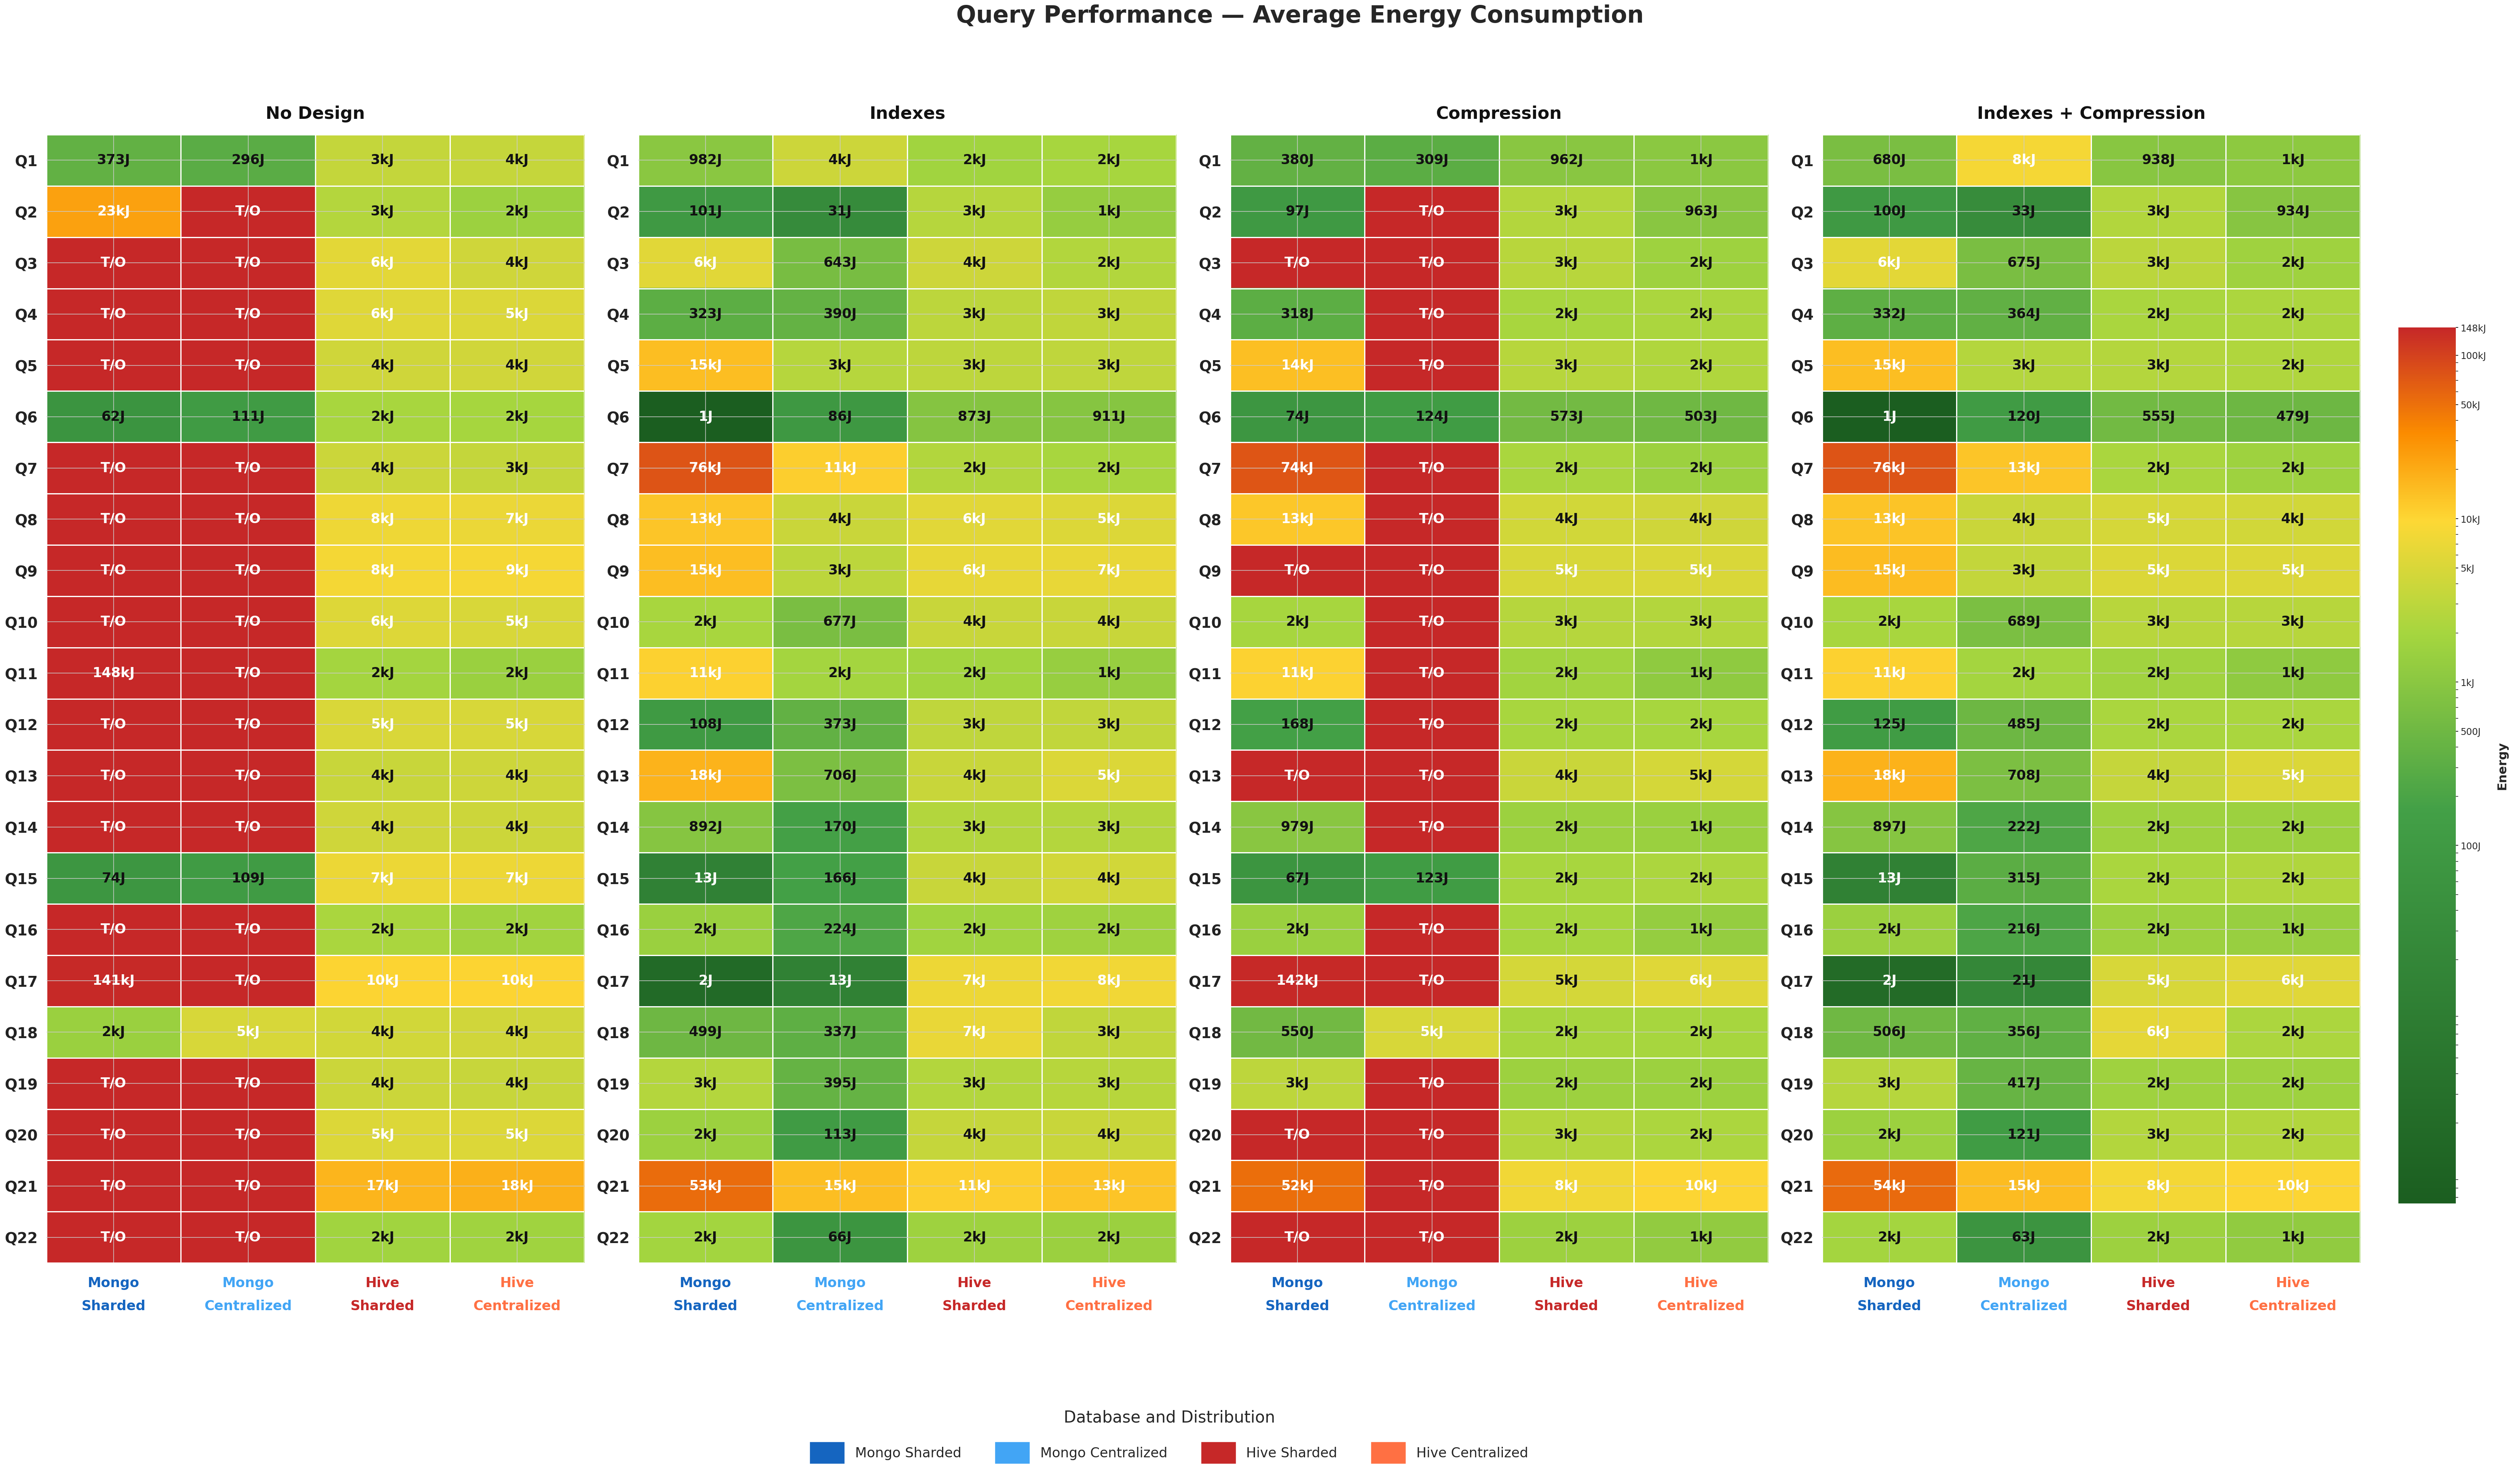

✅ Guardado: heatmap_energia.png


In [135]:
# ══════════════════════════════════════════════════════════════════════
# CELDA 2: HEATMAP — ENERGÍA PROMEDIO
# ══════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

TIMEOUT_S = 10_800.0

CMAP_ENERGIA = LinearSegmentedColormap.from_list(
    "cmap_energia",
    [
        (0.00, "#1B5E20"),
        (0.45, "#43A047"),
        (0.65, "#A5D63F"),
        (0.78, "#FDD835"),
        (0.88, "#FB8C00"),
        (1.00, "#C62828"),
    ],
    N=512
)

def _fmt_energy(v):
    if not np.isfinite(v) or v <= 0:
        return "—"
    if v >= 1e6:
        return f"{v/1e6:.1f}MJ"
    elif v >= 1e3:
        return f"{v/1e3:.0f}kJ"
    else:
        return f"{v:.0f}J"

def _draw_heatmap_energia(ax, pivot, color_vals, norm, all_queries, timeout_pivot):
    n_q = len(pivot.index)
    n_b = len(pivot.columns)
    ax.set_facecolor("#FAFAFA")

    im = ax.imshow(color_vals.values, aspect="auto",
                   cmap=CMAP_ENERGIA, norm=norm, interpolation="nearest")

    ax.set_xticks(np.arange(-0.5, n_b, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_q, 1), minor=True)
    ax.grid(which="minor", color=(1,1,1,0.6), linewidth=2.0)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for i in range(n_q):
        for j in range(n_b):
            raw   = pivot.values[i, j]
            cv    = color_vals.values[i, j]
            is_to = bool(timeout_pivot.values[i, j])
            txt   = "T/O" if is_to else _fmt_energy(raw)
            fc    = _text_color(norm(cv))
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=22, color=fc, fontweight="bold")

    ax.set_yticks(range(n_q))
    ax.set_yticklabels([f"Q{int(q)}" for q in all_queries],
                       fontsize=24, fontweight="bold", color="#222")
    ax.tick_params(axis="y", length=0, pad=14)
    ax.set_xticks(range(n_b))
    ax.set_xticklabels([BD_LABELS.get(c, c) for c in pivot.columns],
                       fontsize=22, linespacing=1.9)
    ax.tick_params(axis="x", length=0, pad=22)
    for j, bd in enumerate(pivot.columns):
        lbl = ax.get_xticklabels()[j]
        lbl.set_color(BD_COLORS.get(bd, "#333"))
        lbl.set_fontweight("bold")
    return im

# ── DATOS ─────────────────────────────────────────────────────────────

# Reutiliza 'combined' de la celda anterior (ya tiene la columna "bd")
# Si ejecutas esta celda sola, descomenta las siguientes líneas:
# combined = _build_combined(
#     df_statsN_M, df_statsN_central_M,
#     df_statsN_H, df_statsN_central_H
# )

time_col   = next((c for c in ["mean_time",   "meantime"]   if c in combined.columns), None)
energy_col = next((c for c in ["mean_energy", "meanenergy"] if c in combined.columns), None)

# Máscara de T/O desde tiempo
timeout_mask_df = (
    combined
    .groupby(["Q", "scenario", "bd"])[time_col]
    .median()
    .reset_index()
    .rename(columns={time_col: "time_val"})
)
timeout_mask_df["is_timeout"] = timeout_mask_df["time_val"] >= TIMEOUT_S * 0.99

# Agregado de energía
agg_e = (
    combined
    .groupby(["Q", "scenario", "bd"])[energy_col]
    .median()
    .reset_index()
    .rename(columns={energy_col: "val"})
)
agg_e = agg_e.merge(
    timeout_mask_df[["Q", "scenario", "bd", "is_timeout"]],
    on=["Q", "scenario", "bd"], how="left"
)
agg_e["is_timeout"] = agg_e["is_timeout"].fillna(False)

scens_present = [s for s in SCENARIO_ORDER if s in agg_e["scenario"].unique()]
bds_present   = [b for b in BD_ORDER       if b in agg_e["bd"].unique()]
all_queries   = list(range(1, 23))
n_scen        = len(scens_present)

# Escala global solo de energía (sin T/O)
valid_e    = agg_e.loc[~agg_e["is_timeout"], "val"]
valid_e    = valid_e[valid_e > 0].dropna()
global_min_e = valid_e.min()
global_max_e = valid_e.max()   # máximo energético real
norm_e = mcolors.LogNorm(vmin=global_min_e, vmax=global_max_e)

# ── FIGURA ────────────────────────────────────────────────────────────

cell_w = 2.8
cell_h = 1.15
fig_w  = n_scen * (len(bds_present) * cell_w + 2.5) + 4
fig_h  = len(all_queries) * cell_h + 5

fig, axes = plt.subplots(1, n_scen, figsize=(fig_w, fig_h), sharey=False)
fig.patch.set_facecolor("white")
if n_scen == 1:
    axes = [axes]

last_im = None

for ax, scen in zip(axes, scens_present):
    sub = agg_e[agg_e["scenario"] == scen]

    pivot = (
        sub.pivot_table(index="Q", columns="bd", values="val", aggfunc="median")
        .reindex(index=all_queries)
        .reindex(columns=bds_present)
    )
    timeout_pivot = (
        sub.pivot_table(index="Q", columns="bd", values="is_timeout", aggfunc="max")
        .reindex(index=all_queries)
        .reindex(columns=bds_present)
        .fillna(False).astype(bool)
    )

    # T/O → global_max_e para que quede en rojo máximo de la escala energética
    color_vals = pivot.copy()
    color_vals[timeout_pivot] = global_max_e
    color_vals = color_vals.fillna(global_max_e).clip(lower=global_min_e)

    ax.set_title(SCEN_LABELS.get(scen, scen),
                 fontsize=28, fontweight="bold", color="#111", pad=26)
    last_im = _draw_heatmap_energia(
        ax, pivot, color_vals, norm_e, all_queries, timeout_pivot
    )

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.022, 0.65])
cbar    = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label("Energy", fontsize=20, labelpad=16, fontweight="bold")

tick_vals = [
    e for e in [100, 500, 1_000, 5_000, 10_000,
                50_000, 100_000, 500_000, 1_000_000, global_max_e]
    if global_min_e <= e <= global_max_e
]
tick_labels = [_fmt_energy(t) for t in tick_vals]
cbar.set_ticks(tick_vals)
cbar.set_ticklabels(tick_labels)
cbar.ax.tick_params(labelsize=15, length=4)
cbar.outline.set_visible(False)

# Leyenda
handles = [
    mpatches.Patch(color=BD_COLORS[bd], label=BD_LABELS.get(bd, bd).replace("\n", " "))
    for bd in bds_present
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.45, -0.06),
           ncol=4, fontsize=22, frameon=False,
           title="Database and Distribution", title_fontsize=26,
           handlelength=2.5, handleheight=2.0,
           labelspacing=1.2, borderpad=1.2, columnspacing=2.5)

fig.suptitle("Query Performance — Average Energy Consumption",
             fontsize=38, fontweight="bold", y=1.04)
            

plt.tight_layout(rect=[0, 0.06, 0.91, 1.0])
plt.savefig("heatmap_energia.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Guardado: heatmap_energia.png")